## Set-up

Import

In [1]:
%load_ext autoreload
%autoreload 2
%autosave 30

import sys, os

sys.path.insert(1, os.path.join(os.getcwd(), "../python_source"))

from spins_symmetric_subspace import *
from fisher_information import *
from variational_algorithm import *
from lindblad import *
from pso import pso

figdir = os.path.join(os.getcwd(), "../figures/")
import matplotlib.pyplot as plt
import matplotlib as mpl

# from matplotlib.colormaps import get_cmap
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as tkr

mpl.rcParams["mathtext.fontset"] = "cm"
mpl.rcParams["font.family"] = "STIXGeneral"
mpl.rcParams["lines.linewidth"] = 2
plt.rcParams.update({"font.size": 18})

import imageio
from tqdm.notebook import tqdm
import pandas as pd
from scipy.optimize import minimize
from pprint import pprint
from copy import deepcopy
from scipy.linalg import logm

Autosaving every 30 seconds


Style

In [2]:
# Bang Wong color blind--friendly colours
COLOURS = {
    "Black": "#000000",
    "Orange": "#E69F00",
    "Sky blue": "#56B4E9",
    "Bluish green": "#009E73",
    "Yellow": "#F0E442",
    "Blue": "#0072B2",
    "Vermillion": "#D55E00",
    "Reddish purple": "#CC79A7",
}


def lim(axis_data):
    return (axis_data.min(), axis_data.max())


def grid(ax, zorder=0, **kwargs):
    ax.grid("both", "both", color="gainsboro", zorder=zorder, **kwargs)


def legend(ax, reversed=False, **kwargs):
    defaults = dict(handlelength=1, labelspacing=0, frameon=False, handletextpad=0.3)
    if reversed:
        h, l = ax.get_legend_handles_labels()
        ax.legend(handles=reversed(h), labels=reversed(l), **(defaults | kwargs))
    else:
        ax.legend(**(defaults | kwargs))


def colorbar_without_resizing(fig, ax, image, pad=0.05, fmt=None):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=pad)
    # TODO: fix formatter to handle overall order scaling
    # e.g. fmt = '%.1g'
    if fmt is not None:
        fig.colorbar(image, cax=cax, format=tkr.FormatStrFormatter(fmt))
    else:
        fig.colorbar(image, cax=cax)


def plot_imshow_operators(ops, labels):
    fig, axs = plt.subplots(
        2, 3, figsize=(10, 5), gridspec_kw=dict(wspace=0.3, hspace=0.5)
    )
    for i, (op, label) in enumerate(zip(ops, labels)):
        ax = axs[0, i]
        im = ax.imshow(np.abs(op))
        colorbar_without_resizing(fig, ax, im)
        ax.set_title(rf"{label} absolute value")

        ax = axs[1, i]
        im = ax.imshow(np.angle(op))
        colorbar_without_resizing(fig, ax, im)
        ax.set_title(rf"{label} angle")

    plt.show()


def pandas_float_format(fmt=".3g"):
    pd.set_option("display.float_format", lambda x: f"{x:{fmt}}")

## Evolution under TAT over time

Let's show that I can recover the previous results much more easily

In [ ]:
# dimension
D = 7

# vacuum, down in Jz
# λs, vs = np.linalg.eigh(Jz(D))
# ket0 = vs[:, np.argmin(λs)]
ket0 = vacuum(D)

data = [
    np.abs(ket0) ** 2,
]
χs = np.linspace(0, 5, 100)
for χ in χs[1:]:
    ket1 = TAT(D, ket0, χ=χ, truncation=None)
    data1 = np.abs(ket1) ** 2
    data.append(data1)
data = np.array(data)

fig, ax = plt.subplots(figsize=(8, 6))
colors = list(reversed(plt.cm.coolwarm(np.linspace(0, 1, len(data[0])))))
labels = Jz(D).diagonal().real
for j in range(len(data[0])):
    ax.plot(χs, data[:, j], label=f"{labels[j]:.1f}", color=colors[j])
ax.set(
    xlim=(χs.min(), χs.max()),
    ylim=(0, 1),
    xlabel=r"two-axis twisting parameter, $\chi$",
    ylabel=r"probability",
)
ax.legend(title="$\hat{J_z}$")
plt.show()

## Qudit random states

Show that I can recover the mathematica results, then extend them with gradient/swarm optimisation

In [ ]:
D = 3
L1 = Jx(D)
L2 = Jm(D)
print("Inner product L1 and L2: ", (dag(L1) @ L2).trace())

data = []
λs, vs = np.linalg.eigh(Jz(D))
for λ, v in zip(λs, vs.T):
    ket = v
    QFI_noiseless = variance(D, ket, L1)
    covL1L2 = np.abs(covariance(D, ket, L1, L2)) ** 2
    QFI_noisy = (
        QFI_noiseless - covL1L2 / variance(D, ket, L2)
        if covL1L2 > 1e-10
        else QFI_noiseless
    )
    data.append([λ, QFI_noiseless, QFI_noisy, QFI_noisy / QFI_noiseless])

data = pd.DataFrame(
    data, columns=["Jz", "QFI_noiseless", "QFI_noisy", "ratio_to_noiseless"]
)

data

In [ ]:
D = 8
L1 = Jx(D)
L2 = Jm(D)
print("Inner product L1 and L2: ", (dag(L1) @ L2).trace())

data = []
λs, vs = np.linalg.eigh(Jz(D))
for λ, v in zip(λs, vs.T):
    ket = v
    QFI_noiseless = variance(D, ket, L1)
    covL1L2 = np.abs(covariance(D, ket, L1, L2)) ** 2
    QFI_noisy = (
        QFI_noiseless - covL1L2 / variance(D, ket, L2)
        if covL1L2 > 1e-10
        else QFI_noiseless
    )
    data.append([λ, QFI_noiseless, QFI_noisy, QFI_noisy / QFI_noiseless])

data = pd.DataFrame(
    data, columns=["Jz", "QFI_noiseless", "QFI_noisy", "ratio_to_noiseless"]
)

data

Random states

In [ ]:
Dmax = 20

data = []
for D in tqdm(range(2, Dmax + 1)):
    L1 = Jx(D)
    L2 = Jm(D)

    ket = vacuum(D)
    QFI_noiseless = variance(D, ket, L1)
    covL1L2 = np.abs(covariance(D, ket, L1, L2)) ** 2
    QFI_noisy = (
        QFI_noiseless - covL1L2 / variance(D, ket, L2)
        if covL1L2 > 1e-10
        else QFI_noiseless
    )
    results_vacuum = dict(QFI_noiseless=QFI_noiseless, QFI_noisy=QFI_noisy, ket=ket)

    ket = normalise(
        D, (extreme_eigenstate(L1, "max") + extreme_eigenstate(L1, "min")) / np.sqrt(2)
    )
    QFI_noiseless = variance(D, ket, L1)
    covL1L2 = np.abs(covariance(D, ket, L1, L2)) ** 2
    QFI_noisy = (
        QFI_noiseless - covL1L2 / variance(D, ket, L2)
        if covL1L2 > 1e-10
        else QFI_noiseless
    )
    results_cat = dict(QFI_noiseless=QFI_noiseless, QFI_noisy=QFI_noisy, ket=ket)

    # num_rand_samples = 4000
    num_rand_samples = 1000
    results_victor = dict(QFI_noisy=0)
    for _ in range(num_rand_samples):
        ket = normalise(D, 2 * np.random.rand(D) - 1 + 1j * (2 * np.random.rand(D) - 1))
        QFI_noiseless = variance(D, ket, L1)
        covL1L2 = np.abs(covariance(D, ket, L1, L2)) ** 2
        QFI_noisy = (
            QFI_noiseless - covL1L2 / variance(D, ket, L2)
            if covL1L2 > 1e-10
            else QFI_noiseless
        )
        if QFI_noisy > results_victor["QFI_noisy"]:
            results_victor = dict(
                D=D,
                QFI_noiseless=QFI_noiseless,
                QFI_noisy=QFI_noisy,
                ratio_to_vacuum=QFI_noisy / results_vacuum["QFI_noisy"],
                ratio_to_cat=QFI_noisy / results_cat["QFI_noisy"],
                ratio_noiseless_to_cat=QFI_noiseless / results_cat["QFI_noiseless"],
                QFI_noiseless_cat=results_cat["QFI_noiseless"],
                QFI_noisy_cat=results_cat["QFI_noisy"],
                QFI_noiseless_vacuum=results_vacuum["QFI_noiseless"],
                QFI_noisy_vacuum=results_vacuum["QFI_noisy"],
                # ket = ket
            )

    ket_bench = ith_eigenstate(Jz(D), D // 2 - 1)
    results_victor["QFI_bench"] = variance(D, ket_bench, L1) - np.abs(
        covariance(D, ket_bench, L1, L2)
    ) ** 2 / variance(D, ket_bench, L2)

    data.append(list(results_victor.values()))

data = pd.DataFrame(data, columns=results_victor.keys())
display(data)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.axhline(1, color="gainsboro")
ax.plot(data["D"], data["ratio_to_vacuum"], ".-", label="best random state")
ax.plot(
    data["D"], data["QFI_noisy_cat"] / data["QFI_noisy_vacuum"], ".-", label="cat state"
)
ax.plot(
    data["D"],
    data["QFI_bench"] / data["QFI_noisy_vacuum"],
    ".-",
    label=r"$J_z$ equatorial eigenstate",
)
ax.set_xticks(np.arange(2, Dmax + 1))
ax.legend()
ax.set(
    xlim=(2, Dmax),
    ylim=(0, None),
    xlabel=r"dimension, $d$",
    ylabel=r"noisy QFI [vacuum noisy QFI]",
    title=r"random states: signal $J_x$, noise $J_-$",
)
fig.savefig(f"{figdir}qubits/qudits_gain_over_vacuum-python.pdf")
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.axhline(1, color="gainsboro")
# ax.plot(data["D"], (data["D"] - 1)**2 / 4, '-', label=r'expected $N^2/4$, $N=D-1$')
ax.plot(
    data["D"], data["QFI_noiseless_cat"], ".-", label=r"noiseless cat $N^2/4$, $N=D-1$"
)
ax.plot(data["D"], data["QFI_noisy_cat"], ".-", label="noisy cat")
ax.legend()
ax.set_xticks(np.arange(2, Dmax + 1))
ax.set(
    xlim=(2, Dmax),
    ylim=(0, None),
    xlabel=r"dimension, $d$",
    ylabel=r"cat state noiseless QFI",
    title=r"signal $J_x$, noise $J_-$",
    # yscale='log'
)
# fig.savefig(f'{figdir}qubits/qudits_gain_over_vacuum-python.pdf')
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.axhline(1, color="gainsboro")
ax.plot(data["D"], data["ratio_to_cat"], ".-")
ax.set_xticks(np.arange(2, Dmax + 1))
ax.set(
    xlim=(2, Dmax),
    ylim=(0, None),
    xlabel=r"dimension, $d$",
    ylabel=r"noiseless QFI / noiseless cat QFI",
    title=r"random states: signal $J_x$, noise $J_-$",
)
# fig.savefig(f'{figdir}qubits/qudits_gain_over_vacuum-python.pdf')
plt.show()

Visualising the best random states for different dimensions $d$

In [ ]:
Ds = [5, 10, 15, 20]

for D in Ds:
    L1 = Jx(D)
    L2 = Jm(D)

    num_rand_samples = 1000
    results_victor = dict(QFI_noisy=0)
    for _ in range(num_rand_samples):
        ket = normalise(D, 2 * np.random.rand(D) - 1 + 1j * (2 * np.random.rand(D) - 1))
        QFI_noiseless = variance(D, ket, L1)
        covL1L2 = np.abs(covariance(D, ket, L1, L2)) ** 2
        QFI_noisy = (
            QFI_noiseless - covL1L2 / variance(D, ket, L2)
            if covL1L2 > 1e-10
            else QFI_noiseless
        )
        if QFI_noisy > results_victor["QFI_noisy"]:
            results_victor = dict(
                ket=ket,
                QFI_noiseless=QFI_noiseless,
                QFI_noisy=QFI_noisy,
            )

    fig, ax = plot_Husimi_Q(
        D,
        results_victor["ket"],
        plot_points=100,
        progress_bar=False,
        return_dont_show=True,
    )
    ax.set_title("Best random state\n" + rf"dimension $d = {D}$")
    fig.show()

## Visualisation

Using Simon's Husimi Q-function or Bloch sphere

### Husimi Q-function, see Ma+11 Eq.138.

$$Q(\theta, \phi) = \lvert\bra{\theta, \phi}\ket{\psi}\rvert^2$$

J_z eigenstates

In [ ]:
D = 11
λs, vs = np.linalg.eigh(Jz(D))
ket = vs[:, D // 2]
plot_Husimi_Q(D, ket, plot_points=50)

CSSs

In [ ]:
# D = 61 # Fig. 2 in Ma+11
D = 7
plot_points = 50
ket = CSS(D, 0, 0)
plot_Husimi_Q(D, ket, plot_points=plot_points)

In [ ]:
D = 7
plot_points = 50
ket = vacuum(D)
plot_Husimi_Q(D, ket, plot_points=plot_points)

In [ ]:
D = 7
plot_points = 100
ket = CSS(D, π / 2, π / 2)
plot_Husimi_Q(D, ket, plot_points=plot_points)

In [ ]:
D = 7
plot_points = 100
ket = CSS(D, π / 2, π)
plot_Husimi_Q(D, ket, plot_points=plot_points)

In [ ]:
D = 7
plot_points = 100
ket = CSS(D, π / 4, π)
plot_Husimi_Q(D, ket, plot_points=plot_points)

In [ ]:
D = 7
plot_points = 100
ket = CSS(D, π / 4, -π / 4)
plot_Husimi_Q(D, ket, plot_points=plot_points)

Cat states

In [ ]:
# cat state in Jz
D = 7
ket = normalise(
    D,
    (extreme_eigenstate(Jz(D), "max") + extreme_eigenstate(Jz(D), "min")) / np.sqrt(2),
)
plot_Husimi_Q(D, ket, plot_points=100)

In [ ]:
# cat state in Jx
D = 7
ket = normalise(
    D,
    (extreme_eigenstate(Jx(D), "max") + extreme_eigenstate(Jx(D), "min")) / np.sqrt(2),
)
plot_Husimi_Q(D, ket, plot_points=100)

In [ ]:
# cat state in Jy
D = 7
ket = normalise(
    D,
    (extreme_eigenstate(Jy(D), "max") + extreme_eigenstate(Jy(D), "min")) / np.sqrt(2),
)
plot_Husimi_Q(D, ket, plot_points=100)

SSSs

In [ ]:
# squeezing the vacuum spin state
D = 7
χ = 0.1
ket = TAT(D, vacuum(D), χ=χ, truncation=None)
plot_Husimi_Q(D, ket, plot_points=100)

In [ ]:
# squeezing the vacuum spin state
D = 7
χ = 0.3
ket = TAT(D, vacuum(D), χ=χ, truncation=None)
plot_Husimi_Q(D, ket, plot_points=100)

In [ ]:
# squeezing the vacuum spin state
D = 7
χ = 0.5
ket = TAT(D, vacuum(D), χ=χ, truncation=None)
plot_Husimi_Q(D, ket, plot_points=100)

In [ ]:
# squeezing the vacuum spin state
D = 7
χ = 1
ket = TAT(D, vacuum(D), χ=χ, truncation=None)
plot_Husimi_Q(D, ket, plot_points=100)

Superpositions of basis states

In [ ]:
ket1 = np.linalg.eigh(Jx(D))[1][:, D // 2]
ket2 = np.linalg.eigh(Jz(D))[1][:, D // 2]
plot_Husimi_Q(D, ket1, plot_points=50)
plot_Husimi_Q(D, ket2, plot_points=50)
ket = normalise(D, (ket1 + ket2) / np.sqrt(2))
plot_Husimi_Q(D, ket, plot_points=50)

In [ ]:
ket1 = np.linalg.eigh(Jy(D))[1][:, D // 2]
ket2 = np.linalg.eigh(Jz(D))[1][:, D // 2]
plot_Husimi_Q(D, ket1, plot_points=50)
plot_Husimi_Q(D, ket2, plot_points=50)
ket = normalise(D, (ket1 + ket2) / np.sqrt(2))
plot_Husimi_Q(D, ket, plot_points=50)

TAT gif

In [ ]:
# TODO: make this smoother by using more frames and higher resolution, throw it onto the cluster

D = 7
χs = np.linspace(0, π, 20)

list_of_im_paths = []
for i, χ in enumerate(tqdm(χs)):
    ket = TAT(D, vacuum(D), χ=χ, truncation=None)
    fig, ax = plot_Husimi_Q(
        D, ket, plot_points=50, progress_bar=False, return_dont_show=True
    )
    ax.set(title=rf"$\chi = {χ:.2f}$")

    file = f"{figdir}qubits/frames/{i}.jpg"
    list_of_im_paths.append(file)
    # fig.savefig(file, bbox_inches='tight') # messes with inconsistent image size, TODO: fix this to show xlabel
    fig.savefig(file)
    plt.close(fig)

ims = [imageio.imread(f) for f in list_of_im_paths]
fps = 4
imageio.mimwrite(f"{figdir}qubits/TAT.gif", ims, fps=fps)

Husimi but plotted on the surface of a sphere

https://stackoverflow.com/questions/36530391/python-matplotlib-surface-plot

https://stackoverflow.com/questions/22128909/plotting-the-temperature-distribution-on-a-sphere-with-python

This is not a priority however since the existing plots are here and this does not forward the research

Sphere plot

Other spherical projections

TAT in Ma+11 coordinates such that the circle becomes an ellipse

In [ ]:
# TODO

### Other visualisations

Wigner function, Millen+23

Jul 24. Simon said to look at his code for a Wigner function.

#### Simon's `Blochsphere_example2.m`

Jul 26.

Q function

In [238]:
# from chatgpt

import numpy as np
import matplotlib.pyplot as plt

# from scipy.linalg import expm
# from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.colors import Normalize
from scipy.io import loadmat  # to load .mat files


def Qfunction100(psi):
    # Load data (replace with actual data loading method)
    path = "/home/james/Code/slipperyslider/from_Simon/simon_matlab_functions/simon_matlab_functions/MATLAB/"
    data = loadmat(f"{path}CSS_100_data.mat")
    CSS_matrix = data["CSS_matrix"]
    theta_steps = data["theta_steps"].item()
    theta_vec = data["theta_vec"].flatten()
    phi_vec = data["phi_vec"].flatten()

    Nt = len(psi)

    # Compute Q-function
    phi_steps = 2 * theta_steps
    Qfunc = np.zeros((phi_steps, len(theta_vec)))

    for jphi in range(phi_steps):
        css_bra = np.conj(CSS_matrix[jphi, :, :])
        Qfunc[jphi, :] = np.abs(css_bra @ psi) ** 2

    # Create meshgrid
    thetamesh, phimesh = np.meshgrid(theta_vec, phi_vec)
    radius = Nt / 2
    x = radius * np.sin(thetamesh) * np.cos(phimesh)
    y = radius * np.sin(thetamesh) * np.sin(phimesh)
    z = radius * np.cos(thetamesh)

    x2 = 0.99 * radius * np.sin(thetamesh) * np.cos(phimesh)
    y2 = 0.99 * radius * np.sin(thetamesh) * np.sin(phimesh)
    z2 = 0.99 * radius * np.cos(thetamesh)

    gridpoints_v = 20
    gridpoints_h = gridpoints_v
    theta_steps_frame = gridpoints_h
    phi_steps_frame = 2 * gridpoints_h
    theta_matrix_frame = np.linspace(0, np.pi, theta_steps_frame)
    phi_matrix_frame = np.linspace(0, 2 * np.pi, phi_steps_frame)
    thetamesh_frame, phimesh_frame = np.meshgrid(theta_matrix_frame, phi_matrix_frame)
    radius = Nt / 2
    xh = radius * np.sin(thetamesh_frame) * np.cos(phimesh_frame)
    yh = radius * np.sin(thetamesh_frame) * np.sin(phimesh_frame)
    zh = radius * np.cos(thetamesh_frame)

    # Plotting
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")

    # Plot sphere
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    xs = radius * np.outer(np.cos(u), np.sin(v))
    ys = radius * np.outer(np.sin(u), np.sin(v))
    zs = radius * np.outer(np.ones(np.size(u)), np.cos(v))

    ax.plot_surface(xs, ys, zs, color="gray", alpha=0.3, linewidth=0, edgecolor="none")
    ax.plot_wireframe(xh, yh, zh, color="gray", linewidth=0.5, alpha=0.3)

    # Plot Q-function
    Qfunc_max = np.max(Qfunc)
    norm = Normalize(vmin=0, vmax=Qfunc_max)
    cmap = cm.get_cmap("jet")

    surf = ax.plot_surface(
        x, y, z, facecolors=cmap(norm(Qfunc)), rstride=1, cstride=1, alpha=0.5
    )
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

    ax.set_xlim([-radius, radius])
    ax.set_ylim([-radius, radius])
    ax.set_zlim([-radius, radius])
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.view_init(elev=30, azim=30)

    plt.show()


# Example usage (you need to define psi and the .mat data)
# psi = np.array([...])  # Define your state vector here
# Qfunction100(psi)

Wigner function

In [239]:
# from chatgpt

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from scipy.linalg import expm

# from scipy.io import loadmat
# from mpl_toolkits.mplot3d import Axes3D

# def spin_space_new(N):
#     """Generate spin matrices and the |Jzmax> state vector."""
#     d = N + 1
#     Jx, Jy, Jz = np.zeros((d, d), dtype=complex), np.zeros((d, d), dtype=complex), np.zeros((d, d), dtype=complex)
#     for m in range(d):
#         Jz[m, m] = (N / 2) - m
#         if m < d - 1:
#             Jx[m, m + 1] = 0.5 * np.sqrt((N / 2 - m) * (N / 2 + m + 1)) # was leading to NaNs because N/2 - m is negative?
#             Jx[m + 1, m] = Jx[m, m + 1]
#             Jy[m, m + 1] = -1j * Jx[m, m + 1]
#             Jy[m + 1, m] = -Jy[m, m + 1]
#     Jp = Jx + 1j * Jy
#     Jm = Jx - 1j * Jy
#     psi_Jzmax = np.zeros(d, dtype=complex)
#     psi_Jzmax[N // 2] = 1
#     return Jx, Jy, Jz, Jp, Jm, psi_Jzmax


def disp_parity2(N, p):
    """Create displacement operator for Wigner function calculation."""
    d = N + 1
    D = np.zeros((d, d), dtype=complex)
    for m in range(d):
        D[m, m] = (-1) ** (p * m)
    return D


def Wfunction_new(rho, plot_points=10):
    N = len(rho) - 1
    D = N + 1
    # Jx, Jy, Jz, Jp, Jm, psi_Jzmax = spin_space_new(N)
    # Jy = Jy(N + 1)
    # Jz = Jz(N + 1)

    theta_init = np.pi / 2
    phi_init = 0
    vec_init = np.zeros(N + 1, dtype=complex)
    vec_init[0] = 1

    radius = N / 2
    # thetasteps = 2 * N + 20 if N > 20 else 60
    # thetasteps = 10
    thetasteps = plot_points
    phisteps = 2 * thetasteps
    theta_array = np.linspace(0, np.pi, thetasteps)
    phi_array = np.linspace(0, 2 * np.pi, phisteps)

    gen_parity_w = disp_parity2(N, 0)

    wfunction = np.zeros((phisteps, thetasteps))

    for jtheta, theta in enumerate(
        tqdm(theta_array, desc="Calculating the Wigner function")
    ):
        Utheta = expm(1j * theta * Jy(D))
        for jphi, phi in enumerate(phi_array):
            Uphi = np.diag(np.exp(1j * phi * np.diag(Jz(D))))
            displace = Uphi @ Utheta
            wfunction[jphi, jtheta] = np.real(
                np.trace(displace.T @ rho @ displace @ gen_parity_w)
            )

    thetamesh, phimesh = np.meshgrid(theta_array, phi_array)

    x = radius * np.sin(thetamesh) * np.cos(phimesh)
    y = radius * np.sin(thetamesh) * np.sin(phimesh)
    z = radius * np.cos(thetamesh)

    return x, y, z, wfunction, radius


def plot_Wfunction_new(x, y, z, wfunction, radius):
    # Plotting
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")

    # Sphere wireframe
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    xs = radius * np.outer(np.cos(u), np.sin(v))
    ys = radius * np.outer(np.sin(u), np.sin(v))
    zs = radius * np.outer(np.ones(np.size(u)), np.cos(v))

    ax.plot_wireframe(xs, ys, zs, color="k", linestyle=":", linewidth=1)

    # Plot Wigner function
    wmax = np.max(np.abs(wfunction))
    norm = Normalize(vmin=-0.5 * wmax, vmax=0.5 * wmax)
    cmap = mpl.colormaps.get_cmap("RdBu")

    surf = ax.plot_surface(
        x, y, z, facecolors=cmap(norm(wfunction)), rstride=1, cstride=1, alpha=0.8
    )
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

    ax.set_xlim([-radius, radius])
    ax.set_ylim([-radius, radius])
    ax.set_zlim([-radius, radius])
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.view_init(elev=30, azim=30)

    plt.show()


# Example usage (you need to define rho, e.g., as a density matrix)
# rho = np.array([...])  # Define your density matrix here
# Wfunction_new(rho)

Plotting

In [ ]:
# from chatgpt

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

# import quimb as qu
# import quimb.tensor as qtn

# Define the spin space and create matrices for spin operators
# def spin_space(Nt):
#     Jx, Jy, Jz, Jp, Jm, psi_Jzmax = [None]*6
#     d = int(Nt + 1)  # Dimension of the space

#     # Define spin operators for spin-N representation
#     Jx = np.zeros((d, d), dtype=complex)
#     Jy = np.zeros((d, d), dtype=complex)
#     Jz = np.zeros((d, d), dtype=complex)
#     Jp = np.zeros((d, d), dtype=complex)
#     Jm = np.zeros((d, d), dtype=complex)

#     # Create the matrix representations for spin operators
#     for m in range(d):
#         Jz[m, m] = (Nt / 2) - m
#         if m < d - 1:
#             Jp[m, m + 1] = np.sqrt((Nt / 2) * (Nt / 2 + 1) - (Nt / 2 - m) * (Nt / 2 - m - 1))
#             Jm[m + 1, m] = np.sqrt((Nt / 2) * (Nt / 2 + 1) - (Nt / 2 - m - 1) * (Nt / 2 - m))

#     psi_Jzmax = np.zeros(d, dtype=complex)
#     psi_Jzmax[int(Nt / 2)] = 1

#     return Jx, Jy, Jz, Jp, Jm, psi_Jzmax

# Parameters
Nt = 100
D = Nt + 1
t = 0.01
jvec = np.linspace(-Nt / 2, Nt / 2, Nt + 1)

# Get spin operators and initial state
# Jx, Jy, Jz, Jp, Jm, psi_Jzmax = spin_space(Nt)

# Define the Hamiltonian and initial state
Ham = np.dot(Jz(D), Jz(D)) - (Nt / 2) * Jy(D)
psi0 = expm(-1j * np.pi / 2 * Jx(D)) @ Jz_up_state(D)

# Evolve the state
U_evolve = expm(-1j * t * Ham)
psi = U_evolve @ psi0

# # Plotting functions (placeholders, actual implementations needed)
# def Qfunction100(psi):
#     # Placeholder for Q-function visualization
#     plt.title('Q-function')
#     plt.imshow(np.abs(psi)**2, extent=[-Nt / 2, Nt / 2, -Nt / 2, Nt / 2])
#     plt.colorbar()

# def Wfunction_new(psi_psi_dag):
#     # Placeholder for Wigner function visualization
#     plt.title('Wigner Function')
#     plt.imshow(np.abs(psi_psi_dag)**2, extent=[-Nt / 2, Nt / 2, -Nt / 2, Nt / 2])
#     plt.colorbar()

# Plot the results
plt.figure(1)
plt.clf()
Qfunction100(psi)

plt.figure(2)
plt.clf()
# Takes almost 3 min to calculate the Wigner function as all NaNs, TODO: speed this up! Want to just get a quick idea of what the state looks like.
# 7 m 15 s stopped at after fixing the sqrt(-ve) bug, slowing down computer and not yet done
# TODO: add tqdm to track progress, decrease plot points to just check if the Wigner function is working at all.
ρ = np.outer(psi, np.conj(psi))
x, y, z, wfunction, radius = Wfunction_new(ρ, plot_points=20)
plot_Wfunction_new(x, y, z, wfunction, radius)
plt.show()

In [ ]:
# Parameters
Nt = 100
D = Nt + 1

psi = vacuum(D)
ρ = np.outer(psi, np.conj(psi))

x, y, z, wfunction, radius = Wfunction_new(ρ, plot_points=50)

In [ ]:
plot_Wfunction_new(x, y, z, wfunction, radius)

Bloch sphere

## Variational algorithm

### QFI calculation

Initial tests

In [ ]:
D = 10
L1 = Jx(D)
L2 = Jm(D)

# ket = vacuum(D)
# ket = Jz_up_state(D)
# λs, vs = np.linalg.eigh(Jz(D))
# ket = vs[:, D // 2]
ket = extreme_eigenstate(Jy(D), "max")

ket = normalise(D, ket)
sqrt_γ1 = 0.01
δ_sqrt_γ1 = 1e-5
γ2 = 0.5
t = 0.01  # TODO: check if this is small enough given operator norms and decay rates
channel = lambda ket, θ: simultaneous_Lindblad_channel(D, ket, L1, L2, θ**2, γ2, t)

# compare QFI from SLD to the analytic expression
Fq = QFI_from_sld(
    D,
    ket,
    channel,
    sqrt_γ1,
    δ_sqrt_γ1,
)

Fq_analytic = QFI_simultaneous_Lindblad_channel(D, ket, L1, L2, t)

print(f"Numerics\nQFI = {Fq}\n\nAnalytics\nQFI = {Fq_analytic}")

plot_Husimi_Q(D, ket, plot_points=50)

Best random state

In [ ]:
num_rand_samples = 1000
results_victor = dict(QFI_analytic=0)
for _ in range(num_rand_samples):
    ket = normalise(D, 2 * np.random.rand(D) - 1 + 1j * (2 * np.random.rand(D) - 1))
    Fq_analytic = QFI_simultaneous_Lindblad_channel(D, ket, L1, L2, t)
    if Fq_analytic > results_victor["QFI_analytic"]:
        results_victor = dict(
            ket=ket,
            QFI_analytic=Fq_analytic,
        )

args = (
    D,
    ket,
    channel,
    sqrt_γ1,
    δ_sqrt_γ1,
)


Fq_numerics1 = QFI_from_sld(*args)
Fq_numerics2 = QFI_finite_difference(*args)
Fq_numerics3 = QFI_FDM_Simon(*args)
Fq_numerics4 = CFI_from_measuring_SLD(*args)
ρ = channel(ket, sqrt_γ1)
ρ_dot = derivative_of_Lindblad_channel(ρ, L1, sqrt_γ1**2, t)
Fq_numerics5 = QFI_from_deriv(ρ, ρ_dot)
print(
    f"Numerics 1\nQFI = {Fq_numerics1}\nNumerics 2\nQFI = {Fq_numerics2}\nNumerics 3\nQFI = {Fq_numerics3}\nNumerics 4\nQFI = {Fq_numerics4}\nNumerics 5\nQFI = {Fq_numerics5}\nAnalytics\nQFI = {Fq_analytic}"
)

results_victor["QFI_from_sld"] = Fq_numerics1
# print(f'Numerics\nQFI = {results_victor["QFI_from_sld"]}\n\nAnalytics\nQFI = {results_victor["QFI_analytic"]}')

fig, ax = plot_Husimi_Q(
    D, results_victor["ket"], plot_points=50, progress_bar=False, return_dont_show=True
)
ax.set_title("Best random state\n" + rf"dimension $d = {D}$")
fig.show()

Other numerical attempts

In [ ]:
D = 10
L1 = Jx(D)
L2 = Jm(D)

# <work>
# ket = vacuum(D)
# ket = np.linalg.eigh(Jz(D))[1][:, 4]
# <dont work>
ket = extreme_eigenstate(Jy(D), "max")
# ket = np.linalg.eigh(Jy(D))[1][:, 3]

ket = normalise(D, ket)
sqrt_γ1 = 1e-4
δ_sqrt_γ1 = 1e-5
γ2 = 1e-2
t = 1e-3
channel = lambda ket, θ: simultaneous_Lindblad_channel(D, ket, L1, L2, θ**2, γ2, t)

# compare QFI from SLD to the analytic expression
args = (
    D,
    ket,
    channel,
    sqrt_γ1,
    δ_sqrt_γ1,
)
Fq_numerics1 = QFI_from_sld(*args)
Fq_numerics2 = QFI_finite_difference(*args)
Fq_numerics3 = QFI_FDM_Simon(*args)
Fq_numerics4 = CFI_from_measuring_SLD(*args)
ρ = channel(ket, sqrt_γ1)
ρ_dot = derivative_of_Lindblad_channel(ρ, L1, sqrt_γ1**2, t)
Fq_numerics5 = QFI_from_deriv(ρ, ρ_dot)

Fq_analytic = QFI_simultaneous_Lindblad_channel(D, ket, L1, L2, t)

print(
    f"Numerics 1\nQFI = {Fq_numerics1}\nNumerics 2\nQFI = {Fq_numerics2}\nNumerics 3\nQFI = {Fq_numerics3}\nNumerics 4\nQFI = {Fq_numerics4}\nNumerics 5\nQFI = {Fq_numerics5}\nAnalytics\nQFI = {Fq_analytic}"
)

# plot_Husimi_Q(D, ket, plot_points=50)

#### Fix the bug with the methods not agreeing.

Since all of the numerics are consistent, maybe except for method 3, perhaps the analytics are wrong?

In [30]:
# TODO

### Try the algorithm anyway?

Start from vacuum

In [ ]:
D = 10
L1 = Jx(D)
L2 = Jm(D)

ket = vacuum(D)
ket = normalise(D, ket)

sqrt_γ1 = 1e-3
γ1 = sqrt_γ1**2
δ_sqrt_γ1 = 1e-5
γ2 = 1e-1
t = 1e-3

parameter = sqrt_γ1
parameter_step_size = δ_sqrt_γ1
channel = lambda ket, θ: simultaneous_Lindblad_channel(D, ket, L1, L2, θ**2, γ2, t)
Λ_dual = lambda A: dual_map_of_simultaneous_Lindblad_channel(A, L1, L2, γ1, γ2, t)
Λ_dot_dual = lambda A: derivative_of_dual_map(A, L1, γ1, t)
QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel(D, ket, L1, L2, t)

result = variational_algorithm(
    D,
    ket,
    channel,
    parameter,
    parameter_step_size,
    Λ_dual,
    Λ_dot_dual,
    num_iter=100,
    running_prints=False,
    print_every=None,
    calculate_QFI=True,
    QFI_fn=QFI_fn,
    calculate_QFI_numerically_too=True,
)
display(result)

fig, ax = plt.subplots()
# ax.plot(result["itr"], result['QFI'], '.')
ax.plot(result["itr"], result["QFI analytic"], ".")
ax.plot(result["itr"], result["QFI numerical"], "x")
ax.set(xlabel="iteration", ylabel="QFI")
plt.show()

best_ket = result["ket"].iloc[np.argmax(result["QFI analytic"])]
plot_Husimi_Q(D, best_ket, plot_points=50)

In [ ]:
result["QFI/(4t) analytic"] = result["QFI analytic"] / (4 * t)
display(result)
# display(result.sort_values("itr", ascending=False))

QFI is not monotonic and does not converge

In [ ]:
fig, ax = plt.subplots()
# ax.plot(result["itr"], result['QFI'], '.')
ax.plot(result["itr"], result["QFI analytic"], ".")
ax.plot(result["itr"], result["QFI numerical"], "x")
ax.set(xlabel="iteration", ylabel="QFI")
plt.show()

Algorithm starting from a random state

In [ ]:
D = 10
L1 = Jx(D)
L2 = Jm(D)

# ket = vacuum(D)
ket = random_ket(D)

ket = normalise(D, ket)
sqrt_γ1 = 1e-3
γ1 = sqrt_γ1**2
δ_sqrt_γ1 = 1e-5
γ2 = 1e-1
t = 1e-3

parameter = sqrt_γ1
parameter_step_size = δ_sqrt_γ1
channel = lambda ket, θ: simultaneous_Lindblad_channel(D, ket, L1, L2, θ**2, γ2, t)
Λ_dual = lambda A: dual_map_of_simultaneous_Lindblad_channel(A, L1, L2, γ1, γ2, t)
Λ_dot_dual = lambda A: derivative_of_dual_map(A, L1, γ1, t)
QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel(D, ket, L1, L2, t)

result = variational_algorithm(
    D,
    ket,
    channel,
    parameter,
    parameter_step_size,
    Λ_dual,
    Λ_dot_dual,
    num_iter=100,
    running_prints=False,
    print_every=None,
    calculate_QFI=True,
    QFI_fn=QFI_fn,
    calculate_QFI_numerically_too=True,
)
display(result)

fig, ax = plt.subplots()
# ax.plot(result["itr"], result['QFI'], '.')
ax.plot(result["itr"], result["QFI analytic"], ".")
ax.plot(result["itr"], result["QFI numerical"], "x")
ax.set(xlabel="iteration", ylabel="QFI")
plt.show()

best_ket = result["ket"].iloc[np.argmax(result["QFI analytic"])]
plot_Husimi_Q(D, best_ket, plot_points=50)

Just run it for longer?

In [ ]:
D = 10
L1 = Jx(D)
L2 = Jm(D)

ket = vacuum(D)
# ket = random_ket(D)

ket = normalise(D, ket)
sqrt_γ1 = 1e-3
γ1 = sqrt_γ1**2
δ_sqrt_γ1 = 1e-5
γ2 = 1e-1
t = 1e-3

parameter = sqrt_γ1
parameter_step_size = δ_sqrt_γ1
channel = lambda ket, θ: simultaneous_Lindblad_channel(D, ket, L1, L2, θ**2, γ2, t)
Λ_dual = lambda A: dual_map_of_simultaneous_Lindblad_channel(A, L1, L2, γ1, γ2, t)
Λ_dot_dual = lambda A: derivative_of_dual_map(A, L1, γ1, t)
QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel(D, ket, L1, L2, t)

result = variational_algorithm(
    D,
    ket,
    channel,
    parameter,
    parameter_step_size,
    Λ_dual,
    Λ_dot_dual,
    num_iter=1000,
    running_prints=False,
    print_every=None,
    calculate_QFI=True,
    QFI_fn=QFI_fn,
    calculate_QFI_numerically_too=True,
)
display(result)

fig, ax = plt.subplots()
# ax.plot(result["itr"], result['QFI'], '.')
ax.plot(result["itr"], result["QFI analytic"], ".")
ax.plot(result["itr"], result["QFI numerical"], "x")
ax.set(xlabel="iteration", ylabel="QFI")
plt.show()

best_ket = result["ket"].iloc[np.argmax(result["QFI analytic"])]
plot_Husimi_Q(D, best_ket, plot_points=50)

In [ ]:
D = 10
L1 = Jx(D)
L2 = Jm(D)

# ket = vacuum(D)
ket = random_ket(D)

ket = normalise(D, ket)
sqrt_γ1 = 1e-3
γ1 = sqrt_γ1**2
δ_sqrt_γ1 = 1e-5
γ2 = 1e-1
t = 1e-3

parameter = sqrt_γ1
parameter_step_size = δ_sqrt_γ1
channel = lambda ket, θ: simultaneous_Lindblad_channel(D, ket, L1, L2, θ**2, γ2, t)
Λ_dual = lambda A: dual_map_of_simultaneous_Lindblad_channel(A, L1, L2, γ1, γ2, t)
Λ_dot_dual = lambda A: derivative_of_dual_map(A, L1, γ1, t)
QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel(D, ket, L1, L2, t)

result = variational_algorithm(
    D,
    ket,
    channel,
    parameter,
    parameter_step_size,
    Λ_dual,
    Λ_dot_dual,
    num_iter=10000,
    running_prints=False,
    print_every=None,
    calculate_QFI=True,
    QFI_fn=QFI_fn,
    calculate_QFI_numerically_too=True,
)
display(result)

fig, ax = plt.subplots()
# ax.plot(result["itr"], result['QFI'], '.')
ax.plot(result["itr"], result["QFI analytic"], ".")
ax.plot(result["itr"], result["QFI numerical"], "x")
ax.set(xlabel="iteration", ylabel="QFI")
plt.show()

best_ket = result["ket"].iloc[np.argmax(result["QFI analytic"])]
plot_Husimi_Q(D, best_ket, plot_points=50)

Other dimensions

In [ ]:
D = 3  # TODO: debug
L1 = Jx(D)
L2 = Jm(D)

ket = vacuum(D)
# ket = random_ket(D)

ket = normalise(D, ket)
sqrt_γ1 = 1e-3
γ1 = sqrt_γ1**2
δ_sqrt_γ1 = 1e-5
γ2 = 1e-1
t = 1e-3

parameter = sqrt_γ1
parameter_step_size = δ_sqrt_γ1
channel = lambda ket, θ: simultaneous_Lindblad_channel(D, ket, L1, L2, θ**2, γ2, t)
Λ_dual = lambda A: dual_map_of_simultaneous_Lindblad_channel(A, L1, L2, γ1, γ2, t)
Λ_dot_dual = lambda A: derivative_of_dual_map(A, L1, γ1, t)
QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel(D, ket, L1, L2, t)

result = variational_algorithm(
    D,
    ket,
    channel,
    parameter,
    parameter_step_size,
    Λ_dual,
    Λ_dot_dual,
    num_iter=1000,
    running_prints=False,
    print_every=None,
    calculate_QFI=True,
    QFI_fn=QFI_fn,
    calculate_QFI_numerically_too=True,
)
display(result)

fig, ax = plt.subplots()
# ax.plot(result["itr"], result['QFI'], '.')
ax.plot(result["itr"], result["QFI analytic"], ".")
ax.plot(result["itr"], result["QFI numerical"], "x")
ax.set(xlabel="iteration", ylabel="QFI")
plt.show()

best_ket = result["ket"].iloc[np.argmax(result["QFI analytic"])]
plot_Husimi_Q(D, best_ket, plot_points=50)

In [ ]:
D = 15
L1 = Jx(D)
L2 = Jm(D)

ket = vacuum(D)
# ket = random_ket(D)

ket = normalise(D, ket)
sqrt_γ1 = 1e-3
γ1 = sqrt_γ1**2
δ_sqrt_γ1 = 1e-5
γ2 = 1e-1
t = 1e-3

parameter = sqrt_γ1
parameter_step_size = δ_sqrt_γ1
channel = lambda ket, θ: simultaneous_Lindblad_channel(D, ket, L1, L2, θ**2, γ2, t)
Λ_dual = lambda A: dual_map_of_simultaneous_Lindblad_channel(A, L1, L2, γ1, γ2, t)
Λ_dot_dual = lambda A: derivative_of_dual_map(A, L1, γ1, t)
QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel(D, ket, L1, L2, t)

result = variational_algorithm(
    D,
    ket,
    channel,
    parameter,
    parameter_step_size,
    Λ_dual,
    Λ_dot_dual,
    num_iter=1000,
    running_prints=False,
    print_every=None,
    calculate_QFI=True,
    QFI_fn=QFI_fn,
    calculate_QFI_numerically_too=True,
)
display(result)

fig, ax = plt.subplots()
# ax.plot(result["itr"], result['QFI'], '.')
ax.plot(result["itr"], result["QFI analytic"], ".")
ax.plot(result["itr"], result["QFI numerical"], "x")
ax.set(xlabel="iteration", ylabel="QFI")
plt.show()

best_ket = result["ket"].iloc[np.argmax(result["QFI analytic"])]
plot_Husimi_Q(D, best_ket, plot_points=50)

In [ ]:
D = 20
L1 = Jx(D)
L2 = Jm(D)

ket = vacuum(D)
# ket = random_ket(D)

ket = normalise(D, ket)
sqrt_γ1 = 1e-3
γ1 = sqrt_γ1**2
δ_sqrt_γ1 = 1e-5
γ2 = 1e-1
t = 1e-3

parameter = sqrt_γ1
parameter_step_size = δ_sqrt_γ1
channel = lambda ket, θ: simultaneous_Lindblad_channel(D, ket, L1, L2, θ**2, γ2, t)
Λ_dual = lambda A: dual_map_of_simultaneous_Lindblad_channel(A, L1, L2, γ1, γ2, t)
Λ_dot_dual = lambda A: derivative_of_dual_map(A, L1, γ1, t)
QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel(D, ket, L1, L2, t)

result = variational_algorithm(
    D,
    ket,
    channel,
    parameter,
    parameter_step_size,
    Λ_dual,
    Λ_dot_dual,
    num_iter=1000,
    running_prints=False,
    print_every=None,
    calculate_QFI=True,
    QFI_fn=QFI_fn,
    calculate_QFI_numerically_too=True,
)
display(result)

fig, ax = plt.subplots()
# ax.plot(result["itr"], result['QFI'], '.')
ax.plot(result["itr"], result["QFI analytic"], ".")
ax.plot(result["itr"], result["QFI numerical"], "x")
ax.set(xlabel="iteration", ylabel="QFI")
plt.show()

best_ket = result["ket"].iloc[np.argmax(result["QFI analytic"])]
plot_Husimi_Q(D, best_ket, plot_points=50)

Other $L_1, L_2$

Check $J_z$ eigenstates

In [ ]:
λs, vs = np.linalg.eigh(Jz(D))
data = []
for i in range(D):
    ket = vs[:, i]
    # plot_Husimi_Q(D, ket, plot_points=50)
    args = (
        D,
        ket,
        channel,
        sqrt_γ1,
        δ_sqrt_γ1,
    )
    data.append(
        dict(
            itr=i,
            Jz_eigenvalue=λs[i],
            Fq_analytic=QFI_fn(ket),
            Fq_numerics1=QFI_from_sld(*args),
            Fq_numerics2=QFI_finite_difference(*args),
            Fq_numerics3=QFI_FDM_Simon(*args),
            Fq_numerics4=CFI_from_measuring_SLD(*args),
            covL1L2=covariance(D, ket, L1, L2),
        )
    )

    # sf = 5
    # print(f'Jz = {λs[i]}\n------\nNumerics 1\nQFI = {Fq_numerics1:.{sf}g}\nNumerics 2\nQFI = {Fq_numerics2:.{sf}g}\nNumerics 3\nQFI = {Fq_numerics3:.{sf}g}\nNumerics 4\nQFI = {Fq_numerics4:.{sf}g}\nAnalytics\nQFI = {Fq_analytic:.{sf}g}')

data = pd.DataFrame(data)
display(data)

In [ ]:
print(
    variance(D, ith_eigenstate(Jz(D), D // 2 - 1), L1),
    covariance(D, ith_eigenstate(Jz(D), D // 2 - 1), L1, L2),
    variance(D, ith_eigenstate(Jz(D), D // 2 - 1), L2),
    4 * t * (12.25 - 12**2 / 24),
    QFI_fn(ith_eigenstate(Jz(D), D // 2 - 1)),
    4
    * t
    * variance(D, ith_eigenstate(Jz(D), D // 2 - 1), orthogonal_component(L1, L2)),
    4 * t * variance(D, ith_eigenstate(Jz(D), D // 2 - 1), L1),
    4 * t * variance(D, ith_eigenstate(Jz(D), D // 2 - 1), Jp(D) / 2),
)

Start from $J_y$ cat state

In [ ]:
D = 10
L1 = Jx(D)
L2 = Jm(D)

# ket = cat_state(D, L1, 0)
# ket = cat_state(D, Jy(D), 0)
# ket = ith_eigenstate(Jz(D), D // 2 - 1)
ket = ith_eigenstate(Jx(D), D // 2 - 1)

ket = normalise(D, ket)
sqrt_γ1 = 1e-3
γ1 = sqrt_γ1**2
δ_sqrt_γ1 = 1e-5
γ2 = 1e-1
t = 1e-3

parameter = sqrt_γ1
parameter_step_size = δ_sqrt_γ1
channel = lambda ket, θ: simultaneous_Lindblad_channel(D, ket, L1, L2, θ**2, γ2, t)
Λ_dual = lambda A: dual_map_of_simultaneous_Lindblad_channel(A, L1, L2, γ1, γ2, t)
Λ_dot_dual = lambda A: derivative_of_dual_map(A, L1, γ1, t)
QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel(D, ket, L1, L2, t)

result = variational_algorithm(
    D,
    ket,
    channel,
    parameter,
    parameter_step_size,
    Λ_dual,
    Λ_dot_dual,
    num_iter=1000,
    running_prints=False,
    print_every=None,
    calculate_QFI=True,
    QFI_fn=QFI_fn,
    calculate_QFI_numerically_too=True,
)
display(result)

fig, ax = plt.subplots()
# ax.plot(result["itr"], result['QFI'], '.')
ax.plot(result["itr"], result["QFI analytic"], ".")
ax.plot(result["itr"], result["QFI numerical"], "x")
ax.set(xlabel="iteration", ylabel="QFI")
plt.show()

best_ket = result["ket"].iloc[np.argmax(result["QFI analytic"])]
fig, ax = plot_Husimi_Q(D, best_ket, plot_points=50, return_dont_show=True)
ax.set(
    title=rf"Fidelity to {D//2-1}th eigenstate of $J_z$: {fidelity(D, best_ket, ith_eigenstate(Jz(D), D//2-1)):.3f}"
)
plt.show()

Fixed `pow()` bug

In [ ]:
D = 10
L1 = Jx(D)
L2 = Jm(D)

ket = vacuum(D)
ket = normalise(D, ket)

sqrt_γ1 = 1e-3
γ1 = sqrt_γ1**2
δ_sqrt_γ1 = 1e-5
γ2 = 1e-1
t = 1e-3

parameter = sqrt_γ1
parameter_step_size = δ_sqrt_γ1
channel = lambda ket, θ: simultaneous_Lindblad_channel(D, ket, L1, L2, θ**2, γ2, t)
Λ_dual = lambda A: dual_map_of_simultaneous_Lindblad_channel(A, L1, L2, γ1, γ2, t)
Λ_dot_dual = lambda A: derivative_of_dual_map(A, L1, γ1, t)
QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel(D, ket, L1, L2, t)

result = variational_algorithm(
    D,
    ket,
    channel,
    parameter,
    parameter_step_size,
    Λ_dual,
    Λ_dot_dual,
    num_iter=4000,
    running_prints=False,
    print_every=None,
    calculate_QFI=True,
    QFI_fn=QFI_fn,
    calculate_QFI_numerically_too=True,
)
display(result)

fig, ax = plt.subplots()
# ax.plot(result["itr"], result['QFI'], '.')
qfi_bench = QFI_fn(ith_eigenstate(Jz(D), D // 2 - 1))
ax.axhline(qfi_bench, color="gainsboro", linestyle="--")
ax.plot(result["itr"], result["QFI analytic"], ".")
ax.plot(result["itr"], result["QFI numerical"], "x")
ax.set(xlabel="iteration", ylabel="QFI")
plt.show()

best_ket = result["ket"].iloc[np.argmax(result["QFI analytic"])]
plot_Husimi_Q(D, best_ket, plot_points=50)

$J_x+J_y, J_y$

In [ ]:
D = 10
L1 = Jx(D) + Jy(D)
L2 = Jy(D)

ket = vacuum(D)
# ket = random_ket(D)
# ket = cat_state(D, Jx(D), 0)

ket = normalise(D, ket)
sqrt_γ1 = 1e-3
γ1 = sqrt_γ1**2
δ_sqrt_γ1 = 1e-5
γ2 = 1e-1
t = 1e-3

parameter = sqrt_γ1
parameter_step_size = δ_sqrt_γ1
channel = lambda ket, θ: simultaneous_Lindblad_channel(D, ket, L1, L2, θ**2, γ2, t)
Λ_dual = lambda A: dual_map_of_simultaneous_Lindblad_channel(A, L1, L2, γ1, γ2, t)
Λ_dot_dual = lambda A: derivative_of_dual_map(A, L1, γ1, t)
QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel(D, ket, L1, L2, t)

result = variational_algorithm(
    D,
    ket,
    channel,
    parameter,
    parameter_step_size,
    Λ_dual,
    Λ_dot_dual,
    num_iter=1000,
    running_prints=False,
    print_every=None,
    calculate_QFI=True,
    QFI_fn=QFI_fn,
    calculate_QFI_numerically_too=True,
)
display(result)

fig, ax = plt.subplots()
ket_bench = cat_state(D, Jx(D), 0)
qfi_bench = QFI_fn(ket_bench)
ax.axhline(qfi_bench, color="gainsboro", linestyle="--")
ax.plot(result["itr"], result["QFI analytic"], ".")
ax.plot(result["itr"], result["QFI numerical"], "x")
ax.set(xlabel="iteration", ylabel="QFI")
plt.show()

best_ket = result["ket"].iloc[np.argmax(result["QFI analytic"])]
fig, ax = plot_Husimi_Q(D, best_ket, plot_points=50, return_dont_show=True)
ax.set(
    title=rf"Best ket Q-function. Fidelity to benchmark state: {fidelity(D, best_ket, ket_bench):.3f}"
)
plt.show()

$J_z, J_-$

In [ ]:
# D = 2
D = 4
t * (D - 1) ** 2

In [ ]:
QFI_noiseless_Lindblad_channel(D, cat_state(D, Jz(D), 0), Jz(D), t)

In [ ]:
covariance(
    D,
    cat_state(D, Jz(D), 0),
    Jz(D),
    Jm(D),
), variance(D, cat_state(D, Jz(D), 0), Jm(D))

In [ ]:
QFI_simultaneous_Lindblad_channel(D, cat_state(D, Jz(D), 0), Jz(D), Jm(D), t)

In [ ]:
D = 10
L1 = Jz(D)
L2 = Jm(D)

# ket = vacuum(D)
ket = random_ket(D)

ket = normalise(D, ket)
sqrt_γ1 = 1e-3
γ1 = sqrt_γ1**2
δ_sqrt_γ1 = 1e-5
γ2 = 1e-1
t = 1e-3

parameter = sqrt_γ1
parameter_step_size = δ_sqrt_γ1
channel = lambda ket, θ: simultaneous_Lindblad_channel(D, ket, L1, L2, θ**2, γ2, t)
Λ_dual = lambda A: dual_map_of_simultaneous_Lindblad_channel(A, L1, L2, γ1, γ2, t)
Λ_dot_dual = lambda A: derivative_of_dual_map(A, L1, γ1, t)
QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel(D, ket, L1, L2, t)

result = variational_algorithm(
    D,
    ket,
    channel,
    parameter,
    parameter_step_size,
    Λ_dual,
    Λ_dot_dual,
    num_iter=1000,
    running_prints=False,
    print_every=None,
    calculate_QFI=True,
    QFI_fn=QFI_fn,
    calculate_QFI_numerically_too=True,
)
display(result)

fig, ax = plt.subplots()
ket_bench = cat_state(D, Jz(D), 0)
qfi_bench = QFI_fn(ket_bench)
ax.axhline(qfi_bench, color="gainsboro", linestyle="--")
ax.plot(result["itr"], result["QFI analytic"], ".")
ax.plot(result["itr"], result["QFI numerical"], "x")
ax.set(xlabel="iteration", ylabel="QFI")
plt.show()

best_ket = result["ket"].iloc[np.argmax(result["QFI analytic"])]
fig, ax = plot_Husimi_Q(D, best_ket, plot_points=50, return_dont_show=True)
ax.set(
    title=rf"Best ket Q-function. Fidelity to benchmark state: {fidelity(D, best_ket, ket_bench):.3f}"
)
plt.show()

### Squeezed cat states

In [ ]:
D = 10
ket = cat_state(D, Jy(D), 0)
plot_Husimi_Q(D, ket, plot_points=50)

In [ ]:
D = 10
ket = cat_state(D, Jy(D), 0)
ket = OAT_along_x(D, ket, χ=0.15)
plot_Husimi_Q(D, ket, plot_points=50)

In [ ]:
D = 10
ket = cat_state(D, Jy(D), 0)
ket = OAT_along_x(D, ket, χ=π / 2)
plot_Husimi_Q(D, ket, plot_points=50)

In [ ]:
D = 10
ket = cat_state(D, Jy(D), 0)
# χ = -π / 4 # x-y cat
# χ = π / 8 # weird cross
# χ = π / 4 # x+y cat
# χ = π / 2 # x cat
χ = π  # back to y cat
ket = OAT_along_z(D, ket, χ)
plot_Husimi_Q(D, ket, plot_points=50)

In [ ]:
D = 10
ket = cat_state(D, Jy(D), 0)
χ = π / 128
# χ = π / 64
# χ = π / 32
# χ = π / 16
# χ = π / 8
# χ = π / 4
# χ = π / 2
# χ = π
# χ = 2 * π
ket = TAT(D, ket, χ)
plot_Husimi_Q(D, ket, plot_points=50)

### Noiseless algorithm

The signal channel alone produces mixed states such that the variational algorithm applies. Let's try it out.

Vacuum reaches Jx cat state

In [ ]:
D = 10
L1 = Jx(D)

ket = vacuum(D)
# cat state in L1
# ket = random_ket(D)
ket = normalise(D, ket)

sqrt_γ1 = 1e-3
γ1 = sqrt_γ1**2
δ_sqrt_γ1 = 1e-5
γ2 = 1e-1
t = 1e-3

parameter = sqrt_γ1
parameter_step_size = δ_sqrt_γ1
# channel = lambda ket, θ : simultaneous_Lindblad_channel(D, ket, L1, L2, θ ** 2, γ2, t)
channel = lambda ket, θ: noiseless_Lindblad_channel(D, ket, L1, θ**2, t)
# Λ_dual = lambda A : dual_map_of_simultaneous_Lindblad_channel(A, L1, L2, γ1, γ2, t)
Λ_dual = lambda A: dual_map_of_noiseless_Lindblad_channel(A, L1, γ1, t)
Λ_dot_dual = lambda A: derivative_of_dual_map(A, L1, γ1, t)
# QFI_fn = lambda ket : QFI_simultaneous_Lindblad_channel(D, ket, L1, L2, t)
QFI_fn = lambda ket: QFI_noiseless_Lindblad_channel(D, ket, L1, t)

result = variational_algorithm(
    D,
    ket,
    channel,
    parameter,
    parameter_step_size,
    Λ_dual,
    Λ_dot_dual,
    num_iter=100,
    running_prints=False,
    print_every=None,
    calculate_QFI=True,
    QFI_fn=QFI_fn,
    calculate_QFI_numerically_too=True,
)
display(result)

fig, ax = plt.subplots()
# ax.plot(result["itr"], result['QFI'], '.')
ax.plot(result["itr"], result["QFI analytic"], ".")
ax.plot(result["itr"], result["QFI numerical"], "x")
ax.set(xlabel="iteration", ylabel="QFI")
plt.show()

best_ket = result["ket"].iloc[np.argmax(result["QFI analytic"])]
# fig, ax = plot_Husimi_Q(D, best_ket, plot_points=50, return_dont_show=True)
plot_Husimi_Q(D, best_ket, plot_points=50)


# finding the cat state with the closest fidelity to the best ket from the algorithm
def objective(θ):
    ket = cat_state(D, L1, θ)
    return -1 * fidelity(D, best_ket, ket)


# TODO: debug minimize, not working starting from zero, gradient too small?
# θ0 = 0
θ0 = π
opt_results = minimize(
    objective,
    θ0,
    bounds=((0, 2 * π),),
    method="SLSQP",
)
# display(opt_results)
θbest = opt_results.x[0]
ket_cat_bestfit = cat_state(D, L1, θbest)

fig, ax = plot_Husimi_Q(D, ket_cat_bestfit, plot_points=50, return_dont_show=True)
ax.set(
    title=rf"Fidelity: 1 - {1-(-opt_results.fun):.1g} to cat state with $\theta={θbest:.2f}$"
)
plt.show()

Random state reaches cat state too

In [ ]:
D = 10
L1 = Jx(D)

# ket = vacuum(D)
ket = random_ket(D)
ket = normalise(D, ket)

sqrt_γ1 = 1e-3
γ1 = sqrt_γ1**2
δ_sqrt_γ1 = 1e-5
γ2 = 1e-1
t = 1e-3

parameter = sqrt_γ1
parameter_step_size = δ_sqrt_γ1
# channel = lambda ket, θ : simultaneous_Lindblad_channel(D, ket, L1, L2, θ ** 2, γ2, t)
channel = lambda ket, θ: noiseless_Lindblad_channel(D, ket, L1, θ**2, t)
# Λ_dual = lambda A : dual_map_of_simultaneous_Lindblad_channel(A, L1, L2, γ1, γ2, t)
Λ_dual = lambda A: dual_map_of_noiseless_Lindblad_channel(A, L1, γ1, t)
Λ_dot_dual = lambda A: derivative_of_dual_map(A, L1, γ1, t)
# QFI_fn = lambda ket : QFI_simultaneous_Lindblad_channel(D, ket, L1, L2, t)
QFI_fn = lambda ket: QFI_noiseless_Lindblad_channel(D, ket, L1, t)

result = variational_algorithm(
    D,
    ket,
    channel,
    parameter,
    parameter_step_size,
    Λ_dual,
    Λ_dot_dual,
    num_iter=100,
    running_prints=False,
    print_every=None,
    calculate_QFI=True,
    QFI_fn=QFI_fn,
    calculate_QFI_numerically_too=True,
)
display(result)
best_ket = result["ket"].iloc[np.argmax(result["QFI analytic"])]

plot_data = result.sort_values("itr")
fig, ax = plt.subplots()
# ax.plot(result["itr"], result['QFI'], '.')
ax.axhline(t * (D - 1) ** 2, color="gainsboro", linestyle="--")
ax.plot(plot_data["itr"], plot_data["QFI analytic"], ".-")
ax.plot(plot_data["itr"], plot_data["QFI numerical"], "x")
ax.set(xlabel="iteration", ylabel="QFI")
plt.show()

plot_Q = True
if plot_Q:
    fig, ax = plot_Husimi_Q(D, ket, plot_points=50, return_dont_show=True)
    ax.set(title="Initial state.")
    plt.show()

    fig, ax = plot_Husimi_Q(D, best_ket, plot_points=50, return_dont_show=True)
    ax.set(
        title="Best state (but not nec. the end state)\n from the variational algorithm."
    )
    plt.show()

    # TODO: fix minimize, not working at finding the correct phase always

    # finding the cat state with the closest fidelity to the best ket from the algorithm
    def objective(θ):
        ket = cat_state(D, L1, θ)
        return -1 * fidelity(D, best_ket, ket)

    θ0 = 0
    opt_results = minimize(
        objective,
        θ0,
        bounds=((0, 2 * π),),
        method="SLSQP",
    )
    # display(opt_results)
    θbest = opt_results.x[0]
    ket_cat_bestfit = cat_state(D, L1, θbest)

    fig, ax = plot_Husimi_Q(D, ket_cat_bestfit, plot_points=50, return_dont_show=True)
    ax.set(
        title=rf"Fidelity: 1 - {1-(-opt_results.fun):.1g} to cat state with $\theta={θbest:.2f}$"
    )
    plt.show()

#### Other $L_1$

$L_1 = J_y$

In [ ]:
D = 10
# L1 = Jx(D)
L1 = Jy(D)

# ket = vacuum(D)
ket = random_ket(D)
ket = normalise(D, ket)

sqrt_γ1 = 1e-3
γ1 = sqrt_γ1**2
δ_sqrt_γ1 = 1e-5
γ2 = 1e-1
t = 1e-3

parameter = sqrt_γ1
parameter_step_size = δ_sqrt_γ1
channel = lambda ket, θ: noiseless_Lindblad_channel(D, ket, L1, θ**2, t)
Λ_dual = lambda A: dual_map_of_noiseless_Lindblad_channel(A, L1, γ1, t)
Λ_dot_dual = lambda A: derivative_of_dual_map(A, L1, γ1, t)
QFI_fn = lambda ket: QFI_noiseless_Lindblad_channel(D, ket, L1, t)

result = variational_algorithm(
    D,
    ket,
    channel,
    parameter,
    parameter_step_size,
    Λ_dual,
    Λ_dot_dual,
    num_iter=1000,
    running_prints=False,
    print_every=None,
    calculate_QFI=True,
    QFI_fn=QFI_fn,
    calculate_QFI_numerically_too=True,
)
display(result)
best_ket = result["ket"].iloc[np.argmax(result["QFI analytic"])]

plot_data = result.sort_values("itr")
fig, ax = plt.subplots()
ax.axhline(t * (D - 1) ** 2, color="gainsboro", linestyle="--")
ax.plot(plot_data["itr"], plot_data["QFI analytic"], ".-")
ax.plot(plot_data["itr"], plot_data["QFI numerical"], "x")
ax.set(xlabel="iteration", ylabel="QFI")
plt.show()

plot_Q = True
if plot_Q:
    fig, ax = plot_Husimi_Q(D, ket, plot_points=50, return_dont_show=True)
    ax.set(title="Initial state.")
    plt.show()

    fig, ax = plot_Husimi_Q(D, best_ket, plot_points=50, return_dont_show=True)
    ax.set(
        title="Best state (but not nec. the end state)\n from the variational algorithm."
    )
    plt.show()

    # TODO: fix minimize, not working at finding the correct phase always
    # finding the cat state with the closest fidelity to the best ket from the algorithm
    def objective(θ):
        ket = cat_state(D, L1, θ)
        return -1 * fidelity(D, best_ket, ket)

    θ0 = 0
    opt_results = minimize(
        objective,
        θ0,
        bounds=((0, 2 * π),),
        method="SLSQP",
    )
    # display(opt_results)
    θbest = opt_results.x[0]
    ket_cat_bestfit = cat_state(D, L1, θbest)

    fig, ax = plot_Husimi_Q(D, ket_cat_bestfit, plot_points=50, return_dont_show=True)
    ax.set(
        title=rf"Fidelity: 1 - {1-(-opt_results.fun):.1g} to cat state with $\theta={θbest:.2f}$"
    )
    plt.show()

$L_1 = \cos(\theta) J_x + \sin(\theta) J_y$

In [ ]:
D = 10
θ = π / 4
L1 = np.cos(θ) * Jx(D) + np.sin(θ) * Jy(D)

# ket = vacuum(D)
ket = random_ket(D)
ket = normalise(D, ket)

sqrt_γ1 = 1e-3
γ1 = sqrt_γ1**2
δ_sqrt_γ1 = 1e-5
γ2 = 1e-1
t = 1e-3

parameter = sqrt_γ1
parameter_step_size = δ_sqrt_γ1
channel = lambda ket, θ: noiseless_Lindblad_channel(D, ket, L1, θ**2, t)
Λ_dual = lambda A: dual_map_of_noiseless_Lindblad_channel(A, L1, γ1, t)
Λ_dot_dual = lambda A: derivative_of_dual_map(A, L1, γ1, t)
QFI_fn = lambda ket: QFI_noiseless_Lindblad_channel(D, ket, L1, t)

result = variational_algorithm(
    D,
    ket,
    channel,
    parameter,
    parameter_step_size,
    Λ_dual,
    Λ_dot_dual,
    num_iter=1000,
    running_prints=False,
    print_every=None,
    calculate_QFI=True,
    QFI_fn=QFI_fn,
    calculate_QFI_numerically_too=True,
)
display(result)
best_ket = result["ket"].iloc[np.argmax(result["QFI analytic"])]

plot_data = result.sort_values("itr")
fig, ax = plt.subplots()
ax.axhline(t * (D - 1) ** 2, color="gainsboro", linestyle="--")
ax.plot(plot_data["itr"], plot_data["QFI analytic"], ".-")
ax.plot(plot_data["itr"], plot_data["QFI numerical"], "x")
ax.set(xlabel="iteration", ylabel="QFI")
plt.show()

plot_Q = True
if plot_Q:
    fig, ax = plot_Husimi_Q(D, ket, plot_points=50, return_dont_show=True)
    ax.set(title="Initial state.")
    plt.show()

    fig, ax = plot_Husimi_Q(D, best_ket, plot_points=50, return_dont_show=True)
    ax.set(
        title="Best state (but not nec. the end state)\n from the variational algorithm."
    )
    plt.show()

    # TODO: fix minimize, not working at finding the correct phase always
    # finding the cat state with the closest fidelity to the best ket from the algorithm
    def objective(θ):
        ket = cat_state(D, L1, θ)
        return -1 * fidelity(D, best_ket, ket)

    θ0 = 0
    opt_results = minimize(
        objective,
        θ0,
        bounds=((0, 2 * π),),
        method="SLSQP",
    )
    # display(opt_results)
    θbest = opt_results.x[0]
    ket_cat_bestfit = cat_state(D, L1, θbest)

    fig, ax = plot_Husimi_Q(D, ket_cat_bestfit, plot_points=50, return_dont_show=True)
    ax.set(
        title=rf"Fidelity: 1 - {1-(-opt_results.fun):.1g} to cat state with $\theta={θbest:.2f}$"
    )
    plt.show()

$L_1 = J_z$

In [ ]:
D = 10
# L1 = Jx(D)
# L1 = Jy(D)
L1 = Jz(D)

# ket = vacuum(D)
ket = random_ket(D)
ket = normalise(D, ket)

sqrt_γ1 = 1e-3
γ1 = sqrt_γ1**2
δ_sqrt_γ1 = 1e-5
γ2 = 1e-1
t = 1e-3

parameter = sqrt_γ1
parameter_step_size = δ_sqrt_γ1
channel = lambda ket, θ: noiseless_Lindblad_channel(D, ket, L1, θ**2, t)
Λ_dual = lambda A: dual_map_of_noiseless_Lindblad_channel(A, L1, γ1, t)
Λ_dot_dual = lambda A: derivative_of_dual_map(A, L1, γ1, t)
QFI_fn = lambda ket: QFI_noiseless_Lindblad_channel(D, ket, L1, t)

result = variational_algorithm(
    D,
    ket,
    channel,
    parameter,
    parameter_step_size,
    Λ_dual,
    Λ_dot_dual,
    num_iter=10000,
    running_prints=False,
    print_every=None,
    calculate_QFI=True,
    QFI_fn=QFI_fn,
    calculate_QFI_numerically_too=True,
)
display(result)
best_ket = result["ket"].iloc[np.argmax(result["QFI analytic"])]

plot_data = result.sort_values("itr")
fig, ax = plt.subplots()
ax.axhline(t * (D - 1) ** 2, color="gainsboro", linestyle="--")
ax.plot(plot_data["itr"], plot_data["QFI analytic"], ".-")
ax.plot(plot_data["itr"], plot_data["QFI numerical"], "x")
ax.set(xlabel="iteration", ylabel="QFI", ylim=(0, None))
plt.show()

plot_Q = True
if plot_Q:
    fig, ax = plot_Husimi_Q(D, ket, plot_points=50, return_dont_show=True)
    ax.set(title="Initial state.")
    plt.show()

    fig, ax = plot_Husimi_Q(D, best_ket, plot_points=50, return_dont_show=True)
    ax.set(
        title="Best state (but not nec. the end state)\n from the variational algorithm."
    )
    plt.show()

    # TODO: fix minimize, not working at finding the correct phase always
    # finding the cat state with the closest fidelity to the best ket from the algorithm
    def objective(θ):
        ket = cat_state(D, L1, θ)
        return -1 * fidelity(D, best_ket, ket)

    θ0 = 0
    opt_results = minimize(
        objective,
        θ0,
        bounds=((0, 2 * π),),
        method="SLSQP",
    )
    # display(opt_results)
    θbest = opt_results.x[0]
    ket_cat_bestfit = cat_state(D, L1, θbest)

    fig, ax = plot_Husimi_Q(D, ket_cat_bestfit, plot_points=50, return_dont_show=True)
    ax.set(
        title=rf"Fidelity: 1 - {1-(-opt_results.fun):.1g} to cat state with $\theta={θbest:.2f}$"
    )
    plt.show()

$L_1 = \cos(\theta) J_x + \sin(\theta) J_z$

In [ ]:
D = 10
θ = π / 4
L1 = np.cos(θ) * Jx(D) + np.sin(θ) * Jz(D)

# ket = vacuum(D)
ket = random_ket(D)
ket = normalise(D, ket)

sqrt_γ1 = 1e-3
γ1 = sqrt_γ1**2
δ_sqrt_γ1 = 1e-5
γ2 = 1e-1
t = 1e-3

parameter = sqrt_γ1
parameter_step_size = δ_sqrt_γ1
channel = lambda ket, θ: noiseless_Lindblad_channel(D, ket, L1, θ**2, t)
Λ_dual = lambda A: dual_map_of_noiseless_Lindblad_channel(A, L1, γ1, t)
Λ_dot_dual = lambda A: derivative_of_dual_map(A, L1, γ1, t)
QFI_fn = lambda ket: QFI_noiseless_Lindblad_channel(D, ket, L1, t)

result = variational_algorithm(
    D,
    ket,
    channel,
    parameter,
    parameter_step_size,
    Λ_dual,
    Λ_dot_dual,
    num_iter=10000,
    running_prints=False,
    print_every=None,
    calculate_QFI=True,
    QFI_fn=QFI_fn,
    calculate_QFI_numerically_too=True,
)
display(result)
best_ket = result["ket"].iloc[np.argmax(result["QFI analytic"])]
end_ket = result["ket"].iloc[np.argmax(result["itr"])]

plot_data = result.sort_values("itr")
fig, ax = plt.subplots()
ax.axhline(t * (D - 1) ** 2, color="gainsboro", linestyle="--")
ax.plot(plot_data["itr"], plot_data["QFI analytic"], ".-")
ax.plot(plot_data["itr"], plot_data["QFI numerical"], "x")
ax.set(xlabel="iteration", ylabel="QFI")
plt.show()

plot_Q = True
if plot_Q:
    fig, ax = plot_Husimi_Q(D, ket, plot_points=50, return_dont_show=True)
    ax.set(title="Initial state.")
    plt.show()

    fig, ax = plot_Husimi_Q(D, best_ket, plot_points=50, return_dont_show=True)
    ax.set(
        title="Best state (but not nec. the end state)\n from the variational algorithm."
    )
    plt.show()

    fig, ax = plot_Husimi_Q(D, end_ket, plot_points=50, return_dont_show=True)
    ax.set(
        title="End state (but not nec. the best state)\n from the variational algorithm."
    )
    plt.show()

    # TODO: fix minimize, not working at finding the correct phase always
    # finding the cat state with the closest fidelity to the best ket from the algorithm
    def objective(θ):
        ket = cat_state(D, L1, θ)
        return -1 * fidelity(D, best_ket, ket)

    θ0 = 0
    opt_results = minimize(
        objective,
        θ0,
        bounds=((0, 2 * π),),
        method="SLSQP",
    )
    # display(opt_results)
    θbest = opt_results.x[0]
    ket_cat_bestfit = cat_state(D, L1, θbest)

    fig, ax = plot_Husimi_Q(D, ket_cat_bestfit, plot_points=50, return_dont_show=True)
    ax.set(
        title=rf"Fidelity: 1 - {1-(-opt_results.fun):.1g} to cat state with $\theta={θbest:.2f}$"
    )
    plt.show()

$L_1 = \cos(\theta) J_y + \sin(\theta) J_z$

In [ ]:
D = 10
θ = π / 4
L1 = np.cos(θ) * Jy(D) + np.sin(θ) * Jz(D)

# ket = vacuum(D)
ket = random_ket(D)
ket = normalise(D, ket)

sqrt_γ1 = 1e-3
γ1 = sqrt_γ1**2
δ_sqrt_γ1 = 1e-5
γ2 = 1e-1
t = 1e-3

parameter = sqrt_γ1
parameter_step_size = δ_sqrt_γ1
channel = lambda ket, θ: noiseless_Lindblad_channel(D, ket, L1, θ**2, t)
Λ_dual = lambda A: dual_map_of_noiseless_Lindblad_channel(A, L1, γ1, t)
Λ_dot_dual = lambda A: derivative_of_dual_map(A, L1, γ1, t)
QFI_fn = lambda ket: QFI_noiseless_Lindblad_channel(D, ket, L1, t)

result = variational_algorithm(
    D,
    ket,
    channel,
    parameter,
    parameter_step_size,
    Λ_dual,
    Λ_dot_dual,
    num_iter=1000,
    running_prints=False,
    print_every=None,
    calculate_QFI=True,
    QFI_fn=QFI_fn,
    calculate_QFI_numerically_too=True,
)
display(result)
best_ket = result["ket"].iloc[np.argmax(result["QFI analytic"])]
end_ket = result["ket"].iloc[np.argmax(result["itr"])]

plot_data = result.sort_values("itr")
fig, ax = plt.subplots()
ax.axhline(t * (D - 1) ** 2, color="gainsboro", linestyle="--")
ax.plot(plot_data["itr"], plot_data["QFI analytic"], ".-")
ax.plot(plot_data["itr"], plot_data["QFI numerical"], "x")
ax.set(xlabel="iteration", ylabel="QFI")
plt.show()

plot_Q = True
if plot_Q:
    fig, ax = plot_Husimi_Q(D, ket, plot_points=50, return_dont_show=True)
    ax.set(title="Initial state.")
    plt.show()

    fig, ax = plot_Husimi_Q(D, best_ket, plot_points=50, return_dont_show=True)
    ax.set(
        title="Best state (but not nec. the end state)\n from the variational algorithm."
    )
    plt.show()

    fig, ax = plot_Husimi_Q(D, end_ket, plot_points=50, return_dont_show=True)
    ax.set(
        title="End state (but not nec. the best state)\n from the variational algorithm."
    )
    plt.show()

    # TODO: fix minimize, not working at finding the correct phase always
    # finding the cat state with the closest fidelity to the best ket from the algorithm
    def objective(θ):
        ket = cat_state(D, L1, θ)
        return -1 * fidelity(D, best_ket, ket)

    θ0 = 0
    opt_results = minimize(
        objective,
        θ0,
        bounds=((0, 2 * π),),
        method="SLSQP",
    )
    # display(opt_results)
    θbest = opt_results.x[0]
    ket_cat_bestfit = cat_state(D, L1, θbest)

    fig, ax = plot_Husimi_Q(D, ket_cat_bestfit, plot_points=50, return_dont_show=True)
    ax.set(
        title=rf"Fidelity: 1 - {1-(-opt_results.fun):.1g} to cat state with $\theta={θbest:.2f}$"
    )
    plt.show()

Random Hermitian $L_1$

In [ ]:
D = 10
L1 = random_Hermitian_op(D)
plt.imshow(np.abs(L1))
plt.colorbar()
plt.title(r"$L_1$ absolute value")
plt.show()

ket = random_ket(D)
ket = normalise(D, ket)

sqrt_γ1 = 1e-3
γ1 = sqrt_γ1**2
δ_sqrt_γ1 = 1e-5
γ2 = 1e-1
t = 1e-3

parameter = sqrt_γ1
parameter_step_size = δ_sqrt_γ1
channel = lambda ket, θ: noiseless_Lindblad_channel(D, ket, L1, θ**2, t)
Λ_dual = lambda A: dual_map_of_noiseless_Lindblad_channel(A, L1, γ1, t)
Λ_dot_dual = lambda A: derivative_of_dual_map(A, L1, γ1, t)
QFI_fn = lambda ket: QFI_noiseless_Lindblad_channel(D, ket, L1, t)

result = variational_algorithm(
    D,
    ket,
    channel,
    parameter,
    parameter_step_size,
    Λ_dual,
    Λ_dot_dual,
    num_iter=100,
    running_prints=False,
    print_every=None,
    calculate_QFI=True,
    QFI_fn=QFI_fn,
    calculate_QFI_numerically_too=True,
)
display(result)
best_ket = result["ket"].iloc[np.argmax(result["QFI analytic"])]
end_ket = result["ket"].iloc[np.argmax(result["itr"])]

plot_data = result.sort_values("itr")
fig, ax = plt.subplots()
qfi_cat = QFI_fn(cat_state(D, L1, 0))  # = (λ+ - λ-) ** 2
ax.axhline(qfi_cat, color="gainsboro", linestyle="--")
ax.plot(plot_data["itr"], plot_data["QFI analytic"], ".-")
ax.plot(plot_data["itr"], plot_data["QFI numerical"], "x")
ax.set(xlabel="iteration", ylabel="QFI")
plt.show()

plot_Q = True
if plot_Q:
    fig, ax = plot_Husimi_Q(D, ket, plot_points=50, return_dont_show=True)
    ax.set(title="Initial state.")
    plt.show()

    fig, ax = plot_Husimi_Q(D, best_ket, plot_points=50, return_dont_show=True)
    ax.set(
        title="Best state (but not nec. the end state)\n from the variational algorithm."
    )
    plt.show()

    # fig, ax = plot_Husimi_Q(D, end_ket, plot_points=50, return_dont_show=True)
    # ax.set(title='End state (but not nec. the best state)\n from the variational algorithm.')
    # plt.show()

    # TODO: fix minimize, not working at finding the correct phase always
    # finding the cat state with the closest fidelity to the best ket from the algorithm
    def objective(θ):
        ket = cat_state(D, L1, θ)
        return -1 * fidelity(D, best_ket, ket)

    θ0 = 0
    opt_results = minimize(
        objective,
        θ0,
        bounds=((0, 2 * π),),
        method="SLSQP",
    )
    # display(opt_results)
    θbest = opt_results.x[0]
    ket_cat_bestfit = cat_state(D, L1, θbest)

    fig, ax = plot_Husimi_Q(D, ket_cat_bestfit, plot_points=50, return_dont_show=True)
    ax.set(
        title=rf"Fidelity: 1 - {1-(-opt_results.fun):.1g} to cat state with $\theta={θbest:.2f}$"
    )
    plt.show()

$L_1=J_+ / 2$

In [ ]:
D = 10
L1 = Jp(D) / 2

ket = random_ket(D)
ket = normalise(D, ket)

sqrt_γ1 = 1e-3
γ1 = sqrt_γ1**2
δ_sqrt_γ1 = 1e-5
γ2 = 1e-1
t = 1e-3

parameter = sqrt_γ1
parameter_step_size = δ_sqrt_γ1
channel = lambda ket, θ: noiseless_Lindblad_channel(D, ket, L1, θ**2, t)
Λ_dual = lambda A: dual_map_of_noiseless_Lindblad_channel(A, L1, γ1, t)
Λ_dot_dual = lambda A: derivative_of_dual_map(A, L1, γ1, t)
QFI_fn = lambda ket: QFI_noiseless_Lindblad_channel(D, ket, L1, t)

result = variational_algorithm(
    D,
    ket,
    channel,
    parameter,
    parameter_step_size,
    Λ_dual,
    Λ_dot_dual,
    num_iter=1000,
    running_prints=False,
    print_every=None,
    calculate_QFI=True,
    QFI_fn=QFI_fn,
    calculate_QFI_numerically_too=True,
)
display(result)
best_ket = result["ket"].iloc[np.argmax(result["QFI analytic"])]
end_ket = result["ket"].iloc[np.argmax(result["itr"])]

plot_data = result.sort_values("itr")
fig, ax = plt.subplots()
qfi_bench = QFI_fn(ith_eigenstate(Jz(D), D // 2 - 1))
ax.axhline(qfi_bench, color="gainsboro", linestyle="--")
ax.plot(plot_data["itr"], plot_data["QFI analytic"], ".-")
ax.plot(plot_data["itr"], plot_data["QFI numerical"], "x")
ax.set(xlabel="iteration", ylabel="QFI")
plt.show()

plot_Q = True
if plot_Q:
    fig, ax = plot_Husimi_Q(D, ket, plot_points=50, return_dont_show=True)
    ax.set(title="Initial state.")
    plt.show()

    fig, ax = plot_Husimi_Q(D, best_ket, plot_points=50, return_dont_show=True)
    ax.set(
        title="Best state (but not nec. the end state)\n from the variational algorithm."
    )
    plt.show()

    # fig, ax = plot_Husimi_Q(D, end_ket, plot_points=50, return_dont_show=True)
    # ax.set(title='End state (but not nec. the best state)\n from the variational algorithm.')
    # plt.show()

$L_1=J_- / 2$

In [ ]:
D = 10
L1 = Jm(D) / 2

ket = random_ket(D)
ket = normalise(D, ket)

sqrt_γ1 = 1e-3
γ1 = sqrt_γ1**2
δ_sqrt_γ1 = 1e-5
γ2 = 1e-1
t = 1e-3

parameter = sqrt_γ1
parameter_step_size = δ_sqrt_γ1
channel = lambda ket, θ: noiseless_Lindblad_channel(D, ket, L1, θ**2, t)
Λ_dual = lambda A: dual_map_of_noiseless_Lindblad_channel(A, L1, γ1, t)
Λ_dot_dual = lambda A: derivative_of_dual_map(A, L1, γ1, t)
QFI_fn = lambda ket: QFI_noiseless_Lindblad_channel(D, ket, L1, t)

result = variational_algorithm(
    D,
    ket,
    channel,
    parameter,
    parameter_step_size,
    Λ_dual,
    Λ_dot_dual,
    num_iter=1000,
    running_prints=False,
    print_every=None,
    calculate_QFI=True,
    QFI_fn=QFI_fn,
    calculate_QFI_numerically_too=True,
)
display(result)
best_ket = result["ket"].iloc[np.argmax(result["QFI analytic"])]
end_ket = result["ket"].iloc[np.argmax(result["itr"])]

plot_data = result.sort_values("itr")
fig, ax = plt.subplots()
qfi_bench = QFI_fn(ith_eigenstate(Jz(D), D // 2))
ax.axhline(qfi_bench, color="gainsboro", linestyle="--")
ax.plot(plot_data["itr"], plot_data["QFI analytic"], ".-")
ax.plot(plot_data["itr"], plot_data["QFI numerical"], "x")
ax.set(xlabel="iteration", ylabel="QFI")
plt.show()

plot_Q = True
if plot_Q:
    fig, ax = plot_Husimi_Q(D, ket, plot_points=50, return_dont_show=True)
    ax.set(title="Initial state.")
    plt.show()

    fig, ax = plot_Husimi_Q(D, best_ket, plot_points=50, return_dont_show=True)
    ax.set(
        title="Best state (but not nec. the end state)\n from the variational algorithm."
    )
    plt.show()

    # fig, ax = plot_Husimi_Q(D, end_ket, plot_points=50, return_dont_show=True)
    # ax.set(title='End state (but not nec. the best state)\n from the variational algorithm.')
    # plt.show()

Rosie's paper

$\text{Var}[\hat J_-]$ proven now to be maximised by the equatorial state, see meeting notes.

In [ ]:
# Rosie's paper need to maximise the variance of J_-. I'm pretty sure that this is the equatorial Fock state, but let's check with the swarm
# D = 5 # converges to equatorial state
D = 10  # does not quite make it
L1 = Jm(D)

number_of_cores = 10
swarmsize = 5000
maxiter = 1000

lower_bounds = np.full(2 * D, -1)
upper_bounds = np.full(2 * D, 1)


def objective(parts):
    ket = construct_ket_from_parts(D, parts)
    return -variance(D, ket, L1)


gs_opt, obj_opt = pso(
    objective,
    lower_bounds,
    upper_bounds,
    swarmsize=swarmsize,
    maxiter=maxiter,
    processes=number_of_cores,
)

ket_PSO = construct_ket_from_parts(D, gs_opt)
ket_bench = ith_eigenstate(Jz(D), D // 2)

# print(obj_opt)
print(variance(D, ket_PSO, L1))
print(variance(D, ket_bench, L1))
print(fidelity(D, ket_PSO, ket_bench))

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3), gridspec_kw=dict(wspace=1))

ax = axs[0]
plot_Husimi_Q(D, ket_PSO, plot_points=50, return_dont_show=True, fig=fig, ax=ax)
ax.set(title="State from PSO.")

ax = axs[1]
plot_Husimi_Q(
    D,
    ith_eigenstate(Jz(D), D // 2),
    plot_points=50,
    return_dont_show=True,
    fig=fig,
    ax=ax,
)
ax.set(title="Equatorial state")

plt.show()

In [ ]:
ket_bench = ith_eigenstate(Jz(D), D // 2)

print(variance(D, ket_bench, L1))
print(np.array([np.arange(D - 1, -1, -1), (Jp(D) @ Jm(D)).diagonal().real]))
print(Jp(D) @ Jm(D))

In [ ]:
D = 2
print(Jp(D) @ Jm(D))

In [ ]:
D = 3
print(Jp(D) @ Jm(D))
print(np.diag([(j + 1) * (D - 1 - j) for j in np.arange(D)]))

In [ ]:
D = 4
print((Jp(D) @ Jm(D)).real)
print(np.diag([(j + 1) * (D - 1 - j) for j in np.arange(D)]))

In [ ]:
D = 5
print((Jp(D) @ Jm(D)).real)
print(np.diag([(j + 1) * (D - 1 - j) for j in np.arange(D)]))

In [ ]:
D = 6
print((Jp(D) @ Jm(D)).real)
print(np.diag([(j + 1) * (D - 1 - j) for j in np.arange(D)]))

In [ ]:
D = 11
print(D // 2 * (D // 2 + 1))
ket_bench = ith_eigenstate(Jz(D), D // 2)
print(variance(D, ket_bench, Jm(D)))
ket_bench = ith_eigenstate(Jz(D), D // 2 + 1)
print(variance(D, ket_bench, Jm(D)))

### Random $L_1, L_2$

#### Non-Hermitian $L_1, L_2$

In [ ]:
D = 10

# set-up and display L1 and L2
L1 = random_op(D)
L2 = random_op(D)
L1perp = orthogonal_component(L1, L2)
print("Inner product: ", ip(L1, L2))

fig, axs = plt.subplots(1, 3, figsize=(10, 4), gridspec_kw=dict(wspace=0.4))
ax = axs[0]
im = ax.imshow(np.abs(L1))
colorbar_without_resizing(fig, ax, im)
ax.set_title(r"$L_1$ absolute value")
ax = axs[1]
im = ax.imshow(np.abs(L2))
colorbar_without_resizing(fig, ax, im)
ax.set_title(r"$L_2$ absolute value")
ax = axs[2]
im = ax.imshow(np.abs(L1perp))
colorbar_without_resizing(fig, ax, im)
ax.set_title(r"$L_{1\perp}$ absolute value")
plt.show()

# variational algorithm
ket = random_ket(D)
ket = normalise(D, ket)

sqrt_γ1 = 1e-3
γ1 = sqrt_γ1**2
δ_sqrt_γ1 = 1e-5
γ2 = 1e-1
t = 1e-3

parameter = sqrt_γ1
parameter_step_size = δ_sqrt_γ1
channel = lambda ket, θ: normalise(
    D, simultaneous_Lindblad_channel(D, ket, L1, L2, θ**2, γ2, t)
)
Λ_dual = lambda A: dual_map_of_simultaneous_Lindblad_channel(A, L1, L2, γ1, γ2, t)
Λ_dot_dual = lambda A: derivative_of_dual_map(A, L1, γ1, t)
QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel(D, ket, L1, L2, t)

result = variational_algorithm(
    D,
    ket,
    channel,
    parameter,
    parameter_step_size,
    Λ_dual,
    Λ_dot_dual,
    num_iter=1000,
    running_prints=False,
    print_every=None,
    calculate_QFI=True,
    QFI_fn=QFI_fn,
    calculate_QFI_numerically_too=True,
)
result["4 t Var[L1perp]"] = [4 * t * variance(D, ket, L1perp) for ket in result["ket"]]
result["Cov[L1,L2]"] = [covariance(D, ket, L1, L2) for ket in result["ket"]]
display(result)

# best ket from the VA
best_ket = result["ket"].iloc[np.argmax(result["QFI analytic"])]
qfi_best = QFI_fn(best_ket)

# L1perp is not Hermitian so the cat state does not work. TODO: understand what eigh does with non-Hermitian matrices.
# TODO: opt over states to maximise the variance of NH L1perp and compare it to the QFI still.
# # cat state of the orthogonal component
# ket_cat = cat_state(D, L1perp, 0)
# qfi_cat = QFI_fn(ket_cat)
# naive_QFI_cat = 4 * t * variance(D, ket_cat, L1perp)

# plotting the results from the VA
fig, axs = plt.subplots(2, 1, sharex=True, gridspec_kw=dict(height_ratios=[2, 1]))
ax = axs[0]
# ax.axhline(qfi_cat, color='k', linestyle='--', label=r'Cat state of $L_{1\perp}$, analytic QFI')
# ax.axhline(naive_QFI_cat, color='r', linestyle='--', label=r'Cat state of $L_{1\perp}$, $4 t \mathrm{Var}[L_{1\perp}]$')
im = ax.axhline(qfi_best, linestyle="-.", label=r"Best analytic QFI from VA")
ax.plot(result["itr"], result["QFI analytic"], ".", label="analytic")
ax.plot(result["itr"], result["QFI numerical"], "x", label="numeric")
ax.plot(
    result["itr"],
    result["4 t Var[L1perp]"],
    "+",
    label=r"$4 t \mathrm{Var}[L_{1\perp}]$",
)
ax.set(
    ylabel="QFI",
    xlim=(0, max(result["itr"])),
    ylim=(0, None),
)
legend(ax, loc=(1.05, 0))
grid(ax)
ax = axs[1]
grid(ax)
ax.plot(result["itr"], result["Cov[L1,L2]"], ".", label=r"$\mathrm{Cov}[L_1, L_2]$")
ax.set(
    xlabel="iteration",
    ylabel=r"$\mathrm{Cov}[L_1, L_2]$",
)
plt.show()

print(
    "4tVar[L1perp] for ket, best_ket, ket_cat: ",
    4 * t * variance(D, ket, L1perp),
    4 * t * variance(D, best_ket, L1perp),
    4 * t * variance(D, ket_cat, L1perp),
)
print(
    "QFI analytic for ket, best_ket, ket_cat:  ",
    QFI_fn(ket),
    QFI_fn(best_ket),
    QFI_fn(ket_cat),
)

# Husimi plots of the cat state and the best ket from the VA
fig, axs = plt.subplots(1, 1, figsize=(4, 3), gridspec_kw=dict(wspace=1))
plot_Husimi_Q(
    D,
    best_ket,
    plot_points=50,
    title="Best state from the VA",
    fig=fig,
    # ax=axs[0],
    ax=axs,
    return_dont_show=True,
)
# plot_Husimi_Q(
#     D,
#     ket_cat,
#     plot_points=50,
#     title=r'Cat state of $L_{1\perp}$',
#     fig=fig,
#     ax=axs[1],
#     return_dont_show=True,
# )
plt.show()

#### Variance of the orthogonal part, $L_{1\perp}$

In [ ]:
D = 10
L1 = Jx(D) + Jy(D)
L2 = Jy(D)

L1perp = orthogonal_component(L1, L2)
print(are_equal(L1perp, Jx(D)))

In [ ]:
D = 10
L1 = Jx(D)
L2 = Jm(D)

L1perp = orthogonal_component(L1, L2)
print(are_equal(L1perp, Jp(D) / 2))

In [ ]:
D = 10
L1 = Jz(D)
L2 = Jm(D)

ip(L1, L2)

In [ ]:
D = 4
L1 = Jz(D)
L2 = Jm(D)

print(ip(L1, L2))

print(
    t * (D - 1) ** 2,
    QFI_noiseless_Lindblad_channel(D, cat_state(D, Jz(D), 0), Jz(D), t),
    covariance(
        D,
        cat_state(D, Jz(D), 0),
        Jz(D),
        Jm(D),
    ),
    variance(D, cat_state(D, Jz(D), 0), Jm(D)),
    QFI_simultaneous_Lindblad_channel(D, cat_state(D, Jz(D), 0), Jz(D), Jm(D), t),
)

#### Hermitian $L_1, L_2$

In [ ]:
D = 10

# set-up and display L1 and L2
L1 = random_Hermitian_op(D)
L2 = random_Hermitian_op(D)
L1perp = orthogonal_component(L1, L2)

plot_imshow_operators([L1, L2, L1perp], [r"$L_1$", r"$L_2$", r"$L_{1\perp}$"])

# variational algorithm
ket = random_ket(D)
ket = normalise(D, ket)

sqrt_γ1 = 1e-3
γ1 = sqrt_γ1**2
δ_sqrt_γ1 = 1e-5
γ2 = 1e-1
t = 1e-3

parameter = sqrt_γ1
parameter_step_size = δ_sqrt_γ1
channel = lambda ket, θ: normalise(
    D, simultaneous_Lindblad_channel(D, ket, L1, L2, θ**2, γ2, t)
)
Λ_dual = lambda A: dual_map_of_simultaneous_Lindblad_channel(A, L1, L2, γ1, γ2, t)
Λ_dot_dual = lambda A: derivative_of_dual_map(A, L1, γ1, t)
QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel(D, ket, L1, L2, t)

result = variational_algorithm(
    D,
    ket,
    channel,
    parameter,
    parameter_step_size,
    Λ_dual,
    Λ_dot_dual,
    num_iter=1000,
    running_prints=False,
    print_every=None,
    calculate_QFI=True,
    QFI_fn=QFI_fn,
    calculate_QFI_numerically_too=True,
)
result["4 t Var[L1perp]"] = [4 * t * variance(D, ket, L1perp) for ket in result["ket"]]
result["Cov[L1,L2]"] = [covariance(D, ket, L1, L2) for ket in result["ket"]]
display(result)

# best ket from the VA
best_ket = result["ket"].iloc[np.argmax(result["QFI analytic"])]
qfi_best = QFI_fn(best_ket)

# # basic cat state of the orthogonal component
# ket_cat = cat_state(D, L1perp, 0)
# qfi_cat = QFI_fn(ket_cat)
# naive_QFI_cat = 4 * t * variance(D, ket_cat, L1perp)


# best cat state of the orthogonal component
def objective(θ):
    ket_cat = cat_state(D, L1perp, θ)
    return -QFI_fn(ket_cat)


θ0 = π / 2
opt_results = minimize(
    objective,
    θ0,
    bounds=((0, 2 * π),),
    method="SLSQP",
)
# display(opt_results)
θbest = opt_results.x[0]
ket_cat = cat_state(D, L1perp, θbest)
qfi_cat = QFI_fn(ket_cat)
naive_QFI_cat = 4 * t * variance(D, ket_cat, L1perp)


# plotting the results from the VA
fig, axs = plt.subplots(2, 1, sharex=True, gridspec_kw=dict(height_ratios=[2, 1]))
ax = axs[0]
ax.axhline(
    naive_QFI_cat,
    color="r",
    linestyle="-",
    label=r"Cat state of $L_{1\perp}$, $4 t \mathrm{Var}[L_{1\perp}]$",
)
ax.axhline(
    qfi_cat, color="k", linestyle="--", label=r"Cat state of $L_{1\perp}$, analytic QFI"
)
im = ax.axhline(qfi_best, linestyle="-.", label=r"Best analytic QFI from VA")
ax.plot(result["itr"], result["QFI analytic"], ".", label="analytic")
ax.plot(result["itr"], result["QFI numerical"], "x", label="numeric")
ax.plot(
    result["itr"],
    result["4 t Var[L1perp]"],
    "+",
    label=r"$4 t \mathrm{Var}[L_{1\perp}]$",
)
ax.set(
    ylabel="QFI",
    xlim=(0, max(result["itr"])),
    ylim=(0, None),
)
legend(ax, loc=(1.05, 0))
grid(ax)
ax = axs[1]
grid(ax)
ax.plot(result["itr"], result["Cov[L1,L2]"], ".", label=r"$\mathrm{Cov}[L_1, L_2]$")
ax.set(
    xlabel="iteration",
    ylabel=r"$\mathrm{Cov}[L_1, L_2]$",
)
plt.show()

print(
    "4tVar[L1perp] for ket, best_ket, ket_cat: ",
    4 * t * variance(D, ket, L1perp),
    4 * t * variance(D, best_ket, L1perp),
    4 * t * variance(D, ket_cat, L1perp),
)
print(
    "QFI analytic for ket, best_ket, ket_cat:  ",
    QFI_fn(ket),
    QFI_fn(best_ket),
    QFI_fn(ket_cat),
)


# QFI versus cat angle
plot_points = 100
θs = np.linspace(0, 2 * π, plot_points)
data = list(range(plot_points))
for i, θ in enumerate(θs):
    ket_cat = cat_state(D, L1perp, θ)
    Fq_analytic = QFI_fn(ket_cat)
    Fq_naive = 4 * t * variance(D, ket_cat, L1perp)
    varL1_4t = 4 * t * variance(D, ket_cat, L1)
    varL2_4t = 4 * t * variance(D, ket_cat, L2)
    covL1L2_4t = 4 * t * covariance(D, ket_cat, L1, L2)
    correction = np.abs(covL1L2_4t) ** 2 / varL2_4t
    Fq_numeric1 = QFI_finite_difference(
        D,
        ket_cat,
        channel,
        parameter,
        parameter_step_size,
    )
    fidelity0 = fidelity(D, best_ket, ket_cat)
    data[i] = dict(
        θ=θ,
        Fq_analytic=Fq_analytic,
        Fq_naive=Fq_naive,
        Fq_numeric1=Fq_numeric1,
        varL1_4t=varL1_4t,
        varL2_4t=varL2_4t,
        covL1L2_4t=covL1L2_4t,
        correction=correction,
        fidelity=fidelity0,
    )

data = pd.DataFrame(data)

θ0, θbest, data["θ"].iloc[np.argmax(data["Fq_analytic"])], -opt_results.fun, max(
    data["Fq_analytic"]
)

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(
    data["θ"],
    data["Fq_naive"],
    color="r",
    linestyle="-",
    label=r"$4 t \mathrm{Var}[L_{1\perp}]$",
)
ax.plot(
    data["θ"],
    data["varL1_4t"],
    color="c",
    linestyle="--",
    label=r"$4 t \mathrm{Var}[L_{1}]$",
)
ax.plot(data["θ"], data["Fq_analytic"], color="k", linestyle="--", label="analytic QFI")
ax.plot(data["θ"], data["Fq_numeric1"], color="m", linestyle="--", label="numeric QFI")
ax.plot(
    data["θ"],
    data["varL2_4t"],
    color="y",
    linestyle="--",
    label=r"$4 t \mathrm{Var}[L_{2}]$",
)
ax.plot(
    data["θ"],
    np.abs(data["covL1L2_4t"]),
    color="brown",
    linestyle="--",
    label=r"$4 t |\mathrm{Cov}[L_{1},L_2]|$",
)
ax.plot(
    data["θ"],
    data["correction"],
    color="b",
    linestyle="--",
    label=r"$4 t \frac{|\mathrm{Cov}[L_{1},L_2]|^2}{\mathrm{Var}[L_{2}]}$",
)
ax.scatter(θbest, -opt_results.fun, label="opt. cat angle")
ax.axhline(qfi_best, linestyle="-.", label=r"Best analytic QFI from VA")
ticks = [
    max(data["θ"] / (plot_points - 1)) * x
    for x in [
        0,
        (plot_points - 1) // 4,
        (plot_points - 1) // 2,
        3 * (plot_points - 1) // 4,
        plot_points - 1,
    ]
]
tick_labels = [0, r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2 \pi$"]
ax.set_xticks(ticks, tick_labels)
ax.set(
    title="Cat state of $L_{1\perp}$",
    xlabel=r"cat state angle, $\theta$",
    # ylabel='QFI',
    xlim=lim(data["θ"]),
    ylim=(0, None),
)
legend(
    ax,
    loc=(1.05, 0),
)
grid(ax)
plt.show()

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(data["θ"], data["fidelity"], color="g", linestyle="-.")
ax.set_xticks(ticks, tick_labels)
ax.set(
    title=r"Cat state of $L_{1\perp}$" + "\nFidelity to best state from VA",
    xlabel=r"cat state angle, $\theta$",
    ylabel="Fidelity",
    xlim=lim(data["θ"]),
    ylim=(0, 1),
)
grid(ax)
plt.show()


# Husimi plots
ket_closest_cat = cat_state(D, L1perp, data["θ"].iloc[np.argmax(data["fidelity"])])
fig, axs = plt.subplots(1, 3, figsize=(12, 6), gridspec_kw=dict(wspace=1))
kwargs = dict(
    plot_points=50,
    fig=fig,
    return_dont_show=True,
)
plot_Husimi_Q(
    D,
    best_ket,
    title="Best state from the VA",
    ax=axs[0],
    **kwargs,
)
plot_Husimi_Q(
    D,
    ket_closest_cat,
    title=r"Closest cat state of $L_{1\perp}$",
    ax=axs[1],
    **kwargs,
)
plot_Husimi_Q(
    D,
    ket_cat,
    title=r"Best cat state of $L_{1\perp}$",
    ax=axs[2],
    **kwargs,
)
plt.show()

Saving Example 2: Cat states are slighty worse?

NB: For colour text in notebooks
https://www.ibm.com/docs/en/db2-event-store/2.0.0?topic=notebooks-markdown-jupyter-cheatsheet

In [43]:
file = "../data/random_Hermitian_L1_L2/cat_not_optimal_2.npz"
# np.savez_compressed(file, **dict(L1=L1, L2=L2, L1perp=L1perp, ket=ket, best_ket=best_ket, ket_cat=ket_cat, ket_closest_cat=ket_closest_cat))

#### Cat angles importance

Or, the story about how I thought that *Cat state is not optimal.*

Save and load case

In [258]:
file = "../data/random_Hermitian_L1_L2/cat_not_optimal.npz"

In [267]:
# np.savez_compressed(file, **dict(L1=L1, L2=L2, L1perp=L1perp, best_ket=best_ket, ket_bench=ket_bench))

In [ ]:
QFI_fn(np.load(file)["best_ket"]), QFI_fn(np.load(file)["ket_bench"])

VA and plot

In [ ]:
D = 10

# set-up and display L1 and L2
file = "../data/random_Hermitian_L1_L2/cat_not_optimal.npz"
L1 = np.load(file)["L1"]
L2 = np.load(file)["L2"]
L1perp = orthogonal_component(L1, L2)

fig, axs = plt.subplots(1, 3, figsize=(10, 4), gridspec_kw=dict(wspace=0.4))
ax = axs[0]
im = ax.imshow(np.abs(L1))
colorbar_without_resizing(fig, ax, im)
ax.set_title(r"$L_1$ absolute value")
ax = axs[1]
im = ax.imshow(np.abs(L2))
colorbar_without_resizing(fig, ax, im)
ax.set_title(r"$L_2$ absolute value")
ax = axs[2]
im = ax.imshow(np.abs(L1perp))
colorbar_without_resizing(fig, ax, im)
ax.set_title(r"$L_{1\perp}$ absolute value")
plt.show()

# variational algorithm
ket = random_ket(D)
ket = normalise(D, ket)

sqrt_γ1 = 1e-3
γ1 = sqrt_γ1**2
δ_sqrt_γ1 = 1e-5
γ2 = 1e-1
t = 1e-3

parameter = sqrt_γ1
parameter_step_size = δ_sqrt_γ1
channel = lambda ket, θ: normalise(
    D, simultaneous_Lindblad_channel(D, ket, L1, L2, θ**2, γ2, t)
)
Λ_dual = lambda A: dual_map_of_simultaneous_Lindblad_channel(A, L1, L2, γ1, γ2, t)
Λ_dot_dual = lambda A: derivative_of_dual_map(A, L1, γ1, t)
QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel(D, ket, L1, L2, t)

result = variational_algorithm(
    D,
    ket,
    channel,
    parameter,
    parameter_step_size,
    Λ_dual,
    Λ_dot_dual,
    num_iter=int(1e3),
    running_prints=False,
    print_every=None,
    calculate_QFI=True,
    QFI_fn=QFI_fn,
    calculate_QFI_numerically_too=True,
)
result["4 t Var[L1perp]"] = [4 * t * variance(D, ket, L1perp) for ket in result["ket"]]
result["Cov[L1,L2]"] = [covariance(D, ket, L1, L2) for ket in result["ket"]]
display(result)

# best ket from the VA
best_ket = result["ket"].iloc[np.argmax(result["QFI analytic"])]
qfi_best = QFI_fn(best_ket)


# best cat state of the orthogonal component
def objective(θ):
    ket_cat = cat_state(D, L1perp, θ)
    return -QFI_fn(ket_cat)


θ0 = π / 2
opt_results = minimize(
    objective,
    θ0,
    bounds=((0, 2 * π),),
    method="SLSQP",
)
# display(opt_results)
θbest = opt_results.x[0]
ket_cat = cat_state(D, L1perp, θbest)
qfi_cat = QFI_fn(ket_cat)
naive_QFI_cat = 4 * t * variance(D, ket_cat, L1perp)


# plotting the results from the VA
fig, axs = plt.subplots(2, 1, sharex=True, gridspec_kw=dict(height_ratios=[2, 1]))
ax = axs[0]
ax.axhline(
    naive_QFI_cat,
    color="r",
    linestyle="-",
    label=r"Best cat state of $L_{1\perp}$, $4 t \mathrm{Var}[L_{1\perp}]$",
)
ax.axhline(
    qfi_cat,
    color="k",
    linestyle="--",
    label=r"Best cat state of $L_{1\perp}$, analytic QFI",
)
im = ax.axhline(qfi_best, linestyle="-.", label=r"Best analytic QFI from VA")
ax.plot(result["itr"], result["QFI analytic"], ".", label="analytic")
ax.plot(result["itr"], result["QFI numerical"], "x", label="numeric")
ax.plot(
    result["itr"],
    result["4 t Var[L1perp]"],
    "+",
    label=r"$4 t \mathrm{Var}[L_{1\perp}]$",
)
ax.set(
    ylabel="QFI",
    xlim=(0, max(result["itr"])),
    ylim=(0, None),
)
legend(ax, loc=(1.05, 0))
grid(ax)
ax = axs[1]
grid(ax)
ax.plot(result["itr"], result["Cov[L1,L2]"], ".", label=r"$\mathrm{Cov}[L_1, L_2]$")
ax.set(
    xlabel="iteration",
    ylabel=r"$\mathrm{Cov}[L_1, L_2]$",
)
plt.show()

print(
    "4tVar[L1perp] for ket, best_ket, ket_cat: ",
    4 * t * variance(D, ket, L1perp),
    4 * t * variance(D, best_ket, L1perp),
    4 * t * variance(D, ket_cat, L1perp),
)
print(
    "QFI analytic for ket, best_ket, ket_cat:  ",
    QFI_fn(ket),
    QFI_fn(best_ket),
    QFI_fn(ket_cat),
)

# Husimi plots of the cat state and the best ket from the VA
fig, axs = plt.subplots(1, 2, figsize=(8, 6), gridspec_kw=dict(wspace=1))
plot_Husimi_Q(
    D,
    best_ket,
    plot_points=50,
    title="Best state from the VA",
    fig=fig,
    ax=axs[0],
    return_dont_show=True,
)
plot_Husimi_Q(
    D,
    ket_cat,
    plot_points=50,
    title=r"Cat state of $L_{1\perp}$",
    fig=fig,
    ax=axs[1],
    return_dont_show=True,
)
plt.show()

In [ ]:
# all kets with better 4 t Var[L1perp] than the cat state
better_results = result[result["4 t Var[L1perp]"] > naive_QFI_cat]
print(len(better_results))
if len(better_results) > 0:
    display(better_results)

# all kets with better QFI than the cat state
better_results = result[result["QFI analytic"] > qfi_cat]
print(len(better_results))
# if len(better_results) > 0:
#     display(better_results)

Opt. cat angle

In [491]:
# TODO: debug opt the analytic QFI over the cat angles
def objective(θ):
    ket_cat = cat_state(D, L1perp, θ)
    return -QFI_fn(ket_cat)


# θ0 = π
θ0 = π / 2
opt_results = minimize(
    objective,
    θ0,
    bounds=((0, 2 * π),),
    method="SLSQP",
)
# display(opt_results)
θbest = opt_results.x[0]
ket_cat_best = cat_state(D, L1perp, θbest)
qfi_cat_best = QFI_fn(ket_cat_best)

In [492]:
# QFI versus cat angle
plot_points = 100
θs = np.linspace(0, 2 * π, plot_points)
data = list(range(plot_points))
for i, θ in enumerate(θs):
    ket_cat = cat_state(D, L1perp, θ)
    ket_cat_L1 = cat_state(D, L1, θ)
    Fq_analytic = QFI_fn(ket_cat)
    Fq_naive = 4 * t * variance(D, ket_cat, L1perp)
    varL1_4t = 4 * t * variance(D, ket_cat, L1)
    varL1_4t_catL1 = 4 * t * variance(D, ket_cat_L1, L1)
    varL2_4t = 4 * t * variance(D, ket_cat, L2)
    covL1L2_4t = 4 * t * covariance(D, ket_cat, L1, L2)
    Fq_numeric1 = QFI_finite_difference(
        D,
        ket_cat,
        channel,
        parameter,
        parameter_step_size,
    )
    data[i] = dict(
        θ=θ,
        Fq_analytic=Fq_analytic,
        Fq_naive=Fq_naive,
        Fq_numeric1=Fq_numeric1,
        varL1_4t=varL1_4t,
        varL2_4t=varL2_4t,
        covL1L2_4t=covL1L2_4t,
        varL1_4t_catL1=varL1_4t_catL1,
    )

data = pd.DataFrame(data)

# θ0, θbest, data["θ"].iloc[np.argmax(data["Fq_analytic"])]
# -opt_results.fun, max(data["Fq_analytic"])

In [ ]:
fig, ax = plt.subplots()
ax.plot(
    data["θ"],
    data["Fq_naive"],
    color="r",
    linestyle="--",
    label=r"$4 t \mathrm{Var}[L_{1\perp}]$",
)
ax.plot(data["θ"], data["Fq_analytic"], color="k", linestyle="--", label="analytic")
ax.plot(data["θ"], data["Fq_numeric1"], color="m", linestyle="--", label="numeric")
ax.plot(data["θ"], data["varL1_4t"], color="c", linestyle="--", label="varL1_4t")
ax.plot(
    data["θ"], data["varL1_4t_catL1"], color="g", linestyle="--", label="varL1_4t_catL1"
)
ax.plot(data["θ"], data["varL2_4t"], color="y", linestyle="--", label="varL2_4t")
ax.plot(
    data["θ"],
    np.abs(data["covL1L2_4t"]),
    color="brown",
    linestyle="--",
    label="abs covL1L2_4t",
)
ax.scatter(θbest, qfi_cat_best, label="opt. cat angle")
ticks = [
    max(data["θ"] / (plot_points - 1)) * x
    for x in [
        0,
        (plot_points - 1) // 4,
        (plot_points - 1) // 2,
        3 * (plot_points - 1) // 4,
        plot_points - 1,
    ]
]
tick_labels = [0, r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2 \pi$"]
ax.set_xticks(ticks, tick_labels)
ax.set(
    title="Cat state of $L_{1\perp}$",
    xlabel=r"cat state angle, $\theta$",
    ylabel="QFI",
    xlim=lim(data["θ"]),
    ylim=(0, None),
)
legend(
    ax,
    # loc=(1.05, 0.3),
)
grid(ax)
plt.show()

In [ ]:
assert is_hermitian(L1perp)
fig, ax = plt.subplots(figsize=(4, 3))
λs, vs = np.linalg.eigh(L1perp)
ax.plot(λs, ".", label=r"$L_{1\perp}$")
λs, vs = np.linalg.eigh(L1)
ax.plot(λs, ".", label=r"$L_1$")
legend(ax)
grid(ax)
ax.set(xlabel="eigenvalue index", ylabel=r"eigenvalue of $L_{1\perp}$")
plt.show()

GIF of Q-function at different cat angles

In [ ]:
# TODO: make this smoother by using more frames and higher resolution, throw it onto the cluster
θs = np.linspace(0, 2 * π, 20)

list_of_im_paths = []
for i, θ in enumerate(tqdm(θs)):
    ket = cat_state(D, L1perp, θ)
    fig, ax = plot_Husimi_Q(
        D, ket, plot_points=50, progress_bar=False, return_dont_show=True
    )
    ax.set(title=rf"$\theta = {θ:.2f}$")

    file = f"{figdir}qubits/frames/cat_{i}.jpg"
    list_of_im_paths.append(file)
    # fig.savefig(file, bbox_inches='tight') # messes with inconsistent image size, TODO: fix this to show xlabel
    fig.savefig(file)
    plt.close(fig)

ims = [imageio.imread(f) for f in list_of_im_paths]
fps = 4
imageio.mimwrite(f"{figdir}qubits/cat.gif", ims, fps=fps, loop=4)

#### Perturb the cat state to show that it is stable under the VA

In [ ]:
D = 10

# set-up and display L1 and L2
L1 = random_Hermitian_op(D)
L2 = random_Hermitian_op(D)
L1perp = orthogonal_component(L1, L2)

plot_imshow_operators([L1, L2, L1perp], [r"$L_1$", r"$L_2$", r"$L_{1\perp}$"])

# parameters
sqrt_γ1 = 1e-3
γ1 = sqrt_γ1**2
δ_sqrt_γ1 = 1e-5
γ2 = 1e-1
t = 1e-3

parameter = sqrt_γ1
parameter_step_size = δ_sqrt_γ1
channel = lambda ket, θ: normalise(
    D, simultaneous_Lindblad_channel(D, ket, L1, L2, θ**2, γ2, t)
)
Λ_dual = lambda A: dual_map_of_simultaneous_Lindblad_channel(A, L1, L2, γ1, γ2, t)
Λ_dot_dual = lambda A: derivative_of_dual_map(A, L1, γ1, t)
QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel(D, ket, L1, L2, t)


# best cat state of the orthogonal component
# TODO: try this instead with the manual best cat state from the data table and use seeding
def objective(θ):
    ket_cat = cat_state(D, L1perp, θ)
    return -QFI_fn(ket_cat)


# θ0 = π / 2
θ0 = 2 * π * np.random.rand(1)
opt_results = minimize(
    objective,
    θ0,
    bounds=((0, 2 * π),),
    method="SLSQP",
)
θbest = opt_results.x[0]
ket_cat = cat_state(D, L1perp, θbest)
qfi_cat = QFI_fn(ket_cat)
naive_QFI_cat = 4 * t * variance(D, ket_cat, L1perp)

# perturb the cat state by taking the superposition with a random state
# ε = 1e-2
ε = 1e-1
# ε = 0.5
perturbation = random_ket(D)
ket = normalise(D, np.sqrt(1 - ε) * ket_cat + np.sqrt(ε) * perturbation)

# variational algorithm
result = variational_algorithm(
    D,
    ket,
    channel,
    parameter,
    parameter_step_size,
    Λ_dual,
    Λ_dot_dual,
    num_iter=1000,
    running_prints=False,
    print_every=None,
    calculate_QFI=True,
    QFI_fn=QFI_fn,
    calculate_QFI_numerically_too=True,
)
result["4 t Var[L1perp]"] = [4 * t * variance(D, ket, L1perp) for ket in result["ket"]]
result["Cov[L1,L2]"] = [covariance(D, ket, L1, L2) for ket in result["ket"]]
display(result)

# best ket from the VA
best_ket = result["ket"].iloc[np.argmax(result["QFI analytic"])]
qfi_best = QFI_fn(best_ket)


# plotting the results from the VA
fig, axs = plt.subplots(2, 1, sharex=True, gridspec_kw=dict(height_ratios=[2, 1]))
ax = axs[0]
ax.axhline(
    naive_QFI_cat,
    color="r",
    linestyle="--",
    label=r"Cat state of $L_{1\perp}$, $4 t \mathrm{Var}[L_{1\perp}]$",
)
ax.axhline(
    qfi_cat, color="k", linestyle="--", label=r"Cat state of $L_{1\perp}$, analytic QFI"
)
im = ax.axhline(qfi_best, linestyle="-.", label=r"Best analytic QFI from VA")
ax.plot(result["itr"], result["QFI analytic"], ".", label="analytic")
ax.plot(result["itr"], result["QFI numerical"], "x", label="numeric")
ax.plot(
    result["itr"],
    result["4 t Var[L1perp]"],
    "+",
    label=r"$4 t \mathrm{Var}[L_{1\perp}]$",
)
ax.set(
    ylabel="QFI",
    xlim=(0, max(result["itr"])),
    ylim=(0, None),
)
legend(ax, loc=(1.05, 0))
grid(ax)
ax = axs[1]
grid(ax)
ax.plot(result["itr"], result["Cov[L1,L2]"], ".", label=r"$\mathrm{Cov}[L_1, L_2]$")
ax.set(
    xlabel="iteration",
    ylabel=r"$\mathrm{Cov}[L_1, L_2]$",
)
plt.show()

print(
    "4tVar[L1perp] for ket, best_ket, ket_cat: ",
    4 * t * variance(D, ket, L1perp),
    4 * t * variance(D, best_ket, L1perp),
    4 * t * variance(D, ket_cat, L1perp),
)
print(
    "QFI analytic for ket, best_ket, ket_cat:  ",
    QFI_fn(ket),
    QFI_fn(best_ket),
    QFI_fn(ket_cat),
)

# Husimi plots of the cat state and the best ket from the VA
fig, axs = plt.subplots(1, 2, figsize=(8, 6), gridspec_kw=dict(wspace=1))
plot_Husimi_Q(
    D,
    best_ket,
    plot_points=50,
    title="Best state from the VA",
    fig=fig,
    ax=axs[0],
    return_dont_show=True,
)
plot_Husimi_Q(
    D,
    ket_cat,
    plot_points=50,
    title=r"Cat state of $L_{1\perp}$",
    fig=fig,
    ax=axs[1],
    return_dont_show=True,
)
plt.show()


# QFI versus cat angle
plot_points = 100
θs = np.linspace(0, 2 * π, plot_points)
data = list(range(plot_points))
for i, θ in enumerate(θs):
    ket_cat = cat_state(D, L1perp, θ)
    Fq_analytic = QFI_fn(ket_cat)
    Fq_naive = 4 * t * variance(D, ket_cat, L1perp)
    varL1_4t = 4 * t * variance(D, ket_cat, L1)
    varL2_4t = 4 * t * variance(D, ket_cat, L2)
    covL1L2_4t = 4 * t * covariance(D, ket_cat, L1, L2)
    correction = np.abs(covL1L2_4t) ** 2 / varL2_4t
    Fq_numeric1 = QFI_finite_difference(
        D,
        ket_cat,
        channel,
        parameter,
        parameter_step_size,
    )
    fidelity0 = fidelity(D, best_ket, ket_cat)
    data[i] = dict(
        θ=θ,
        Fq_analytic=Fq_analytic,
        Fq_naive=Fq_naive,
        Fq_numeric1=Fq_numeric1,
        varL1_4t=varL1_4t,
        varL2_4t=varL2_4t,
        covL1L2_4t=covL1L2_4t,
        correction=correction,
        fidelity=fidelity0,
    )

data = pd.DataFrame(data)

θ0, θbest, data["θ"].iloc[np.argmax(data["Fq_analytic"])], -opt_results.fun, max(
    data["Fq_analytic"]
)

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(
    data["θ"],
    data["Fq_naive"],
    color="r",
    linestyle="-",
    label=r"$4 t \mathrm{Var}[L_{1\perp}]$",
)
ax.plot(
    data["θ"],
    data["varL1_4t"],
    color="c",
    linestyle="--",
    label=r"$4 t \mathrm{Var}[L_{1}]$",
)
ax.plot(data["θ"], data["Fq_analytic"], color="k", linestyle="--", label="analytic QFI")
ax.plot(data["θ"], data["Fq_numeric1"], color="m", linestyle="--", label="numeric QFI")
ax.plot(
    data["θ"],
    data["varL2_4t"],
    color="y",
    linestyle="--",
    label=r"$4 t \mathrm{Var}[L_{2}]$",
)
ax.plot(
    data["θ"],
    np.abs(data["covL1L2_4t"]),
    color="brown",
    linestyle="--",
    label=r"$4 t |\mathrm{Cov}[L_{1},L_2]|$",
)
ax.plot(
    data["θ"],
    data["correction"],
    color="b",
    linestyle="--",
    label=r"$4 t \frac{|\mathrm{Cov}[L_{1},L_2]|^2}{\mathrm{Var}[L_{2}]}$",
)
ax.scatter(θbest, -opt_results.fun, label="opt. cat angle")
ax.axhline(qfi_best, linestyle="-.", label=r"Best analytic QFI from VA")
ticks = [
    max(data["θ"] / (plot_points - 1)) * x
    for x in [
        0,
        (plot_points - 1) // 4,
        (plot_points - 1) // 2,
        3 * (plot_points - 1) // 4,
        plot_points - 1,
    ]
]
tick_labels = [0, r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2 \pi$"]
ax.set_xticks(ticks, tick_labels)
ax.set(
    title="Cat state of $L_{1\perp}$",
    xlabel=r"cat state angle, $\theta$",
    # ylabel='QFI',
    xlim=lim(data["θ"]),
    ylim=(0, None),
)
legend(
    ax,
    loc=(1.05, 0),
)
grid(ax)
plt.show()

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(data["θ"], data["fidelity"], color="g", linestyle="-.")
ax.set_xticks(ticks, tick_labels)
ax.set(
    title=r"Cat state of $L_{1\perp}$" + "\nFidelity to best state from VA",
    xlabel=r"cat state angle, $\theta$",
    ylabel="Fidelity",
    xlim=lim(data["θ"]),
    ylim=(0, 1),
)
grid(ax)
plt.show()

#### Example 2: Cat angle check


<div class="alert alert-block alert-info">
<b>TODO:</b>
Figure out if the analytic QFI is accurate here and if the found state is truly better than the cat states of $L_{1\perp}$.
</div>

In [ ]:
D = 10

# set-up and display L1 and L2
# file = '../data/random_Hermitian_L1_L2/cat_not_optimal.npz'
file = "../data/random_Hermitian_L1_L2/cat_not_optimal_2.npz"
L1 = np.load(file)["L1"]
L2 = np.load(file)["L2"]
L1perp = orthogonal_component(L1, L2)

plot_imshow_operators([L1, L2, L1perp], [r"$L_1$", r"$L_2$", r"$L_{1\perp}$"])

# variational algorithm
# ket = random_ket(D)
ket = np.load(file)["ket"]
# ket = np.load(file)['best_ket']
ket = normalise(D, ket)

sqrt_γ1 = 1e-3
γ1 = sqrt_γ1**2
δ_sqrt_γ1 = 1e-5
γ2 = 1e-1
t = 1e-3

parameter = sqrt_γ1
parameter_step_size = δ_sqrt_γ1
channel = lambda ket, θ: normalise(
    D, simultaneous_Lindblad_channel(D, ket, L1, L2, θ**2, γ2, t)
)
Λ_dual = lambda A: dual_map_of_simultaneous_Lindblad_channel(A, L1, L2, γ1, γ2, t)
Λ_dot_dual = lambda A: derivative_of_dual_map(A, L1, γ1, t)
QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel(D, ket, L1, L2, t)

result = variational_algorithm(
    D,
    ket,
    channel,
    parameter,
    parameter_step_size,
    Λ_dual,
    Λ_dot_dual,
    num_iter=1000,
    running_prints=False,
    print_every=None,
    calculate_QFI=True,
    QFI_fn=QFI_fn,
    calculate_QFI_numerically_too=True,
)
result["4 t Var[L1perp]"] = [4 * t * variance(D, ket, L1perp) for ket in result["ket"]]
result["Cov[L1,L2]"] = [covariance(D, ket, L1, L2) for ket in result["ket"]]
display(result)

# best ket from the VA
best_ket = result["ket"].iloc[np.argmax(result["QFI analytic"])]
qfi_best = QFI_fn(best_ket)

# # basic cat state of the orthogonal component
# ket_cat = cat_state(D, L1perp, 0)
# qfi_cat = QFI_fn(ket_cat)
# naive_QFI_cat = 4 * t * variance(D, ket_cat, L1perp)


# best cat state of the orthogonal component
def objective(θ):
    ket_cat = cat_state(D, L1perp, θ)
    return -QFI_fn(ket_cat)


θ0 = π / 2
opt_results = minimize(
    objective,
    θ0,
    bounds=((0, 2 * π),),
    method="SLSQP",
)
# display(opt_results)
θbest = opt_results.x[0]
ket_cat = cat_state(D, L1perp, θbest)
qfi_cat = QFI_fn(ket_cat)
naive_QFI_cat = 4 * t * variance(D, ket_cat, L1perp)


# plotting the results from the VA
fig, axs = plt.subplots(2, 1, sharex=True, gridspec_kw=dict(height_ratios=[2, 1]))
ax = axs[0]
ax.axhline(
    naive_QFI_cat,
    color="r",
    linestyle="-",
    label=r"Cat state of $L_{1\perp}$, $4 t \mathrm{Var}[L_{1\perp}]$",
)
ax.axhline(
    qfi_cat, color="k", linestyle="--", label=r"Cat state of $L_{1\perp}$, analytic QFI"
)
im = ax.axhline(qfi_best, linestyle="-.", label=r"Best analytic QFI from VA")
ax.plot(result["itr"], result["QFI analytic"], ".", label="analytic")
ax.plot(result["itr"], result["QFI numerical"], "x", label="numeric")
ax.plot(
    result["itr"],
    result["4 t Var[L1perp]"],
    "+",
    label=r"$4 t \mathrm{Var}[L_{1\perp}]$",
)
ax.set(
    ylabel="QFI",
    xlim=(0, max(result["itr"])),
    ylim=(0, None),
)
legend(ax, loc=(1.05, 0))
grid(ax)
ax = axs[1]
grid(ax)
ax.plot(result["itr"], result["Cov[L1,L2]"], ".", label=r"$\mathrm{Cov}[L_1, L_2]$")
ax.set(
    xlabel="iteration",
    ylabel=r"$\mathrm{Cov}[L_1, L_2]$",
)
plt.show()

print(
    "4tVar[L1perp] for ket, best_ket, ket_cat: ",
    4 * t * variance(D, ket, L1perp),
    4 * t * variance(D, best_ket, L1perp),
    4 * t * variance(D, ket_cat, L1perp),
)
print(
    "QFI analytic for ket, best_ket, ket_cat:  ",
    QFI_fn(ket),
    QFI_fn(best_ket),
    QFI_fn(ket_cat),
)


# QFI versus cat angle
plot_points = 100
θs = np.linspace(0, 2 * π, plot_points)
data = list(range(plot_points))
for i, θ in enumerate(θs):
    ket_cat = cat_state(D, L1perp, θ)
    Fq_analytic = QFI_fn(ket_cat)
    Fq_naive = 4 * t * variance(D, ket_cat, L1perp)
    varL1_4t = 4 * t * variance(D, ket_cat, L1)
    varL2_4t = 4 * t * variance(D, ket_cat, L2)
    covL1L2_4t = 4 * t * covariance(D, ket_cat, L1, L2)
    correction = np.abs(covL1L2_4t) ** 2 / varL2_4t
    Fq_numeric1 = QFI_finite_difference(
        D,
        ket_cat,
        channel,
        parameter,
        parameter_step_size,
    )
    fidelity0 = fidelity(D, best_ket, ket_cat)
    data[i] = dict(
        θ=θ,
        Fq_analytic=Fq_analytic,
        Fq_naive=Fq_naive,
        Fq_numeric1=Fq_numeric1,
        varL1_4t=varL1_4t,
        varL2_4t=varL2_4t,
        covL1L2_4t=covL1L2_4t,
        correction=correction,
        fidelity=fidelity0,
    )

data = pd.DataFrame(data)

θ0, θbest, data["θ"].iloc[np.argmax(data["Fq_analytic"])], -opt_results.fun, max(
    data["Fq_analytic"]
)

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(
    data["θ"],
    data["Fq_naive"],
    color="r",
    linestyle="-",
    label=r"$4 t \mathrm{Var}[L_{1\perp}]$",
)
ax.plot(
    data["θ"],
    data["varL1_4t"],
    color="c",
    linestyle="--",
    label=r"$4 t \mathrm{Var}[L_{1}]$",
)
ax.plot(data["θ"], data["Fq_analytic"], color="k", linestyle="--", label="analytic QFI")
ax.plot(data["θ"], data["Fq_numeric1"], color="m", linestyle="--", label="numeric QFI")
ax.plot(
    data["θ"],
    data["varL2_4t"],
    color="y",
    linestyle="--",
    label=r"$4 t \mathrm{Var}[L_{2}]$",
)
ax.plot(
    data["θ"],
    np.abs(data["covL1L2_4t"]),
    color="brown",
    linestyle="--",
    label=r"$4 t |\mathrm{Cov}[L_{1},L_2]|$",
)
ax.plot(
    data["θ"],
    data["correction"],
    color="b",
    linestyle="--",
    label=r"$4 t \frac{|\mathrm{Cov}[L_{1},L_2]|^2}{\mathrm{Var}[L_{2}]}$",
)
ax.scatter(θbest, -opt_results.fun, label="opt. cat angle")
ax.axhline(qfi_best, linestyle="-.", label=r"Best analytic QFI from VA")
ticks = [
    max(data["θ"] / (plot_points - 1)) * x
    for x in [
        0,
        (plot_points - 1) // 4,
        (plot_points - 1) // 2,
        3 * (plot_points - 1) // 4,
        plot_points - 1,
    ]
]
tick_labels = [0, r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2 \pi$"]
ax.set_xticks(ticks, tick_labels)
ax.set(
    title="Cat state of $L_{1\perp}$",
    xlabel=r"cat state angle, $\theta$",
    # ylabel='QFI',
    xlim=lim(data["θ"]),
    ylim=(0, None),
)
legend(
    ax,
    loc=(1.05, 0),
)
grid(ax)
plt.show()

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(data["θ"], data["fidelity"], color="g", linestyle="-.")
ax.set_xticks(ticks, tick_labels)
ax.set(
    title=r"Cat state of $L_{1\perp}$" + "\nFidelity to best state from VA",
    xlabel=r"cat state angle, $\theta$",
    ylabel="Fidelity",
    xlim=lim(data["θ"]),
    ylim=(0, 1),
)
grid(ax)
plt.show()


# Husimi plots
ket_closest_cat = cat_state(D, L1perp, data["θ"].iloc[np.argmax(data["fidelity"])])
fig, axs = plt.subplots(1, 3, figsize=(12, 6), gridspec_kw=dict(wspace=1))
plot_Husimi_Q(
    D,
    best_ket,
    plot_points=50,
    title="Best state from the VA",
    fig=fig,
    ax=axs[0],
    return_dont_show=True,
)
plot_Husimi_Q(
    D,
    ket_cat,
    plot_points=50,
    title=r"Best cat state of $L_{1\perp}$",
    fig=fig,
    ax=axs[1],
    return_dont_show=True,
)
plot_Husimi_Q(
    D,
    ket_closest_cat,
    plot_points=50,
    title=r"Closest cat state of $L_{1\perp}$",
    fig=fig,
    ax=axs[2],
    return_dont_show=True,
)
plt.show()

Testing

Perturb parameters and check if still better than cats

Perturb step size etc and check numeric QFI *(Aren't I wanting to show what states maximise the analytic QFI though?)*

#### Hunting for counterexamples to the claim that one of the cat states of $L_{1\perp}$ is optimal

Seed tree

See https://git.ligo.org/jameswalter.gardner/CEonlyPony/-/blob/main/source/cosmological_redshift_resampler.py?ref_type=heads#L205

In [6]:
D = 5
seed = 12345
seed_sequence = generate_seed_sequence(seed, length=3)

L1 = random_Hermitian_op(D, seed=seed_sequence[0])
L2 = random_Hermitian_op(D, seed=seed_sequence[1])
ket = random_ket(D, seed=seed_sequence[2])

# L1, L2, ket

Algorithm

- Randomly generate L1, L2, and the initial state.
- Run the variational algorithm (broken as it is) and record the best analytic QFI seen.
- Run over all cat states of L1perp and record the best analytic QFI seen.
- Compare the two QFIs and if the cats are beaten record the instance.
    - Maybe use a seed tree so that only the seed needs to be saved?
- Repeat many times to see if there are any or many instances of the cats not being optimal.

In [ ]:
D = 10
# num_seeds = 200
num_seeds = 1000
num_iter = 1000
num_cat_points = 40

data_all = list(range(num_seeds))
counterexamples = []

for i, seed in enumerate(tqdm(range(num_seeds))):
    seed_sequence = generate_seed_sequence(seed, length=3)
    L1 = random_Hermitian_op(D, seed=seed_sequence[0])
    L2 = random_Hermitian_op(D, seed=seed_sequence[1])
    ket = random_ket(D, seed=seed_sequence[2])

    # L1perp = orthogonal_component(L1, L2)
    L1perp = orthogonal_component_from_set(L1, [L2, I(D)])

    # variational algorithm
    ket = normalise(D, ket)

    sqrt_γ1 = 1e-3
    γ1 = sqrt_γ1**2
    δ_sqrt_γ1 = 1e-5
    γ2 = 1e-1
    t = 1e-3

    parameter = sqrt_γ1
    parameter_step_size = δ_sqrt_γ1
    channel = lambda ket, θ: normalise(
        D, simultaneous_Lindblad_channel(D, ket, L1, L2, θ**2, γ2, t)
    )
    Λ_dual = lambda A: dual_map_of_simultaneous_Lindblad_channel(A, L1, L2, γ1, γ2, t)
    Λ_dot_dual = lambda A: derivative_of_dual_map(A, L1, γ1, t)
    QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel(D, ket, L1, L2, t)

    result = variational_algorithm(
        D,
        ket,
        channel,
        parameter,
        parameter_step_size,
        Λ_dual,
        Λ_dot_dual,
        num_iter=num_iter,
        running_prints=False,
        print_every=None,
        calculate_QFI=True,
        QFI_fn=QFI_fn,
        calculate_QFI_numerically_too=False,
        progress_bar=False,
    )

    # best ket from the VA
    ket_VA_best = result["ket"].iloc[np.argmax(result["QFI"])]
    qfi_VA_best = QFI_fn(ket_VA_best)

    # QFI versus cat angle
    θs = np.linspace(0, 2 * π, num_cat_points)
    data = list(range(num_cat_points))
    for j, θ in enumerate(θs):
        ket_cat = cat_state(D, L1perp, θ)
        Fq_analytic = QFI_fn(ket_cat)
        fidelity0 = fidelity(D, ket_VA_best, ket_cat)
        data[j] = dict(θ=θ, Fq_analytic=Fq_analytic, fidelity=fidelity0)

    data = pd.DataFrame(data)
    qfi_cat_best = max(data["Fq_analytic"])
    θ_cat_best = data["θ"].iloc[np.argmax(data["Fq_analytic"])]
    qfi_cat_worst = min(data["Fq_analytic"])
    θ_cat_worst = data["θ"].iloc[np.argmin(data["Fq_analytic"])]
    fidelity_cat_greatest = max(data["fidelity"])
    θ_cat_fidelity_greatest = data["θ"].iloc[np.argmax(data["fidelity"])]

    counterexample_flag = qfi_VA_best > qfi_cat_best
    results = dict(
        seed=seed,
        counterexample_flag=counterexample_flag,
        qfi_VA_best=qfi_VA_best,
        qfi_cat_best=qfi_cat_best,
        θ_cat_best=θ_cat_best,
        qfi_cat_worst=qfi_cat_worst,
        θ_cat_worst=θ_cat_worst,
        fidelity_cat_greatest=fidelity_cat_greatest,
        θ_cat_fidelity_greatest=θ_cat_fidelity_greatest,
    )

    data_all[i] = results
    if counterexample_flag:
        counterexamples.append(results)

data_all = pd.DataFrame(data_all)
counterexamples = pd.DataFrame(counterexamples)

if len(counterexamples) > 0:
    print(f"{len(counterexamples)} counter examples found.\n----------------------")
    display(counterexamples)
else:
    print("No counter examples found.\n----------------------")
    display(data_all)

Save and load

In [18]:
file = f"../data/random_Hermitian_L1_L2/counterexample_seeds_from_{num_seeds}_seed_search---orthog_to_L2_and_I.txt"
# np.savetxt(file, counterexamples["seed"], fmt='%i', delimiter=',')

In [7]:
file = f"../data/random_Hermitian_L1_L2/counterexample_seeds_from_1000_seed_search.txt"
counterexample_seeds = np.genfromtxt(file, dtype=int)

Largest gaps in QFI and ket

In [ ]:
# absolute difference
# counterexamples.iloc[np.argmax(counterexamples["qfi_VA_best"] - counterexamples["qfi_cat_best"])]
# relative difference
diff = (
    counterexamples["qfi_VA_best"] - counterexamples["qfi_cat_best"]
) / counterexamples["qfi_cat_best"]
counterexamples.iloc[np.argmax(diff)], counterexamples["seed"].iloc[
    np.argmax(diff)
], f"{max(diff):.1%}"

In [ ]:
i = np.argmin(counterexamples["fidelity_cat_greatest"])
counterexamples.iloc[
    i
], f"{diff[i]:.1%}", f'{min(counterexamples["fidelity_cat_greatest"]):.1%}'

Plot counterexample

In [ ]:
# # greatest QFI gap to cats
# seed_index = np.argmax(diff)
# # least fidelity to cats
# # seed_index = np.argmin(counterexamples["fidelity_cat_greatest"])
# seed = counterexample_seeds[seed_index]

seed = 402
# seed = 466
# seed = 277
# seed = 963
print(f"Seed = {seed}")

D = 10
seed_sequence = generate_seed_sequence(seed, length=3)
L1 = random_Hermitian_op(D, seed=seed_sequence[0])
L2 = random_Hermitian_op(D, seed=seed_sequence[1])
ket = random_ket(D, seed=seed_sequence[2])

# display L1 and L2
L1perp = orthogonal_component(L1, L2)
plot_imshow_operators([L1, L2, L1perp], [r"$L_1$", r"$L_2$", r"$L_{1\perp}$"])

# variational algorithm
ket = normalise(D, ket)

sqrt_γ1 = 1e-3
γ1 = sqrt_γ1**2
δ_sqrt_γ1 = 1e-5
γ2 = 1e-1
t = 1e-3

parameter = sqrt_γ1
parameter_step_size = δ_sqrt_γ1
channel = lambda ket, θ: normalise(
    D, simultaneous_Lindblad_channel(D, ket, L1, L2, θ**2, γ2, t)
)
Λ_dual = lambda A: dual_map_of_simultaneous_Lindblad_channel(A, L1, L2, γ1, γ2, t)
Λ_dot_dual = lambda A: derivative_of_dual_map(A, L1, γ1, t)
QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel(D, ket, L1, L2, t)

result = variational_algorithm(
    D,
    ket,
    channel,
    parameter,
    parameter_step_size,
    Λ_dual,
    Λ_dot_dual,
    num_iter=1000,
    running_prints=False,
    print_every=None,
    calculate_QFI=True,
    QFI_fn=QFI_fn,
    calculate_QFI_numerically_too=True,
)
result["4 t Var[L1perp]"] = [4 * t * variance(D, ket, L1perp) for ket in result["ket"]]
result["Cov[L1,L2]"] = [covariance(D, ket, L1, L2) for ket in result["ket"]]
display(result)

# best ket from the VA
best_ket = result["ket"].iloc[np.argmax(result["QFI analytic"])]
qfi_best = QFI_fn(best_ket)

# # basic cat state of the orthogonal component
# ket_cat = cat_state(D, L1perp, 0)
# qfi_cat = QFI_fn(ket_cat)
# naive_QFI_cat = 4 * t * variance(D, ket_cat, L1perp)


# best cat state of the orthogonal component
def objective(θ):
    ket_cat = cat_state(D, L1perp, θ)
    return -QFI_fn(ket_cat)


θ0 = π / 2
opt_results = minimize(
    objective,
    θ0,
    bounds=((0, 2 * π),),
    method="SLSQP",
)
# display(opt_results)
θbest = opt_results.x[0]
ket_cat = cat_state(D, L1perp, θbest)
qfi_cat = QFI_fn(ket_cat)
naive_QFI_cat = 4 * t * variance(D, ket_cat, L1perp)


# QFI versus cat angle
plot_points = 100
θs = np.linspace(0, 2 * π, plot_points)
data = list(range(plot_points))
for i, θ in enumerate(θs):
    ket_cat = cat_state(D, L1perp, θ)
    Fq_analytic = QFI_fn(ket_cat)
    Fq_naive = 4 * t * variance(D, ket_cat, L1perp)
    varL1_4t = 4 * t * variance(D, ket_cat, L1)
    varL2_4t = 4 * t * variance(D, ket_cat, L2)
    covL1L2_4t = 4 * t * covariance(D, ket_cat, L1, L2)
    correction = np.abs(covL1L2_4t) ** 2 / varL2_4t
    Fq_numeric1 = QFI_finite_difference(
        D,
        ket_cat,
        channel,
        parameter,
        parameter_step_size,
    )
    fidelity0 = fidelity(D, best_ket, ket_cat)
    data[i] = dict(
        θ=θ,
        Fq_analytic=Fq_analytic,
        Fq_naive=Fq_naive,
        Fq_numeric1=Fq_numeric1,
        varL1_4t=varL1_4t,
        varL2_4t=varL2_4t,
        covL1L2_4t=covL1L2_4t,
        correction=correction,
        fidelity=fidelity0,
    )

data = pd.DataFrame(data)

# θ0, θbest, data["θ"].iloc[np.argmax(data["Fq_analytic"])], -opt_results.fun, max(data["Fq_analytic"])
qfi_best_cat = max(data["Fq_analytic"])
θ_best_cat = data["θ"].iloc[np.argmax(data["Fq_analytic"])]
ket_best_cat = cat_state(D, L1perp, θ_best_cat)
naive_QFI_best_cat = 4 * t * variance(D, ket_best_cat, L1perp)

# plotting the results from the VA
fig, axs = plt.subplots(2, 1, sharex=True, gridspec_kw=dict(height_ratios=[2, 1]))
ax = axs[0]
ax.axvline(
    result["itr"].iloc[np.argmax(result["QFI analytic"])],
    color="grey",
    label=f"Best from VA at index {np.argmax(result['QFI analytic'])}",
)
ax.axhline(
    naive_QFI_best_cat,
    color="r",
    linestyle="-",
    label=r"Best cat state of $L_{1\perp}$, $4 t \mathrm{Var}[L_{1\perp}]$",
)
ax.axhline(
    qfi_best_cat,
    color="k",
    linestyle="--",
    label=r"Best cat state of $L_{1\perp}$, analytic QFI",
)
im = ax.axhline(qfi_best, linestyle="-.", label=r"Best analytic QFI from VA")
ax.plot(result["itr"], result["QFI analytic"], ".", label="analytic")
ax.plot(result["itr"], result["QFI numerical"], "x", label="numeric")
ax.plot(
    result["itr"],
    result["4 t Var[L1perp]"],
    "+",
    label=r"$4 t \mathrm{Var}[L_{1\perp}]$",
)
ax.set(
    ylabel="QFI",
    xlim=(0, max(result["itr"])),
    ylim=(0, None),
)
legend(ax, loc=(1.05, 0))
grid(ax)
ax = axs[1]
grid(ax)
ax.axvline(result["itr"].iloc[np.argmax(result["QFI analytic"])], color="grey")
ax.plot(result["itr"], result["Cov[L1,L2]"], ".", label=r"$\mathrm{Cov}[L_1, L_2]$")
ax.set(
    xlabel="iteration",
    ylabel=r"$\mathrm{Cov}[L_1, L_2]$",
)
plt.show()

QFI_numeric = lambda ket: QFI_finite_difference(
    D,
    ket,
    channel,
    parameter,
    parameter_step_size,
)
print(
    "4tVar[L1perp] for ket, best_ket, ket_cat: ",
    4 * t * variance(D, ket, L1perp),
    4 * t * variance(D, best_ket, L1perp),
    4 * t * variance(D, ket_cat, L1perp),
)
print(
    "QFI analytic for ket, best_ket, ket_cat:  ",
    QFI_fn(ket),
    QFI_fn(best_ket),
    QFI_fn(ket_cat),
)
print(
    "QFI numeric for ket, best_ket, ket_cat:   ",
    QFI_numeric(ket),
    QFI_numeric(best_ket),
    QFI_numeric(ket_cat),
)

# cat plot
fig, axs = plt.subplots(2, 1, height_ratios=[2, 1], sharex=True, figsize=(4, 5))
ax = axs[0]
ax.plot(
    data["θ"],
    data["Fq_naive"],
    color="r",
    linestyle="-",
    label=r"$4 t \mathrm{Var}[L_{1\perp}]$",
)
ax.plot(
    data["θ"],
    data["varL1_4t"],
    color="c",
    linestyle="--",
    label=r"$4 t \mathrm{Var}[L_{1}]$",
)
ax.plot(data["θ"], data["Fq_analytic"], color="k", linestyle="--", label="analytic QFI")
ax.plot(data["θ"], data["Fq_numeric1"], color="m", linestyle="--", label="numeric QFI")
ax.plot(
    data["θ"],
    data["varL2_4t"],
    color="y",
    linestyle=":",
    label=r"$4 t \mathrm{Var}[L_{2}]$",
)
ax.plot(
    data["θ"],
    np.abs(data["covL1L2_4t"]),
    color="brown",
    linestyle=":",
    label=r"$4 t |\mathrm{Cov}[L_{1},L_2]|$",
)
ax.plot(
    data["θ"],
    data["correction"],
    color="b",
    linestyle=":",
    label=r"$4 t \frac{|\mathrm{Cov}[L_{1},L_2]|^2}{\mathrm{Var}[L_{2}]}$",
)
ax.scatter(θbest, -opt_results.fun, label="opt. cat angle")
ax.axhline(qfi_best, linestyle="-.", label=r"Best analytic QFI from VA")
ticks = [
    max(data["θ"] / (plot_points - 1)) * x
    for x in [
        0,
        (plot_points - 1) // 4,
        (plot_points - 1) // 2,
        3 * (plot_points - 1) // 4,
        plot_points - 1,
    ]
]
tick_labels = [0, r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2 \pi$"]
ax.set_xticks(ticks, tick_labels)
ax.set(
    title="Cat states of $L_{1\perp}$",
    # xlabel=r'cat state angle, $\theta$',
    ylabel="QFI",
    xlim=lim(data["θ"]),
    ylim=(0, None),
)
legend(
    ax,
    loc=(1.05, -0.1),
)
grid(ax)
ax = axs[1]
ax.plot(
    data["θ"],
    data["fidelity"],
    color="g",
    linestyle="-.",
    label="Fidelity to best state from VA",
)
ax.set_xticks(ticks, tick_labels)
ax.set(
    xlabel=r"cat state angle, $\theta$",
    ylabel="Fidelity",
    xlim=lim(data["θ"]),
    ylim=(0, 1),
)
legend(
    ax,
    loc=(1.05, 0.3),
)
grid(ax)
plt.show()


# Husimi plots
ket_closest_cat = cat_state(D, L1perp, data["θ"].iloc[np.argmax(data["fidelity"])])
fig, axs = plt.subplots(1, 3, figsize=(12, 6), gridspec_kw=dict(wspace=1))
kwargs = dict(
    plot_points=50,
    fig=fig,
    return_dont_show=True,
)
plot_Husimi_Q(
    D,
    best_ket,
    title="Best state from the VA",
    ax=axs[0],
    **kwargs,
)
plot_Husimi_Q(
    D,
    ket_closest_cat,
    title=r"Closest cat state of $L_{1\perp}$",
    ax=axs[1],
    **kwargs,
)
plot_Husimi_Q(
    D,
    ket_cat,
    title=r"Best cat state of $L_{1\perp}$",
    ax=axs[2],
    **kwargs,
)
plt.show()

Regenerate counterexamples table

In [ ]:
file = f"../data/random_Hermitian_L1_L2/counterexample_seeds_from_1000_seed_search.txt"
counterexample_seeds = np.genfromtxt(file, dtype=int)
counterexamples = []
num_cat_points = 40
num_iter = 1000

for i, seed in enumerate(tqdm(counterexample_seeds)):
    seed_sequence = generate_seed_sequence(seed, length=3)
    L1 = random_Hermitian_op(D, seed=seed_sequence[0])
    L2 = random_Hermitian_op(D, seed=seed_sequence[1])
    ket = random_ket(D, seed=seed_sequence[2])

    L1perp = orthogonal_component(L1, L2)

    # variational algorithm
    ket = normalise(D, ket)

    sqrt_γ1 = 1e-3
    γ1 = sqrt_γ1**2
    δ_sqrt_γ1 = 1e-5
    γ2 = 1e-1
    t = 1e-3

    parameter = sqrt_γ1
    parameter_step_size = δ_sqrt_γ1
    channel = lambda ket, θ: normalise(
        D, simultaneous_Lindblad_channel(D, ket, L1, L2, θ**2, γ2, t)
    )
    Λ_dual = lambda A: dual_map_of_simultaneous_Lindblad_channel(A, L1, L2, γ1, γ2, t)
    Λ_dot_dual = lambda A: derivative_of_dual_map(A, L1, γ1, t)
    QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel(D, ket, L1, L2, t)

    result = variational_algorithm(
        D,
        ket,
        channel,
        parameter,
        parameter_step_size,
        Λ_dual,
        Λ_dot_dual,
        num_iter=num_iter,
        running_prints=False,
        print_every=None,
        calculate_QFI=True,
        QFI_fn=QFI_fn,
        calculate_QFI_numerically_too=False,
        progress_bar=False,
    )

    # best ket from the VA
    ket_VA_best = result["ket"].iloc[np.argmax(result["QFI"])]
    qfi_VA_best = QFI_fn(ket_VA_best)

    # QFI versus cat angle
    θs = np.linspace(0, 2 * π, num_cat_points)
    data = list(range(num_cat_points))
    for j, θ in enumerate(θs):
        ket_cat = cat_state(D, L1perp, θ)
        Fq_analytic = QFI_fn(ket_cat)
        fidelity0 = fidelity(D, ket_VA_best, ket_cat)
        data[j] = dict(θ=θ, Fq_analytic=Fq_analytic, fidelity=fidelity0)

    data = pd.DataFrame(data)
    qfi_cat_best = max(data["Fq_analytic"])
    θ_cat_best = data["θ"].iloc[np.argmax(data["Fq_analytic"])]
    qfi_cat_worst = min(data["Fq_analytic"])
    θ_cat_worst = data["θ"].iloc[np.argmin(data["Fq_analytic"])]
    fidelity_cat_greatest = max(data["fidelity"])
    θ_cat_fidelity_greatest = data["θ"].iloc[np.argmax(data["fidelity"])]

    counterexample_flag = qfi_VA_best > qfi_cat_best
    results = dict(
        seed=seed,
        counterexample_flag=counterexample_flag,
        qfi_VA_best=qfi_VA_best,
        qfi_cat_best=qfi_cat_best,
        θ_cat_best=θ_cat_best,
        qfi_cat_worst=qfi_cat_worst,
        θ_cat_worst=θ_cat_worst,
        fidelity_cat_greatest=fidelity_cat_greatest,
        θ_cat_fidelity_greatest=θ_cat_fidelity_greatest,
    )
    counterexamples.append(results)

counterexamples = pd.DataFrame(counterexamples)

In [ ]:
counterexamples["diff"] = (
    counterexamples["qfi_VA_best"] - counterexamples["qfi_cat_best"]
) / counterexamples["qfi_cat_best"]
counterexamples.sort_values(by=["diff"], ascending=False)

In [ ]:
file = f"../data/random_Hermitian_L1_L2/counterexample_table_from_1000_seed_search.h5"
# counterexamples.to_hdf(file, key='df')
pd.read_hdf(file, key="df")

## Brute force by PSO

Use particle swarm optimisation (PSO) to check if the non-cat states from the counterexamples are optimal. May need the cluster.

Run swarm

In [ ]:
##########################
# user settings
D = 10
# seed = 402
# seed = 466
# seed = 277
seed = 963

# os.cpu_count() -> 12
number_of_cores = 6
swarmsize = 1000
maxiter = 100  # 1000
##########################


# construct analytic QFI function
seed_sequence = generate_seed_sequence(seed, length=3)
L1 = random_Hermitian_op(D, seed=seed_sequence[0])
L2 = random_Hermitian_op(D, seed=seed_sequence[1])
t = 1e-3
QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel(D, ket, L1, L2, t)

lower_bounds = [-1 for _ in range(2 * D)]
upper_bounds = [1 for _ in range(2 * D)]


def objective(parts):
    return -QFI_fn(construct_ket_from_parts(D, parts))


qfis = []


def callback(it, g, fg):
    # if it % print_every == 0:
    #     print(f"Best after iteration {it}: QFI = {-fg:.3f}, coeffs = {g}.")
    qfis.append(-fg)


gs_opt, obj_opt = pso(
    objective,
    lower_bounds,
    upper_bounds,
    swarmsize=swarmsize,
    maxiter=maxiter,
    processes=number_of_cores,
    # print_every=print_every,
    debug=True,
    callback=callback,
)

swarm = dict(
    ket=construct_ket_from_parts(D, gs_opt),
    QFI=-obj_opt,
)
print(f'Best QFI from PSO: {swarm["QFI"]:.5f}')

# (requires running the Plot counterexample cell) 0.025 for cat, 0.028 for best, so this is suboptimal
print(">>> [Make sure that the plotting cell was pre-run for this comparison.]")
print(
    f'Better than the best cat: {swarm["QFI"] > qfi_best_cat}, ratio = {swarm["QFI"] / qfi_best_cat:.1%}, fidelity = {fidelity(D, swarm["ket"], ket_best_cat):.2f}'
)
print(
    f'Better than the best from VA: {swarm["QFI"] > qfi_best}, ratio = {swarm["QFI"] / qfi_best:.1%}, fidelity = {fidelity(D, swarm["ket"], best_ket):.2f}'
)

Save ket

In [95]:
file = f"../data/random_Hermitian_L1_L2/better_than_VA_{seed}.npz"
np.savez_compressed(
    file,
    **dict(
        L1=L1,
        L2=L2,
        L1perp=L1perp,
        ket_swarm=swarm["QFI"],
        ket_VA_best=best_ket,
        ket_best_cat=ket_best_cat,
        ket_closest_cat=ket_closest_cat,
    ),
)

Husimi plot

In [ ]:
# Husimi plots
ket_closest_cat = cat_state(D, L1perp, data["θ"].iloc[np.argmax(data["fidelity"])])
fig, axs = plt.subplots(1, 3, figsize=(12, 6), gridspec_kw=dict(wspace=1))
kwargs = dict(
    plot_points=50,
    fig=fig,
    return_dont_show=True,
)
plot_Husimi_Q(
    D,
    swarm["ket"],
    title="Best state from PSO",
    ax=axs[0],
    **kwargs,
)
plot_Husimi_Q(
    D,
    best_ket,
    title="Best state from the VA",
    ax=axs[1],
    **kwargs,
)
plot_Husimi_Q(
    D,
    ket_cat,
    title=r"Best cat state of $L_{1\perp}$",
    ax=axs[2],
    **kwargs,
)
plt.show()

Testing the rest of the counterexamples

L1 Herm., L2 non-Hermitian case

In [ ]:
##########################
# user settings
D = 10
seed = 12345

# VA
num_iter = 1000

# swarm
number_of_cores = 6  # / 12
swarmsize = 1000
maxiter = 100
##########################

seed_sequence = generate_seed_sequence(seed, length=3)
L1 = random_Hermitian_op(D, seed=seed_sequence[0])
L2 = random_op(D, seed=seed_sequence[1])
ket = random_ket(D, seed=seed_sequence[2])

# variational algorithm
ket = normalise(D, ket)

sqrt_γ1 = 1e-3
γ1 = sqrt_γ1**2
δ_sqrt_γ1 = 1e-5
γ2 = 1e-1
t = 1e-3

parameter = sqrt_γ1
parameter_step_size = δ_sqrt_γ1
channel = lambda ket, θ: normalise(
    D, simultaneous_Lindblad_channel(D, ket, L1, L2, θ**2, γ2, t)
)
Λ_dual = lambda A: dual_map_of_simultaneous_Lindblad_channel(A, L1, L2, γ1, γ2, t)
Λ_dot_dual = lambda A: derivative_of_dual_map(A, L1, γ1, t)
QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel(D, ket, L1, L2, t)

result = variational_algorithm(
    D,
    ket,
    channel,
    parameter,
    parameter_step_size,
    Λ_dual,
    Λ_dot_dual,
    num_iter=num_iter,
    running_prints=False,
    print_every=None,
    calculate_QFI=True,
    QFI_fn=QFI_fn,
    calculate_QFI_numerically_too=False,
    progress_bar=False,
)

# best ket from the VA
ket_VA_best = result["ket"].iloc[np.argmax(result["QFI"])]
qfi_VA_best = QFI_fn(ket_VA_best)
best_from_VA = dict(
    ket=ket_VA_best,
    QFI=qfi_VA_best,
)
print(f"Best QFI from VA: {qfi_VA_best:.5f}")


# swarm
lower_bounds = [-1 for _ in range(2 * D)]
upper_bounds = [1 for _ in range(2 * D)]


def objective(parts):
    return -QFI_fn(construct_ket_from_parts(D, parts))


gs_opt, obj_opt = pso(
    objective,
    lower_bounds,
    upper_bounds,
    swarmsize=swarmsize,
    maxiter=maxiter,
    processes=number_of_cores,
    # debug=True,
    # callback=callback,
)

best_from_swarm = dict(
    ket=construct_ket_from_parts(D, gs_opt),
    QFI=-obj_opt,
)
print(f'Best QFI from PSO: {best_from_swarm["QFI"]:.5f}')

print(
    f'PSO better than VA: {best_from_swarm["QFI"] > best_from_VA["QFI"]}, ratio = {best_from_swarm["QFI"] / best_from_VA["QFI"]:.1%}, fidelity = {fidelity(D, best_from_swarm["ket"], best_from_VA["ket"]):.2f}'
)

Equatorial state check

In [ ]:
##########################
# user settings
# D = 10
# D = 9
D = 3

seed = 963


# VA
num_iter = 1000

# swarm
number_of_cores = 6  # / 12
swarmsize = 1000
maxiter = 1000
##########################

seed_sequence = generate_seed_sequence(seed, length=3)
L1 = Jx(D)
L2 = Jm(D)
ket = random_ket(D, seed=seed_sequence[2])

# variational algorithm
ket = normalise(D, ket)

sqrt_γ1 = 1e-3
γ1 = sqrt_γ1**2
δ_sqrt_γ1 = 1e-5
γ2 = 1e-1
t = 1e-3

parameter = sqrt_γ1
parameter_step_size = δ_sqrt_γ1
channel = lambda ket, θ: normalise(
    D, simultaneous_Lindblad_channel(D, ket, L1, L2, θ**2, γ2, t)
)
Λ_dual = lambda A: dual_map_of_simultaneous_Lindblad_channel(A, L1, L2, γ1, γ2, t)
Λ_dot_dual = lambda A: derivative_of_dual_map(A, L1, γ1, t)
QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel(D, ket, L1, L2, t)

result = variational_algorithm(
    D,
    ket,
    channel,
    parameter,
    parameter_step_size,
    Λ_dual,
    Λ_dot_dual,
    num_iter=num_iter,
    running_prints=False,
    print_every=None,
    calculate_QFI=True,
    QFI_fn=QFI_fn,
    calculate_QFI_numerically_too=False,
    progress_bar=False,
)

# best ket from the VA
ket_VA_best = result["ket"].iloc[np.argmax(result["QFI"])]
qfi_VA_best = QFI_fn(ket_VA_best)
best_from_VA = dict(
    ket=ket_VA_best,
    QFI=qfi_VA_best,
)
print(f"Best QFI from VA: {qfi_VA_best:.5f}")


# swarm
lower_bounds = [-1 for _ in range(2 * D)]
upper_bounds = [1 for _ in range(2 * D)]


def objective(parts):
    return -QFI_fn(construct_ket_from_parts(D, parts))


gs_opt, obj_opt = pso(
    objective,
    lower_bounds,
    upper_bounds,
    swarmsize=swarmsize,
    maxiter=maxiter,
    processes=number_of_cores,
    # debug=True,
    # callback=callback,
)

best_from_swarm = dict(
    ket=construct_ket_from_parts(D, gs_opt),
    QFI=-obj_opt,
)
print(f'Best QFI from PSO: {best_from_swarm["QFI"]:.5f}')

print(
    f'PSO better than VA: {best_from_swarm["QFI"] > best_from_VA["QFI"]}, ratio = {best_from_swarm["QFI"] / best_from_VA["QFI"]:.1%}, fidelity = {fidelity(D, best_from_swarm["ket"], best_from_VA["ket"]):.2f}'
)

benchmark = QFI_fn(ith_eigenstate(Jz(D), D // 2 - 1))
print(f"Equatorial eigenstate of Jz: {benchmark:.5f}")
print(
    f'Swarm better than VA: {best_from_swarm["QFI"] > benchmark}, ratio = {best_from_swarm["QFI"] / benchmark:.1%}'
)

In [ ]:
D = 11
Jz(D)

Both L1 and L2 non-Hermitian case

In [ ]:
##########################
# user settings
D = 10
seed = 12345

# VA
num_iter = 1000

# swarm
number_of_cores = 6  # / 12
swarmsize = 1000
maxiter = 1000
##########################

seed_sequence = generate_seed_sequence(seed, length=3)
L1 = random_op(D, seed=seed_sequence[0])
L2 = random_op(D, seed=seed_sequence[1])
ket = random_ket(D, seed=seed_sequence[2])

# variational algorithm
ket = normalise(D, ket)

sqrt_γ1 = 1e-3
γ1 = sqrt_γ1**2
δ_sqrt_γ1 = 1e-5
γ2 = 1e-1
t = 1e-3

parameter = sqrt_γ1
parameter_step_size = δ_sqrt_γ1
channel = lambda ket, θ: normalise(
    D, simultaneous_Lindblad_channel(D, ket, L1, L2, θ**2, γ2, t)
)
Λ_dual = lambda A: dual_map_of_simultaneous_Lindblad_channel(A, L1, L2, γ1, γ2, t)
Λ_dot_dual = lambda A: derivative_of_dual_map(A, L1, γ1, t)
QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel(D, ket, L1, L2, t)

result = variational_algorithm(
    D,
    ket,
    channel,
    parameter,
    parameter_step_size,
    Λ_dual,
    Λ_dot_dual,
    num_iter=num_iter,
    running_prints=False,
    print_every=None,
    calculate_QFI=True,
    QFI_fn=QFI_fn,
    calculate_QFI_numerically_too=False,
    progress_bar=False,
)

# best ket from the VA
ket_VA_best = result["ket"].iloc[np.argmax(result["QFI"])]
qfi_VA_best = QFI_fn(ket_VA_best)
best_from_VA = dict(
    ket=ket_VA_best,
    QFI=qfi_VA_best,
)
print(f"Best QFI from VA: {qfi_VA_best:.5f}")


# swarm
lower_bounds = [-1 for _ in range(2 * D)]
upper_bounds = [1 for _ in range(2 * D)]


def objective(parts):
    return -QFI_fn(construct_ket_from_parts(D, parts))


gs_opt, obj_opt = pso(
    objective,
    lower_bounds,
    upper_bounds,
    swarmsize=swarmsize,
    maxiter=maxiter,
    processes=number_of_cores,
    # debug=True,
    # callback=callback,
)

best_from_swarm = dict(
    ket=construct_ket_from_parts(D, gs_opt),
    QFI=-obj_opt,
)
print(f'Best QFI from PSO: {best_from_swarm["QFI"]:.5f}')

print(
    f'PSO better than VA: {best_from_swarm["QFI"] > best_from_VA["QFI"]}, ratio = {best_from_swarm["QFI"] / best_from_VA["QFI"]:.1%}, fidelity = {fidelity(D, best_from_swarm["ket"], best_from_VA["ket"]):.2f}'
)

#### Lagrange multiplier method

In [ ]:
def eigenstate_with_abs_min_eigenvalue(A):
    λs, vs = np.linalg.eigh(A)
    i = np.argmin(np.abs(λs))
    return vs[:, i]

Hermitian noiseless case

In [ ]:
##########################
# user settings
D = 10
# seed = 963
# seed = 1234
seed = 2929

num_LM_iter = 10

number_of_cores = 6
swarmsize = 1000
maxiter = 100
# maxiter = 1000
##########################


seed_sequence = generate_seed_sequence(seed, length=3)
L1 = random_Hermitian_op(D, seed=seed_sequence[0])
ket = random_ket(D, seed=seed_sequence[2])

# variational method from Yanbei
# find the eigenvector given ket, L1 and varying λLM (Lagrange multplier)


# defined for a given L1
def A(ket0, λLM):
    return L1 @ L1 - 2 * EV(D, ket0, L1) * L1 + λLM * I(D)


data = []
for i in tqdm(range(num_LM_iter)):
    # defined for given ket
    def abs_min_eigenvalue(λLM):
        A0 = A(ket, λLM)
        λs, vs = np.linalg.eigh(A0)
        return np.min(np.abs(λs))

    # minimise λ_absmin over λLM
    λLM0 = 0
    # TODO: verify the minimize working
    opt_results = minimize(
        abs_min_eigenvalue,
        λLM0,
        method="SLSQP",
    )
    λLM_opt = opt_results.x[0]

    ket_new = normalise(D, eigenstate_with_abs_min_eigenvalue(A(ket, λLM_opt)))
    fidelity0 = fidelity(D, ket, ket_new)
    # update ket
    ket = ket_new

    Aket_norm = norm(D, A(ket, λLM_opt) @ ket)

    data.append(
        dict(
            itr=i,
            Aket_norm=Aket_norm,
            VarL1=variance(D, ket, L1),
            λLM_opt=λLM_opt,
            min_eigenvalue=opt_results.fun,
            fidelity_to_previous_ket=fidelity0,
            ket=ket,
        )
    )

data = pd.DataFrame(data)
display(data)

Compare to swarm

In [ ]:
# PSO to compare to
lower_bounds = [-1 for _ in range(2 * D)]
upper_bounds = [1 for _ in range(2 * D)]


def objective(parts):
    ket = construct_ket_from_parts(D, parts)
    return -variance(D, ket, L1)


fgs = []


def callback(it, g, fg):
    # if it % print_every == 0:
    #     print(f"Best after iteration {it}: QFI = {-fg:.3f}, coeffs = {g}.")
    fgs.append(-fg)


gs_opt, obj_opt = pso(
    objective,
    lower_bounds,
    upper_bounds,
    swarmsize=swarmsize,
    maxiter=maxiter,
    processes=number_of_cores,
    # print_every=print_every,
    debug=True,
    callback=callback,
)

swarm = dict(
    ket=construct_ket_from_parts(D, gs_opt),
    QFI=-obj_opt,
)
print(f'Best QFI from PSO: {swarm["QFI"]:.5f}')

cat_var = variance(D, cat_state(D, L1, 0), L1)

print(
    f'Better than the best cat: {swarm["QFI"] > cat_var}, ratio = {swarm["QFI"] / cat_var:.1%}'
)

## Ancilla

#### Qubits with ancilla

In [ ]:
D = 2

ket1 = random_ket(D)
ket2 = random_ket(D)
ket = np.kron(ket1, ket2)

A1 = random_op(D)
A2 = random_op(D)
A = np.kron(A1, A2)

t1 = A @ ket
t2 = np.kron(A1 @ ket1, A2 @ ket2)
print(are_equal(t1, t2, 1e-10))

Both Hermitian

In [ ]:
# find if the Bell state can be beaten

##########################
# user settings
D = 2

num_seeds = 100

number_of_cores = 6
swarmsize = 1000
maxiter = 100
##########################

data = []
for seed in tqdm(range(num_seeds)):
    # construct analytic QFI function
    seed_sequence = generate_seed_sequence(seed, length=3)

    L20 = random_Hermitian_op(D, seed=seed_sequence[1])
    L20perp = orthogonal_component(L20, I(D))
    L20perp /= np.sqrt(ip(L20perp, L20perp))

    L10 = random_Hermitian_op(D, seed=seed_sequence[0])
    L10perp = orthogonal_component_from_set(L10, [L20, I(D)])
    L10perp /= np.sqrt(ip(L10perp, L10perp))

    L1 = np.kron(L10perp, I(D))
    L2 = np.kron(L20perp, I(D))
    QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel_no_prefactor(
        D**2, ket, L1, L2
    )

    lower_bounds = [-1 for _ in range(2 * D**2)]
    upper_bounds = [1 for _ in range(2 * D**2)]

    def objective(parts):
        return -QFI_fn(construct_ket_from_parts(D**2, parts))

    gs_opt, obj_opt = pso(
        objective,
        lower_bounds,
        upper_bounds,
        swarmsize=swarmsize,
        maxiter=maxiter,
        processes=number_of_cores,
        # debug=True,
        debug=False,
        # callback=callback,
        print_end_msg=False,
    )

    ket_swarm = construct_ket_from_parts(D**2, gs_opt)
    qfi_swarm = -obj_opt

    ket_bell = (
        np.kron(vacuum(D), vacuum(D)) + np.kron(Jz_up_state(D), Jz_up_state(D))
    ) / np.sqrt(2)
    ket_cat = cat_state(D**2, L1, 0)

    data.append(
        dict(
            seed=seed,
            qfi_swarm=QFI_fn(ket_swarm),
            qfi_bell=QFI_fn(ket_bell),
            qfi_cat=QFI_fn(ket_cat),
            VarL1_swarm=variance(D**2, ket_swarm, L1),
            VarL1_bell=variance(D**2, ket_bell, L1),
            VarL1_cat=variance(D**2, ket_cat, L1),
            # ket_swarm = ket_swarm,
            # ket_bell = ket_bell,
            # ket_cat = ket_cat,
            fidelity_to_bell=fidelity(D**2, ket_swarm, ket_bell),
            fidelity_to_cat=fidelity(D**2, ket_swarm, ket_cat),
        )
    )

data = pd.DataFrame(data)
display(data)

In [ ]:
data["diff"] = data["qfi_swarm"] - data[["qfi_cat", "qfi_bell"]].max(axis=1)
data["diff_bell_to_cat"] = data["qfi_bell"] - data["qfi_cat"]
# data['ratio_to_noiseless'] = data['qfi_swarm'] / data['VarL1_cat']

file = f"../data/random_Hermitian_L1_L2/qubit_Hermitian.h5"
data.to_hdf(file, key="df")
# data = pd.read_hdf(file, key='df')

# pandas_float_format('.3g')
data.sort_values(by="diff")
# data.sort_values(by='diff_bell_to_cat')
# data.sort_values(by='ratio_to_noiseless')

$L_1$ Hermitian, $L_2$ non-Hermitian

In [ ]:
# find if the Bell state can be beaten

##########################
# user settings
D = 2

num_seeds = 100

number_of_cores = 6
swarmsize = 1000
maxiter = 100
##########################

data = []
for seed in tqdm(range(num_seeds)):
    # construct analytic QFI function
    seed_sequence = generate_seed_sequence(seed, length=3)

    # reversing the order of orthogonalisation to ensure that L_1 is Hermitian
    L10 = random_Hermitian_op(D, seed=seed_sequence[0])
    L10perp = orthogonal_component(L10, I(D))
    L10perp /= np.sqrt(ip(L10perp, L10perp))

    L20 = random_op(D, seed=seed_sequence[1])
    L20perp = orthogonal_component_from_set(L20, [L10perp, I(D)])
    L20perp /= np.sqrt(ip(L20perp, L20perp))

    L1 = np.kron(L10perp, I(D))
    L2 = np.kron(L20perp, I(D))
    QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel_no_prefactor(
        D**2, ket, L1, L2
    )

    lower_bounds = [-1 for _ in range(2 * D**2)]
    upper_bounds = [1 for _ in range(2 * D**2)]

    def objective(parts):
        return -QFI_fn(construct_ket_from_parts(D**2, parts))

    gs_opt, obj_opt = pso(
        objective,
        lower_bounds,
        upper_bounds,
        swarmsize=swarmsize,
        maxiter=maxiter,
        processes=number_of_cores,
        # debug=True,
        debug=False,
        # callback=callback,
        print_end_msg=False,
    )

    ket_swarm = construct_ket_from_parts(D**2, gs_opt)
    qfi_swarm = -obj_opt

    ket_bell = (
        np.kron(vacuum(D), vacuum(D)) + np.kron(Jz_up_state(D), Jz_up_state(D))
    ) / np.sqrt(2)
    ket_cat = cat_state(D**2, L1, 0)

    data.append(
        dict(
            seed=seed,
            qfi_swarm=QFI_fn(ket_swarm),
            qfi_bell=QFI_fn(ket_bell),
            qfi_cat=QFI_fn(ket_cat),
            VarL1_swarm=variance(D**2, ket_swarm, L1),
            VarL1_bell=variance(D**2, ket_bell, L1),
            VarL1_cat=variance(D**2, ket_cat, L1),
            ket_swarm=ket_swarm,
            ket_bell=ket_bell,
            ket_cat=ket_cat,
            fidelity_to_bell=fidelity(D**2, ket_swarm, ket_bell),
            fidelity_to_cat=fidelity(D**2, ket_swarm, ket_cat),
        )
    )

data = pd.DataFrame(data)

In [ ]:
bench = data[["qfi_cat", "qfi_bell"]].max(axis=1)
data["diff"] = (data["qfi_swarm"] - bench) / bench
data["diff_bell_to_cat"] = (data["qfi_bell"] - data["qfi_cat"]) / data["qfi_cat"]

file = f"../data/random_Hermitian_L1_L2/qubit_L1-Herm_L2-non-Herm.h5"
# data.to_hdf(file, key='df')
# pd.read_hdf(file, key='df')

filtered_data = data[[c for c in data.columns if "ket_" not in c]]
display(filtered_data.sort_values(by="diff"))

$L_1$ non-Hermitian, $L_2$ Hermitian

In [ ]:
# find if the Bell state can be beaten

##########################
# user settings
D = 2

num_seeds = 100

number_of_cores = 8
swarmsize = 1000
maxiter = 100
##########################

data = []
for seed in tqdm(range(num_seeds)):
    # construct analytic QFI function
    seed_sequence = generate_seed_sequence(seed, length=3)

    L20 = random_Hermitian_op(D, seed=seed_sequence[1])
    L20perp = orthogonal_component(L20, I(D))
    L20perp /= np.sqrt(ip(L20perp, L20perp))

    L10 = random_op(D, seed=seed_sequence[0])
    L10perp = orthogonal_component_from_set(L10, [L20perp, I(D)])
    L10perp /= np.sqrt(ip(L10perp, L10perp))

    L1 = np.kron(L10perp, I(D))
    L2 = np.kron(L20perp, I(D))
    QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel_no_prefactor(
        D**2, ket, L1, L2
    )

    lower_bounds = [-1 for _ in range(2 * D**2)]
    upper_bounds = [1 for _ in range(2 * D**2)]

    def objective(parts):
        return -QFI_fn(construct_ket_from_parts(D**2, parts))

    gs_opt, obj_opt = pso(
        objective,
        lower_bounds,
        upper_bounds,
        swarmsize=swarmsize,
        maxiter=maxiter,
        processes=number_of_cores,
        # debug=True,
        debug=False,
        # callback=callback,
        print_end_msg=False,
    )

    ket_swarm = construct_ket_from_parts(D**2, gs_opt)
    qfi_swarm = -obj_opt

    ket_bell = (
        np.kron(vacuum(D), vacuum(D)) + np.kron(Jz_up_state(D), Jz_up_state(D))
    ) / np.sqrt(2)
    ket_cat = cat_state(
        D**2, L1, 0
    )  # won't be optimal variance since L1 is non Hermitian

    data.append(
        dict(
            seed=seed,
            qfi_swarm=QFI_fn(ket_swarm),
            qfi_bell=QFI_fn(ket_bell),
            qfi_cat=QFI_fn(ket_cat),
            VarL1_swarm=variance(D**2, ket_swarm, L1),
            VarL1_bell=variance(D**2, ket_bell, L1),
            VarL1_cat=variance(D**2, ket_cat, L1),
            ket_swarm=ket_swarm,
            ket_bell=ket_bell,
            ket_cat=ket_cat,
            fidelity_to_bell=fidelity(D**2, ket_swarm, ket_bell),
            fidelity_to_cat=fidelity(D**2, ket_swarm, ket_cat),
        )
    )

data = pd.DataFrame(data)

In [ ]:
bench = data[["qfi_cat", "qfi_bell"]].max(axis=1)
data["diff"] = (data["qfi_swarm"] - bench) / bench
data["diff_bell_to_cat"] = (data["qfi_bell"] - data["qfi_cat"]) / data["qfi_cat"]

file = f"../data/random_Hermitian_L1_L2/qubit_L1-non-Herm_L2-Herm.h5"
# data.to_hdf(file, key='df')
# pd.read_hdf(file, key='df')

filtered_data = data[[c for c in data.columns if "ket_" not in c]]
pandas_float_format(".3g")
display(filtered_data.sort_values(by="diff"))

Both non-Hermitian

In [ ]:
# find if the Bell state can be beaten

##########################
# user settings
D = 2

num_seeds = 100

number_of_cores = 6
swarmsize = 1000
maxiter = 100
##########################

data = []
for seed in tqdm(range(num_seeds)):
    # construct analytic QFI function
    seed_sequence = generate_seed_sequence(seed, length=3)

    L20 = random_op(D, seed=seed_sequence[1])
    L20perp = orthogonal_component(L20, I(D))
    L20perp /= np.sqrt(ip(L20perp, L20perp))

    L10 = random_op(D, seed=seed_sequence[0])
    L10perp = orthogonal_component_from_set(L10, [L20perp, I(D)])
    L10perp /= np.sqrt(ip(L10perp, L10perp))

    L1 = np.kron(L10perp, I(D))
    L2 = np.kron(L20perp, I(D))
    QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel_no_prefactor(
        D**2, ket, L1, L2
    )

    lower_bounds = [-1 for _ in range(2 * D**2)]
    upper_bounds = [1 for _ in range(2 * D**2)]

    def objective(parts):
        return -QFI_fn(construct_ket_from_parts(D**2, parts))

    gs_opt, obj_opt = pso(
        objective,
        lower_bounds,
        upper_bounds,
        swarmsize=swarmsize,
        maxiter=maxiter,
        processes=number_of_cores,
        # debug=True,
        debug=False,
        # callback=callback,
        print_end_msg=False,
    )

    ket_swarm = construct_ket_from_parts(D**2, gs_opt)
    qfi_swarm = -obj_opt

    ket_bell = (
        np.kron(vacuum(D), vacuum(D)) + np.kron(Jz_up_state(D), Jz_up_state(D))
    ) / np.sqrt(2)
    # cat state does not have the maximum variance here because it is non-hermitian
    ket_cat = cat_state(D**2, L1, 0)

    data.append(
        dict(
            seed=seed,
            qfi_swarm=QFI_fn(ket_swarm),
            qfi_bell=QFI_fn(ket_bell),
            qfi_cat=QFI_fn(ket_cat),
            VarL1_swarm=variance(D**2, ket_swarm, L1),
            VarL1_bell=variance(D**2, ket_bell, L1),
            VarL1_cat=variance(D**2, ket_cat, L1),
            ket_swarm=ket_swarm,
            ket_bell=ket_bell,
            ket_cat=ket_cat,
            fidelity_to_bell=fidelity(D**2, ket_swarm, ket_bell),
            fidelity_to_cat=fidelity(D**2, ket_swarm, ket_cat),
        )
    )

data = pd.DataFrame(data)

In [ ]:
bench = data[["qfi_cat", "qfi_bell"]].max(axis=1)
data["diff"] = (data["qfi_swarm"] - bench) / bench
data["diff_bell_to_cat"] = (data["qfi_bell"] - data["qfi_cat"]) / data["qfi_cat"]

file = f"../data/random_Hermitian_L1_L2/qubit_non-Hermitian.h5"
# data.to_hdf(file, key='df')
# pd.read_hdf(file, key='df')

filtered_data = data[[c for c in data.columns if "ket_" not in c]]
display(filtered_data.sort_values(by="diff"))

#### Is ancilla required?

$L_1$ Herm, $L_2$ non-Herm

In [ ]:
# find if the Bell state can be beaten

##########################
# user settings
D = 2

num_seeds = 100
# num_seeds = 5

number_of_cores = 8
swarmsize = 1000
maxiter = 100
##########################

data = []
for seed in tqdm(range(num_seeds)):
    # construct analytic QFI function
    seed_sequence = generate_seed_sequence(seed, length=3)

    L10 = random_Hermitian_op(D, seed=seed_sequence[0])
    L10perp = orthogonal_component(L10, I(D))
    L10perp /= np.sqrt(ip(L10perp, L10perp))

    L20 = random_op(D, seed=seed_sequence[1])
    L20perp = orthogonal_component_from_set(L20, [L10perp, I(D)])
    L20perp /= np.sqrt(ip(L20perp, L20perp))

    # PSO without ancilla (unextended state)
    lower_bounds = [-1 for _ in range(2 * D)]
    upper_bounds = [1 for _ in range(2 * D)]
    QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel_no_prefactor(
        D, ket, L10perp, L20perp
    )

    def objective(parts):
        return -QFI_fn(construct_ket_from_parts(D, parts))

    gs_opt, obj_opt = pso(
        objective,
        lower_bounds,
        upper_bounds,
        swarmsize=swarmsize,
        maxiter=maxiter,
        processes=number_of_cores,
        debug=False,
        print_end_msg=False,
    )

    ket_swarm = construct_ket_from_parts(D, gs_opt)
    qfi_swarm = -obj_opt

    # cat state does not have the maximum variance here because L_1 is non-Hermitian
    ket_cat = cat_state(D, L10perp, 0)

    data_without_ancilla = dict(
        seed=seed,
        qfi_swarm=QFI_fn(ket_swarm),
        qfi_cat=QFI_fn(ket_cat),
        VarL1_swarm=variance(D, ket_swarm, L10perp),
        VarL1_cat=variance(D, ket_cat, L10perp),
        ket_swarm=ket_swarm,
        ket_cat=ket_cat,
        fidelity_to_cat=fidelity(D, ket_swarm, ket_cat),
    )

    # PSO with ancilla (extended state)
    L1 = np.kron(L10perp, I(D))
    L2 = np.kron(L20perp, I(D))
    QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel_no_prefactor(
        D**2, ket, L1, L2
    )

    lower_bounds = [-1 for _ in range(2 * D**2)]
    upper_bounds = [1 for _ in range(2 * D**2)]

    def objective(parts):
        return -QFI_fn(construct_ket_from_parts(D**2, parts))

    gs_opt, obj_opt = pso(
        objective,
        lower_bounds,
        upper_bounds,
        swarmsize=swarmsize,
        maxiter=maxiter,
        processes=number_of_cores,
        debug=False,
        print_end_msg=False,
    )

    ket_swarm = construct_ket_from_parts(D**2, gs_opt)
    qfi_swarm = -obj_opt

    ket_bell = (
        np.kron(vacuum(D), vacuum(D)) + np.kron(Jz_up_state(D), Jz_up_state(D))
    ) / np.sqrt(2)
    ket_cat = cat_state(D**2, L1, 0)

    data_with_ancilla = dict(
        seed=seed,
        qfi_swarm=QFI_fn(ket_swarm),
        qfi_bell=QFI_fn(ket_bell),
        qfi_cat=QFI_fn(ket_cat),
        VarL1_swarm=variance(D**2, ket_swarm, L1),
        VarL1_bell=variance(D**2, ket_bell, L1),
        VarL1_cat=variance(D**2, ket_cat, L1),
        ket_swarm=ket_swarm,
        ket_bell=ket_bell,
        ket_cat=ket_cat,
        fidelity_to_bell=fidelity(D**2, ket_swarm, ket_bell),
        fidelity_to_cat=fidelity(D**2, ket_swarm, ket_cat),
    )

    data.append(
        dict(
            **{k + "_woA": v for k, v in data_without_ancilla.items()},
            **{k + "_wA": v for k, v in data_with_ancilla.items()},
        )
    )

data = pd.DataFrame(data)

In [ ]:
data["ratio_qfi_swarm_wA/woA"] = data["qfi_swarm_wA"] / data["qfi_swarm_woA"]

file = f"../data/random_Hermitian_L1_L2/qubit_w-or-wo-ancilla_L1-Herm_L2-non-Herm.h5"
# data.to_hdf(file, key='df')
# data = pd.read_hdf(file, key='df')

# pandas_float_format('.10g')
pandas_float_format(".4g")

filtered_data = data[
    [c for c in data.columns if "ket_" not in c and "fidelity" not in c]
]
display_data = filtered_data.reindex(sorted(filtered_data.columns)[::-1], axis=1)
display(display_data.sort_values(by="qfi_cat_woA"))

$L_1$ non-Herm, $L_2$ Herm

In [ ]:
# find if the Bell state can be beaten

##########################
# user settings
D = 2

num_seeds = 100
# num_seeds = 5

number_of_cores = 8
swarmsize = 1000
maxiter = 100
##########################

data = []
for seed in tqdm(range(num_seeds)):
    # construct analytic QFI function
    seed_sequence = generate_seed_sequence(seed, length=3)

    L20 = random_Hermitian_op(D, seed=seed_sequence[1])
    L20perp = orthogonal_component(L20, I(D))
    L20perp /= np.sqrt(ip(L20perp, L20perp))

    L10 = random_op(D, seed=seed_sequence[0])
    L10perp = orthogonal_component_from_set(L10, [L20perp, I(D)])
    L10perp /= np.sqrt(ip(L10perp, L10perp))

    # PSO without ancilla (unextended state)
    lower_bounds = [-1 for _ in range(2 * D)]
    upper_bounds = [1 for _ in range(2 * D)]
    QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel_no_prefactor(
        D, ket, L10perp, L20perp
    )

    def objective(parts):
        return -QFI_fn(construct_ket_from_parts(D, parts))

    gs_opt, obj_opt = pso(
        objective,
        lower_bounds,
        upper_bounds,
        swarmsize=swarmsize,
        maxiter=maxiter,
        processes=number_of_cores,
        debug=False,
        print_end_msg=False,
    )

    ket_swarm = construct_ket_from_parts(D, gs_opt)
    qfi_swarm = -obj_opt

    # cat state does not have the maximum variance here because L_1 is non-Hermitian
    ket_cat = cat_state(D, L10perp, 0)

    a_b_dict = σpm_representation(D, L10perp)
    VarL1_opt = 4 * max(abs(a_b_dict["a"]) ** 2, abs(a_b_dict["b"]) ** 2)
    # TODO: numerically check that the variance/QFI of the corresponding eigenstate of L1' is optimal
    # if abs(a_b_dict['a']) < abs(a_b_dict['b']):
    #     ket_opt = a_b_dict['vs'][:, 0]

    data_without_ancilla = dict(
        seed=seed,
        qfi_swarm=QFI_fn(ket_swarm),
        qfi_cat=QFI_fn(ket_cat),
        VarL1_swarm=variance(D, ket_swarm, L10perp),
        VarL1_cat=variance(D, ket_cat, L10perp),
        VarL1_opt=VarL1_opt,
        a=a_b_dict["a"],
        b=a_b_dict["b"],
        ket_swarm=ket_swarm,
        ket_cat=ket_cat,
        fidelity_to_cat=fidelity(D, ket_swarm, ket_cat),
    )

    # PSO with ancilla (extended state)
    L1 = np.kron(L10perp, I(D))
    L2 = np.kron(L20perp, I(D))
    QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel_no_prefactor(
        D**2, ket, L1, L2
    )

    lower_bounds = [-1 for _ in range(2 * D**2)]
    upper_bounds = [1 for _ in range(2 * D**2)]

    def objective(parts):
        return -QFI_fn(construct_ket_from_parts(D**2, parts))

    gs_opt, obj_opt = pso(
        objective,
        lower_bounds,
        upper_bounds,
        swarmsize=swarmsize,
        maxiter=maxiter,
        processes=number_of_cores,
        debug=False,
        print_end_msg=False,
    )

    ket_swarm = construct_ket_from_parts(D**2, gs_opt)
    qfi_swarm = -obj_opt

    ket_bell = (
        np.kron(vacuum(D), vacuum(D)) + np.kron(Jz_up_state(D), Jz_up_state(D))
    ) / np.sqrt(2)
    ket_cat = cat_state(D**2, L1, 0)

    data_with_ancilla = dict(
        seed=seed,
        qfi_swarm=QFI_fn(ket_swarm),
        qfi_bell=QFI_fn(ket_bell),
        qfi_cat=QFI_fn(ket_cat),
        VarL1_swarm=variance(D**2, ket_swarm, L1),
        VarL1_bell=variance(D**2, ket_bell, L1),
        VarL1_cat=variance(D**2, ket_cat, L1),
        ket_swarm=ket_swarm,
        ket_bell=ket_bell,
        ket_cat=ket_cat,
        fidelity_to_bell=fidelity(D**2, ket_swarm, ket_bell),
        fidelity_to_cat=fidelity(D**2, ket_swarm, ket_cat),
    )

    data.append(
        dict(
            **{k + "_woA": v for k, v in data_without_ancilla.items()},
            **{k + "_wA": v for k, v in data_with_ancilla.items()},
        )
    )

data = pd.DataFrame(data)

In [ ]:
data["ratio_qfi_swarm_wA/woA"] = data["qfi_swarm_wA"] / data["qfi_swarm_woA"]
data["ratio_qfi_swarm_wA/VarL1_opt_woA"] = data["qfi_swarm_wA"] / data["VarL1_opt_woA"]
data["ratio_VarL1_swarm_wA/VarL1_opt_woA"] = (
    data["VarL1_swarm_wA"] / data["VarL1_opt_woA"]
)

file = f"../data/random_Hermitian_L1_L2/qubit_w-or-wo-ancilla_L1-non-Herm_L2-Herm.h5"
# data.to_hdf(file, key='df')
# data = pd.read_hdf(file, key='df')

print("L1 non-Hermitian, L2 Hermitian")
filtered_data = data[
    [
        c
        for c in data.columns
        if all(
            x not in c
            for x in ["ket_", "fidelity", "a_", "b_", "seed_wA", "cat_", "wA/woA"]
        )
    ]
]
display_data = filtered_data.reindex(sorted(filtered_data.columns)[::-1], axis=1)
pandas_float_format(".6g")
display(
    display_data.sort_values(by="ratio_qfi_swarm_wA/VarL1_opt_woA")
)  # TODO: fix not having caption and float format control

Both non-Hermitian

In [ ]:
# find if the Bell state can be beaten

##########################
# user settings
D = 2

num_seeds = 100
# num_seeds = 5

number_of_cores = 8
swarmsize = 1000
maxiter = 100
##########################

data = []
for seed in tqdm(range(num_seeds)):
    # construct analytic QFI function
    seed_sequence = generate_seed_sequence(seed, length=3)

    L10 = random_op(D, seed=seed_sequence[0])
    L10perp = orthogonal_component(L10, I(D))
    L10perp /= np.sqrt(ip(L10perp, L10perp))

    L20 = random_op(D, seed=seed_sequence[1])
    L20perp = orthogonal_component_from_set(L20, [L10perp, I(D)])
    L20perp /= np.sqrt(ip(L20perp, L20perp))

    # PSO without ancilla (unextended state)
    lower_bounds = [-1 for _ in range(2 * D)]
    upper_bounds = [1 for _ in range(2 * D)]
    QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel_no_prefactor(
        D, ket, L10perp, L20perp
    )

    def objective(parts):
        return -QFI_fn(construct_ket_from_parts(D, parts))

    gs_opt, obj_opt = pso(
        objective,
        lower_bounds,
        upper_bounds,
        swarmsize=swarmsize,
        maxiter=maxiter,
        processes=number_of_cores,
        debug=False,
        print_end_msg=False,
    )

    ket_swarm = construct_ket_from_parts(D, gs_opt)
    qfi_swarm = -obj_opt

    # cat state does not have the maximum variance here because L_1 is non-Hermitian
    ket_cat = cat_state(D, L10perp, 0)

    a_b_dict = σpm_representation(D, L10perp)  # , L2=L20perp)
    VarL1_opt = 4 * max(abs(a_b_dict["a"]) ** 2, abs(a_b_dict["b"]) ** 2)

    data_without_ancilla = dict(
        seed=seed,
        qfi_swarm=QFI_fn(ket_swarm),
        qfi_cat=QFI_fn(ket_cat),
        VarL1_swarm=variance(D, ket_swarm, L10perp),
        VarL1_cat=variance(D, ket_cat, L10perp),
        VarL1_opt=VarL1_opt,
        a=a_b_dict["a"],
        b=a_b_dict["b"],
        ket_swarm=ket_swarm,
        ket_cat=ket_cat,
        fidelity_to_cat=fidelity(D, ket_swarm, ket_cat),
    )

    # PSO with ancilla (extended state)
    L1 = np.kron(L10perp, I(D))
    L2 = np.kron(L20perp, I(D))
    QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel_no_prefactor(
        D**2, ket, L1, L2
    )

    lower_bounds = [-1 for _ in range(2 * D**2)]
    upper_bounds = [1 for _ in range(2 * D**2)]

    def objective(parts):
        return -QFI_fn(construct_ket_from_parts(D**2, parts))

    gs_opt, obj_opt = pso(
        objective,
        lower_bounds,
        upper_bounds,
        swarmsize=swarmsize,
        maxiter=maxiter,
        processes=number_of_cores,
        debug=False,
        print_end_msg=False,
    )

    ket_swarm = construct_ket_from_parts(D**2, gs_opt)
    qfi_swarm = -obj_opt

    ket_bell = (
        np.kron(vacuum(D), vacuum(D)) + np.kron(Jz_up_state(D), Jz_up_state(D))
    ) / np.sqrt(2)
    ket_cat = cat_state(D**2, L1, 0)

    data_with_ancilla = dict(
        seed=seed,
        qfi_swarm=QFI_fn(ket_swarm),
        qfi_bell=QFI_fn(ket_bell),
        qfi_cat=QFI_fn(ket_cat),
        VarL1_swarm=variance(D**2, ket_swarm, L1),
        VarL1_bell=variance(D**2, ket_bell, L1),
        VarL1_cat=variance(D**2, ket_cat, L1),
        ket_swarm=ket_swarm,
        ket_bell=ket_bell,
        ket_cat=ket_cat,
        fidelity_to_bell=fidelity(D**2, ket_swarm, ket_bell),
        fidelity_to_cat=fidelity(D**2, ket_swarm, ket_cat),
    )

    data.append(
        dict(
            **{k + "_woA": v for k, v in data_without_ancilla.items()},
            **{k + "_wA": v for k, v in data_with_ancilla.items()},
        )
    )

data = pd.DataFrame(data)

In [ ]:
# worst ratio to the optimal variance
seed = 69

seed_sequence = generate_seed_sequence(seed, length=3)

L10 = random_op(D, seed=seed_sequence[0])
L10perp = orthogonal_component(L10, I(D))
L10perp /= np.sqrt(ip(L10perp, L10perp))

L20 = random_op(D, seed=seed_sequence[1])
L20perp = orthogonal_component_from_set(L20, [L10perp, I(D)])
L20perp /= np.sqrt(ip(L20perp, L20perp))

a_b_dict = σpm_representation(D, L10perp, L2=L20perp)
pprint(a_b_dict)
print(np.round(a_b_dict["change_of_basis"](L10perp) / 2, 4))
print(np.round(a_b_dict["change_of_basis"](L20perp), 4))
VarL1_opt = 4 * max(abs(a_b_dict["a"]) ** 2, abs(a_b_dict["b"]) ** 2)
print(VarL1_opt)

print(
    are_equal(
        a_b_dict["change_of_basis"](L10perp),
        a_b_dict["a"] * σp + a_b_dict["b"] * σm,
        1e-10,
    )
)

print(
    variance(4, data.iloc[69]["ket_swarm_wA"], np.kron(L10perp, I(D))),
    variance(4, data.iloc[69]["ket_swarm_wA"], np.kron(L20perp, I(D))),
    covariance(
        4, data.iloc[69]["ket_swarm_wA"], np.kron(L10perp, I(D)), np.kron(L20perp, I(D))
    ),
)

Both non-H.:  $L_1 = \frac{1}{2}[\cos(\theta)\sigma_+ + \sin(\theta)\sigma_-]$
and $L_2 = \frac{1}{2}[\sin(\theta)\sigma_+ - \cos(\theta)\sigma_-]$

In [ ]:
# find if the Bell state can be beaten

##########################
# user settings
D = 2

number_of_cores = 10
swarmsize = 1000
maxiter = 100
##########################

θs = π / 2 * np.linspace(0, 1, 100)

data = []
for θ in tqdm(θs):
    # construct analytic QFI function
    L10 = (np.cos(θ) * σp + np.sin(θ) * σm) / 2
    L20 = (np.sin(θ) * σp - np.cos(θ) * σm) / 2

    L10perp = L10
    L20perp = L20

    # PSO without ancilla (unextended state)
    lower_bounds = [-1 for _ in range(2 * D)]
    upper_bounds = [1 for _ in range(2 * D)]
    QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel_no_prefactor(
        D, ket, L10perp, L20perp
    )

    def objective(parts):
        return -QFI_fn(construct_ket_from_parts(D, parts))

    gs_opt, obj_opt = pso(
        objective,
        lower_bounds,
        upper_bounds,
        swarmsize=swarmsize,
        maxiter=maxiter,
        processes=number_of_cores,
        debug=False,
        print_end_msg=False,
    )

    ket_swarm = construct_ket_from_parts(D, gs_opt)
    qfi_swarm = -obj_opt

    # cat state does not have the maximum variance here because L_1 is non-Hermitian
    # ket_cat = cat_state(D, L10perp, 0)

    a_b_dict = σpm_representation(D, L10perp)  # , L2=L20perp)
    VarL1_opt = 4 * max(abs(a_b_dict["a"]) ** 2, abs(a_b_dict["b"]) ** 2)

    # eigenstates of L2
    VarL1_eig_L2 = 0
    ket_eig_L2 = 0
    for ψ in np.linalg.eig(L20perp).eigenvectors.T:
        V = variance(D, ψ, L10perp)
        if V > VarL1_eig_L2:
            VarL1_eig_L2 = V
            ket_eig_L2 = ψ

    data_without_ancilla = dict(
        θ=θ,
        qfi_swarm=QFI_fn(ket_swarm),
        # qfi_cat = QFI_fn(ket_cat),
        VarL1_swarm=variance(D, ket_swarm, L10perp),
        VarL1_opt=VarL1_opt,
        VarL1_eig_L2=VarL1_eig_L2,
        # VarL1_cat = variance(D, ket_cat, L10perp),
        a=a_b_dict["a"],
        b=a_b_dict["b"],
        ket_swarm=ket_swarm,
        ket_eig_L2=ket_eig_L2,
        # ket_cat = ket_cat,
        # fidelity_to_cat = fidelity(D, ket_swarm, ket_cat),
    )

    # PSO with ancilla (extended state)
    L1 = np.kron(L10perp, I(D))
    L2 = np.kron(L20perp, I(D))
    QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel_no_prefactor(
        D**2, ket, L1, L2
    )

    lower_bounds = [-1 for _ in range(2 * D**2)]
    upper_bounds = [1 for _ in range(2 * D**2)]

    def objective(parts):
        return -QFI_fn(construct_ket_from_parts(D**2, parts))

    gs_opt, obj_opt = pso(
        objective,
        lower_bounds,
        upper_bounds,
        swarmsize=swarmsize,
        maxiter=maxiter,
        processes=number_of_cores,
        debug=False,
        print_end_msg=False,
    )

    ket_swarm = construct_ket_from_parts(D**2, gs_opt)
    qfi_swarm = -obj_opt

    ket_bell = (
        np.kron(vacuum(D), vacuum(D)) + np.kron(Jz_up_state(D), Jz_up_state(D))
    ) / np.sqrt(2)
    # ket_cat = cat_state(D ** 2, L1, 0)

    data_with_ancilla = dict(
        θ=θ,
        qfi_swarm=QFI_fn(ket_swarm),
        qfi_bell=QFI_fn(ket_bell),
        # qfi_cat = QFI_fn(ket_cat),
        VarL1_swarm=variance(D**2, ket_swarm, L1),
        VarL1_bell=variance(D**2, ket_bell, L1),
        # VarL1_cat = variance(D ** 2, ket_cat, L1),
        ket_swarm=ket_swarm,
        ket_bell=ket_bell,
        # ket_cat = ket_cat,
        fidelity_to_bell=fidelity(D**2, ket_swarm, ket_bell),
        # fidelity_to_cat = fidelity(D ** 2, ket_swarm, ket_cat),
    )

    data.append(
        dict(
            **{k + "_woA": v for k, v in data_without_ancilla.items()},
            **{k + "_wA": v for k, v in data_with_ancilla.items()},
        )
    )

data = pd.DataFrame(data)

In [ ]:
data["ratio_qfi_swarm_wA/woA"] = data["qfi_swarm_wA"] / data["qfi_swarm_woA"]
data["ratio_qfi_swarm_wA/VarL1_opt_woA"] = data["qfi_swarm_wA"] / data["VarL1_opt_woA"]
data["ratio_VarL1_swarm_wA/VarL1_opt_woA"] = (
    data["VarL1_swarm_wA"] / data["VarL1_opt_woA"]
)
data["ratio_qfi_swarm_wA/VarL1_eig_L2_woA"] = (
    data["qfi_swarm_wA"] / data["VarL1_eig_L2_woA"]
)

file = f"../data/random_Hermitian_L1_L2/qubit_w-or-wo-ancilla_L1-non-Herm_L2-non-Herm_θs.h5"
# data.to_hdf(file, key='df')
# data = pd.read_hdf(file, key='df')

print("L1 non-Hermitian, L2 non-Hermitian, θs")
filtered_data = data[
    [
        c
        for c in data.columns
        if all(
            x not in c
            for x in ["ket_", "fidelity", "a_", "b_", "θ_wA", "cat_", "wA/woA"]
        )
    ]
]
display_data = filtered_data.reindex(sorted(filtered_data.columns)[::-1], axis=1)
# pandas_float_format('.4g')
pandas_float_format(".6g")
# display(display_data.sort_values(by='ratio_qfi_swarm_wA/VarL1_opt_woA'))
# display(display_data.sort_values(by='ratio_VarL1_swarm_wA/VarL1_opt_woA'))
display(display_data.sort_values(by="ratio_qfi_swarm_wA/VarL1_eig_L2_woA"))

In [ ]:
θs = π / 2 * np.linspace(0, 1, 100)

Fq_zero_z = np.min(
    [
        1 / np.cos(2 * θs) * (1 / np.cos(2 * θs) + np.tan(2 * θs)),
        1 / np.cos(2 * θs) * (1 / np.cos(2 * θs) - np.tan(2 * θs)),
    ],
    axis=0,
)

Fq_noiseless = np.max([np.cos(θs) ** 2, np.sin(θs) ** 2], axis=0)

# c11, c10, c01, c00
ket_to_z = lambda ket: ket[0].conj() * ket[2] + ket[1].conj() * ket[3]
data["z_swarm_wA"] = [ket_to_z(ket) for ket in data["ket_swarm_wA"]]

fig, axs = plt.subplots(
    3,
    1,
    figsize=(6, 6),
    sharex=True,
    gridspec_kw=dict(height_ratios=(3, 1, 1), hspace=0.05),
)

ax = axs[0]
ax.plot(data["θ_wA"], data["qfi_swarm_wA"], label="QFI PSO, numerics")
ax.plot(θs, Fq_zero_z, label="QFI $z=0$, analytic", linestyle="--")
ax.plot(data["θ_wA"], data["VarL1_opt_woA"], label="VarL1 opt, numerics")
ax.plot(θs, Fq_noiseless, label="VarL1 opt, analytic", linestyle="--")
ax.plot(
    θs, 1 / np.cos(2 * θs) ** 2 * (1 - np.sin(2 * θs)), label="test", linestyle="--"
)
ax.plot(data["θ_wA"], data["VarL1_swarm_wA"], label="VarL1 PSO, numerics")
ax.plot(data["θ_wA"], data["qfi_bell_wA"], label="QFI Bell, numerics", linewidth=3)
ax.set(
    ylabel="QFI",
    ylim=(0.5, 1),
)
legend(ax)
grid(ax)

ax = axs[1]
ax.plot(
    data["θ_wA"],
    data["qfi_swarm_wA"] / data["VarL1_opt_woA"],
    label="QFI PSO / VarL1 opt, numerics",
)
ax.plot(
    θs,
    1 / np.cos(2 * θs) ** 2 * 1 / np.cos(θs) ** 2 * (1 - np.sin(2 * θs)),
    label="test",
    linestyle="--",
)
ax.set(
    ylabel=r"gap",
    ylim=(0.6, 1),
)
legend(ax)
grid(ax)

ax = axs[2]
plt.plot(data["θ_wA"], np.abs(data["z_swarm_wA"]), label=r"$|z|$ PSO, numerics")
ax.set(
    xlabel=r"$L_1$ angle, $\theta$",
    ylabel=r"$|z|$",
    xlim=lim(data["θ_wA"]),
    ylim=(0, None),
)

ticks = [
    max(θs / (len(θs) - 1)) * x
    for x in [
        0,
        (len(θs) - 1) // 4,
        (len(θs) - 1) // 2,
        3 * (len(θs) - 1) // 4,
        len(θs) - 1,
    ]
]
# tick_labels = [r'$0$', r'$\frac{\pi}{8}$', r'$\frac{\pi}{4}$', r'$\frac{3\pi}{8}$', r'$\frac{\pi}{2}$']
tick_labels = [0, r"$\pi/8$", r"$\pi/4$", r"$3\pi/8$", r"$\pi/2$"]
ax.set_xticks(ticks, tick_labels)

legend(ax)
grid(ax)

# fig.savefig(f'{figdir}qubits/Lj_both_non-Hermitian_gap_versus_theta.pdf', bbox_inches='tight')
plt.show()

In [127]:
def QFI_z_nonzero(θ, p1, r, ϕ):
    numer = 2 * (p1 * (1 - p1) - r**2)
    denom = (
        (2 * p1 - 1) * np.cos(2 * θ)
        + 2 * r**2 * np.sin(2 * θ) * np.cos(2 * ϕ)
        - 2 * r**2
        + 1
    )
    return numer / denom

In [ ]:
num_points = 32
θs = π / 4 * np.linspace(0, 1, num_points + 2)[1:-1]
ϕs = π * np.linspace(0, 1, num_points)
p1s = np.linspace(0, 1, num_points + 2)[1:-1]

data = []
for θ in tqdm(θs):
    for ϕ in ϕs:
        for p1 in p1s:
            rs = np.sqrt(p1 * (1 - p1)) * np.linspace(0, 1, num_points)
            for r in rs:
                Fq = QFI_z_nonzero(θ, p1, r, ϕ)
                Fq_zero_z = 1 / np.cos(2 * θ) ** 2 * (1 - np.sin(2 * θ))
                data.append(
                    dict(
                        θ=θ,
                        p1=p1,
                        r=r,
                        ϕ=ϕ,
                        Fq=Fq,
                        Fq_zero_z=Fq_zero_z,
                        ratio=Fq / Fq_zero_z,
                    )
                )

data = pd.DataFrame(data)

In [ ]:
pandas_float_format(".7g")
data.sort_values(by="ratio")

#### Last qubit case

$h\neq0$. Both non-Hermitian:
\begin{align*}
L_1 &= \frac{1}{2}[\cos(\theta)\sigma_+ + \sin(\theta)e^{i\phi}\sigma_-]
\\L_2 &= \frac{1}{2}[\sin(\theta)e^{-i\phi}\sigma_+ - \cos(\theta)\sigma_-] + qe^{i\vartheta} \sigma_z
\\\rho_S &= \frac{1}{2}I + r\cos(\varphi)\sigma_x + r\sin(\varphi)\sigma_y  + (p_1 - \frac{1}{2})\sigma_z
\end{align*}

In [6]:
def random_angles(num_angles, seed):
    """Returns num_angles values between 0 and 2π."""
    rng = np.random.default_rng(seed)
    return 2 * π * rng.random(num_angles)

In [ ]:
##########################
# user settings
D = 2

num_seeds = 100

number_of_cores = 8
swarmsize = 1000
maxiter = 100
##########################

data = []
for seed in tqdm(range(num_seeds)):
    # construct analytic QFI function
    seed_sequence = generate_seed_sequence(seed, length=3)

    θ, ϑ, ϕ = random_angles(num_angles=3, seed=seed_sequence[0])
    # q between 0 and 1
    q = np.random.default_rng(seed=seed_sequence[1]).random(1)[0]

    L10 = (np.cos(θ) * σp + np.sin(θ) * np.exp(1j * ϕ) * σm) / 2
    # L10perp = orthogonal_component(L10, I(D))
    # L10perp /= np.sqrt(ip(L10perp, L10perp))

    L20 = (np.sin(θ) * np.exp(-1j * ϕ) * σp - np.cos(θ) * σm) / 2 + q * np.exp(
        1j * ϑ
    ) * σz
    # L20perp /= np.sqrt(ip(L20perp, L20perp))
    # L20perp = orthogonal_component_from_set(L20, [L10perp, I(D)])

    # not normalising
    L10perp = L10
    L20perp = L20

    a_b_dict = σpm_representation(D, L10perp)
    VarL1_opt = 4 * max(abs(a_b_dict["a"]) ** 2, abs(a_b_dict["b"]) ** 2)

    # PSO with ancilla (extended state)
    L1 = np.kron(L10perp, I(D))
    L2 = np.kron(L20perp, I(D))
    QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel_no_prefactor(
        D**2, ket, L1, L2
    )

    lower_bounds = [-1 for _ in range(2 * D**2)]
    upper_bounds = [1 for _ in range(2 * D**2)]

    def objective(parts):
        return -QFI_fn(construct_ket_from_parts(D**2, parts))

    gs_opt, obj_opt = pso(
        objective,
        lower_bounds,
        upper_bounds,
        swarmsize=swarmsize,
        maxiter=maxiter,
        processes=number_of_cores,
        debug=False,
        print_end_msg=False,
    )

    ket_swarm = construct_ket_from_parts(D**2, gs_opt)
    qfi_swarm = -obj_opt

    ket_bell = (
        np.kron(vacuum(D), vacuum(D)) + np.kron(Jz_up_state(D), Jz_up_state(D))
    ) / np.sqrt(2)
    ket_cat = cat_state(D**2, L1, 0)

    data.append(
        dict(
            seed=seed,
            angles=(θ, φ, ϑ, ϕ),
            # angles=np.array([θ,φ,ϑ,ϕ]),
            q=q,
            qfi_swarm=QFI_fn(ket_swarm),
            qfi_bell=QFI_fn(ket_bell),
            qfi_cat=QFI_fn(ket_cat),
            VarL1_swarm=variance(D**2, ket_swarm, L1),
            VarL1_bell=variance(D**2, ket_bell, L1),
            VarL1_cat=variance(D**2, ket_cat, L1),
            VarL1_opt=VarL1_opt,
            a=a_b_dict["a"],
            b=a_b_dict["b"],
            ket_swarm=ket_swarm,
            ket_bell=ket_bell,
            ket_cat=ket_cat,
            fidelity_to_bell=fidelity(D**2, ket_swarm, ket_bell),
            fidelity_to_cat=fidelity(D**2, ket_swarm, ket_cat),
        )
    )

data = pd.DataFrame(data)

In [ ]:
data["ratio_qfi_swarm/VarL1_opt"] = data["qfi_swarm"] / data["VarL1_opt"]
data["ratio_VarL1_swarm/VarL1_opt"] = data["VarL1_swarm"] / data["VarL1_opt"]

file = f"../data/random_Hermitian_L1_L2/qubit_both_non-Herm_hneq0.h5"
# data.to_hdf(file, key='df')
# data = pd.read_hdf(file, key='df')

print("L1 non-Hermitian, L2 non-Hermitian; h != 0")
filtered_data = data[
    [
        c
        for c in data.columns
        if all(x not in c for x in ["ket_", "fidelity", "cat_", "angles"])
    ]
]
display_data = filtered_data.reindex(sorted(filtered_data.columns)[::-1], axis=1)
pandas_float_format(".6g")
display(display_data.sort_values(by="ratio_qfi_swarm/VarL1_opt"))
# display(display_data.sort_values(by='ratio_VarL1_swarm/VarL1_opt'))

In [ ]:
# load and sort new results
θs = np.array([x[0] for x in data["angles"]])
data["θ"] = θs

θs_sorted = data.sort_values(by="θ")["θ"]
qfi_swarm_sorted = data.sort_values(by="θ")["qfi_swarm"]

# previous results
θs_HD = np.linspace(0, 2 * π, 1000)
Fq_zero_h_opt = np.min(
    [
        1 / np.cos(2 * θs_HD) * (1 / np.cos(2 * θs_HD) + np.tan(2 * θs_HD)),
        1 / np.cos(2 * θs_HD) * (1 / np.cos(2 * θs_HD) - np.tan(2 * θs_HD)),
    ],
    axis=0,
)

Fq_noiseless = np.max([np.cos(θs_HD) ** 2, np.sin(θs_HD) ** 2], axis=0)

# plotting
fig, axs = plt.subplots(
    2,
    1,
    figsize=(6, 6),
    sharex=True,
    gridspec_kw=dict(height_ratios=(3, 1), hspace=0.05),
)

ax = axs[0]
ax.plot(θs_HD, Fq_zero_h_opt, label=r"QFI $h=0$ opt.", linestyle="-")
ax.plot(θs_HD, Fq_noiseless, label=r"Var[$L_1$] opt.", linestyle="--")
ax.scatter(
    θs_sorted, qfi_swarm_sorted, marker=".", label=r"QFI $h\neq0$, PSO", color="darkred"
)
ax.set(
    ylabel="QFI",
    ylim=(0.5, 1),
)
legend(ax, loc=(1.05, 0.3))
grid(ax)

ax = axs[1]
ax.scatter(
    θs_sorted,
    data.sort_values(by="θ")["q"],
    marker=".",
    label=r"$h\neq0$, PSO",
    color="darkred",
)
legend(ax, loc=(1.05, 0.3))
grid(ax)
ax.set(
    ylabel=r"$q=|h|$",
    xlabel=r"$L_1$ angle, $\theta$",
    xlim=lim(data["θ"]),
    ylim=(0, 1),
)
ticks = [
    max(θs / (len(θs) - 1)) * x
    for x in [
        0,
        (len(θs) - 1) // 4,
        (len(θs) - 1) // 2,
        3 * (len(θs) - 1) // 4,
        len(θs) - 1,
    ]
]
tick_labels = [0, r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]
ax.set_xticks(ticks, tick_labels)

fig.savefig(
    f"{figdir}qubits/both_non-Hermitian_hneq0_QFI_vs_theta.pdf", bbox_inches="tight"
)
plt.show()

Opt. over the RDM: $r,\alpha,p_1$

\begin{align*}
L_1 &= \frac{1}{2}[\cos(\theta_1)\sigma_+ + \sin(\theta_1)e^{i\phi_1}\sigma_-]
\\L_2 &= \frac{1}{2}\cos(\theta_2)[\sin(\theta_1)e^{-i\phi_1}\sigma_+ - \cos(\theta_1)\sigma_-] + \frac{1}{\sqrt{2}}\sin(\theta_2)e^{i\phi_2} \sigma_z
\\\rho_S &= \frac{1}{2}I + r\cos(\alpha)\sigma_x + r\sin(\alpha)\sigma_y  + (p_1 - \frac{1}{2})\sigma_z
\end{align*}

In [406]:
def ρS_from_3dof(r, α, p1):
    """Pseudo-cylindrical coordinates for the Pauli vector since z = p1 - 0.5 would be the true cylindrical height variable."""
    pauli_vec = [r * np.cos(α), r * np.sin(α), p1 - 0.5]
    # TODO: Find a nice numpy tensor contraction way to do this.
    ρS = 0.5 * I(2) + np.sum([k * σj for k, σj in zip(pauli_vec, [σx, σy, σz])], axis=0)
    return ρS


def ρS_from_3dof_ratio(ratio_r, α, p1):
    """ratio_r in (0, 1), α in (0, 2π), p1 in (0, 1)."""
    r = ratio_r * np.sqrt(p1 * (1 - p1))
    return ρS_from_3dof(r, α, p1)

In [ ]:
##########################
# user settings
D = 2

# num_seeds = 100
num_seeds = 300

number_of_cores = 8
# number_of_cores = 10
swarmsize = 1000
maxiter = 100
##########################

data = []
for seed in tqdm(range(num_seeds)):
    # construct analytic QFI function
    seed_sequence = generate_seed_sequence(seed, length=3)

    ϕ1, ϕ2 = random_angles(num_angles=2, seed=seed_sequence[0])
    θ1 = π / 2 * np.random.default_rng(seed=seed_sequence[2]).random(1)[0]
    θ2 = π / 2 * np.random.default_rng(seed=seed_sequence[1]).random(1)[0]

    L1 = (np.cos(θ1) * σp + np.sin(θ1) * np.exp(1j * ϕ1) * σm) / 2
    L2 = np.cos(θ2) * (
        np.sin(θ1) * np.exp(-1j * ϕ1) * σp - np.cos(θ1) * σm
    ) / 2 + np.sin(θ2) * np.exp(1j * ϕ2) * σz / np.sqrt(2)
    QFI_fn = lambda ρS: QFI_simultaneous_Lindblad_channel_no_prefactor(
        D, ρS, L1, L2, tol=1e-8
    )

    a_b_dict = σpm_representation(D, L1)
    VarL1_opt = 4 * max(abs(a_b_dict["a"]) ** 2, abs(a_b_dict["b"]) ** 2)

    lower_bounds = [0, 0, 0]
    upper_bounds = [1, 2 * π, 1]

    def objective(ρS_vars):
        """ρS_vars = (ratio_r, α, p1)"""
        ρS = ρS_from_3dof_ratio(*ρS_vars)
        return -QFI_fn(ρS)

    gs_opt, obj_opt = pso(
        objective,
        lower_bounds,
        upper_bounds,
        swarmsize=swarmsize,
        maxiter=maxiter,
        processes=number_of_cores,
        debug=False,
        print_end_msg=False,
    )

    ρS_swarm = ρS_from_3dof_ratio(*gs_opt)
    qfi_swarm = -obj_opt

    # eigenstates of L2
    VarL1_eig_L2 = 0
    ket_eig_L2 = 0
    for ψ in np.linalg.eig(L2).eigenvectors.T:
        V = variance(D, ψ, L1)
        if V > VarL1_eig_L2:
            VarL1_eig_L2 = V
            ket_eig_L2 = ψ

    data.append(
        dict(
            seed=seed,
            qfi_swarm=QFI_fn(ρS_swarm),
            VarL1_opt=VarL1_opt,
            VarL1_swarm=variance(D, ρS_swarm, L1),
            VarL1_eig_L2=VarL1_eig_L2,
            θ1=θ1,
            θ2=θ2,
            ϕ1=ϕ1,
            ϕ2=ϕ2,
            a=a_b_dict["a"],
            b=a_b_dict["b"],
            ρS_swarm=ρS_swarm,
            ket_eig_L2=ket_eig_L2,
            L1=L1,
            L2=L2,
        )
    )

data = pd.DataFrame(data)

In [ ]:
data["ratio_qfi_swarm/VarL1_opt"] = data["qfi_swarm"] / data["VarL1_opt"]
data["ratio_VarL1_swarm/VarL1_opt"] = data["VarL1_swarm"] / data["VarL1_opt"]
data["ratio_qfi_swarm/VarL1_eig_L2"] = data["qfi_swarm"] / data["VarL1_eig_L2"]

file = f"../data/random_Hermitian_L1_L2/qubit_both_non-Herm_hneq0_RDM_3.h5"
# data.to_hdf(file, key='df')
# data = pd.read_hdf(file, key='df')

print("L1 non-Hermitian, L2 non-Hermitian; h != 0 using RDM")
filtered_data = data[
    [
        c
        for c in data.columns
        # x in c
        if all(
            x not in c
            for x in ["ρS", "ket", "fidelity", "cat_", "angles", "φ2", "φ1", "θ2", "θ1"]
        )
        # x == c
        and c not in ["L1", "L2", "a", "b"]
    ]
]
display_data = filtered_data.reindex(sorted(filtered_data.columns)[::-1], axis=1)
pandas_float_format(".6g")
# display(display_data.sort_values(by='ratio_VarL1_swarm/VarL1_opt'))
# display(display_data.sort_values(by='ratio_qfi_swarm/VarL1_opt'))
# display(display_data.sort_values(by='ratio_qfi_swarm/VarL1_eig_L2'))
# display(display_data.sort_values(by='VarL1_eig_L2'))

print(
    "Number of seeds with ratio > 1: ",
    len(display_data[display_data["ratio_qfi_swarm/VarL1_eig_L2"] > 1]),
)
print(
    "Number of seeds with ratio > 1.1: ",
    len(display_data[display_data["ratio_qfi_swarm/VarL1_eig_L2"] > 1.1]),
)
display(
    display_data[display_data["ratio_qfi_swarm/VarL1_eig_L2"] > 1.1].sort_values(
        by="ratio_qfi_swarm/VarL1_eig_L2"
    )
)

In [ ]:
# load and sort new results
θs_sorted = data.sort_values(by="θ1")["θ1"]
qfi_swarm_sorted = data.sort_values(by="θ1")["qfi_swarm"]
VarL1_swarm_sorted = data.sort_values(by="θ1")["VarL1_swarm"]
VarL1_eig_L2_sorted = data.sort_values(by="θ1")["VarL1_eig_L2"]
VarL1_opt_sorted = data.sort_values(by="θ1")["VarL1_opt"]
θ2s_sorted = data.sort_values(by="θ1")["θ2"]

# previous results
θs_HD = np.linspace(0, π / 2, 1000)
Fq_zero_h_opt = np.min(
    [
        1 / np.cos(2 * θs_HD) * (1 / np.cos(2 * θs_HD) + np.tan(2 * θs_HD)),
        1 / np.cos(2 * θs_HD) * (1 / np.cos(2 * θs_HD) - np.tan(2 * θs_HD)),
    ],
    axis=0,
)

Fq_noiseless = np.max([np.cos(θs_HD) ** 2, np.sin(θs_HD) ** 2], axis=0)

# plotting
fig, axs = plt.subplots(
    3,
    1,
    figsize=(6, 6),
    sharex=True,
    gridspec_kw=dict(height_ratios=(3, 1, 1), hspace=0.05),
)

ax = axs[0]
ax.plot(θs_HD, Fq_zero_h_opt, label=r"QFI $h=0$ opt.", linestyle="-")
ax.plot(θs_HD, Fq_noiseless, label=r"Var[$L_1$] opt.", linestyle="--")
ax.scatter(
    θs_sorted,
    VarL1_swarm_sorted,
    marker="x",
    label=r"Var[$L_1$] $h\neq0$, PSO",
    color="c",
)
ax.scatter(
    θs_sorted,
    VarL1_eig_L2_sorted,
    marker="+",
    label=r"Var[$L_1$] eig. $L_2$",
    color="r",
)
# ax.scatter(θs_sorted, VarL1_opt_sorted, marker='+', label=r'Var[$L_1$] opt., PSO', color='y')
ax.scatter(
    θs_sorted, qfi_swarm_sorted, marker=".", label=r"QFI $h\neq0$, PSO", color="m"
)
ax.set(
    ylabel="QFI",
    # ylim=(0.5, 1),
    ylim=(0, 1),
)
legend(ax, loc=(1.05, 0.3))
grid(ax)

ax = axs[1]
θs_HD = θs_sorted
Fq_zero_h_opt = np.min(
    [
        1 / np.cos(2 * θs_HD) * (1 / np.cos(2 * θs_HD) + np.tan(2 * θs_HD)),
        1 / np.cos(2 * θs_HD) * (1 / np.cos(2 * θs_HD) - np.tan(2 * θs_HD)),
    ],
    axis=0,
)
ax.plot(
    θs_sorted,
    Fq_zero_h_opt / VarL1_opt_sorted,
    label=r"QFI $h=0$ / Var[$L_1$] opt., PSO",
)
ax.scatter(
    θs_sorted,
    qfi_swarm_sorted / VarL1_opt_sorted,
    marker=".",
    label=r"QFI $h\neq0$ / Var[$L_1$] opt., PSO",
    color="m",
)
ax.set(
    ylabel="gap",
    ylim=(0.6, 1),
)
legend(ax, loc=(1.05, 0.3))
grid(ax)

ax = axs[2]
ax.scatter(θs_sorted, θ2s_sorted, marker=".", label=r"$h\neq0$, PSO", color="m")
legend(ax, loc=(1.05, 0.3))
grid(ax)
ax.set(
    ylabel=r"$\theta_2$",
    xlabel=r"$L_1$ angle, $\theta_1$",
    xlim=lim(data["θ1"]),
    ylim=(0, π / 2),
)
ax.set_yticks([0, π / 2], [0, r"$\pi/2$"])
gen_ticks = lambda v: [
    max(v / (len(v) - 1)) * x
    for x in [
        0,
        (len(v) - 1) // 4,
        (len(v) - 1) // 2,
        3 * (len(v) - 1) // 4,
        len(v) - 1,
    ]
]
ticks = gen_ticks(data["θ1"])
tick_labels = [0, r"$\pi/8$", r"$\pi/4$", r"$3\pi/8$", r"$\pi/2$"]
ax.set_xticks(ticks, tick_labels)

fig.savefig(
    f"{figdir}qubits/both_non-Hermitian_hneq0_RDM_2_QFI_vs_theta.pdf",
    bbox_inches="tight",
)
plt.show()

In [ ]:
θ2s_sorted = data.sort_values(by="θ2")["θ2"]
θs_sorted = data.sort_values(by="θ2")["θ1"]
qfi_swarm_sorted = data.sort_values(by="θ2")["qfi_swarm"]
VarL1_swarm_sorted = data.sort_values(by="θ2")["VarL1_swarm"]
VarL1_opt_sorted = data.sort_values(by="θ2")["VarL1_opt"]
VarL1_eig_L2_sorted = data.sort_values(by="θ2")["VarL1_eig_L2"]

θs_HD = θs_sorted
Fq_zero_h_opt = np.min(
    [
        1 / np.cos(2 * θs_HD) * (1 / np.cos(2 * θs_HD) + np.tan(2 * θs_HD)),
        1 / np.cos(2 * θs_HD) * (1 / np.cos(2 * θs_HD) - np.tan(2 * θs_HD)),
    ],
    axis=0,
)

fig, axs = plt.subplots(
    2, 1, sharex=True, gridspec_kw=dict(height_ratios=(3, 1), hspace=0.05)
)

ax = axs[0]
ax.plot(
    θ2s_sorted,
    qfi_swarm_sorted / Fq_zero_h_opt,
    ".",
    label=r"ratio QFI $q>0$ to QFI $q=0$, PSO",
)
ax.plot(
    θ2s_sorted,
    VarL1_opt_sorted / Fq_zero_h_opt,
    "x",
    label=r"ratio Var[$L_1$] opt. to QFI $q=0$, PSO",
    zorder=1,
)
ax.plot(
    θ2s_sorted,
    VarL1_eig_L2_sorted / Fq_zero_h_opt,
    "+",
    label=r"ratio Var[$L_1$] eig. $L_2$ to QFI $q=0$, PSO",
    zorder=1,
    color="r",
)
ax.axhline(
    1 / (12 - 8 * np.sqrt(2)),
    color="k",
    linestyle="--",
    label=r"maximum $q=0$ gap, $1/(12 - 8\sqrt{2})$",
    zorder=0.2,
)
legend(ax, loc=(1.05, 0.3))
grid(ax)
ax.set(
    ylabel=r"ratio",
    ylim=(1, 1.5),
)

ax = axs[1]
ax.plot(
    θ2s_sorted,
    qfi_swarm_sorted / VarL1_opt_sorted,
    ".",
    label=r"QFI $h\neq0$ / Var[$L_1$] opt., PSO",
)
ax.plot(
    θ2s_sorted,
    Fq_zero_h_opt / VarL1_opt_sorted,
    "x",
    label=r"QFI $h=0$ / Var[$L_1$] opt., PSO",
    zorder=1,
)
ax.plot(
    θ2s_sorted,
    VarL1_eig_L2_sorted / VarL1_opt_sorted,
    "+",
    label=r"ratio Var[$L_1$] eig. $L_2$ / Var[$L_1$] opt.",
    zorder=1,
    color="r",
)
ax.set(
    ylabel="gap",
    ylim=(0.6, 1),
    xlabel=r"$\theta_2$",
    xlim=(0, π / 2),
)
legend(ax, loc=(1.05, 0.3))
grid(ax)
ticks = gen_ticks(data["θ2"])
tick_labels = [0, r"$\pi/8$", r"$\pi/4$", r"$3\pi/8$", r"$\pi/2$"]
ax.set_xticks(ticks, tick_labels)

fig.savefig(
    f"{figdir}qubits/both_non-Hermitian_ratio_of_QFIs_qneq0_and_qeq0_vs_theta2.pdf",
    bbox_inches="tight",
)
plt.show()

In [ ]:
sort_by = "ratio_qfi_swarm/VarL1_eig_L2"
θ1s_sorted = data.sort_values(by=sort_by)["θ1"]
θ2s_sorted = data.sort_values(by=sort_by)["θ2"]
qfi_swarm_sorted = data.sort_values(by=sort_by)["qfi_swarm"]
VarL1_swarm_sorted = data.sort_values(by=sort_by)["VarL1_swarm"]
VarL1_opt_sorted = data.sort_values(by=sort_by)["VarL1_opt"]
VarL1_eig_L2_sorted = data.sort_values(by=sort_by)["VarL1_eig_L2"]
ratio_qfi_swarm_VarL1_eig_L2_sorted = data.sort_values(by=sort_by)[
    "ratio_qfi_swarm/VarL1_eig_L2"
]

fig, ax = plt.subplots()
# ax.plot(θ1s_sorted, ratio_qfi_swarm_VarL1_eig_L2_sorted, '.')
ax.plot(θ2s_sorted, ratio_qfi_swarm_VarL1_eig_L2_sorted, ".")
ax.axvline(π / 4)
grid(ax)

Zero complex phase

In [ ]:
##########################
# user settings
D = 2

# number_of_cores = 8
number_of_cores = 10
swarmsize = 1000
maxiter = 100
##########################

ϕ1, ϕ2 = 0, 0
θ1s = np.linspace(0, π / 2, 15)
θ2s = np.linspace(0, π / 2, 15)

data = []
for θ1 in tqdm(θ1s):
    for θ2 in θ2s:
        # construct analytic QFI function
        L1 = (np.cos(θ1) * σp + np.sin(θ1) * np.exp(1j * ϕ1) * σm) / 2
        L2 = np.cos(θ2) * (
            np.sin(θ1) * np.exp(-1j * ϕ1) * σp - np.cos(θ1) * σm
        ) / 2 + np.sin(θ2) * np.exp(1j * ϕ2) * σz / np.sqrt(2)
        QFI_fn = lambda ρS: QFI_simultaneous_Lindblad_channel_no_prefactor(
            D, ρS, L1, L2, tol=1e-8
        )

        a_b_dict = σpm_representation(D, L1)
        VarL1_opt = 4 * max(abs(a_b_dict["a"]) ** 2, abs(a_b_dict["b"]) ** 2)

        lower_bounds = [0, 0, 0]
        upper_bounds = [1, 2 * π, 1]

        def objective(ρS_vars):
            """ρS_vars = (ratio_r, α, p1)"""
            ρS = ρS_from_3dof_ratio(*ρS_vars)
            return -QFI_fn(ρS)

        gs_opt, obj_opt = pso(
            objective,
            lower_bounds,
            upper_bounds,
            swarmsize=swarmsize,
            maxiter=maxiter,
            processes=number_of_cores,
            debug=False,
            print_end_msg=False,
        )

        ρS_swarm = ρS_from_3dof_ratio(*gs_opt)
        qfi_swarm = -obj_opt

        # eigenstates of L2
        VarL1_eig_L2 = 0
        ket_eig_L2 = 0
        for ψ in np.linalg.eig(L2).eigenvectors.T:
            V = variance(D, ψ, L1)
            if V > VarL1_eig_L2:
                VarL1_eig_L2 = V
                ket_eig_L2 = ψ

        data.append(
            dict(
                qfi_swarm=QFI_fn(ρS_swarm),
                VarL1_opt=VarL1_opt,
                VarL1_swarm=variance(D, ρS_swarm, L1),
                VarL1_eig_L2=VarL1_eig_L2,
                θ1=θ1,
                θ2=θ2,
                a=a_b_dict["a"],
                b=a_b_dict["b"],
                ρS_swarm=ρS_swarm,
                ket_eig_L2=ket_eig_L2,
                L1=L1,
                L2=L2,
            )
        )

data = pd.DataFrame(data)

In [ ]:
data["ratio_qfi_swarm/VarL1_opt"] = data["qfi_swarm"] / data["VarL1_opt"]
data["ratio_VarL1_swarm/VarL1_opt"] = data["VarL1_swarm"] / data["VarL1_opt"]
data["ratio_qfi_swarm/VarL1_eig_L2"] = data["qfi_swarm"] / data["VarL1_eig_L2"]

file = f"../data/random_Hermitian_L1_L2/qubit_both_non-Herm_hneq0_RDM_4_no_complex_phase.h5"
# data.to_hdf(file, key='df')
# data = pd.read_hdf(file, key='df')

print("L1 non-Hermitian, L2 non-Hermitian; h != 0 using RDM")
filtered_data = data[
    [
        c
        for c in data.columns
        # x in c
        if all(
            x not in c for x in ["ρS", "ket", "fidelity", "cat_", "angles", "φ2", "φ1"]
        )  # ,	'θ2',	'θ1'])
        # x == c
        and c not in ["L1", "L2", "a", "b"]
    ]
]
display_data = filtered_data.reindex(sorted(filtered_data.columns)[::-1], axis=1)
pandas_float_format(".6g")
# display(display_data.sort_values(by='ratio_VarL1_swarm/VarL1_opt'))
# display(display_data.sort_values(by='ratio_qfi_swarm/VarL1_opt'))
# display(display_data.sort_values(by='VarL1_eig_L2'))

print(
    "Number of seeds with ratio > 1: ",
    len(display_data[display_data["ratio_qfi_swarm/VarL1_eig_L2"] > 1]),
)
print(
    "Number of seeds with ratio > 1.1: ",
    len(display_data[display_data["ratio_qfi_swarm/VarL1_eig_L2"] > 1.1]),
)

display(display_data.sort_values(by="ratio_qfi_swarm/VarL1_eig_L2"))
# display(display_data[display_data['ratio_qfi_swarm/VarL1_eig_L2'] > 1.1].sort_values(by='ratio_qfi_swarm/VarL1_eig_L2'))

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(10, 6), gridspec_kw=dict(wspace=1))

ax = axs[0]
z = data["qfi_swarm"]
z = z.to_numpy().reshape((15, 15))
image = ax.contourf(θ1s, θ2s, z)
colorbar_without_resizing(fig, ax, image)
ax.set(
    aspect=1,
    xlim=lim(θ1s),
    ylim=lim(θ2s),
    xlabel=r"$\theta_1$",  # TODO: check that this is not flipped compared to mathematica
    ylabel=r"$\theta_2$",
    title="qfi_swarm",
)

ax = axs[1]
z = data["VarL1_eig_L2"]
z = z.to_numpy().reshape((15, 15))
image = ax.contourf(θ1s, θ2s, z)
colorbar_without_resizing(fig, ax, image)
ax.set(
    aspect=1,
    xlim=lim(θ1s),
    ylim=lim(θ2s),
    xlabel=r"$\theta_1$",  # TODO: check that this is not flipped compared to mathematica
    ylabel=r"$\theta_2$",
    title="VarL1_eig_L2",
)

ax = axs[2]
z = data["ratio_qfi_swarm/VarL1_eig_L2"]
z = z.to_numpy().reshape((15, 15))
w = deepcopy(z)
for i, row in enumerate(w):
    for j, elem in enumerate(row):
        if elem > 10:
            # elem = np.nan
            w[i, j] = np.nan

image = ax.contourf(θ1s, θ2s, w)
colorbar_without_resizing(fig, ax, image)
ax.set(
    aspect=1,
    xlim=lim(θ1s),
    ylim=lim(θ2s),
    xlabel=r"$\theta_1$",  # TODO: check that this is not flipped compared to mathematica
    ylabel=r"$\theta_2$",
    title="ratio",
)
plt.show()

Half way: $\theta_2=\pi/4, \phi_1=\phi_2=0$

In [ ]:
##########################
# user settings
D = 2

# number_of_cores = 8
number_of_cores = 10
swarmsize = 1000
maxiter = 100
##########################

ϕ1, ϕ2 = 0, 0
θ2 = π / 4
θ1s = np.linspace(0, π / 2, 100)

data = []
for θ1 in tqdm(θ1s):
    # construct analytic QFI function
    L1 = (np.cos(θ1) * σp + np.sin(θ1) * np.exp(1j * ϕ1) * σm) / 2
    L2 = np.cos(θ2) * (
        np.sin(θ1) * np.exp(-1j * ϕ1) * σp - np.cos(θ1) * σm
    ) / 2 + np.sin(θ2) * np.exp(1j * ϕ2) * σz / np.sqrt(2)
    QFI_fn = lambda ρS: QFI_simultaneous_Lindblad_channel_no_prefactor(
        D, ρS, L1, L2, tol=1e-8
    )

    a_b_dict = σpm_representation(D, L1)
    VarL1_opt = 4 * max(abs(a_b_dict["a"]) ** 2, abs(a_b_dict["b"]) ** 2)

    lower_bounds = [0, 0, 0]
    upper_bounds = [1, 2 * π, 1]

    def objective(ρS_vars):
        """ρS_vars = (ratio_r, α, p1)"""
        ρS = ρS_from_3dof_ratio(*ρS_vars)
        return -QFI_fn(ρS)

    gs_opt, obj_opt = pso(
        objective,
        lower_bounds,
        upper_bounds,
        swarmsize=swarmsize,
        maxiter=maxiter,
        processes=number_of_cores,
        debug=False,
        print_end_msg=False,
    )

    ρS_swarm = ρS_from_3dof_ratio(*gs_opt)
    qfi_swarm = -obj_opt

    # eigenstates of L2
    VarL1_eig_L2 = 0
    ket_eig_L2 = 0
    for ψ in np.linalg.eig(L2).eigenvectors.T:
        V = variance(D, ψ, L1)
        if V > VarL1_eig_L2:
            VarL1_eig_L2 = V
            ket_eig_L2 = ψ

    data.append(
        dict(
            qfi_swarm=QFI_fn(ρS_swarm),
            VarL1_opt=VarL1_opt,
            VarL1_swarm=variance(D, ρS_swarm, L1),
            VarL1_eig_L2=VarL1_eig_L2,
            θ1=θ1,
            # θ2=θ2,
            a=a_b_dict["a"],
            b=a_b_dict["b"],
            ρS_swarm=ρS_swarm,
            ρS_vars=gs_opt,
            ket_eig_L2=ket_eig_L2,
            L1=L1,
            L2=L2,
        )
    )

data = pd.DataFrame(data)

data["ratio_qfi_swarm/VarL1_opt"] = data["qfi_swarm"] / data["VarL1_opt"]
data["ratio_VarL1_swarm/VarL1_opt"] = data["VarL1_swarm"] / data["VarL1_opt"]
data["ratio_qfi_swarm/VarL1_eig_L2"] = data["qfi_swarm"] / data["VarL1_eig_L2"]

In [4]:
file = f"../data/random_Hermitian_L1_L2/qubit_both_non-Herm_hneq0_RDM_5_no_complex_phase_half_way.h5"
# data.to_hdf(file, key='df')
data = pd.read_hdf(file, key="df")

print("L1 non-Hermitian, L2 non-Hermitian; h != 0 using RDM")
filtered_data = data[
    [
        c
        for c in data.columns
        # x in c
        if all(
            x not in c
            for x in ["ρS", "ket", "fidelity", "cat_", "angles", "φ2", "φ1", "θ2"]
        )  # ,	'θ1'])
        # x == c
        and c not in ["L1", "L2", "a", "b"]
    ]
]
display_data = filtered_data.reindex(sorted(filtered_data.columns)[::-1], axis=1)
pandas_float_format(".6g")
# display(display_data.sort_values(by='ratio_VarL1_swarm/VarL1_opt'))
# display(display_data.sort_values(by='ratio_qfi_swarm/VarL1_opt'))
# display(display_data.sort_values(by='VarL1_eig_L2'))

print(
    "Number of seeds with ratio > 1: ",
    len(display_data[display_data["ratio_qfi_swarm/VarL1_eig_L2"] > 1]),
)
print(
    "Number of seeds with ratio > 1.1: ",
    len(display_data[display_data["ratio_qfi_swarm/VarL1_eig_L2"] > 1.1]),
)

display(display_data.sort_values(by="ratio_qfi_swarm/VarL1_eig_L2"))
# display(display_data[display_data['ratio_qfi_swarm/VarL1_eig_L2'] > 1.1].sort_values(by='ratio_qfi_swarm/VarL1_eig_L2'))

L1 non-Hermitian, L2 non-Hermitian; h != 0 using RDM
Number of seeds with ratio > 1:  69
Number of seeds with ratio > 1.1:  50


,θ1,ratio_qfi_swarm/VarL1_opt,ratio_qfi_swarm/VarL1_eig_L2,ratio_VarL1_swarm/VarL1_opt,qfi_swarm,VarL1_swarm,VarL1_opt,VarL1_eig_L2
3,0.0475999,0.996894,0.99938,0.996929,0.994637,0.994672,0.997736,0.995254
97,1.53906,0.99836,0.999432,0.99837,0.997355,0.997365,0.998993,0.997922
96,1.5232,0.997073,0.999559,0.997076,0.994816,0.994819,0.997736,0.995254
2,0.0317333,0.998685,0.999757,0.998686,0.997679,0.997681,0.998993,0.997922
1,0.0158666,0.999499,0.999759,0.999499,0.999248,0.999248,0.999748,0.999489
...,...,...,...,...,...,...,...,...
47,0.745732,0.929479,54.9296,0.932362,0.50157,0.503126,0.539625,0.00913114
51,0.809198,0.95566,151.857,0.956734,0.500566,0.501128,0.523791,0.00329631
48,0.761598,0.95566,151.857,0.956734,0.500566,0.501128,0.523791,0.00329631
50,0.793331,0.984506,1363.45,0.984631,0.500063,0.500126,0.507933,0.000366763


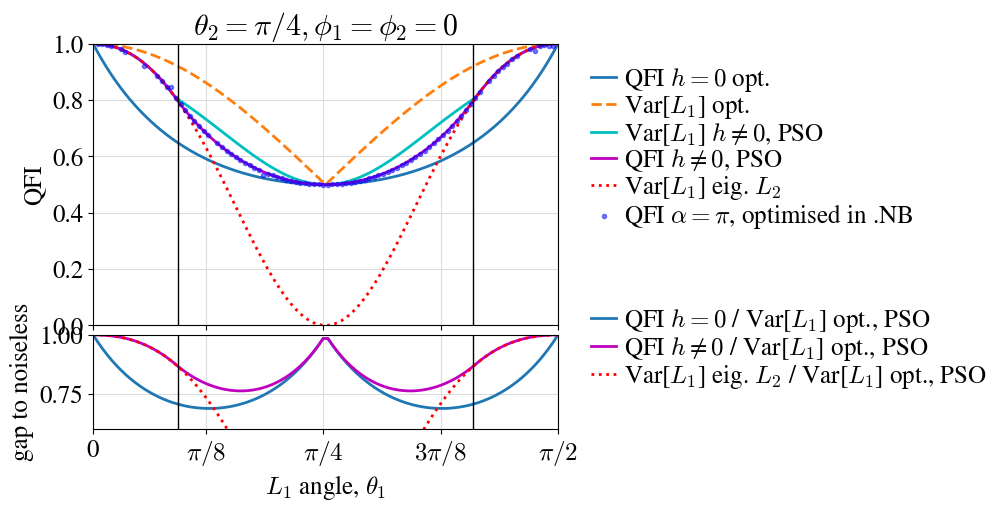

In [5]:
# load and sort new results
θs_sorted = data.sort_values(by="θ1")["θ1"]
qfi_swarm_sorted = data.sort_values(by="θ1")["qfi_swarm"]
VarL1_swarm_sorted = data.sort_values(by="θ1")["VarL1_swarm"]
VarL1_eig_L2_sorted = data.sort_values(by="θ1")["VarL1_eig_L2"]
VarL1_opt_sorted = data.sort_values(by="θ1")["VarL1_opt"]

# previous results
θs_HD = np.linspace(0, π / 2, 1000)
Fq_zero_h_opt = np.min(
    [
        1 / np.cos(2 * θs_HD) * (1 / np.cos(2 * θs_HD) + np.tan(2 * θs_HD)),
        1 / np.cos(2 * θs_HD) * (1 / np.cos(2 * θs_HD) - np.tan(2 * θs_HD)),
    ],
    axis=0,
)

Fq_noiseless = np.max([np.cos(θs_HD) ** 2, np.sin(θs_HD) ** 2], axis=0)

diff = qfi_swarm_sorted - VarL1_eig_L2_sorted
θ1_transition = θs_sorted[np.searchsorted(diff, 1e-4)]

# load mathematica results with alpha = pi with columns: theta1, QFI, p1
file = f"../data/random_Hermitian_L1_L2/qubit_mathematica_half_way.txt"
alpha_pi_data = np.loadtxt(file, delimiter=",")

# plotting
fig, axs = plt.subplots(
    2,
    1,
    figsize=(6, 5),
    sharex=True,
    gridspec_kw=dict(height_ratios=(3, 1), hspace=0.05),
)

ax = axs[0]
ax.plot(θs_HD, Fq_zero_h_opt, label=r"QFI $h=0$ opt.", linestyle="-")
ax.plot(θs_HD, Fq_noiseless, label=r"Var[$L_1$] opt.", linestyle="--")
# ax.scatter(θs_sorted, VarL1_opt_sorted, marker='+', label=r'Var[$L_1$] opt., PSO', color='y')
ax.plot(θs_sorted, VarL1_swarm_sorted, label=r"Var[$L_1$] $h\neq0$, PSO", color="c")
ax.plot(θs_sorted, qfi_swarm_sorted, label=r"QFI $h\neq0$, PSO", color="m")
ax.plot(
    θs_sorted,
    VarL1_eig_L2_sorted,
    label=r"Var[$L_1$] eig. $L_2$",
    color="r",
    linestyle="dotted",
)
ax.scatter(
    alpha_pi_data[:, 0],
    alpha_pi_data[:, 1],
    label=r"QFI $\alpha=\pi$, optimised in .NB",
    color="b",
    marker=".",
    zorder=2,
    alpha=0.5,
)
ax.set(
    ylabel="QFI",
    # ylim=(0.5, 1),
    ylim=(0, 1),
    title=r"$\theta_2=\pi/4, \phi_1=\phi_2=0$",
)
legend(ax, loc=(1.05, 0.3))
grid(ax)
ax.axvline(θ1_transition, color="k", linewidth=1)
ax.axvline(π / 2 - θ1_transition, color="k", linewidth=1)

ax = axs[1]
θs_HD = θs_sorted
Fq_zero_h_opt = np.min(
    [
        1 / np.cos(2 * θs_HD) * (1 / np.cos(2 * θs_HD) + np.tan(2 * θs_HD)),
        1 / np.cos(2 * θs_HD) * (1 / np.cos(2 * θs_HD) - np.tan(2 * θs_HD)),
    ],
    axis=0,
)
ax.plot(
    θs_sorted,
    Fq_zero_h_opt / VarL1_opt_sorted,
    label=r"QFI $h=0$ / Var[$L_1$] opt., PSO",
)
ax.plot(
    θs_sorted,
    qfi_swarm_sorted / VarL1_opt_sorted,
    label=r"QFI $h\neq0$ / Var[$L_1$] opt., PSO",
    color="m",
)
ax.plot(
    θs_sorted,
    VarL1_eig_L2_sorted / VarL1_opt_sorted,
    label=r"Var[$L_1$] eig. $L_2$ / Var[$L_1$] opt., PSO",
    color="r",
    linestyle="dotted",
)
ax.set(
    ylabel="gap to noiseless",
    ylim=(0.6, 1),
    xlabel=r"$L_1$ angle, $\theta_1$",
    xlim=lim(data["θ1"]),
)
legend(ax, loc=(1.05, 0.3))
grid(ax)
ax.axvline(θ1_transition, color="k", linewidth=1)
ax.axvline(π / 2 - θ1_transition, color="k", linewidth=1)
gen_ticks = lambda v: [
    max(v / (len(v) - 1)) * x
    for x in [
        0,
        (len(v) - 1) // 4,
        (len(v) - 1) // 2,
        3 * (len(v) - 1) // 4,
        len(v) - 1,
    ]
]
ticks = gen_ticks(data["θ1"])
tick_labels = [0, r"$\pi/8$", r"$\pi/4$", r"$3\pi/8$", r"$\pi/2$"]
ax.set_xticks(ticks, tick_labels)


fig.savefig(
    f"{figdir}qubits/both_non-Herm_hneq0_RDM_5_no_complex_phase_half_way_QFI_vs_theta.pdf",
    bbox_inches="tight",
)
plt.show()

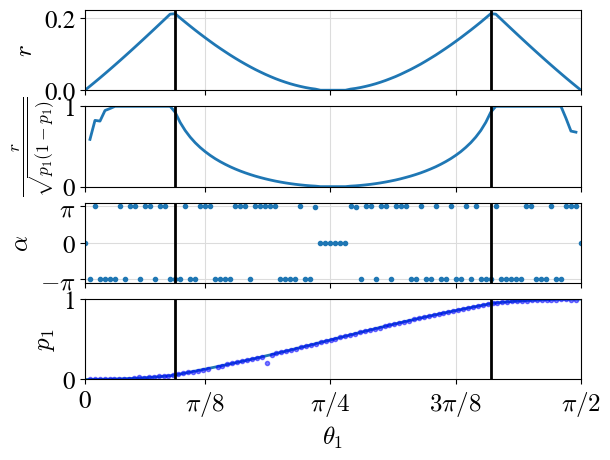

In [7]:
# [r * np.cos(α), r * np.sin(α), p1 - 0.5]
data_ρS = []
for ρS in data["ρS_swarm"]:
    pv = Pauli_vector(ρS)[1:].real
    r = np.sqrt(pv[0] ** 2 + pv[1] ** 2)
    α = np.arctan2(pv[1], pv[0])
    p1 = pv[2] + 0.5
    data_ρS.append(
        dict(
            pv=pv,
            r=r,
            α=α,
            p1=p1,
        )
    )
data_ρS = pd.DataFrame(data_ρS)

fig, axs = plt.subplots(4, 1, sharex=True)
ax = axs[0]
ax.plot(data["θ1"], data_ρS["r"])
ax.axvline(θ1_transition, color="k")
ax.axvline(π / 2 - θ1_transition, color="k")
ax.set(
    ylabel=r"$r$",
    ylim=(0, None),
)
grid(ax)

ax = axs[1]
ax.plot(data["θ1"], data_ρS["r"] / np.sqrt(data_ρS["p1"] * (1 - data_ρS["p1"])))
ax.axvline(θ1_transition, color="k")
ax.axvline(π / 2 - θ1_transition, color="k")
ax.set(
    ylabel=r"$\frac{r}{\sqrt{p_1(1-p_1)}}$",
    ylim=(0, 1),
)
grid(ax)

ax = axs[2]
ax.plot(data["θ1"], data_ρS["α"], ".")
ax.axvline(θ1_transition, color="k")
ax.axvline(π / 2 - θ1_transition, color="k")
ax.set(
    ylabel=r"$\alpha$",
)
grid(ax)
ax.set_yticks([-π, 0, π], [r"$-\pi$", 0, r"$\pi$"])

ax = axs[3]
ax.plot(data["θ1"], data_ρS["p1"])
ax.scatter(
    alpha_pi_data[:, 0],
    alpha_pi_data[:, 2],
    label=r"QFI $\alpha=\pi$, optimised in .NB",
    color="b",
    marker=".",
    zorder=2,
    alpha=0.5,
)
ax.axvline(θ1_transition, color="k")
ax.axvline(π / 2 - θ1_transition, color="k")
ax.set(
    ylabel=r"$p_1$",
    xlabel=r"$\theta_1$",
    xlim=lim(data["θ1"]),
    ylim=(0, 1),
)
grid(ax)
ticks = gen_ticks(data["θ1"])
tick_labels = [0, r"$\pi/8$", r"$\pi/4$", r"$3\pi/8$", r"$\pi/2$"]
ax.set_xticks(ticks, tick_labels)

plt.show()

Half way + noisy ancilla

In [ ]:
##########################
# user settings
D = 2

# num_data_points = 100
num_data_points = 50

# number_of_cores = 8
number_of_cores = 10
swarmsize = 1000
maxiter = 100
##########################

ϕ1, ϕ2 = 0, 0
θ2 = π / 4
θ1s = np.linspace(0, π / 2, num_data_points)

data = []
for θ1 in tqdm(θ1s):
    # construct analytic QFI function
    L1 = (np.cos(θ1) * σp + np.sin(θ1) * np.exp(1j * ϕ1) * σm) / 2
    L2 = np.cos(θ2) * (
        np.sin(θ1) * np.exp(-1j * ϕ1) * σp - np.cos(θ1) * σm
    ) / 2 + np.sin(θ2) * np.exp(1j * ϕ2) * σz / np.sqrt(2)

    Lsignal1 = np.kron(L1, I(D))
    Lsignal2 = np.kron(I(D), L1)

    Lnoise1 = np.kron(L2, I(D))
    Lnoise2 = np.kron(I(D), L2)

    QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel_no_prefactor(
        D**2, ket, Lsignal1, Lnoise1
    )

    lower_bounds = [-1 for _ in range(2 * D**2)]
    upper_bounds = [1 for _ in range(2 * D**2)]

    def objective(parts):
        return -QFI_fn(construct_ket_from_parts(D**2, parts))

    gs_opt, obj_opt = pso(
        objective,
        lower_bounds,
        upper_bounds,
        swarmsize=swarmsize,
        maxiter=maxiter,
        processes=number_of_cores,
        debug=False,
        print_end_msg=False,
    )

    ket_swarm = construct_ket_from_parts(D**2, gs_opt)
    qfi_swarm = -obj_opt

    a_b_dict = σpm_representation(D, L1)
    VarL1_opt = 4 * max(abs(a_b_dict["a"]) ** 2, abs(a_b_dict["b"]) ** 2)

    # eigenstates of L2
    VarL1_eig_L2 = 0
    ket_eig_L2 = 0
    for ψ in np.linalg.eig(L2).eigenvectors.T:
        V = variance(D, ψ, L1)
        if V > VarL1_eig_L2:
            VarL1_eig_L2 = V
            ket_eig_L2 = ψ

    QFI_noisy_ancilla = QFI_two_noise_operators_no_prefactor(
        2 * D, ket_swarm, Lsignal1, Lnoise1, Lnoise2
    ) + QFI_two_noise_operators_no_prefactor(
        2 * D, ket_swarm, Lsignal2, Lnoise1, Lnoise2
    )

    data.append(
        dict(
            qfi_swarm=qfi_swarm,
            QFI_noisy_ancilla=QFI_noisy_ancilla,
            VarL1_opt=VarL1_opt,
            VarL1_swarm=variance(2 * D, ket_swarm, Lsignal1),
            VarL1_eig_L2=VarL1_eig_L2,
            θ1=θ1,
            # θ2=θ2,
            a=a_b_dict["a"],
            b=a_b_dict["b"],
            ρS_swarm=ρS_swarm,
            ρS_vars=gs_opt,
            ket_eig_L2=ket_eig_L2,
            L1=L1,
            L2=L2,
        )
    )

data = pd.DataFrame(data)

In [ ]:
# data['ratio_qfi_swarm/VarL1_opt'] = data['qfi_swarm'] / data['VarL1_opt']
# data['ratio_VarL1_swarm/VarL1_opt'] = data['VarL1_swarm'] / data['VarL1_opt']
# data['ratio_qfi_swarm/VarL1_eig_L2'] = data['qfi_swarm'] / data['VarL1_eig_L2']

data["ratio_noisy_ancilla/noiseless_ancilla"] = (data["QFI_noisy_ancilla"] / 2) / data[
    "qfi_swarm"
]


file = f"../data/random_Hermitian_L1_L2/qubit_both_non-Herm_hneq0_RDM_5_no_complex_phase_half_way_noisy_ancilla.h5"
# data.to_hdf(file, key='df')
# data = pd.read_hdf(file, key='df')

print("L1 non-Hermitian, L2 non-Hermitian; h != 0 using RDM, noisy ancilla")
filtered_data = data[
    [
        c
        for c in data.columns
        # x in c
        if all(
            x not in c
            for x in [
                "ρS",
                "ket",
                "fidelity",
                "cat_",
                "angles",
                "φ2",
                "φ1",
                "θ2",
                "ratio_qfi_swarm",
            ]
        )  # ,	'θ1'])
        # x == c
        and c not in ["L1", "L2", "a", "b"]
    ]
]
display_data = filtered_data.reindex(sorted(filtered_data.columns)[::-1], axis=1)
pandas_float_format(".4g")
# display(display_data.sort_values(by='ratio_VarL1_swarm/VarL1_opt'))
# display(display_data.sort_values(by='ratio_qfi_swarm/VarL1_opt'))
# display(display_data.sort_values(by='VarL1_eig_L2'))

# print('Number of seeds with ratio > 1: ', len(display_data[display_data['ratio_qfi_swarm/VarL1_eig_L2'] > 1]))
# print('Number of seeds with ratio > 1.1: ', len(display_data[display_data['ratio_qfi_swarm/VarL1_eig_L2'] > 1.1]))

display(display_data.sort_values(by="ratio_noisy_ancilla/noiseless_ancilla"))
# display(display_data.sort_values(by='θ1'))
# display(display_data[display_data['ratio_qfi_swarm/VarL1_eig_L2'] > 1.1].sort_values(by='ratio_qfi_swarm/VarL1_eig_L2'))

In [ ]:
# load and sort new results
θs_sorted = data.sort_values(by="θ1")["θ1"]
qfi_swarm_sorted = data.sort_values(by="θ1")["qfi_swarm"]
VarL1_swarm_sorted = data.sort_values(by="θ1")["VarL1_swarm"]
VarL1_eig_L2_sorted = data.sort_values(by="θ1")["VarL1_eig_L2"]
VarL1_opt_sorted = data.sort_values(by="θ1")["VarL1_opt"]
QFI_noisy_ancilla_sorted = data.sort_values(by="θ1")["QFI_noisy_ancilla"]

# previous results
θs_HD = np.linspace(0, π / 2, 1000)
Fq_zero_h_opt = np.min(
    [
        1 / np.cos(2 * θs_HD) * (1 / np.cos(2 * θs_HD) + np.tan(2 * θs_HD)),
        1 / np.cos(2 * θs_HD) * (1 / np.cos(2 * θs_HD) - np.tan(2 * θs_HD)),
    ],
    axis=0,
)

Fq_noiseless = np.max([np.cos(θs_HD) ** 2, np.sin(θs_HD) ** 2], axis=0)

diff = qfi_swarm_sorted - VarL1_eig_L2_sorted
θ1_transition = θs_sorted[np.searchsorted(diff, 1e-4)]

# load mathematica results with alpha = pi with columns: theta1, QFI, p1
file = f"../data/random_Hermitian_L1_L2/qubit_mathematica_half_way.txt"
alpha_pi_data = np.loadtxt(file, delimiter=",")

# plotting
fig, axs = plt.subplots(
    2,
    1,
    figsize=(6, 5),
    sharex=True,
    gridspec_kw=dict(height_ratios=(3, 1), hspace=0.05),
)

ax = axs[0]
ax.plot(θs_HD, Fq_zero_h_opt, label=r"QFI $h=0$ opt.", linestyle="-")
ax.plot(θs_HD, Fq_noiseless, label=r"Var[$L_1$] opt.", linestyle="--")
# ax.scatter(θs_sorted, VarL1_opt_sorted, marker='+', label=r'Var[$L_1$] opt., PSO', color='y')
ax.plot(θs_sorted, VarL1_swarm_sorted, label=r"Var[$L_1$] $h\neq0$, PSO", color="c")
ax.plot(θs_sorted, qfi_swarm_sorted, label=r"QFI $h\neq0$, PSO", color="m")
ax.plot(
    θs_sorted,
    VarL1_eig_L2_sorted,
    label=r"Var[$L_1$] eig. $L_2$",
    color="r",
    linestyle="dotted",
)
ax.scatter(
    θs_sorted,
    QFI_noisy_ancilla_sorted / 2,
    label=r"QFI/2 $h\neq0$, PSO state, noisy ancilla",
    color="g",
    marker="s",
)
ax.scatter(
    alpha_pi_data[:, 0],
    alpha_pi_data[:, 1],
    label=r"QFI $\alpha=\pi$, optimised in .NB",
    color="b",
    marker=".",
    zorder=2,
    alpha=0.5,
)
ax.set(
    ylabel="QFI",
    # ylim=(0.5, 1),
    ylim=(0, 1),
    title=r"$\theta_2=\pi/4, \phi_1=\phi_2=0$",
)
legend(ax, loc=(1.05, 0.3))
grid(ax)
ax.axvline(θ1_transition, color="k", linewidth=1)
ax.axvline(π / 2 - θ1_transition, color="k", linewidth=1)

ax = axs[1]
θs_HD = θs_sorted
Fq_zero_h_opt = np.min(
    [
        1 / np.cos(2 * θs_HD) * (1 / np.cos(2 * θs_HD) + np.tan(2 * θs_HD)),
        1 / np.cos(2 * θs_HD) * (1 / np.cos(2 * θs_HD) - np.tan(2 * θs_HD)),
    ],
    axis=0,
)
ax.plot(
    θs_sorted,
    Fq_zero_h_opt / VarL1_opt_sorted,
    label=r"QFI $h=0$ / Var[$L_1$] opt., PSO",
)
ax.plot(
    θs_sorted,
    qfi_swarm_sorted / VarL1_opt_sorted,
    label=r"QFI $h\neq0$ / Var[$L_1$] opt., PSO",
    color="m",
)
ax.plot(
    θs_sorted,
    VarL1_eig_L2_sorted / VarL1_opt_sorted,
    label=r"Var[$L_1$] eig. $L_2$ / Var[$L_1$] opt., PSO",
    color="r",
    linestyle="dotted",
)
ax.set(
    ylabel="gap to noiseless",
    ylim=(0.6, 1),
    xlabel=r"$L_1$ angle, $\theta_1$",
    xlim=lim(data["θ1"]),
)
legend(ax, loc=(1.05, 0.3))
grid(ax)
ax.axvline(θ1_transition, color="k", linewidth=1)
ax.axvline(π / 2 - θ1_transition, color="k", linewidth=1)
gen_ticks = lambda v: [
    max(v / (len(v) - 1)) * x
    for x in [
        0,
        (len(v) - 1) // 4,
        (len(v) - 1) // 2,
        3 * (len(v) - 1) // 4,
        len(v) - 1,
    ]
]
ticks = gen_ticks(data["θ1"])
tick_labels = [0, r"$\pi/8$", r"$\pi/4$", r"$3\pi/8$", r"$\pi/2$"]
ax.set_xticks(ticks, tick_labels)


fig.savefig(
    f"{figdir}qubits/both_non-Herm_hneq0_RDM_5_no_complex_phase_half_way_QFI_vs_theta_noisy_ancilla.pdf",
    bbox_inches="tight",
)
plt.show()

In [58]:
# check the VarL2 to explain the jump
data2 = []
for i in range(len(data)):
    series = data.iloc[i]

    ket_swarm = construct_ket_from_parts(D**2, series["ρS_vars"])

    Lsignal1 = np.kron(series["L1"], I(D))
    Lsignal2 = np.kron(I(D), series["L1"])

    Lnoise1 = np.kron(series["L2"], I(D))
    Lnoise2 = np.kron(I(D), series["L2"])

    Fq_Lsig1_2noise = QFI_two_noise_operators_no_prefactor(
        2 * D, ket_swarm, Lsignal1, Lnoise1, Lnoise2
    )
    Fq_Lsig2_2noise = QFI_two_noise_operators_no_prefactor(
        2 * D, ket_swarm, Lsignal2, Lnoise1, Lnoise2
    )
    QFI_noisy_ancilla = Fq_Lsig1_2noise + Fq_Lsig2_2noise

    varLsig1 = variance(2 * D, ket_swarm, Lsignal1)
    varLsig2 = variance(2 * D, ket_swarm, Lsignal2)

    data2.append(
        dict(
            θ1=series["θ1"],
            Fq_Lsig1_2noise=Fq_Lsig1_2noise,
            Fq_Lsig2_2noise=Fq_Lsig2_2noise,
            QFI_noisy_ancilla=QFI_noisy_ancilla,
            varLsig1=varLsig1,
            varLsig2=varLsig2,
        )
    )
data2 = pd.DataFrame(data2)

In [ ]:
# plotting
fig, axs = plt.subplots(
    2,
    1,
    figsize=(6, 6),
    sharex=True,
    gridspec_kw=dict(height_ratios=(3, 1), hspace=0.1),
)

ax = axs[0]
θs_HD = np.linspace(0, π / 2, 1000)
Fq_noiseless = np.max([np.cos(θs_HD) ** 2, np.sin(θs_HD) ** 2], axis=0)
ax.plot(θs_HD, Fq_noiseless, label="QFI L1 opt")
ax.plot(θs_sorted, qfi_swarm_sorted, label="QFI L1; L3", color="m")
ax.plot(data2["θ1"], (data2["varLsig1"] + data2["varLsig2"]) / 2, label="QFI/2 L1,L2")
ax.plot(data2["θ1"], data2["QFI_noisy_ancilla"] / 2, label="QFI/2 L1,L2; L3,L4")
ax.plot(data2["θ1"], data2["varLsig1"], label="QFI L1", linestyle=":")
ax.plot(data2["θ1"], data2["varLsig2"], label="QFI L2", linestyle=":")
ax.plot(data2["θ1"], data2["Fq_Lsig1_2noise"], label="QFI L1; L3,L4", linestyle="--")
ax.plot(data2["θ1"], data2["Fq_Lsig2_2noise"], label="QFI L2; L3,L4", linestyle="--")
ax.set(
    ylabel="QFI",
    ylim=(0, 1),
)
legend(ax, loc=(1.05, 0.3))
grid(ax)
ax.axvline(θ1_transition, color="k", linewidth=1)
ax.axhline(0.5, color="k", linewidth=1)
ax.axvline(π / 2 - θ1_transition, color="k", linewidth=1)

ax = axs[1]
ax.plot(
    data2["θ1"],
    (data2["QFI_noisy_ancilla"] / 2) / qfi_swarm_sorted,
    label="[QFI/2 L1,L2; L3,L4]\n/ [QFI L1; L3]",
)
ax.plot(
    data2["θ1"],
    (data2["QFI_noisy_ancilla"] / 2) / ((data2["varLsig1"] + data2["varLsig2"]) / 2),
    label="[QFI/2 L1,L2; L3,L4]\n/ [QFI/2 L1,L2]",
    linestyle="--",
)
ax.set(
    ylabel="ratio",
    ylim=(0, 1),
    xlabel=r"$L_1$ angle, $\theta_1$",
    xlim=lim(data["θ1"]),
)
legend(ax, loc=(1.05, 0))
grid(ax)
ax.axvline(θ1_transition, color="k", linewidth=1)
ax.axvline(π / 2 - θ1_transition, color="k", linewidth=1)
ax.set_xticks(ticks, tick_labels)
ax.set_yticks([0, 0.5, 1])

fig.savefig(
    f"{figdir}qubits/both_non-Herm_hneq0_RDM_5_no_complex_phase_half_way_QFI_vs_theta_noisy_ancilla_busy.pdf",
    bbox_inches="tight",
)
plt.show()

Halfway + noisy ancilla + optimise over 2-site QFI

In [10]:
##########################
# user settings
D = 2

# num_data_points = 100
num_data_points = 50

# number_of_cores = 8
number_of_cores = 10
swarmsize = 1000
maxiter = 100
##########################

ϕ1, ϕ2 = 0, 0
θ2 = π / 4
θ1s = np.linspace(0, π / 2, num_data_points)

In [ ]:
data = []
for θ1 in tqdm(θ1s):
    # construct analytic QFI function
    L1 = (np.cos(θ1) * σp + np.sin(θ1) * np.exp(1j * ϕ1) * σm) / 2
    L2 = np.cos(θ2) * (
        np.sin(θ1) * np.exp(-1j * ϕ1) * σp - np.cos(θ1) * σm
    ) / 2 + np.sin(θ2) * np.exp(1j * ϕ2) * σz / np.sqrt(2)

    Lsignal1 = np.kron(L1, I(D))
    Lsignal2 = np.kron(I(D), L1)

    Lnoise1 = np.kron(L2, I(D))
    Lnoise2 = np.kron(I(D), L2)

    # QFI_fn = lambda ket : QFI_simultaneous_Lindblad_channel_no_prefactor(D ** 2, ket, Lsignal1, Lnoise1)
    QFI_fn = lambda ket: (
        QFI_two_noise_operators_no_prefactor(D**2, ket, Lsignal1, Lnoise1, Lnoise2)
        + QFI_two_noise_operators_no_prefactor(D**2, ket, Lsignal2, Lnoise1, Lnoise2)
    )

    lower_bounds = [-1 for _ in range(2 * D**2)]
    upper_bounds = [1 for _ in range(2 * D**2)]

    def objective(parts):
        return -QFI_fn(construct_ket_from_parts(D**2, parts))

    gs_opt, obj_opt = pso(
        objective,
        lower_bounds,
        upper_bounds,
        swarmsize=swarmsize,
        maxiter=maxiter,
        processes=number_of_cores,
        debug=False,
        print_end_msg=False,
    )

    ket_swarm = construct_ket_from_parts(D**2, gs_opt)
    qfi_swarm = -obj_opt

    a_b_dict = σpm_representation(D, L1)
    VarL1_opt = 4 * max(abs(a_b_dict["a"]) ** 2, abs(a_b_dict["b"]) ** 2)

    # eigenstates of L2
    VarL1_eig_L2 = 0
    ket_eig_L2 = 0
    for ψ in np.linalg.eig(L2).eigenvectors.T:
        V = variance(D, ψ, L1)
        if V > VarL1_eig_L2:
            VarL1_eig_L2 = V
            ket_eig_L2 = ψ

    ###
    Fq_Lsig1_1noise = QFI_simultaneous_Lindblad_channel_no_prefactor(
        D**2, ket_swarm, Lsignal1, Lnoise1
    )
    Fq_Lsig1_2noise = QFI_two_noise_operators_no_prefactor(
        D**2, ket_swarm, Lsignal1, Lnoise1, Lnoise2
    )
    Fq_Lsig2_2noise = QFI_two_noise_operators_no_prefactor(
        D**2, ket_swarm, Lsignal2, Lnoise1, Lnoise2
    )
    varLsig1 = variance(D**2, ket_swarm, Lsignal1)
    varLsig2 = variance(D**2, ket_swarm, Lsignal2)

    data.append(
        dict(
            QFI_noisy_ancilla=qfi_swarm,
            Fq_Lsig1_1noise=Fq_Lsig1_1noise,
            Fq_Lsig1_2noise=Fq_Lsig1_2noise,
            Fq_Lsig2_2noise=Fq_Lsig2_2noise,
            varLsig1=varLsig1,
            varLsig2=varLsig2,
            VarL1_opt=VarL1_opt,
            VarL1_eig_L2=VarL1_eig_L2,
            θ1=θ1,
            a=a_b_dict["a"],
            b=a_b_dict["b"],
            ket_swarm=ket_swarm,
            gs_opt=gs_opt,
            ket_eig_L2=ket_eig_L2,
            L1=L1,
            L2=L2,
        )
    )

data = pd.DataFrame(data)

In [7]:
file = f"../data/random_Hermitian_L1_L2/qubit_halfway_noisyancilla_optForL1L2L3L4.h5"
# data.to_hdf(file, key='df')
data = pd.read_hdf(file, key="df")

print("L1 non-Hermitian, L2 non-Hermitian; h != 0 using RDM, noisy ancilla")
filtered_data = data[
    [
        c
        for c in data.columns
        # x in c
        if all(
            x not in c
            for x in [
                "ρS",
                "ket",
                "fidelity",
                "cat_",
                "angles",
                "φ2",
                "φ1",
                "θ2",
                "ratio_qfi_swarm",
                "gs",
            ]
        )  # ,	'θ1'])
        # x == c
        and c not in ["L1", "L2", "a", "b"]
    ]
]
display_data = filtered_data.reindex(sorted(filtered_data.columns)[::-1], axis=1)
pandas_float_format(".3g")
display(display_data)

L1 non-Hermitian, L2 non-Hermitian; h != 0 using RDM, noisy ancilla


,θ1,varLsig2,varLsig1,VarL1_opt,VarL1_eig_L2,QFI_noisy_ancilla,Fq_Lsig2_2noise,Fq_Lsig1_2noise,Fq_Lsig1_1noise
0,0,0.527,0.473,1,1,1,0.527,0.473,0.473
1,0.0321,0.5,0.5,0.999,0.998,1,0.5,0.5,0.5
2,0.0641,0.5,0.5,0.996,0.991,1,0.5,0.5,0.5
3,0.0962,0.499,0.501,0.991,0.98,1,0.499,0.501,0.501
4,0.128,0.5,0.5,0.984,0.963,1,0.5,0.5,0.5
5,0.16,0.5,0.5,0.975,0.941,1,0.5,0.5,0.5
6,0.192,0.5,0.5,0.963,0.913,1,0.5,0.5,0.5
7,0.224,0.5,0.5,0.95,0.879,1,0.5,0.5,0.5
8,0.256,0.5,0.5,0.936,0.839,1,0.5,0.5,0.5
9,0.289,0.5,0.5,0.919,0.793,1,0.5,0.5,0.5


In [14]:
# bell state QFI
ket_bell = (
    np.kron(vacuum(D), vacuum(D)) + np.kron(Jz_up_state(D), Jz_up_state(D))
) / np.sqrt(2)

data_bell = []
for θ1 in tqdm(θ1s):
    # construct analytic QFI function
    L1 = (np.cos(θ1) * σp + np.sin(θ1) * np.exp(1j * ϕ1) * σm) / 2
    L2 = np.cos(θ2) * (
        np.sin(θ1) * np.exp(-1j * ϕ1) * σp - np.cos(θ1) * σm
    ) / 2 + np.sin(θ2) * np.exp(1j * ϕ2) * σz / np.sqrt(2)

    Lsignal1 = np.kron(L1, I(D))
    Lsignal2 = np.kron(I(D), L1)

    Lnoise1 = np.kron(L2, I(D))
    Lnoise2 = np.kron(I(D), L2)

    # QFI_fn = lambda ket : QFI_simultaneous_Lindblad_channel_no_prefactor(D ** 2, ket, Lsignal1, Lnoise1)
    QFI_fn = lambda ket: (
        QFI_two_noise_operators_no_prefactor(D**2, ket, Lsignal1, Lnoise1, Lnoise2)
        + QFI_two_noise_operators_no_prefactor(D**2, ket, Lsignal2, Lnoise1, Lnoise2)
    )

    qfi_swarm = QFI_fn(ket_bell)

    Fq_Lsig1_1noise = QFI_simultaneous_Lindblad_channel_no_prefactor(
        D**2, ket_bell, Lsignal1, Lnoise1
    )
    Fq_Lsig2_1noise = QFI_simultaneous_Lindblad_channel_no_prefactor(
        D**2, ket_bell, Lsignal2, Lnoise2
    )
    Fq_Lsig1_2noise = QFI_two_noise_operators_no_prefactor(
        D**2, ket_bell, Lsignal1, Lnoise1, Lnoise2
    )
    Fq_Lsig2_2noise = QFI_two_noise_operators_no_prefactor(
        D**2, ket_bell, Lsignal2, Lnoise1, Lnoise2
    )
    varLsig1 = variance(D**2, ket_bell, Lsignal1)
    varLsig2 = variance(D**2, ket_bell, Lsignal2)

    data_bell.append(
        dict(
            QFI_noisy_ancilla=qfi_swarm,
            Fq_Lsig1_1noise=Fq_Lsig1_1noise,
            Fq_Lsig2_1noise=Fq_Lsig2_1noise,
            Fq_Lsig1_2noise=Fq_Lsig1_2noise,
            Fq_Lsig2_2noise=Fq_Lsig2_2noise,
            varLsig1=varLsig1,
            varLsig2=varLsig2,
            θ1=θ1,
            # ket_swarm=ket_swarm,
            L1=L1,
            L2=L2,
        )
    )

data_bell = pd.DataFrame(data_bell)

file = (
    f"../data/random_Hermitian_L1_L2/qubit_halfway_noisyancilla_optForL1L2L3L4_Bell.h5"
)
data_bell.to_hdf(file, key="df")
# data_bell = pd.read_hdf(file, key='df')

  0%|          | 0/50 [00:00<?, ?it/s]

In [16]:
data_entropy = []
for ket in data["ket_swarm"]:
    # Doesn't matter which one we reduce over
    data_entropy.append(entropy(RDM(2, ket)))
data_entropy = np.array(data_entropy)

ValueError: x and y must have same first dimension, but have shapes (50,) and (100,)

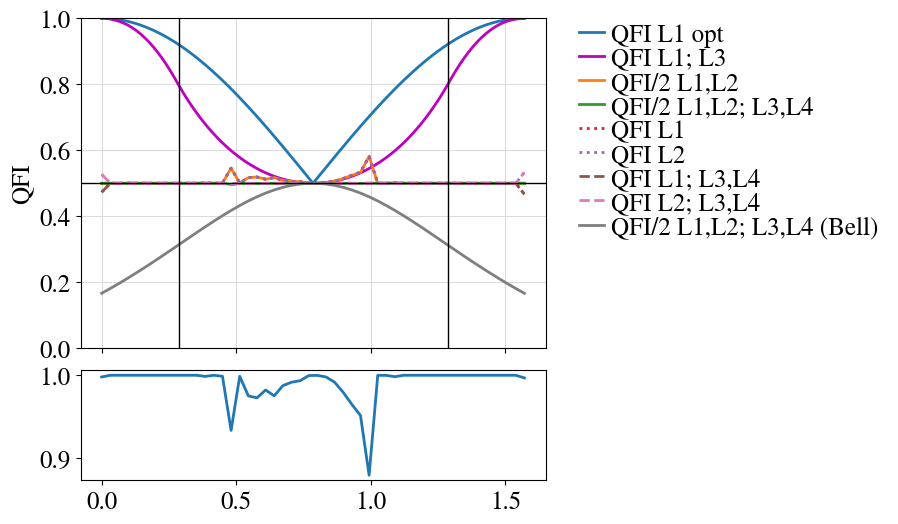

In [18]:
# plotting
fig, axs = plt.subplots(
    2,
    1,
    figsize=(6, 6),
    sharex=True,
    gridspec_kw=dict(height_ratios=(3, 1), hspace=0.1),
)

ax = axs[0]
θs_HD = np.linspace(0, π / 2, 1000)
Fq_noiseless = np.max([np.cos(θs_HD) ** 2, np.sin(θs_HD) ** 2], axis=0)
ax.plot(θs_HD, Fq_noiseless, label="QFI L1 opt")
ax.plot(θs_sorted, qfi_swarm_sorted, label="QFI L1; L3", color="m")
ax.plot(data["θ1"], (data["varLsig1"] + data["varLsig2"]) / 2, label="QFI/2 L1,L2")
ax.plot(data["θ1"], data["QFI_noisy_ancilla"] / 2, label="QFI/2 L1,L2; L3,L4")
ax.plot(data["θ1"], data["varLsig1"], label="QFI L1", linestyle=":")
ax.plot(data["θ1"], data["varLsig2"], label="QFI L2", linestyle=":")
ax.plot(data["θ1"], data["Fq_Lsig1_2noise"], label="QFI L1; L3,L4", linestyle="--")
ax.plot(data["θ1"], data["Fq_Lsig2_2noise"], label="QFI L2; L3,L4", linestyle="--")
ax.plot(
    data_bell["θ1"],
    data_bell["QFI_noisy_ancilla"] / 2,
    label="QFI/2 L1,L2; L3,L4 (Bell)",
)
ax.set(
    ylabel="QFI",
    ylim=(0, 1),
)
legend(ax, loc=(1.05, 0.3))
grid(ax)
ax.axvline(θ1_transition, color="k", linewidth=1)
ax.axhline(0.5, color="k", linewidth=1)
ax.axvline(π / 2 - θ1_transition, color="k", linewidth=1)

ax = axs[1]
ax.plot(data["θ1"], data_entropy / np.log(D), label="entropy / log(2)")
ax.plot(
    data["θ1"],
    (data["QFI_noisy_ancilla"] / 2) / qfi_swarm_sorted,
    label="[QFI/2 L1,L2; L3,L4]\n/ [QFI L1; L3]",
    linestyle="--",
)
ax.plot(
    data["θ1"],
    (data["QFI_noisy_ancilla"] / 2) / ((data["varLsig1"] + data["varLsig2"]) / 2),
    label="[QFI/2 L1,L2; L3,L4]\n/ [QFI/2 L1,L2]",
    linestyle=":",
)
ax.set(
    ylabel="ratio",
    ylim=(0.5, 1.02),
    xlabel=r"$L_1$ angle, $\theta_1$",
    xlim=lim(data["θ1"]),
)
legend(ax, loc=(1.05, 0))
grid(ax)
ax.axvline(θ1_transition, color="k", linewidth=1)
ax.axvline(π / 2 - θ1_transition, color="k", linewidth=1)
ax.set_xticks(ticks, tick_labels)

fig.savefig(f"{figdir}qubits/qubit_noisyancilla_not_Bell.pdf", bbox_inches="tight")
plt.show()

NameError: name 'data_entropy' is not defined

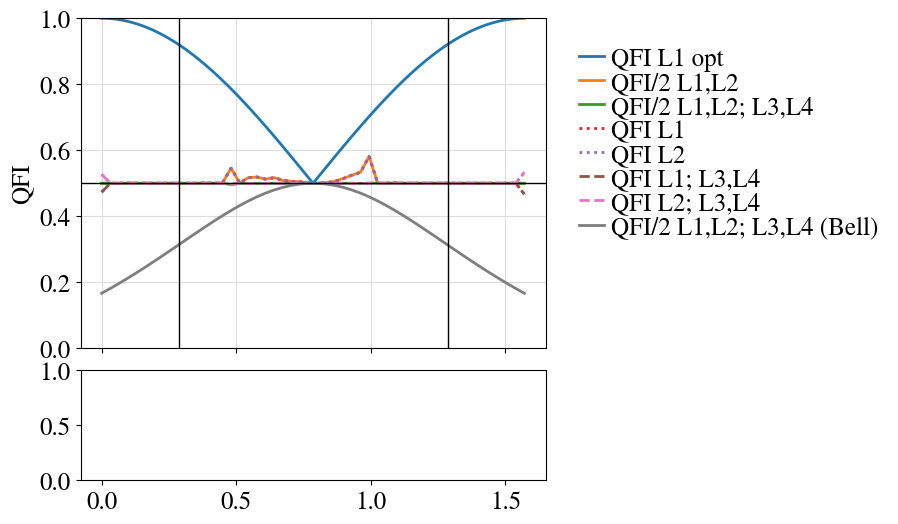

In [9]:
# plotting
fig, axs = plt.subplots(
    2,
    1,
    figsize=(6, 6),
    sharex=True,
    gridspec_kw=dict(height_ratios=(3, 1), hspace=0.1),
)

ax = axs[0]
θs_HD = np.linspace(0, π / 2, 1000)
Fq_noiseless = np.max([np.cos(θs_HD) ** 2, np.sin(θs_HD) ** 2], axis=0)
ax.plot(θs_HD, Fq_noiseless, label="QFI L1 opt")
# ax.plot(θs_sorted, qfi_swarm_sorted, label="QFI L1; L3", color="m")
ax.plot(data["θ1"], (data["varLsig1"] + data["varLsig2"]) / 2, label="QFI/2 L1,L2")
ax.plot(data["θ1"], data["QFI_noisy_ancilla"] / 2, label="QFI/2 L1,L2; L3,L4")
ax.plot(data["θ1"], data["varLsig1"], label="QFI L1", linestyle=":")
ax.plot(data["θ1"], data["varLsig2"], label="QFI L2", linestyle=":")
ax.plot(data["θ1"], data["Fq_Lsig1_2noise"], label="QFI L1; L3,L4", linestyle="--")
ax.plot(data["θ1"], data["Fq_Lsig2_2noise"], label="QFI L2; L3,L4", linestyle="--")
ax.plot(
    data_bell["θ1"],
    data_bell["QFI_noisy_ancilla"] / 2,
    label="QFI/2 L1,L2; L3,L4 (Bell)",
)
ax.set(
    ylabel="QFI",
    ylim=(0, 1),
)
legend(ax, loc=(1.05, 0.3))
grid(ax)
ax.axvline(θ1_transition, color="k", linewidth=1)
ax.axhline(0.5, color="k", linewidth=1)
ax.axvline(π / 2 - θ1_transition, color="k", linewidth=1)

ax = axs[1]
ax.plot(data["θ1"], data_entropy / np.log(D), label="entropy / log(2)")
# ax.plot(
#     data["θ1"],
#     (data["QFI_noisy_ancilla"] / 2) / qfi_swarm_sorted,
#     label="[QFI/2 L1,L2; L3,L4]\n/ [QFI L1; L3]",
#     linestyle="--",
# )
ax.plot(
    data["θ1"],
    (data["QFI_noisy_ancilla"] / 2) / ((data["varLsig1"] + data["varLsig2"]) / 2),
    label="[QFI/2 L1,L2; L3,L4]\n/ [QFI/2 L1,L2]",
    linestyle=":",
)
ax.set(
    ylabel="ratio",
    ylim=(0.5, 1.02),
    xlabel=r"$L_1$ angle, $\theta_1$",
    xlim=lim(data["θ1"]),
)
legend(ax, loc=(1.05, 0))
grid(ax)
ax.axvline(θ1_transition, color="k", linewidth=1)
ax.axvline(π / 2 - θ1_transition, color="k", linewidth=1)
ax.set_xticks(ticks, tick_labels)

fig.savefig(
    f"{figdir}qubits/qubit_noisyancilla_not_Bell_no-qfi_swarm_sorted.pdf",
    bbox_inches="tight",
)
plt.show()

In [8]:
file = (
    f"../data/random_Hermitian_L1_L2/qubit_halfway_noisyancilla_optForL1L2L3L4_Bell.h5"
)
# data_bell.to_hdf(file, key='df')
data_bell = pd.read_hdf(file, key="df")

Are the states symmetric?

In [97]:
# TODO: define the exchange operator in the J_z basis z1, z2 of the two sites.
# TODO: can't I just check that the RDMs are the same?
def exchange_op(D):
    pass

Unextended parallel case

No need to optimise over separable states, just have to check the product of the eigenstates of local L2

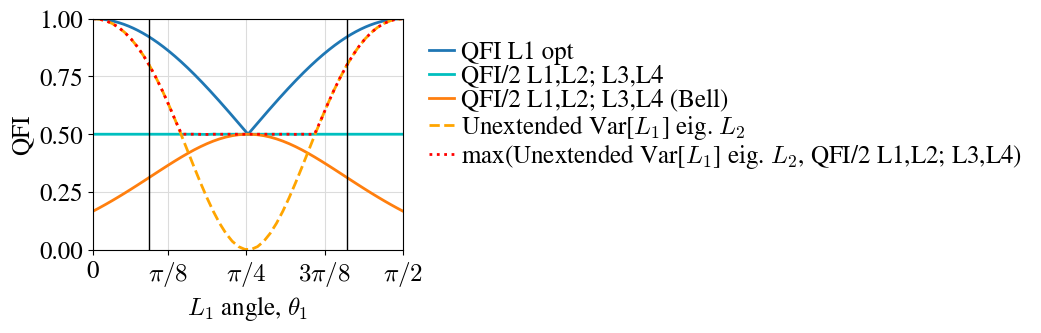

In [114]:
# plotting
fig, axs = plt.subplots(
    1,
    1,
    figsize=(4, 3),
    sharex=True,
    # gridspec_kw=dict(height_ratios=(3, 1), hspace=0.1),
)

# ax = axs[0]
ax = axs
θs_HD = np.linspace(0, π / 2, 1000)
Fq_noiseless = np.max([np.cos(θs_HD) ** 2, np.sin(θs_HD) ** 2], axis=0)
ax.plot(θs_HD, Fq_noiseless, label="QFI L1 opt")
# ax.plot(θs_sorted, qfi_swarm_sorted, label="QFI L1; L3", color="m")
# ax.plot(data["θ1"], (data["varLsig1"] + data["varLsig2"]) / 2, label="QFI/2 L1,L2")
ax.plot(
    data["θ1"], data["QFI_noisy_ancilla"] / 2, label="QFI/2 L1,L2; L3,L4", color="c"
)
# ax.plot(data["θ1"], data["varLsig1"], label="QFI L1", linestyle=":")
# ax.plot(data["θ1"], data["varLsig2"], label="QFI L2", linestyle=":")
# ax.plot(data["θ1"], data["Fq_Lsig1_2noise"], label="QFI L1; L3,L4", linestyle="--")
# ax.plot(data["θ1"], data["Fq_Lsig2_2noise"], label="QFI L2; L3,L4", linestyle="--")
ax.plot(
    data_bell["θ1"],
    data_bell["QFI_noisy_ancilla"] / 2,
    label="QFI/2 L1,L2; L3,L4 (Bell)",
)
ax.plot(
    data["θ1"],
    data["VarL1_eig_L2"],
    color="orange",
    linestyle="--",
    label=r"Unextended Var[$L_1$] eig. $L_2$",
)
ax.plot(
    data["θ1"],
    np.maximum(data["VarL1_eig_L2"], data["QFI_noisy_ancilla"] / 2),
    color="r",
    linestyle=":",
    label=r"max(Unextended Var[$L_1$] eig. $L_2$, QFI/2 L1,L2; L3,L4)",
)
ax.set(
    ylabel="QFI",
    ylim=(0, 1),
    xlabel=r"$L_1$ angle, $\theta_1$",
    xlim=lim(data["θ1"]),
)
legend(ax, loc=(1.05, 0.3))
grid(ax)
ax.axvline(θ1_transition, color="k", linewidth=1)
# ax.axhline(0.5, color="k", linewidth=1)
ax.axvline(π / 2 - θ1_transition, color="k", linewidth=1)
ax.set_xticks(ticks, tick_labels)

# fig.savefig(f"{figdir}qubits/qubit_noisyancilla_not_Bell_no-qfi_swarm_sorted.pdf", bbox_inches="tight")
plt.show()

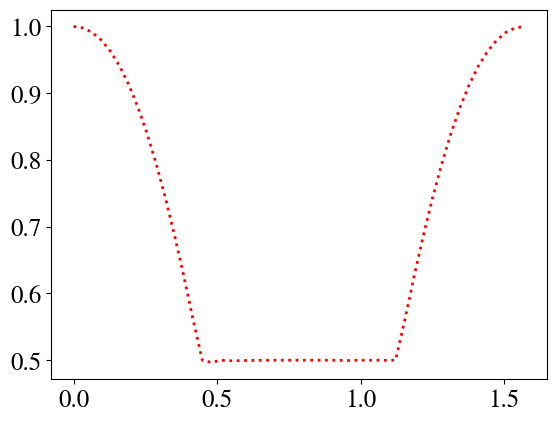

In [115]:
file = f"../data/random_Hermitian_L1_L2/qubit_halfway_noisyancilla_optForL1L2L3L4.h5"
data_parallel = pd.read_hdf(file, key="df")
plt.plot(
    data_parallel["θ1"],
    np.maximum(data_parallel["VarL1_eig_L2"], data_parallel["QFI_noisy_ancilla"] / 2),
    color="r",
    linestyle=":",
    label=r"max(Unextended Var[$L_1$] eig. $L_2$, QFI/2 L1,L2; L3,L4)",
)

Larger search just to be sure of the discontinuity

In [102]:
##########################
# user settings
D = 2

# num_data_points = 100
num_data_points = 50

# number_of_cores = 8
number_of_cores = 10
# swarmsize = 1000
# swarmsize = 5000
swarmsize = 10000
# maxiter = 100
maxiter = 1000
##########################

ϕ1, ϕ2 = 0, 0
θ2 = π / 4
θ1s = np.linspace(0, π / 2, num_data_points)

In [103]:
data = []
for θ1 in tqdm(θ1s):
    # construct analytic QFI function
    L1 = (np.cos(θ1) * σp + np.sin(θ1) * np.exp(1j * ϕ1) * σm) / 2
    L2 = np.cos(θ2) * (
        np.sin(θ1) * np.exp(-1j * ϕ1) * σp - np.cos(θ1) * σm
    ) / 2 + np.sin(θ2) * np.exp(1j * ϕ2) * σz / np.sqrt(2)

    Lsignal1 = np.kron(L1, I(D))
    Lsignal2 = np.kron(I(D), L1)

    Lnoise1 = np.kron(L2, I(D))
    Lnoise2 = np.kron(I(D), L2)

    # QFI_fn = lambda ket : QFI_simultaneous_Lindblad_channel_no_prefactor(D ** 2, ket, Lsignal1, Lnoise1)
    QFI_fn = lambda ket: (
        QFI_two_noise_operators_no_prefactor(D**2, ket, Lsignal1, Lnoise1, Lnoise2)
        + QFI_two_noise_operators_no_prefactor(D**2, ket, Lsignal2, Lnoise1, Lnoise2)
    )

    lower_bounds = [-1 for _ in range(2 * D**2)]
    upper_bounds = [1 for _ in range(2 * D**2)]

    def objective(parts):
        return -QFI_fn(construct_ket_from_parts(D**2, parts))

    gs_opt, obj_opt = pso(
        objective,
        lower_bounds,
        upper_bounds,
        swarmsize=swarmsize,
        maxiter=maxiter,
        processes=number_of_cores,
        debug=False,
        print_end_msg=False,
    )

    ket_swarm = construct_ket_from_parts(D**2, gs_opt)
    qfi_swarm = -obj_opt

    a_b_dict = σpm_representation(D, L1)
    VarL1_opt = 4 * max(abs(a_b_dict["a"]) ** 2, abs(a_b_dict["b"]) ** 2)

    # eigenstates of L2
    VarL1_eig_L2 = 0
    ket_eig_L2 = 0
    for ψ in np.linalg.eig(L2).eigenvectors.T:
        V = variance(D, ψ, L1)
        if V > VarL1_eig_L2:
            VarL1_eig_L2 = V
            ket_eig_L2 = ψ

    ###
    Fq_Lsig1_1noise = QFI_simultaneous_Lindblad_channel_no_prefactor(
        D**2, ket_swarm, Lsignal1, Lnoise1
    )
    Fq_Lsig1_2noise = QFI_two_noise_operators_no_prefactor(
        D**2, ket_swarm, Lsignal1, Lnoise1, Lnoise2
    )
    Fq_Lsig2_2noise = QFI_two_noise_operators_no_prefactor(
        D**2, ket_swarm, Lsignal2, Lnoise1, Lnoise2
    )
    varLsig1 = variance(D**2, ket_swarm, Lsignal1)
    varLsig2 = variance(D**2, ket_swarm, Lsignal2)

    data.append(
        dict(
            QFI_noisy_ancilla=qfi_swarm,
            Fq_Lsig1_1noise=Fq_Lsig1_1noise,
            Fq_Lsig1_2noise=Fq_Lsig1_2noise,
            Fq_Lsig2_2noise=Fq_Lsig2_2noise,
            varLsig1=varLsig1,
            varLsig2=varLsig2,
            VarL1_opt=VarL1_opt,
            VarL1_eig_L2=VarL1_eig_L2,
            θ1=θ1,
            a=a_b_dict["a"],
            b=a_b_dict["b"],
            ket_swarm=ket_swarm,
            gs_opt=gs_opt,
            ket_eig_L2=ket_eig_L2,
            L1=L1,
            L2=L2,
        )
    )

data = pd.DataFrame(data)

  0%|          | 0/50 [00:00<?, ?it/s]

In [105]:
file = f"../data/random_Hermitian_L1_L2/qubit_halfway_noisy-ancilla_optForL1L2L3L4_larger-search.h5"
# data.to_hdf(file, key='df')
data = pd.read_hdf(file, key="df")

print("L1 non-Hermitian, L2 non-Hermitian; h != 0 using RDM, noisy ancilla")
filtered_data = data[
    [
        c
        for c in data.columns
        # x in c
        if all(
            x not in c
            for x in [
                "ρS",
                "ket",
                "fidelity",
                "cat_",
                "angles",
                "φ2",
                "φ1",
                "θ2",
                "ratio_qfi_swarm",
                "gs",
            ]
        )  # ,	'θ1'])
        # x == c
        and c not in ["L1", "L2", "a", "b"]
    ]
]
display_data = filtered_data.reindex(sorted(filtered_data.columns)[::-1], axis=1)
pandas_float_format(".3g")
display(display_data)

L1 non-Hermitian, L2 non-Hermitian; h != 0 using RDM, noisy ancilla


,θ1,varLsig2,varLsig1,VarL1_opt,VarL1_eig_L2,QFI_noisy_ancilla,Fq_Lsig2_2noise,Fq_Lsig1_2noise,Fq_Lsig1_1noise
0,0,0.282,0.718,1,1,1,0.282,0.718,0.718
1,0.0321,0.5,0.5,0.999,0.998,1,0.5,0.5,0.5
2,0.0641,0.5,0.5,0.996,0.991,1,0.5,0.5,0.5
3,0.0962,0.5,0.5,0.991,0.98,1,0.5,0.5,0.5
4,0.128,0.5,0.5,0.984,0.963,1,0.5,0.5,0.5
5,0.16,0.5,0.5,0.975,0.941,1,0.5,0.5,0.5
6,0.192,0.5,0.5,0.963,0.913,1,0.5,0.5,0.5
7,0.224,0.5,0.5,0.95,0.879,1,0.5,0.5,0.5
8,0.256,0.5,0.5,0.936,0.839,1,0.5,0.5,0.5
9,0.289,0.5,0.5,0.919,0.793,1,0.5,0.5,0.5


In [107]:
data_entropy = []
for ket in data["ket_swarm"]:
    data_entropy.append(entanglement_entropy(D, ket))
data_entropy = np.array(data_entropy)

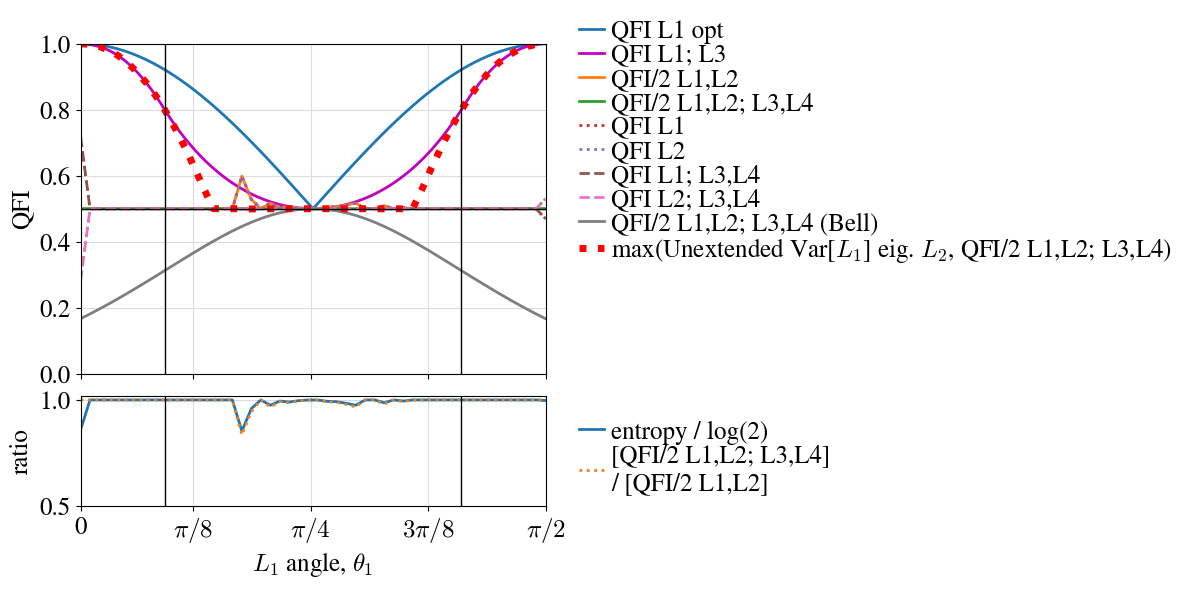

In [113]:
file = (
    f"../data/random_Hermitian_L1_L2/qubit_halfway_noisyancilla_optForL1L2L3L4_Bell.h5"
)
data_bell = pd.read_hdf(file, key="df")

# plotting
fig, axs = plt.subplots(
    2,
    1,
    figsize=(6, 6),
    sharex=True,
    gridspec_kw=dict(height_ratios=(3, 1), hspace=0.1),
)

ax = axs[0]
θs_HD = np.linspace(0, π / 2, 1000)
Fq_noiseless = np.max([np.cos(θs_HD) ** 2, np.sin(θs_HD) ** 2], axis=0)
ax.plot(θs_HD, Fq_noiseless, label="QFI L1 opt")
ax.plot(θs_sorted, qfi_swarm_sorted, label="QFI L1; L3", color="m")
ax.plot(data["θ1"], (data["varLsig1"] + data["varLsig2"]) / 2, label="QFI/2 L1,L2")
ax.plot(data["θ1"], data["QFI_noisy_ancilla"] / 2, label="QFI/2 L1,L2; L3,L4")
ax.plot(data["θ1"], data["varLsig1"], label="QFI L1", linestyle=":")
ax.plot(data["θ1"], data["varLsig2"], label="QFI L2", linestyle=":")
ax.plot(data["θ1"], data["Fq_Lsig1_2noise"], label="QFI L1; L3,L4", linestyle="--")
ax.plot(data["θ1"], data["Fq_Lsig2_2noise"], label="QFI L2; L3,L4", linestyle="--")
ax.plot(
    data_bell["θ1"],
    data_bell["QFI_noisy_ancilla"] / 2,
    label="QFI/2 L1,L2; L3,L4 (Bell)",
)
ax.plot(
    data["θ1"],
    np.maximum(data["VarL1_eig_L2"], data["QFI_noisy_ancilla"] / 2),
    color="r",
    linestyle=":",
    label=r"max(Unextended Var[$L_1$] eig. $L_2$, QFI/2 L1,L2; L3,L4)",
    linewidth=5,
)
ax.set(
    ylabel="QFI",
    ylim=(0, 1),
)
legend(ax, loc=(1.05, 0.3))
grid(ax)
ax.axvline(θ1_transition, color="k", linewidth=1)
ax.axhline(0.5, color="k", linewidth=1)
ax.axvline(π / 2 - θ1_transition, color="k", linewidth=1)

ax = axs[1]
ax.plot(data["θ1"], data_entropy / np.log(D), label="entropy / log(2)")
# ax.plot(
#     data["θ1"],
#     (data["QFI_noisy_ancilla"] / 2) / qfi_swarm_sorted,
#     label="[QFI/2 L1,L2; L3,L4]\n/ [QFI L1; L3]",
#     linestyle="--",
# )
ax.plot(
    data["θ1"],
    (data["QFI_noisy_ancilla"] / 2) / ((data["varLsig1"] + data["varLsig2"]) / 2),
    label="[QFI/2 L1,L2; L3,L4]\n/ [QFI/2 L1,L2]",
    linestyle=":",
)
ax.set(
    ylabel="ratio",
    ylim=(0.5, 1.02),
    xlabel=r"$L_1$ angle, $\theta_1$",
    xlim=lim(data["θ1"]),
)
legend(ax, loc=(1.05, 0))
grid(ax)
ax.axvline(θ1_transition, color="k", linewidth=1)
ax.axvline(π / 2 - θ1_transition, color="k", linewidth=1)
ax.set_xticks(ticks, tick_labels)

# fig.savefig(f"{figdir}qubits/qubit_noisyancilla_not_Bell.pdf", bbox_inches="tight")
plt.show()

In [ ]:
file = f"../data/random_Hermitian_L1_L2/qubit_halfway_noisy-ancilla_optForL1L2L3L4_larger-search.h5"
data = pd.read_hdf(file, key="df")

In [ ]:
file = f"../data/random_Hermitian_L1_L2/qubit_halfway_noisy-ancilla_optForL1L2L3L4_larger-search.h5"
data = pd.read_hdf(file, key="df")

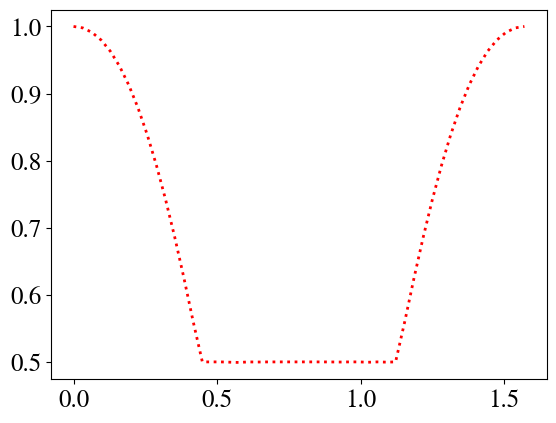

In [117]:
# file = f"../data/random_Hermitian_L1_L2/qubit_halfway_noisyancilla_optForL1L2L3L4.h5"
file = f"../data/random_Hermitian_L1_L2/qubit_halfway_noisy-ancilla_optForL1L2L3L4_larger-search.h5"
data_parallel = pd.read_hdf(file, key="df")
plt.plot(
    data_parallel["θ1"],
    np.maximum(data_parallel["VarL1_eig_L2"], data_parallel["QFI_noisy_ancilla"] / 2),
    color="r",
    linestyle=":",
    label=r"max(Unextended Var[$L_1$] eig. $L_2$, QFI/2 L1,L2; L3,L4)",
)

#### Splitting into re/im parts

Part orthogonal to the re/im parts of $L_1$ plane

In [ ]:
##########################
# user settings
D = 2

seed = 1234

number_of_cores = 8
swarmsize = 1000
maxiter = 100
##########################

seed_sequence = generate_seed_sequence(seed, length=3)

L20 = random_Hermitian_op(D, seed=seed_sequence[1])
L20perp = orthogonal_component(L20, I(D))
L20perp /= np.sqrt(ip(L20perp, L20perp))

L10 = random_op(D, seed=seed_sequence[0])
L10perp = orthogonal_component_from_set(L10, [L20perp, I(D)])
L10perp /= np.sqrt(ip(L10perp, L10perp))

L1 = L10perp
L2 = L20perp

reL1 = (L1 + dag(L1)) / 2
imL1 = (L1 - dag(L1)) / 2j
assert are_equal(L1, reL1 + 1j * imL1) & is_hermitian(reL1) & is_hermitian(imL1)
print(ip(reL1, imL1))
print(ip(reL1, imL1) / np.sqrt(ip(reL1, reL1) * ip(imL1, imL1)))

In [ ]:
seed = 4
seed_sequence = generate_seed_sequence(seed, length=3)
a = random_ket(1, seed=seed_sequence[0])[0]
b = random_ket(1, seed=seed_sequence[1])[0]

L1 = a * σp + b * σm
normL1 = np.sqrt(ip(L1, L1))
L1 /= normL1
a /= normL1
b /= normL1
reL1 = (L1 + dag(L1)) / 2
imL1 = (L1 - dag(L1)) / 2j

assert (
    ~is_hermitian(L1)
    & is_hermitian(reL1)
    & is_hermitian(imL1)
    & are_equal(L1, reL1 + 1j * imL1)
    & are_equal(L1, (a + b) * σx + 1j * (a - b) * σy)
    & are_equal(reL1, (b.real + a.real) * σx + (b.imag - a.imag) * σy)
    & are_equal(imL1, (a.imag + b.imag) * σx + (a.real - b.real) * σy)
    & (abs(ip(reL1, imL1) - 4 * (a * b).imag) < 1e-10)
)

print(L1)
print(reL1)
print(imL1)
print(ip(reL1, imL1) / np.sqrt(ip(reL1, reL1) * ip(imL1, imL1)))

In [ ]:
# same absolute value
seed = 19
seed_sequence = generate_seed_sequence(seed, length=3)
a = random_ket(1, seed=seed_sequence[0])[0]
b = np.exp(1j * random_ket(1, seed=seed_sequence[1])[0].real) * a

L1 = a * σp + b * σm
normL1 = np.sqrt(ip(L1, L1))
L1 /= normL1
a /= normL1
b /= normL1
reL1 = (L1 + dag(L1)) / 2
imL1 = (L1 - dag(L1)) / 2j

assert (
    ~is_hermitian(L1)
    & is_hermitian(reL1)
    & is_hermitian(imL1)
    & are_equal(L1, reL1 + 1j * imL1)
    & are_equal(L1, (a + b) * σx + 1j * (a - b) * σy)
    & are_equal(reL1, (b.real + a.real) * σx + (b.imag - a.imag) * σy)
    & are_equal(imL1, (a.imag + b.imag) * σx + (a.real - b.real) * σy)
    & (abs(ip(reL1, imL1) - 4 * (a * b).imag) < 1e-10)
)

print(L1)
print(reL1)
print(imL1)
print(ip(reL1, imL1) / np.sqrt(ip(reL1, reL1) * ip(imL1, imL1)))

$L_1$ non-Hermitian, $L_2$ Hermitian

In [ ]:
##########################
# user settings
D = 2

seed = 123429222929

number_of_cores = 8
swarmsize = 1000
maxiter = 100
##########################

# non-Hermitian L1, L2
seed_sequence = generate_seed_sequence(seed, length=3)

L20 = random_Hermitian_op(D, seed=seed_sequence[1])
L20perp = orthogonal_component(L20, I(D))
L20perp /= np.sqrt(ip(L20perp, L20perp))

L10 = random_op(D, seed=seed_sequence[0])
L10perp = orthogonal_component_from_set(L10, [L20perp, I(D)])
L10perp /= np.sqrt(ip(L10perp, L10perp))

L1 = L10perp
L2 = L20perp

# re/im parts of L1
reL1 = (L1 + dag(L1)) / 2
imL1 = (L1 - dag(L1)) / 2j
assert are_equal(L1, reL1 + 1j * imL1) & is_hermitian(reL1) & is_hermitian(imL1)
# print(ip(reL1, imL1))
# print(ip(reL1, imL1) / np.sqrt(ip(reL1, reL1) * ip(imL1, imL1))) # not +1/-1 unlike above

# perpendicular operator to the re/im parts of L1
L1prime = random_Hermitian_op(D, seed=12345)  # seed=seed_sequence[2])
L1prime = orthogonal_component_from_set(L1prime, [I(D), reL1, imL1])
L1prime /= np.sqrt(ip(L1prime, L1prime))
# print(L1prime)
ε = 1e-10
# print([
assert all(
    [
        abs(ip(L1prime, I(D))) < ε,
        abs(ip(L1prime, reL1)) < ε,
        abs(ip(L1prime, imL1)) < ε,
        ip(L1prime, L1prime) > 1e-5,
    ]
)

# columns of vs are the eigenvectors, vs is therefore the matrix that transform from e1,e2 to v1,v2
λs, vs = np.linalg.eigh(L1prime)
L1_transformed = np.linalg.inv(vs) @ L1 @ vs
L2_transformed = np.linalg.inv(vs) @ L2 @ vs
a = ip(L1_transformed, σp).conj() / 4
b = ip(L1_transformed, σm).conj() / 4
# print([
assert all(
    [
        are_equal(L1_transformed, a * σp + b * σm, 1e-10),
        are_equal(L2_transformed, σz / np.sqrt(2), 1e-10)
        | are_equal(L2_transformed, -σz / np.sqrt(2), 1e-10),
        are_equal(dag(vs) @ vs, I(D)),
        are_equal(vs @ dag(vs), I(D)),
        are_equal(a, σpm_representation(D, L1)["a"]),
        are_equal(b, σpm_representation(D, L1)["b"]),
    ]
)
print(
    "L2_transformed:\n",
    np.round(L2_transformed, 3),
    "\nPauli vector:\n",
    np.round(Pauli_vector(D, L2_transformed), 3),
)

# re/im parts of L1_transformed to verify
reL1_transformed = (L1_transformed + dag(L1_transformed)) / 2
imL1_transformed = (L1_transformed - dag(L1_transformed)) / 2j
# print([
assert all(
    [
        ~is_hermitian(L1_transformed),
        is_hermitian(reL1_transformed),
        is_hermitian(imL1_transformed),
        are_equal(L1_transformed, reL1_transformed + 1j * imL1_transformed),
        are_equal(L1_transformed, (a + b) * σx + 1j * (a - b) * σy, 1e-10),
        are_equal(
            reL1_transformed, (b.real + a.real) * σx + (b.imag - a.imag) * σy, 1e-10
        ),
        are_equal(imL1_transformed, (a.imag + b.imag) * σx + (a.real - b.real) * σy),
        (abs(ip(reL1_transformed, imL1_transformed) - 4 * (a * b).imag) < 1e-10),
        are_equal(reL1_transformed, np.linalg.inv(vs) @ reL1 @ vs, 1e-10),
        are_equal(imL1_transformed, np.linalg.inv(vs) @ imL1 @ vs),
    ]
)
# print(ip(reL1_transformed, imL1_transformed)
#       / np.sqrt(
#           ip(reL1_transformed, reL1_transformed)
#           * ip(imL1_transformed, imL1_transformed)
#         )
# )

Both non-Hermitian

In [ ]:
##########################
# user settings
D = 2

seed = 123429222929

number_of_cores = 8
swarmsize = 1000
maxiter = 100
##########################

# non-Hermitian L1, L2
seed_sequence = generate_seed_sequence(seed, length=3)

L20 = random_op(D, seed=seed_sequence[1])
L20perp = orthogonal_component(L20, I(D))
L20perp /= np.sqrt(ip(L20perp, L20perp))

L10 = random_op(D, seed=seed_sequence[0])
L10perp = orthogonal_component_from_set(L10, [L20perp, I(D)])
L10perp /= np.sqrt(ip(L10perp, L10perp))

L1 = L10perp
L2 = L20perp

# re/im parts of L1
reL1 = (L1 + dag(L1)) / 2
imL1 = (L1 - dag(L1)) / 2j
assert are_equal(L1, reL1 + 1j * imL1) & is_hermitian(reL1) & is_hermitian(imL1)
# print(ip(reL1, imL1))
# print(ip(reL1, imL1) / np.sqrt(ip(reL1, reL1) * ip(imL1, imL1))) # not +1/-1 unlike above

# perpendicular operator to the re/im parts of L1
L1prime_Pauli_vector = np.cross(Pauli_vector(D, reL1)[1:], Pauli_vector(D, imL1)[1:])
L1prime = np.sum(
    [x * y for x, y in zip([σx, σy, σz], L1prime_Pauli_vector)], axis=0
)  # TODO: Find a nice numpy way to do this.
L1prime /= np.sqrt(ip(L1prime, L1prime))
# print(L1prime)
ε = 1e-10
# print([
assert all(
    [
        abs(ip(L1prime, I(D))) < ε,
        abs(ip(L1prime, reL1)) < ε,
        abs(ip(L1prime, imL1)) < ε,
        ip(L1prime, L1prime) > 1e-5,
    ]
)

# columns of vs are the eigenvectors, vs is therefore the matrix that transform from e1,e2 to v1,v2
λs, vs = np.linalg.eigh(L1prime)
L1_transformed = np.linalg.inv(vs) @ L1 @ vs
L2_transformed = np.linalg.inv(vs) @ L2 @ vs
a = ip(L1_transformed, σp).conj() / 4
b = ip(L1_transformed, σm).conj() / 4
# print([
assert all(
    [
        are_equal(L1_transformed, a * σp + b * σm, 1e-10),
        are_equal(L2_transformed, σz / np.sqrt(2), 1e-10)
        | are_equal(L2_transformed, -σz / np.sqrt(2), 1e-10),
        are_equal(dag(vs) @ vs, I(D)),
        are_equal(vs @ dag(vs), I(D)),
        are_equal(a, σpm_representation(D, L1)["a"]),
        are_equal(b, σpm_representation(D, L1)["b"]),
    ]
)
print(
    "L2_transformed:\n",
    np.round(L2_transformed, 3),
    "\nPauli vector:\n",
    np.round(Pauli_vector(D, L2_transformed), 3),
)

# re/im parts of L1_transformed to verify
reL1_transformed = (L1_transformed + dag(L1_transformed)) / 2
imL1_transformed = (L1_transformed - dag(L1_transformed)) / 2j
# print([
assert all(
    [
        ~is_hermitian(L1_transformed),
        is_hermitian(reL1_transformed),
        is_hermitian(imL1_transformed),
        are_equal(L1_transformed, reL1_transformed + 1j * imL1_transformed),
        are_equal(L1_transformed, (a + b) * σx + 1j * (a - b) * σy, 1e-10),
        are_equal(
            reL1_transformed, (b.real + a.real) * σx + (b.imag - a.imag) * σy, 1e-10
        ),
        are_equal(imL1_transformed, (a.imag + b.imag) * σx + (a.real - b.real) * σy),
        (abs(ip(reL1_transformed, imL1_transformed) - 4 * (a * b).imag) < 1e-10),
        are_equal(reL1_transformed, np.linalg.inv(vs) @ reL1 @ vs, 1e-10),
        are_equal(imL1_transformed, np.linalg.inv(vs) @ imL1 @ vs),
    ]
)
# print(ip(reL1_transformed, imL1_transformed)
#       / np.sqrt(
#           ip(reL1_transformed, reL1_transformed)
#           * ip(imL1_transformed, imL1_transformed)
#         )
# )

#### QuDit with ancilla

In [73]:
def bell_state(D):
    Ψ = 0
    for i in range(D):
        ϕ = ith_eigenstate(Jz(D), i)
        Ψ += np.kron(ϕ, ϕ)
    Ψ /= np.sqrt(D)
    return normalise(D**2, Ψ)

In [ ]:
# TODO: Compare whether ancilla is helpful for the general D dimensional case.

# find if the Bell state can be beaten

##########################
# user settings
D = 3

num_seeds = 100

number_of_cores = 6
swarmsize = 1000
maxiter = 100
##########################

data = []
for seed in tqdm(range(num_seeds)):
    # construct analytic QFI function
    seed_sequence = generate_seed_sequence(seed, length=3)

    L20 = random_Hermitian_op(D, seed=seed_sequence[1])
    L20perp = orthogonal_component(L20, I(D))

    L10 = random_Hermitian_op(D, seed=seed_sequence[0])
    L10perp = orthogonal_component_from_set(L10, [L20perp, I(D)])

    L1 = np.kron(L10perp, I(D))
    L2 = np.kron(L20perp, I(D))
    QFI_fn = lambda ket: QFI_simultaneous_Lindblad_channel_no_prefactor(
        D**2, ket, L1, L2
    )

    lower_bounds = [-1 for _ in range(2 * D**2)]
    upper_bounds = [1 for _ in range(2 * D**2)]

    def objective(parts):
        return -QFI_fn(construct_ket_from_parts(D**2, parts))

    gs_opt, obj_opt = pso(
        objective,
        lower_bounds,
        upper_bounds,
        swarmsize=swarmsize,
        maxiter=maxiter,
        processes=number_of_cores,
        # debug=True,
        debug=False,
        # callback=callback,
        print_end_msg=False,
    )

    ket_swarm = construct_ket_from_parts(D**2, gs_opt)
    qfi_swarm = -obj_opt

    ket_bell = bell_state(D)
    ket_cat = cat_state(D**2, L1, 0)

    data.append(
        dict(
            seed=seed,
            qfi_swarm=QFI_fn(ket_swarm),
            qfi_bell=QFI_fn(ket_bell),
            qfi_cat=QFI_fn(ket_cat),
            VarL1_swarm=variance(D**2, ket_swarm, L1),
            VarL1_bell=variance(D**2, ket_bell, L1),
            VarL1_cat=variance(D**2, ket_cat, L1),
            # ket_swarm = ket_swarm,
            # ket_bell = ket_bell,
            # ket_cat = ket_cat,
            fidelity_to_bell=fidelity(D**2, ket_swarm, ket_bell),
            fidelity_to_cat=fidelity(D**2, ket_swarm, ket_cat),
        )
    )

data = pd.DataFrame(data)
# display(data)

In [ ]:
data["diff"] = data["qfi_swarm"] - data[["qfi_cat", "qfi_bell"]].max(axis=1)
data["diff_bell_to_cat"] = data["qfi_bell"] - data["qfi_cat"]
data["ratio_to_noiseless"] = data["qfi_swarm"] / data["VarL1_cat"]

file = f"../data/random_Hermitian_L1_L2/qudit_ancilla_Hermitian-orthogonal.h5"
# data.to_hdf(file, key='df')
data = pd.read_hdf(file, key="df")

pd.set_option("display.float_format", lambda x: f"{x:.3g}")
data.sort_values(by="diff")
# data.sort_values(by='diff_bell_to_cat') # only one instance where the bell beats the cat state?
# data.sort_values(by='ratio_to_noiseless') # all above 92%

## Classical case

Maximising the variance of the orthogonal part (non-Hermitian)

Commuting (diagonal/classical) and orthogonal case with random $\vec{\lambda}$'s 

In [ ]:
##########################
# user settings
D = 10

# seed = 123
seed = 0
# seed = 9

# os.cpu_count() -> 12
number_of_cores = 6
# swarmsize = 1000
swarmsize = 5000
maxiter = 100
# maxiter = 1000
##########################

# construct analytic QFI function
seed_sequence = generate_seed_sequence(seed, length=3)
λ2 = random_real_vector(D, seed=seed_sequence[0])
λ2 = orthogonal_component_real_vectors(λ2, np.ones(D))
λ1 = random_real_vector(D, seed=seed_sequence[1])
λ1 = orthogonal_component_real_vectors_from_set(λ1, [λ2, np.ones(D)])


def objective(p):
    p = p / sum(p)
    Fq = variance_classical(λ1, p) - covariance_classical(
        λ1, λ2, p
    ) ** 2 / variance_classical(λ2, p)
    # minimise, so take the negative of the QFI
    return -Fq


lower_bounds = np.zeros(D)
upper_bounds = np.ones(D)

qfis = []


def callback(it, g, fg):
    # if it % print_every == 0:
    #     print(f"Best after iteration {it}: QFI = {-fg:.3f}, coeffs = {g}.")
    qfis.append(-fg)


gs_opt, obj_opt = pso(
    objective,
    lower_bounds,
    upper_bounds,
    swarmsize=swarmsize,
    maxiter=maxiter,
    processes=number_of_cores,
    # print_every=print_every,
    debug=True,
    callback=callback,
)

swarm = dict(
    p=gs_opt / sum(gs_opt),
    QFI=-obj_opt,
)
print(f'Best QFI from PSO: {swarm["QFI"]:.5f}')

p_uniform = np.full(D, 1 / D)
qfi_uniform = -objective(p_uniform)
print(
    f'Better than the uniform distribution: {swarm["QFI"] > qfi_uniform}, ratio = {swarm["QFI"] / qfi_uniform:.1%}, QFI = {qfi_uniform:.5f}'
)

p_cat = np.zeros(D)
p_cat[np.argmax(λ1)] = 0.5
p_cat[np.argmin(λ1)] = 0.5
qfi_cat = -objective(p_cat)
print(
    f'Better than the cat distribution: {swarm["QFI"] > qfi_cat}, QFI = {qfi_cat:.5g}'
)
print(f"Noiseless QFI {variance_classical(λ1, p_cat):.5f}")

Population of classical case

In [ ]:
# everything: commuting, Hermitian, orthogonal, (ancilla does not help)
##########################
# user settings
D = 10

num_seeds = 100

# os.cpu_count() -> 12
number_of_cores = 6
swarmsize = 1000
# swarmsize = 5000
maxiter = 100
# maxiter = 1000
##########################

data = []
for seed in tqdm(range(num_seeds)):
    # construct analytic QFI function
    seed_sequence = generate_seed_sequence(seed, length=3)
    λ2 = random_real_vector(D, seed=seed_sequence[0])
    λ2 = orthogonal_component_real_vectors(λ2, np.ones(D))
    λ1 = random_real_vector(D, seed=seed_sequence[1])
    λ1 = orthogonal_component_real_vectors_from_set(λ1, [λ2, np.ones(D)])

    def objective(p):
        p = p / sum(p)
        Fq = variance_classical(λ1, p) - covariance_classical(
            λ1, λ2, p
        ) ** 2 / variance_classical(λ2, p)
        # minimise, so take the negative of the QFI
        return -Fq

    lower_bounds = np.zeros(D)
    upper_bounds = np.ones(D)

    gs_opt, obj_opt = pso(
        objective,
        lower_bounds,
        upper_bounds,
        swarmsize=swarmsize,
        maxiter=maxiter,
        processes=number_of_cores,
        # print_every=print_every,
        # debug=True,
        debug=False,
        # callback=callback,
        print_end_msg=False,
    )

    p_swarm = gs_opt / sum(gs_opt)
    qfi_swarm = -objective(p_swarm)

    p_uniform = np.full(D, 1 / D)
    qfi_uniform = -objective(p_uniform)

    p_cat = np.zeros(D)
    p_cat[np.argmax(λ1)] = 0.5
    p_cat[np.argmin(λ1)] = 0.5
    qfi_cat = -objective(p_cat)

    data.append(
        dict(
            seed=seed,
            qfi_swarm=qfi_swarm,
            qfi_uniform=qfi_uniform,
            qfi_cat=qfi_cat,
            VarL1_swarm=variance_classical(λ1, p_swarm),
            VarL1_uniform=variance_classical(λ1, p_uniform),
            VarL1_cat=variance_classical(λ1, p_cat),
            hd_swarm_uniform=hellinger_distance(p_swarm, p_uniform),
            hd_swarm_cat=hellinger_distance(p_swarm, p_cat),
            p_swarm=p_swarm,
            p_uniform=p_uniform,
            p_cat=p_cat,
        )
    )

data = pd.DataFrame(data)
display(data)

In [ ]:
bench = data[["qfi_cat", "qfi_uniform"]].max(axis=1)
data["diff"] = (data["qfi_swarm"] - bench) / bench
data["ratio_to_noiseless"] = data["qfi_swarm"] / data["VarL1_cat"]

file = f"../data/random_Hermitian_L1_L2/classical_orthogonal.h5"
# data.to_hdf(file, key='df')
data = pd.read_hdf(file, key="df")

data[[c for c in data.columns if "p_" not in c]].sort_values(by="diff")

Non-Hermitian but commuting

In [ ]:
# commuting, non-Hermitian, orthogonal, (ancilla does not help)
##########################
# user settings
D = 10

num_seeds = 100

# os.cpu_count() -> 12
number_of_cores = 6
swarmsize = 1000
# swarmsize = 5000
maxiter = 100
# maxiter = 1000
##########################

data = []
for seed in tqdm(range(num_seeds)):
    # construct analytic QFI function
    seed_sequence = generate_seed_sequence(seed, length=3)

    # can use random_ket for a random_complex_vector that is also normalised
    λ2 = random_ket(D, seed=seed_sequence[0])
    λ2 = orthogonal_component_kets(λ2, np.ones(D))
    λ1 = random_ket(D, seed=seed_sequence[1])
    λ1 = orthogonal_component_kets_from_set(λ1, [λ2, np.ones(D)])

    def objective(p):
        p = p / sum(p)
        Fq = variance_classical(λ1, p) - np.abs(
            covariance_classical(λ1, λ2, p)
        ) ** 2 / variance_classical(λ2, p)
        # minimise, so take the negative of the QFI
        # TODO: check that the imaginary parts are small, I am worried that they are not.
        return -Fq.real

    lower_bounds = np.zeros(D)
    upper_bounds = np.ones(D)

    gs_opt, obj_opt = pso(
        objective,
        lower_bounds,
        upper_bounds,
        swarmsize=swarmsize,
        maxiter=maxiter,
        processes=number_of_cores,
        # print_every=print_every,
        # debug=True,
        debug=False,
        # callback=callback,
        print_end_msg=False,
    )

    p_swarm = gs_opt / sum(gs_opt)
    qfi_swarm = -objective(p_swarm)

    p_uniform = np.full(D, 1 / D)
    qfi_uniform = -objective(p_uniform)

    cat_i, cat_j = furthest_apart_complex_numbers(λ1, return_indices=True)
    p_cat = np.zeros(D)
    p_cat[cat_i] = 0.5
    p_cat[cat_j] = 0.5
    qfi_cat = -objective(p_cat)

    data.append(
        dict(
            seed=seed,
            qfi_swarm=qfi_swarm,
            qfi_uniform=qfi_uniform,
            qfi_cat=qfi_cat,
            VarL1_swarm=variance_classical(λ1, p_swarm),
            VarL1_uniform=variance_classical(λ1, p_uniform),
            VarL1_cat=variance_classical(λ1, p_cat),
            hd_swarm_uniform=hellinger_distance(p_swarm, p_uniform),
            hd_swarm_cat=hellinger_distance(p_swarm, p_cat),
            p_swarm=p_swarm,
            p_uniform=p_uniform,
            p_cat=p_cat,
        )
    )

data = pd.DataFrame(data)
# display(data)

In [ ]:
bench = data[["qfi_cat", "qfi_uniform"]].max(axis=1)
data["diff"] = (data["qfi_swarm"] - bench) / bench
data["ratio_to_noiseless"] = data["qfi_swarm"] / data["VarL1_cat"]

file = f"../data/random_Hermitian_L1_L2/classical_orthogonal_non-Hermitian.h5"
# data.to_hdf(file, key='df')
# pd.read_hdf(file, key='df')

data[[c for c in data.columns if "p_" not in c]].sort_values(by="diff")

In [ ]:
data[[c for c in data.columns if "p_" not in c]].sort_values(by="ratio_to_noiseless")

In [ ]:
np.array(sorted(data["qfi_swarm"] / data["VarL1_swarm"]))

In [ ]:
seed = 50
display(data.iloc[seed])
seed_sequence = generate_seed_sequence(seed, length=3)
λ2 = random_ket(D, seed=seed_sequence[0])
λ2 = orthogonal_component_kets(λ2, np.ones(D))
λ1 = random_ket(D, seed=seed_sequence[1])
λ1 = orthogonal_component_kets_from_set(λ1, [λ2, np.ones(D)])

print(λ1)
print(furthest_apart_complex_numbers(λ1, return_indices=True))

plt.plot(data.iloc[seed]["p_swarm"])
plt.plot(data.iloc[seed]["p_cat"])
plt.plot(np.abs(λ1))
plt.show()

Optimise the complex variance

TODO: show that the further distance is the right way

In [ ]:
# commuting, non-Hermitian, orthogonal, (ancilla does not help)
##########################
# user settings
D = 10

num_seeds = 100

number_of_cores = 6
swarmsize = 1000
maxiter = 100
##########################

data = []
for seed in tqdm(range(num_seeds)):
    seed_sequence = generate_seed_sequence(seed, length=3)
    λ2 = random_ket(D, seed=seed_sequence[0])
    λ2 = orthogonal_component_kets(λ2, np.ones(D))
    λ1 = random_ket(D, seed=seed_sequence[1])
    λ1 = orthogonal_component_kets_from_set(λ1, [λ2, np.ones(D)])

    def objective(p):
        p = p / sum(p)
        return -variance_classical(λ1, p)

    lower_bounds = np.zeros(D)
    upper_bounds = np.ones(D)

    gs_opt, obj_opt = pso(
        objective,
        lower_bounds,
        upper_bounds,
        swarmsize=swarmsize,
        maxiter=maxiter,
        processes=number_of_cores,
        debug=False,
        print_end_msg=False,
    )

    p_swarm = gs_opt / sum(gs_opt)
    obj_swarm = -objective(p_swarm)

    p_uniform = np.full(D, 1 / D)
    obj_uniform = -objective(p_uniform)

    cat_i, cat_j = furthest_apart_complex_numbers(λ1, return_indices=True)
    p_cat = np.zeros(D)
    p_cat[cat_i] = 0.5
    p_cat[cat_j] = 0.5
    obj_cat = -objective(p_cat)

    data.append(
        dict(
            seed=seed,
            VarL1_swarm=obj_swarm,
            VarL1_uniform=obj_uniform,
            VarL1_cat=obj_cat,
            p_swarm=p_swarm,
            p_uniform=p_uniform,
            p_cat=p_cat,
        )
    )

data = pd.DataFrame(data)

In [ ]:
data["ratio_to_noiseless"] = data["VarL1_swarm"] / data["VarL1_cat"]

file = f"../data/random_Hermitian_L1_L2/classical_orthogonal_non-Hermitian_variance_optimised.h5"
# data.to_hdf(file, key='df')
# pd.read_hdf(file, key='df')

data[[c for c in data.columns if "p_" not in c]].sort_values(by="ratio_to_noiseless")

In [ ]:
seed = 50
display(data.iloc[seed])
seed_sequence = generate_seed_sequence(seed, length=3)
λ2 = random_ket(D, seed=seed_sequence[0])
λ2 = orthogonal_component_kets(λ2, np.ones(D))
λ1 = random_ket(D, seed=seed_sequence[1])
λ1 = orthogonal_component_kets_from_set(λ1, [λ2, np.ones(D)])

print(λ1)
print(furthest_apart_complex_numbers(λ1, return_indices=True))

plt.plot(data.iloc[seed]["p_swarm"])
plt.plot(data.iloc[seed]["p_cat"], "--")
plt.plot(np.abs(λ1))
plt.show()

Better visualisation of the classical case

Three-support states

Does the swarm always find these to be optimal?

In [5]:
file = f"../data/random_Hermitian_L1_L2/classical_orthogonal.h5"
data = pd.read_hdf(file, key="df")

In [ ]:
thr = 1e-5
# thr = 1e-10
count = dict()
for row in data["p_swarm"]:
    n = len([x for x in row if x > thr])
    if n in count.keys():
        count[n] += 1
    else:
        count[n] = 1
count

In [ ]:
data["len-p_swarm"] = [len([x for x in y if x > thr]) for y in data["p_swarm"]]
display(
    data[[c for c in data.columns if "p_" not in c or "len" in c]].sort_values(
        by="len-p_swarm"
    )
)

In [ ]:
# length 3 support below achieves 0.2326359824718675
data.iloc[51]

In [ ]:
data["p_swarm"].iloc[94]

In [ ]:
display(data.iloc[56])
data["p_swarm"].iloc[56]

In [ ]:
# repeating the search for the greater than 3 length states
##########################
number_of_cores = 8
# swarmsize = 1000
swarmsize = 5000
# maxiter = 100
maxiter = 1000
##########################

data_redone = []
for seed in tqdm(data["seed"][data["len-p_swarm"] > 3]):
    seed_sequence = generate_seed_sequence(seed, length=3)
    λ2 = random_real_vector(D, seed=seed_sequence[0])
    λ2 = orthogonal_component_real_vectors(λ2, np.ones(D))
    λ1 = random_real_vector(D, seed=seed_sequence[1])
    λ1 = orthogonal_component_real_vectors_from_set(λ1, [λ2, np.ones(D)])

    def objective(p):
        p = p / sum(p)
        Fq = variance_classical(λ1, p) - covariance_classical(
            λ1, λ2, p
        ) ** 2 / variance_classical(λ2, p)
        # minimise, so take the negative of the QFI
        return -Fq

    lower_bounds = np.zeros(D)
    upper_bounds = np.ones(D)

    gs_opt, obj_opt = pso(
        objective,
        lower_bounds,
        upper_bounds,
        swarmsize=swarmsize,
        maxiter=maxiter,
        processes=number_of_cores,
        # print_every=print_every,
        # debug=True,
        debug=False,
        # callback=callback,
        print_end_msg=False,  # TODO: capture the cv msg and save it to the data table too
    )

    p_swarm = gs_opt / sum(gs_opt)
    qfi_swarm = -objective(p_swarm)

    p_uniform = np.full(D, 1 / D)
    qfi_uniform = -objective(p_uniform)

    p_cat = np.zeros(D)
    p_cat[np.argmax(λ1)] = 0.5
    p_cat[np.argmin(λ1)] = 0.5
    qfi_cat = -objective(p_cat)

    data_redone.append(
        dict(
            seed=seed,
            qfi_swarm=qfi_swarm,
            qfi_uniform=qfi_uniform,
            qfi_cat=qfi_cat,
            VarL1_swarm=variance_classical(λ1, p_swarm),
            VarL1_uniform=variance_classical(λ1, p_uniform),
            VarL1_cat=variance_classical(λ1, p_cat),
            hd_swarm_uniform=hellinger_distance(p_swarm, p_uniform),
            hd_swarm_cat=hellinger_distance(p_swarm, p_cat),
            p_swarm=p_swarm,
            p_uniform=p_uniform,
            p_cat=p_cat,
        )
    )

data_redone = pd.DataFrame(data_redone)
# display(data_redone)

In [208]:
file = f"../data/random_Hermitian_L1_L2/classical_orthogonal_non3s-repeated.h5"
# data.to_hdf(file, key='df')
# data = pd.read_hdf(file, key='df')

In [ ]:
data_redone["len-p_swarm"] = [
    len([x for x in y if x > thr]) for y in data_redone["p_swarm"]
]
data_redone["ratio to previous search"] = (
    data_redone["qfi_swarm"].values
    / data[data["seed"].isin(data_redone["seed"])]["qfi_swarm"].values
)


pd.set_option("display.float_format", lambda x: f"{x:.6g}")
display(
    data_redone[["seed", "len-p_swarm", "ratio to previous search"]].sort_values(
        by="len-p_swarm"
    )
)
# display(data_redone[['seed', 'len-p_swarm', 'ratio to previous search']].sort_values(by='ratio to previous search'))

In [ ]:
# repeating the search, again!
##########################
# number_of_cores = 8
number_of_cores = 10
# swarmsize = 1000
# swarmsize = 5000
swarmsize = 10000
# maxiter = 100
maxiter = 1000
# maxiter = 2000
##########################

data_redone2 = []
for seed in tqdm(data_redone["seed"][data_redone["len-p_swarm"] > 3]):
    seed_sequence = generate_seed_sequence(seed, length=3)
    λ2 = random_real_vector(D, seed=seed_sequence[0])
    λ2 = orthogonal_component_real_vectors(λ2, np.ones(D))
    λ1 = random_real_vector(D, seed=seed_sequence[1])
    λ1 = orthogonal_component_real_vectors_from_set(λ1, [λ2, np.ones(D)])

    def objective(p):
        p = p / sum(p)
        Fq = variance_classical(λ1, p) - covariance_classical(
            λ1, λ2, p
        ) ** 2 / variance_classical(λ2, p)
        # minimise, so take the negative of the QFI
        return -Fq

    lower_bounds = np.zeros(D)
    upper_bounds = np.ones(D)

    gs_opt, obj_opt = pso(
        objective,
        lower_bounds,
        upper_bounds,
        swarmsize=swarmsize,
        maxiter=maxiter,
        processes=number_of_cores,
        # print_every=print_every,
        # debug=True,
        debug=False,
        # callback=callback,
        print_end_msg=False,  # TODO: capture the cv msg and save it to the data table too
    )

    p_swarm = gs_opt / sum(gs_opt)
    qfi_swarm = -objective(p_swarm)

    p_uniform = np.full(D, 1 / D)
    qfi_uniform = -objective(p_uniform)

    p_cat = np.zeros(D)
    p_cat[np.argmax(λ1)] = 0.5
    p_cat[np.argmin(λ1)] = 0.5
    qfi_cat = -objective(p_cat)

    data_redone2.append(
        dict(
            seed=seed,
            qfi_swarm=qfi_swarm,
            qfi_uniform=qfi_uniform,
            qfi_cat=qfi_cat,
            VarL1_swarm=variance_classical(λ1, p_swarm),
            VarL1_uniform=variance_classical(λ1, p_uniform),
            VarL1_cat=variance_classical(λ1, p_cat),
            hd_swarm_uniform=hellinger_distance(p_swarm, p_uniform),
            hd_swarm_cat=hellinger_distance(p_swarm, p_cat),
            p_swarm=p_swarm,
            p_uniform=p_uniform,
            p_cat=p_cat,
        )
    )

data_redone2 = pd.DataFrame(data_redone2)
# display(data_redone)

In [214]:
file = f"../data/random_Hermitian_L1_L2/classical_orthogonal_non3s-repeated2.h5"
# data.to_hdf(file, key='df')
# data = pd.read_hdf(file, key='df')

In [ ]:
data_redone2["len-p_swarm"] = [
    len([x for x in y if x > thr]) for y in data_redone2["p_swarm"]
]
data_redone2["ratio to previous search"] = (
    data_redone2["qfi_swarm"].values
    / data_redone[data_redone["seed"].isin(data_redone2["seed"])]["qfi_swarm"].values
)


pd.set_option("display.float_format", lambda x: f"{x:.6g}")
display(
    data_redone2[["seed", "len-p_swarm", "ratio to previous search"]].sort_values(
        by="len-p_swarm"
    )
)
# display(data_redone[['seed', 'len-p_swarm', 'ratio to previous search']].sort_values(by='ratio to previous search'))

In [ ]:
# repeat the search for seed 51, TODO: break it, I cannot do so yet
# everything: commuting, Hermitian, orthogonal, (ancilla does not help)
##########################
# user settings
D = 10

seed = 51

num_seeds = 100

# os.cpu_count() -> 12
number_of_cores = 10
swarmsize = 10000
maxiter = 10000
##########################

seed_sequence = generate_seed_sequence(seed, length=3)
λ2 = random_real_vector(D, seed=seed_sequence[0])
λ2 = orthogonal_component_real_vectors(λ2, np.ones(D))
λ1 = random_real_vector(D, seed=seed_sequence[1])
λ1 = orthogonal_component_real_vectors_from_set(λ1, [λ2, np.ones(D)])


def objective(p):
    p = p / sum(p)
    Fq = variance_classical(λ1, p) - covariance_classical(
        λ1, λ2, p
    ) ** 2 / variance_classical(λ2, p)
    # minimise, so take the negative of the QFI
    return -Fq


lower_bounds = np.zeros(D)
upper_bounds = np.ones(D)

gs_opt, obj_opt = pso(
    objective,
    lower_bounds,
    upper_bounds,
    swarmsize=swarmsize,
    maxiter=maxiter,
    processes=number_of_cores,
    # print_every=print_every,
    debug=True,
    # debug=False,
    # callback=callback,
    # print_end_msg=False,
    # Other advanced parameters:
    # omega=0.5,
    # omega=1, # did not work
    # phip=0.5,
    phip=0.8,
    # phig=0.5,
    # minstep=1e-8,
    minfunc=1e-9,
)

p_swarm = gs_opt / sum(gs_opt)
qfi_swarm = -objective(p_swarm)

p_uniform = np.full(D, 1 / D)
qfi_uniform = -objective(p_uniform)

p_cat = np.zeros(D)
p_cat[np.argmax(λ1)] = 0.5
p_cat[np.argmin(λ1)] = 0.5
qfi_cat = -objective(p_cat)

data_seed = dict(
    seed=seed,
    qfi_swarm=qfi_swarm,
    qfi_uniform=qfi_uniform,
    qfi_cat=qfi_cat,
    VarL1_swarm=variance_classical(λ1, p_swarm),
    VarL1_uniform=variance_classical(λ1, p_uniform),
    VarL1_cat=variance_classical(λ1, p_cat),
    hd_swarm_uniform=hellinger_distance(p_swarm, p_uniform),
    hd_swarm_cat=hellinger_distance(p_swarm, p_cat),
    p_swarm=p_swarm,
    p_uniform=p_uniform,
    p_cat=p_cat,
)
data_seed["len-p_swarm"] = [len([x for x in p_swarm if x > thr])]

display(data_seed)

Two noise jump operators

In [ ]:
# commuting, Hermitian, orthogonal, (ancilla does not help)
##########################
# user settings
D = 10

# num_seeds = 10
num_seeds = 100

# os.cpu_count() -> 12
number_of_cores = 6
swarmsize = 1000
# swarmsize = 5000
maxiter = 100
# maxiter = 1000
##########################

data = []
for seed in tqdm(range(num_seeds)):
    seed_sequence = generate_seed_sequence(seed, length=3)
    λ3 = random_real_vector(D, seed=seed_sequence[0])
    λ3 = orthogonal_component_real_vectors(λ3, np.ones(D))
    λ2 = random_real_vector(D, seed=seed_sequence[1])
    λ2 = orthogonal_component_real_vectors_from_set(λ2, [λ3, np.ones(D)])
    λ1 = random_real_vector(D, seed=seed_sequence[2])
    λ1 = orthogonal_component_real_vectors_from_set(λ1, [λ2, λ3, np.ones(D)])

    def objective(p):
        p = p / sum(p)
        var1 = variance_classical(λ1, p)
        var2 = variance_classical(λ2, p)
        var3 = variance_classical(λ3, p)
        cov12 = covariance_classical(λ1, λ2, p)
        cov23 = covariance_classical(λ2, λ3, p)
        cov31 = covariance_classical(λ3, λ1, p)

        tol = 1e-10
        Fq = var1
        if np.abs(cov12) > tol:
            Fq += -np.abs(cov12) ** 2 / var2
        if np.abs(cov23.conj() * cov12.conj()) > tol:
            numerator = np.abs(cov31 - cov23.conj() * cov12.conj() / var2) ** 2
        else:
            numerator = np.abs(cov31) ** 2
        if numerator > tol:
            denominator = var3
            if np.abs(cov23) > tol:
                denominator += -np.abs(cov23) ** 2 / var2
            Fq += -numerator / denominator
        # objective for minimise, so take the negative of the QFI
        return -Fq

    lower_bounds = np.zeros(D)
    upper_bounds = np.ones(D)

    gs_opt, obj_opt = pso(
        objective,
        lower_bounds,
        upper_bounds,
        swarmsize=swarmsize,
        maxiter=maxiter,
        processes=number_of_cores,
        # print_every=print_every,
        # debug=True,
        debug=False,
        # callback=callback,
        print_end_msg=False,
    )

    p_swarm = gs_opt / sum(gs_opt)
    qfi_swarm = -objective(p_swarm)

    p_uniform = np.full(D, 1 / D)
    qfi_uniform = -objective(p_uniform)

    p_cat = np.zeros(D)
    p_cat[np.argmax(λ1)] = 0.5
    p_cat[np.argmin(λ1)] = 0.5
    qfi_cat = -objective(p_cat)

    data.append(
        dict(
            seed=seed,
            qfi_swarm=qfi_swarm,
            qfi_uniform=qfi_uniform,
            qfi_cat=qfi_cat,
            VarL1_swarm=variance_classical(λ1, p_swarm),
            VarL1_uniform=variance_classical(λ1, p_uniform),
            VarL1_cat=variance_classical(λ1, p_cat),
            hd_swarm_uniform=hellinger_distance(p_swarm, p_uniform),
            hd_swarm_cat=hellinger_distance(p_swarm, p_cat),
            p_swarm=p_swarm,
            p_uniform=p_uniform,
            p_cat=p_cat,
        )
    )

data = pd.DataFrame(data)
# display(data)

In [ ]:
bench = data[["qfi_cat", "qfi_uniform"]].max(axis=1)
data["diff"] = (data["qfi_swarm"] - bench) / bench
data["ratio_to_noiseless"] = data["qfi_swarm"] / data["VarL1_cat"]
thr = 1e-5
data["len-p_swarm"] = [len([x for x in y if x > thr]) for y in data["p_swarm"]]

file = f"../data/random_Hermitian_L1_L2/classical_orthogonal_two-noises.h5"
# data.to_hdf(file, key='df')
# data = pd.read_hdf(file, key='df')

pd.set_option("display.float_format", lambda x: f"{x:.3g}")
# data[[c for c in data.columns if 'p_' not in c]].sort_values(by='diff')
display(
    data[[c for c in data.columns if "p_" not in c or "len" in c]].sort_values(
        by="len-p_swarm"
    )
)

In [ ]:
count = dict()
for row in data["p_swarm"]:
    n = len([x for x in row if x > thr])
    if n in count.keys():
        count[n] += 1
    else:
        count[n] = 1
count

In [ ]:
# repeating the search for the greater than 3 length states
##########################
number_of_cores = 8
# swarmsize = 1000
swarmsize = 10000
# maxiter = 100
maxiter = 1000
##########################

data_redone = []
for seed in tqdm(data["seed"][data["len-p_swarm"] > 4]):
    seed_sequence = generate_seed_sequence(seed, length=3)
    λ3 = random_real_vector(D, seed=seed_sequence[0])
    λ3 = orthogonal_component_real_vectors(λ3, np.ones(D))
    λ2 = random_real_vector(D, seed=seed_sequence[1])
    λ2 = orthogonal_component_real_vectors_from_set(λ2, [λ3, np.ones(D)])
    λ1 = random_real_vector(D, seed=seed_sequence[2])
    λ1 = orthogonal_component_real_vectors_from_set(λ1, [λ2, λ3, np.ones(D)])

    def objective(p):
        p = p / sum(p)
        var1 = variance_classical(λ1, p)
        var2 = variance_classical(λ2, p)
        var3 = variance_classical(λ3, p)
        cov12 = covariance_classical(λ1, λ2, p)
        cov23 = covariance_classical(λ2, λ3, p)
        cov31 = covariance_classical(λ3, λ1, p)

        tol = 1e-10
        Fq = var1
        if np.abs(cov12) > tol:
            Fq += -np.abs(cov12) ** 2 / var2
        if np.abs(cov23.conj() * cov12.conj()) > tol:
            numerator = np.abs(cov31 - cov23.conj() * cov12.conj() / var2) ** 2
        else:
            numerator = np.abs(cov31) ** 2
        if numerator > tol:
            denominator = var3
            if np.abs(cov23) > tol:
                denominator += -np.abs(cov23) ** 2 / var2
            Fq += -numerator / denominator
        # objective for minimise, so take the negative of the QFI
        return -Fq

    lower_bounds = np.zeros(D)
    upper_bounds = np.ones(D)

    gs_opt, obj_opt = pso(
        objective,
        lower_bounds,
        upper_bounds,
        swarmsize=swarmsize,
        maxiter=maxiter,
        processes=number_of_cores,
        # print_every=print_every,
        # debug=True,
        debug=False,
        # callback=callback,
        print_end_msg=False,
    )

    p_swarm = gs_opt / sum(gs_opt)
    qfi_swarm = -objective(p_swarm)

    p_uniform = np.full(D, 1 / D)
    qfi_uniform = -objective(p_uniform)

    p_cat = np.zeros(D)
    p_cat[np.argmax(λ1)] = 0.5
    p_cat[np.argmin(λ1)] = 0.5
    qfi_cat = -objective(p_cat)

    data_redone.append(
        dict(
            seed=seed,
            qfi_swarm=qfi_swarm,
            qfi_uniform=qfi_uniform,
            qfi_cat=qfi_cat,
            VarL1_swarm=variance_classical(λ1, p_swarm),
            VarL1_uniform=variance_classical(λ1, p_uniform),
            VarL1_cat=variance_classical(λ1, p_cat),
            hd_swarm_uniform=hellinger_distance(p_swarm, p_uniform),
            hd_swarm_cat=hellinger_distance(p_swarm, p_cat),
            p_swarm=p_swarm,
            p_uniform=p_uniform,
            p_cat=p_cat,
        )
    )

data_redone = pd.DataFrame(data_redone)

In [ ]:
data_redone["len-p_swarm"] = [
    len([x for x in y if x > thr]) for y in data_redone["p_swarm"]
]
data_redone["ratio to previous search"] = (
    data_redone["qfi_swarm"].values
    / data[data["seed"].isin(data_redone["seed"])]["qfi_swarm"].values
)

file = (
    f"../data/random_Hermitian_L1_L2/classical_orthogonal_two-noises_non4s-repeated.h5"
)
data.to_hdf(file, key="df")
# data = pd.read_hdf(file, key='df')

pd.set_option("display.float_format", lambda x: f"{x:.6g}")
# display(data_redone[['seed', 'len-p_swarm', 'ratio to previous search']].sort_values(by='len-p_swarm'))
display(
    data_redone[["seed", "len-p_swarm", "ratio to previous search"]].sort_values(
        by="ratio to previous search"
    )
)

In [ ]:
count = dict()
for row in data_redone["p_swarm"]:
    n = len([x for x in row if x > thr])
    if n in count.keys():
        count[n] += 1
    else:
        count[n] = 1
count

Three or more noise jump operators?

TODO: recursively find the objective function

##### Mimics

$D=3$

In [ ]:
D = 3
orthogonal_component(np.diag((1, -1, 0)), I(D))
orthogonal_component_from_set(np.diag((0, 1, -1)), [np.diag((1, -1, 0)), I(D)])

In [ ]:
D = 3
# orthogonal_component(np.diag((1, 1, -2)), I(D))
orthogonal_component_from_set(np.diag((1, 1, -2)), [np.diag((1, -2, 1)), I(D)])

In [ ]:
D = 3
λ2 = np.array((3, -2, -1))
λ2 = orthogonal_component_real_vectors(λ2, np.ones(D))
λ1 = np.array((-1, 1, -5)) * 3 / 2
λ1 = orthogonal_component_real_vectors_from_set(λ1, [λ2, np.ones(D)])
# λ2 /= np.sqrt(np.dot(λ2, λ2))
# λ1 /= np.sqrt(np.dot(λ1, λ1))
print(f"λ1 = {λ1}, λ2 = {λ2}.")

In [ ]:
D = 3
λ2 = np.array((1, 0, -1)) * 3
λ2 = orthogonal_component_real_vectors(λ2, np.ones(D))
λ1 = np.array((-1, 1, -5)) * 3 / 2
λ1 = orthogonal_component_real_vectors_from_set(λ1, [λ2, np.ones(D)])
# λ2 /= np.sqrt(np.dot(λ2, λ2))
# λ1 /= np.sqrt(np.dot(λ1, λ1))
print(f"λ1 = {λ1}, λ2 = {λ2}.")

In [ ]:
D = 3
λ2 = np.array((-2, -1, 3))
λ2 = orthogonal_component_real_vectors(λ2, np.ones(D))
λ1 = np.array((1, -1, 0))
λ1 = orthogonal_component_real_vectors_from_set(λ1, [λ2, np.ones(D)])
# λ2 /= np.sqrt(np.dot(λ2, λ2))
# λ1 /= np.sqrt(np.dot(λ1, λ1))
print(f"λ1 = {λ1}, λ2 = {λ2}.")

In [ ]:
########################
# user settings
D = 3

# seed = 0

# os.cpu_count() -> 12
number_of_cores = 8
# swarmsize = 1000
# swarmsize = 5000
swarmsize = 10000
maxiter = 100
# maxiter = 1000
##########################

# λ2 = orthogonal_component_real_vectors(np.array((1, -1, 0)), np.ones(D))
# λ1 = orthogonal_component_real_vectors_from_set(np.array((1, 1, -2)), [λ2, np.ones(D)])
λ2 = np.array((1, 4, -5))
λ2 = orthogonal_component_real_vectors(λ2, np.ones(D))
λ1 = np.array((3, -2, -1))
λ1 = orthogonal_component_real_vectors_from_set(λ1, [λ2, np.ones(D)])
print(f"λ1 = {λ1}, λ2 = {λ2}.")


def objective(p):
    p = p / sum(p)
    cov12 = covariance_classical(λ1, λ2, p) ** 2
    if cov12 > 1e-10:
        Fq = variance_classical(λ1, p) - cov12 / variance_classical(λ2, p)
    else:
        Fq = variance_classical(λ1, p)
    # minimise, so take the negative of the QFI
    return -Fq


lower_bounds = np.zeros(D)
upper_bounds = np.ones(D)

qfis = []


def callback(it, g, fg):
    # if it % print_every == 0:
    #     print(f"Best after iteration {it}: QFI = {-fg:.3f}, coeffs = {g}.")
    qfis.append(-fg)


gs_opt, obj_opt = pso(
    objective,
    lower_bounds,
    upper_bounds,
    swarmsize=swarmsize,
    maxiter=maxiter,
    processes=number_of_cores,
    # print_every=print_every,
    debug=True,
    callback=callback,
)

swarm = dict(
    p=gs_opt / sum(gs_opt),
    QFI=-obj_opt,
)
print(f'Best QFI from PSO: {swarm["QFI"]:.5f}')

p_uniform = np.full(D, 1 / D)
qfi_uniform = -objective(p_uniform)
print(
    f'Better than the uniform distribution: {swarm["QFI"] > qfi_uniform}, ratio = {swarm["QFI"] / qfi_uniform:.1%}, QFI = {qfi_uniform:.5f}'
)

p_cat = np.zeros(D)
p_cat[np.argmax(λ1)] = 0.5
p_cat[np.argmin(λ1)] = 0.5
qfi_cat = -objective(p_cat)
print(
    f'Better than the cat distribution: {swarm["QFI"] > qfi_cat}, QFI = {qfi_cat:.5g}'
)
print(f"Noiseless QFI {variance_classical(λ1, p_cat):.5f}")

In [ ]:
swarm["p"], objective(np.array([1 / 2, 1 / 3, 1 / 6]))

In [ ]:
# objective(np.array([1/4, 1/4, 1/2]))
objective(np.array([0.1, 0.4, 0.5])), variance_classical(
    λ1, np.array([0.1, 0.4, 0.5])
), covariance_classical(λ1, λ2, np.array([0.1, 0.4, 0.5]))

In [ ]:
# everything: commuting, Hermitian, orthogonal, (ancilla does not help)
##########################
# user settings
D = 3

num_seeds = 100

# os.cpu_count() -> 12
number_of_cores = 6
swarmsize = 1000
# swarmsize = 5000
maxiter = 100
# maxiter = 1000
##########################

data = []
for seed in tqdm(range(num_seeds)):
    # construct analytic QFI function
    seed_sequence = generate_seed_sequence(seed, length=3)
    λ2 = random_real_vector(D, seed=seed_sequence[0])
    λ2 = orthogonal_component_real_vectors(λ2, np.ones(D))
    λ2 /= np.sqrt(np.dot(λ2, λ2))
    λ1 = random_real_vector(D, seed=seed_sequence[1])
    λ1 = orthogonal_component_real_vectors_from_set(λ1, [λ2, np.ones(D)])
    λ1 /= np.sqrt(np.dot(λ1, λ1))

    def objective(p):
        if sum(p) == 0:
            return 0
        p /= sum(p)
        cov12sqr = covariance_classical(λ1, λ2, p) ** 2
        if cov12sqr > 1e-10:
            Fq = variance_classical(λ1, p) - cov12sqr / variance_classical(λ2, p)
        else:
            Fq = variance_classical(λ1, p)
        # minimise, so take the negative of the QFI
        return -Fq

    lower_bounds = np.zeros(D)
    upper_bounds = np.ones(D)

    gs_opt, obj_opt = pso(
        objective,
        lower_bounds,
        upper_bounds,
        swarmsize=swarmsize,
        maxiter=maxiter,
        processes=number_of_cores,
        # print_every=print_every,
        # debug=True,
        debug=False,
        # callback=callback,
        print_end_msg=False,
    )

    p_swarm = gs_opt
    p_swarm /= sum(p_swarm)
    qfi_swarm = -objective(p_swarm)

    p_uniform = np.full(D, 1 / D)
    qfi_uniform = -objective(p_uniform)

    p_cat = np.zeros(D)
    p_cat[np.argmax(λ1)] = 0.5
    p_cat[np.argmin(λ1)] = 0.5
    qfi_cat = -objective(p_cat)

    # check the ratios of abs(lambda1) and p_swarm
    p_mimic = np.abs(λ1)
    p_mimic /= sum(p_mimic)
    qfi_mimic = -objective(p_mimic)

    data.append(
        dict(
            seed=seed,
            qfi_swarm=qfi_swarm,
            qfi_mimic=qfi_mimic,
            qfi_uniform=qfi_uniform,
            qfi_cat=qfi_cat,
            VarL1_swarm=variance_classical(λ1, p_swarm),
            VarL1_mimic=variance_classical(λ1, p_mimic),
            VarL1_uniform=variance_classical(λ1, p_uniform),
            VarL1_cat=variance_classical(λ1, p_cat),
            hd_swarm_mimic=hellinger_distance(p_swarm, p_mimic),
            hd_swarm_uniform=hellinger_distance(p_swarm, p_uniform),
            hd_swarm_cat=hellinger_distance(p_swarm, p_cat),
            p_swarm=p_swarm,
            p_mimic=p_mimic,
            p_uniform=p_uniform,
            p_cat=p_cat,
            λ1=λ1,
            λ2=λ2,
        )
    )

data = pd.DataFrame(data)

In [ ]:
bench = data[["qfi_cat", "qfi_uniform"]].max(axis=1)
data["diff"] = (data["qfi_swarm"] - bench) / bench
data["ratio_to_noiseless"] = data["qfi_swarm"] / data["VarL1_cat"]
data["ratio_to_mimic"] = data["qfi_swarm"] / data["qfi_mimic"]

file = f"../data/random_Hermitian_L1_L2/classical_orthogonal_D={D}.h5"
# data.to_hdf(file, key='df')
# data = pd.read_hdf(file, key='df')

# filtered_data = data[[c for c in data.columns if 'p_' not in c and 'λ' not in c and 'hd_' not in c]]
filtered_data = data[
    [
        c
        for c in data.columns
        if "p_" not in c and "λ" not in c and ("hd_" not in c or "mimic" in c)
    ]
]
# filtered_data.sort_values(by='diff')
# filtered_data.sort_values(by='ratio_to_noiseless')
# filtered_data.sort_values(by='VarL1_cat')
filtered_data.sort_values(by="hd_swarm_mimic")

In [ ]:
max(1 - data["ratio_to_mimic"]), min(1 - data["ratio_to_mimic"])

$D=10$

In [29]:
file = f"../data/random_Hermitian_L1_L2/classical_orthogonal.h5"
data = pd.read_hdf(file, key="df")

In [30]:
D = 10
data_mimic = []
for index, row in data.iterrows():
    seed = row["seed"]
    seed_sequence = generate_seed_sequence(seed, length=3)
    λ2 = random_real_vector(D, seed=seed_sequence[0])
    λ2 = orthogonal_component_real_vectors(λ2, np.ones(D))
    λ1 = random_real_vector(D, seed=seed_sequence[1])
    λ1 = orthogonal_component_real_vectors_from_set(λ1, [λ2, np.ones(D)])

    def objective(p):
        p = p / sum(p)
        Fq = variance_classical(λ1, p) - covariance_classical(
            λ1, λ2, p
        ) ** 2 / variance_classical(λ2, p)
        # minimise, so take the negative of the QFI
        return -Fq

    # check the ratios of abs(lambda1) and p_swarm
    p_mimic = np.abs(λ1)
    p_mimic /= sum(p_mimic)
    qfi_mimic = -objective(p_mimic)

    # mimic restricted to the same support as p_swarm
    ε = 1e-5
    p_restricted_mimic = [
        np.abs(λ1[i]) if row["p_swarm"][i] > ε else 0 for i in range(D)
    ]
    p_restricted_mimic /= sum(p_restricted_mimic)
    qfi_restricted_mimic = -objective(p_restricted_mimic)

    data_mimic.append(
        dict(
            seed=seed,
            qfi_mimic=qfi_mimic,
            qfi_restricted_mimic=qfi_restricted_mimic,
            VarL1_mimic=variance_classical(λ1, p_mimic),
            VarL1_restricted_mimic=variance_classical(λ1, p_restricted_mimic),
            hd_swarm_mimic=hellinger_distance(row["p_swarm"], p_mimic),
            hd_swarm_restricted_mimic=hellinger_distance(
                row["p_swarm"], p_restricted_mimic
            ),
            p_mimic=p_mimic,
            p_restricted_mimic=p_restricted_mimic,
            λ1=λ1,
            λ2=λ2,
        )
    )
data_mimic = pd.DataFrame(data_mimic)

In [ ]:
data_mimic["restricted_mimic/swarm"] = (
    data_mimic["qfi_restricted_mimic"] / data["qfi_swarm"]
)
data_mimic["restricted_mimic/mimic"] = (
    data_mimic["qfi_restricted_mimic"] / data_mimic["qfi_mimic"]
)
data_mimic["restricted_mimic/uniform"] = (
    data_mimic["qfi_restricted_mimic"] / data["qfi_uniform"]
)
data_mimic["mimic/uniform"] = data_mimic["qfi_mimic"] / data["qfi_uniform"]
data_mimic["mimic/swarm"] = data_mimic["qfi_mimic"] / data["qfi_swarm"]


# filtered_data = data_mimic[[c for c in data_mimic.columns if 'p_' not in c and 'λ' not in c]]
filtered_data = data_mimic[
    [
        c
        for c in data_mimic.columns
        if "p_" not in c and "λ" not in c and "qfi" not in c and "VarL1" not in c
    ]
]
# display(filtered_data)
# display(filtered_data.sort_values('mimic/uniform'))
display(filtered_data.sort_values("restricted_mimic/uniform"))
# display(filtered_data.sort_values('mimic/swarm'))
# display(filtered_data.sort_values('hd_swarm_mimic'))
# display(filtered_data.sort_values('hd_swarm_restricted_mimic'))
# display(filtered_data.sort_values('restricted_mimic/swarm'))
# display(filtered_data.sort_values('restricted_mimic/mimic'))

In [ ]:
# seed = 1 # 4-length, TODO:refine
seed = 2
print(data.iloc[seed]["p_swarm"])
print(data_mimic.iloc[seed]["p_mimic"])
print(data_mimic.iloc[seed]["λ1"])

fig, ax = plt.subplots()
ax.plot(data.iloc[seed]["p_swarm"], label="swarm")
ax.plot(data_mimic.iloc[seed]["p_mimic"], "--", label="mimic")
# ax.plot(np.abs(data_mimic.iloc[seed]['λ1']), ':', label=r'$|\lambda_1|$')
ax.legend()
ax.set(
    xlabel="index",
    ylabel="probabilitity",
)
plt.show()

$D=4$

In [ ]:
# everything: commuting, Hermitian, orthogonal, (ancilla does not help)
##########################
# user settings
D = 4

num_seeds = 100

# os.cpu_count() -> 12
number_of_cores = 8
swarmsize = 1000
# swarmsize = 5000
maxiter = 100
# maxiter = 1000
##########################

data = []
for seed in tqdm(range(num_seeds)):
    # construct analytic QFI function
    seed_sequence = generate_seed_sequence(seed, length=3)
    λ2 = random_real_vector(D, seed=seed_sequence[0])
    λ2 = orthogonal_component_real_vectors(λ2, np.ones(D))
    λ2 /= np.sqrt(np.dot(λ2, λ2))
    λ1 = random_real_vector(D, seed=seed_sequence[1])
    λ1 = orthogonal_component_real_vectors_from_set(λ1, [λ2, np.ones(D)])
    λ1 /= np.sqrt(np.dot(λ1, λ1))

    def objective(p):
        if sum(p) == 0:
            return 0
        p /= sum(p)
        cov12sqr = covariance_classical(λ1, λ2, p) ** 2
        if cov12sqr > 1e-10:
            Fq = variance_classical(λ1, p) - cov12sqr / variance_classical(λ2, p)
        else:
            Fq = variance_classical(λ1, p)
        # minimise, so take the negative of the QFI
        return -Fq

    lower_bounds = np.zeros(D)
    upper_bounds = np.ones(D)

    gs_opt, obj_opt = pso(
        objective,
        lower_bounds,
        upper_bounds,
        swarmsize=swarmsize,
        maxiter=maxiter,
        processes=number_of_cores,
        # print_every=print_every,
        # debug=True,
        debug=False,
        # callback=callback,
        print_end_msg=False,
    )

    p_swarm = gs_opt
    p_swarm /= sum(p_swarm)
    qfi_swarm = -objective(p_swarm)

    p_uniform = np.full(D, 1 / D)
    qfi_uniform = -objective(p_uniform)

    p_cat = np.zeros(D)
    p_cat[np.argmax(λ1)] = 0.5
    p_cat[np.argmin(λ1)] = 0.5
    qfi_cat = -objective(p_cat)

    # check the ratios of abs(lambda1) and p_swarm
    p_mimic = np.abs(λ1)
    p_mimic /= sum(p_mimic)
    qfi_mimic = -objective(p_mimic)

    # mimic restricted to the same support as p_swarm
    p_restricted_mimic = [np.abs(λ1[i]) if p_swarm[i] > 1e-5 else 0 for i in range(D)]
    p_restricted_mimic /= sum(p_restricted_mimic)
    qfi_restricted_mimic = -objective(p_restricted_mimic)

    data.append(
        dict(
            seed=seed,
            qfi_swarm=qfi_swarm,
            qfi_uniform=qfi_uniform,
            qfi_cat=qfi_cat,
            qfi_mimic=qfi_mimic,
            qfi_restricted_mimic=qfi_restricted_mimic,
            VarL1_swarm=variance_classical(λ1, p_swarm),
            VarL1_uniform=variance_classical(λ1, p_uniform),
            VarL1_cat=variance_classical(λ1, p_cat),
            VarL1_mimic=variance_classical(λ1, p_mimic),
            VarL1_restricted_mimic=variance_classical(λ1, p_restricted_mimic),
            hd_swarm_uniform=hellinger_distance(p_swarm, p_uniform),
            hd_swarm_cat=hellinger_distance(p_swarm, p_cat),
            hd_swarm_mimic=hellinger_distance(p_swarm, p_mimic),
            hd_swarm_restricted_mimic=hellinger_distance(p_swarm, p_restricted_mimic),
            p_swarm=p_swarm,
            p_uniform=p_uniform,
            p_cat=p_cat,
            p_mimic=p_mimic,
            p_restricted_mimic=p_restricted_mimic,
            λ1=λ1,
            λ2=λ2,
        )
    )

data = pd.DataFrame(data)
# display(data)

In [ ]:
data["restricted_mimic/swarm"] = data["qfi_restricted_mimic"] / data["qfi_swarm"]
data["restricted_mimic/mimic"] = data["qfi_restricted_mimic"] / data["qfi_mimic"]
data["restricted_mimic/uniform"] = data["qfi_restricted_mimic"] / data["qfi_uniform"]
data["mimic/uniform"] = data["qfi_mimic"] / data["qfi_uniform"]
data["mimic/swarm"] = data["qfi_mimic"] / data["qfi_swarm"]

file = f"../data/random_Hermitian_L1_L2/classical_orthogonal_D={D}.h5"
# data.to_hdf(file, key='df')
# data = pd.read_hdf(file, key='df')

filtered_data = data[[c for c in data.columns if "p_" not in c and "λ" not in c]]
# filtered_data = data[[c for c in data.columns if 'p_' not in c and 'λ' not in c and 'uniform' not in c]]
# filtered_data = data[[c for c in data.columns if 'p_' not in c and 'λ' not in c and 'uniform' not in c and 'qfi' not in c and 'VarL1' not in c]]
# filtered_data = data[[c for c in data.columns if 'p_' not in c and 'λ' not in c and 'qfi' not in c and 'VarL1' not in c]]
# display(filtered_data)
# display(filtered_data.sort_values('mimic/uniform'))
# display(filtered_data.sort_values('restricted_mimic/uniform'))
# display(filtered_data.sort_values('mimic/swarm'))
# display(filtered_data.sort_values('hd_swarm_mimic'))
# display(filtered_data.sort_values('hd_swarm_restricted_mimic'))
display(filtered_data.sort_values("restricted_mimic/swarm"))
# display(filtered_data.sort_values('restricted_mimic/mimic'))

In [ ]:
thr = 1e-5
count = dict()
for row in data["p_swarm"]:
    n = len([x for x in row if x > thr])
    if n in count.keys():
        count[n] += 1
    else:
        count[n] = 1
count

## Local noise operators

Distinguishing $J_z,\sigma_z^{(k)}$ and so on

$\sigma_z^{(k)}$

In [52]:
def overlap_ket1_σz1_ket2(D, ket1, ket2):
    """<ket1| σz1 |ket2> where ketj are symmetric states written in the Jz basis, but are not necessarily normalised."""
    σz1_kernel = (2 * np.arange(D - 1, -1, -1) + 1 - D) / (D - 1)
    return np.dot(ket1.conj(), σz1_kernel * ket2)


def QFI_with_L2_as_σz1(D, ket, L1, tol=1e-10):
    varL1 = variance(D, ket, L1)
    # σz1^2 = 1
    varL2 = 1 - np.abs(overlap_ket1_σz1_ket2(D, ket, ket)) ** 2
    covL1L2 = overlap_ket1_σz1_ket2(D, L1 @ ket, ket) - EV(
        D, ket, dag(L1)
    ) * overlap_ket1_σz1_ket2(D, ket, ket)
    if np.abs(covL1L2) > tol:
        return varL1 - np.abs(covL1L2) ** 2 / varL2
    else:
        return varL1

In [ ]:
D = 10
# seed = 12345
# seed_sequence = generate_seed_sequence(seed, length=2)
# ket1 = random_ket(D, seed=seed_sequence[0])
# ket2 = random_ket(D, seed=seed_sequence[1])
ket1 = ith_eigenstate(Jy(D), 0)
ket2 = ith_eigenstate(Jy(D), 1)

np.dot(ket1.conj(), ket2), overlap_ket1_σz1_ket2(D, ket1, ket2)

$L_1=J_z, L_2=\sigma_z^{(k)}$ 

In [ ]:
D = 10
L1 = Jz(D)
# L2 = σz1

ket = cat_state(D, L1, 0)
pprint(
    dict(
        ket_name="cat state",
        VarL1=variance(D, ket, L1),
        noisy_QFI=QFI_with_L2_as_σz1(D, ket, L1),
    )
)

ket = random_ket(D)
pprint(
    dict(
        ket_name="random symmetric state",
        VarL1=variance(D, ket, L1),
        noisy_QFI=QFI_with_L2_as_σz1(D, ket, L1),
    )
)

Correlated dephasing

In [ ]:
np.kron(σz, σz)

In [ ]:
np.kron(σz, I(2)) + np.kron(I(2), σz)

In [ ]:
np.kron(σz, I(2))

In [ ]:
np.kron(I(2), σz)

In [ ]:
(σp + σm) / 2

In [ ]:
D = 8
are_equal(
    Jz(D).diagonal(),
    np.array([(2 * n + 1 - D) / (D - 1) * (D - 1) / 2 for n in range(D - 1, -1, -1)]),
    1e-10,
)

## SDP

D=2

In [ ]:
results = ECQFI_by_SDP_for_K1_N1(
    D=2,
    L1=σz,
    L2=σm,
    t=1e-5,
    γ1=1e-5,
    γ2=1,
    please_print=True,
    debug=False,
)

In [ ]:
D = 2
ket_bell = (
    np.kron(vacuum(D), vacuum(D)) + np.kron(Jz_up_state(D), Jz_up_state(D))
) / np.sqrt(2)
Lsignal1 = np.kron(σz, I(D))
Lnoise1 = np.kron(σm, I(D))
print(
    f"QFI noiseless ancilla / (4 t) = {QFI_simultaneous_Lindblad_channel_no_prefactor(2 * D, ket_bell, Lsignal1, Lnoise1):.4g}"
)

In [ ]:
# round off alpha to make sure to avoid numerical nondegeneracies
print(results["α"].round(10))
print(np.linalg.eigh(results["α"].round(10)))
# print(extreme_eigenstate(results['α'], 'max'))

In [ ]:
Kdot_tilde_list = [[results["Kdot_tilde_list"][i][0]] for i in range(3)]
K_list = results["K_list"]

# listing all of the blocks, accessed by +/- of basis elements of h
blocks = []
for i in range(3):
    for j in range(3):
        # # Kdag h' Ktildedot - Ktildedotdag h' K
        # sum(h[i, j] * dag(K_list[i][0]) @ Kdot_tilde_list[j][0]
        #     - h[i, j] * dag(Kdot_tilde_list[i][0]) @ K_list[j][0]
        #     for i in range(3) for j in range(3))
        block = (
            dag(K_list[i][0]) @ Kdot_tilde_list[j][0]
            - dag(Kdot_tilde_list[i][0]) @ K_list[j][0]
        )
        # discarding zero blocks
        if np.all(block == 0):
            continue
        # normalising and rounding
        block /= np.max(np.abs(block))
        block = block.round(4)
        # add if orthogonal
        # blockperp = orthogonal_component_from_set(block, blocks)
        blockperp = orthogonal_component_from_orthogonal_set(block, blocks)
        if ip(blockperp, blockperp) != 0:
            blocks.append(blockperp)
blocks = np.array(blocks)
print(f"{D**2 - len(blocks)} dimension/s missing")

# system of equations, M v_ρ = c
M = np.empty((D**2, D**2), dtype=complex)
c = np.zeros(D**2)

# tr(rho B) = 0
# sum_jk rho_jk B_kj = 0
# M rho = 0, with rho columnstacked
# M_mn = B_n', B is the mth block, n=(i,j) and n'=(j,i)
for i, block in enumerate(blocks):
    M[i] = matrix_vectorise(block.T)

if D**2 - len(blocks) == 1:
    # normalisation constraint
    M[-1] = matrix_vectorise(I(D))
    c[-1] = 1
else:
    raise ValueError(
        "Too few blocks. Need to add eigenvector constraints too, or system under-determined."
    )

# print(M)
# print(np.array([c]).T)

# https://numpy.org/doc/2.0/reference/generated/numpy.linalg.solve.html
ρ = matrix_unvectorise(np.linalg.solve(M, c))
print(f"Optimal matrix is:\n{ρ}")

Monte Carlo sampling condition

In [ ]:
# TODO: test the Eq.F6 condition above for other h' just to make sure that I haven't made an algebra mistake.
# TODO: show how to solve these conditions automatically, not test just Bell

# test Bell for a bunch of random hs
K_list = results["K_list"]
ρs = RDM(D, ket_bell)
# ρs = RDM(D, random_ket(4, seed=1))

err0 = 0
i0 = None
for i in tqdm(range(int(1e3))):
    h_random = random_Hermitian_op(3, seed=i)
    # h_random = np.diag(np.diag(random_Hermitian_op(3, seed=i)))
    # dag(K) @ h_random
    prod = np.block(
        [
            sum(1j * dag(K_list[j][0]) * h_random[j, i] for j in range(3))
            for i in range(3)
        ]
    )

    # (ρs @ (1j * dag(K) @ h_random) @ Kdot_tilde).trace()
    err = abs((ρs @ prod @ Kdot_tilde).trace().real)
    if err > err0:
        err0 = err
        i0 = i
print(f"Bell state Eq.F6, largest error = {err0:.4g} encountered at index i = {i0}.")

Non-Hermitian $L_1$

In [363]:
results = ECQFI_by_SDP_for_K1_N1(
    D=2,
    L1=0.7 * σm + 0.3 * σp,
    L2=σz,
    t=1e-10,
    γ1=1e-7,
    γ2=1,
    please_print=True,
    debug=True,
)
# TODO: resolve discrepancy between operator norm and ECQFI

------------------------------
Status: optimal
ECQFI / (4 * t): 1.878
||\alpha|| / t: 1.96
4 ||\alpha|| / ECQFI: 1.044
1 constraints from normalisation (makes the system inhomogenous).
Eigenspace is 1-dimensional after rounding off to 3 digits.
4 = D^2 constraints from Π ρ Π = ρ.
9 constraints from Eq.F6.
Solve M v_ρ = c, where M is (14, 4), v_ρ is (4,) since ρ is (2, 2), c is (14,)
Condition number (wrt Frobenius/trace norm) is 5
Computing pseudoinverse...
Solution/s exist up to error (Euclidean norm): 2e-16
Solution unique.
Solution unique up to error (Frobenius/trace norm): 3e-16
Solution unique up to error (operator/p=2 norm): 3e-16
Optimal state (w = 0): QFI / ECQFI = 1.044
Optimal state (w = 0) is pure.


$J_-, J_z$, equatorial eigenstate

In [353]:
D = 20
results = ECQFI_by_SDP_for_K1_N1(
    D=D,
    L1=Jm(D),
    L2=Jz(D),
    t=1e-5,
    γ1=1e-5,
    γ2=1,
    please_print=True,
)

------------------------------
ECQFI / (4 * t): 100
Eigenspace is 1-dimensional after rounding off to 3 digits.
Solution unique.
Optimal state (w = 0): QFI / ECQFI = 1
Optimal state (w = 0) is pure.


In [354]:
ket_bench = ith_eigenstate(Jz(D), D // 2)
print(variance(D, ket_bench, Jm(D)))

100.0


In [359]:
Jz(D) @ ith_eigenstate(Jz(D), D // 2 - 1)

array([ 0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,
        0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j, -0.5+0.j,  0. +0.j,
        0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,
        0. +0.j,  0. +0.j])

In [298]:
maximum_eigenstates(results["α"])

array([[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
        0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
        0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]])

In [299]:
ketSDP = maximum_eigenstates(results["α"])[0]

In [301]:
fidelity(D, ketSDP, ket_bench)

1.0

In [ ]:
λs = np.linalg.eigh(results["α"]).eigenvalues
print(λs)
plt.plot(np.arange(len(λs)), λs, ".-")

In [ ]:
round_tos = range(10, -4, -1)
fig, ax = plt.subplots()
ax.plot(
    round_tos,
    [len(maximum_eigenstates(results["α"], round_to=x)) for x in round_tos],
    ".-",
)
ax.set(
    xlabel="round to number of digits",
    ylabel="dimension of eigenspace",
    ylim=(0, D),
)
ax.set_xticks(range(-2, 12, 2))
ax.axhline(1, color="k", zorder=1)
plt.show()

In [ ]:
# blocks condition

Kdot_tilde_list = [[results["Kdot_tilde_list"][i][0].value] for i in range(3)]
K_list = results["K_list"]

block_err = []
for i in range(3):
    for j in range(3):
        block = (
            dag(K_list[i][0]) @ Kdot_tilde_list[j][0]
            - dag(Kdot_tilde_list[i][0]) @ K_list[j][0]
        )
        block_err.append(np.abs(EV(D, ketSDP, block)))
block_err = np.array(block_err)
tol = 1e-15
print(f"Largest error is below tolerance of {tol:.1g}: {np.max(block_err) < tol}")

$J_z, J_-$, cat state

In [22]:
# D = 10
D = 20
results = ECQFI_by_SDP_for_any_K_N(
    D=D,
    Lsigs=[
        Jz(D),
    ],
    Lnoises=[Jp(D), Jm(D), Jx(D), Jy(D)],
    t=1e-5,
    γ1=1e-5,
    γnoises=1,
    please_print=True,
)

------------------------------
ECQFI / (4 * t): 90.26
Eigenspace is 2-dimensional after rounding off to 3 digits.
Solution not unique.
Noises are degenerate.
Optimal state (w = 0): QFI / ECQFI = 0.9999
Optimal state (w = 0): Entropy / max entropy = 0.2314
Noises are degenerate.
Optimal state (w != 0, random): QFI / ECQFI = 0.9999
Optimal state (w != 0, random): Entropy / max entropy = 0.2312
Fidelity between optimal state (w = 0) and optimal state (w != 0, random): 0.9998


In [23]:
ket_cat = (
    Jz_down_state(D) + np.exp(1j * np.random.random()) * Jz_up_state(D)
) / np.sqrt(2)
QFI_per_4t_any_K_N(
    D,
    ket_cat,
    Lsigs=[
        Jz(D),
    ],
    Lnoises=[Jm(D), Jx(D), Jy(D)],
    please_print=True,
)

Noises are degenerate.


90.25000000000003

In [ ]:
ket_cat = (
    Jz_down_state(D) + np.exp(1j * np.random.random()) * Jz_up_state(D)
) / np.sqrt(2)
Lsignal1 = Jz(D)
Lnoise1 = Jm(D)
print(
    f"QFI noiseless ancilla / (4 t) = {QFI_simultaneous_Lindblad_channel_no_prefactor(D, ket_cat, Lsignal1, Lnoise1):.4g}"
)
print(
    "Pauli vector within 2D eigenspace: ",
    Pauli_vector(submatrix(ρ_from_ket(ket_cat))),
)

QFI noiseless ancilla / (4 t) = 90.25
Pauli vector within 2D eigenspace:  [ 0.5       -1.97655111e-18j  0.38289916+0.00000000e+00j
 -0.3215404 +0.00000000e+00j  0.        -1.97655111e-18j]


In [ ]:
D = 20
results = ECQFI_by_SDP_for_any_K_N(
    D=D,
    Lsigs=[
        Jz(D),
    ],
    Lnoises=[Jm(D), Jx(D), Jy(D), random_op(D)],
    t=1e-5,
    γ1=1e-5,
    γnoises=1,
    please_print=True,
    debug=True,
)

In [7]:
vs = maximum_eigenstates(results["α"])
print(f"Eigenspace is {len(vs)}-dimensional.")

# # projection onto eigenspace
# Π = sum(ρ_from_ket(v) for v in vs)

js = [np.argmax(v) for v in vs]
# submatrix within eigenspace
submatrix = lambda A: A[js, :][:, js]

Eigenspace is 2-dimensional.


In [11]:
ket_bell = (
    np.kron(Jz_down_state(D), Jz_down_state(D))
    + np.kron(Jz_up_state(D), Jz_up_state(D))
) / np.sqrt(2)
Lsignal1 = np.kron(Jz(D), I(D))
Lnoise1 = np.kron(Jm(D), I(D))
print(
    f"QFI noiseless ancilla / (4 t) = {QFI_simultaneous_Lindblad_channel_no_prefactor(D ** 2, ket_bell, Lsignal1, Lnoise1):.4g}"
)
print("Pauli vector within 2D eigenspace: ", Pauli_vector(submatrix(RDM(D, ket_bell))))

QFI noiseless ancilla / (4 t) = 90.25
Pauli vector within 2D eigenspace:  [0.5+0.j 0. +0.j 0. +0.j 0. +0.j]


In [ ]:
maximum_eigenstates(results["α"])

In [ ]:
round_tos = range(10, -4, -1)
fig, ax = plt.subplots()
ax.plot(
    round_tos,
    [len(maximum_eigenstates(results["α"], round_to=x)) for x in round_tos],
    ".-",
)
ax.set(
    xlabel="round to number of digits",
    ylabel="dimension of eigenspace",
    ylim=(0, D),
)
ax.set_xticks(range(-2, 12, 2))
ax.axhline(1, color="k", zorder=1)
plt.show()

In [ ]:
λs = np.linalg.eigh(results["α"]).eigenvalues
print(λs)
# plt.bar(np.arange(len(λs)), λs)
plt.plot(np.arange(len(λs)), λs, ".-")

In [ ]:
# blocks
Kdot_tilde_list = [[results["Kdot_tilde_list"][i][0].value] for i in range(3)]
K_list = results["K_list"]

# listing all of the blocks, accessed by +/- of basis elements of h
blocks = []
for i in range(3):
    for j in range(3):
        # # Kdag h' Ktildedot - Ktildedotdag h' K
        # sum(h[i, j] * dag(K_list[i][0]) @ Kdot_tilde_list[j][0]
        #     - h[i, j] * dag(Kdot_tilde_list[i][0]) @ K_list[j][0]
        #     for i in range(3) for j in range(3))
        block = (
            dag(K_list[i][0]) @ Kdot_tilde_list[j][0]
            - dag(Kdot_tilde_list[i][0]) @ K_list[j][0]
        )

        # blocks.append(block)

        # discarding zero blocks
        if np.all(block == 0):
            continue
        # normalising and rounding
        block /= np.max(np.abs(block))
        block = block.round(4)
        # add if orthogonal
        # blockperp = orthogonal_component_from_set(block, blocks)
        blockperp = orthogonal_component_from_orthogonal_set(block, blocks)
        if ip(blockperp, blockperp) != 0:
            blocks.append(blockperp)
blocks = np.array(blocks)
print(f"{len(blocks)} constraints from Eq.F6.")

block_sm = np.array([submatrix(b) for b in blocks])
block_sm = orthogonalise_set_of_operators(block_sm)
print(f"{len(block_sm)} submatrix constraints from Eq.F6.")

In [ ]:
# this is simply \sigma_z, so I know the solution.
print(block_sm)

Random operator case

In [ ]:
# D = 20
D = 10
settings = dict(
    D=D,
    L1=random_op(D),
    L2=random_op(D),
)
results = ECQFI_by_SDP_for_K1_N1(
    **settings,
    t=1e-5,
    γ1=1e-5,
    γ2=1,
    please_print=True,
)

Random Hermitian operator case

In [ ]:
# D = 20
D = 10
settings = dict(
    D=D,
    L1=random_Hermitian_op(D),
    L2=random_Hermitian_op(D),
)
results = ECQFI_by_SDP_for_K1_N1(
    **settings,
    t=1e-5,
    γ1=1e-5,
    γ2=1,
    please_print=True,
    debug=True,
)

#### Classical case

K=N=1

In [ ]:
# classical limit: commuting, Hermitian, orthogonal
##########################
# user settings
D = 10
num_seeds = 100
##########################

data = []
# for seed in tqdm(range(num_seeds)):
for seed in [
    51,
]:
    # construct analytic QFI function
    seed_sequence = generate_seed_sequence(seed, length=3)
    λ2 = random_real_vector(D, seed=seed_sequence[0])
    λ2 = orthogonal_component_general(λ2, np.ones(D), "real vector")
    λ1 = random_real_vector(D, seed=seed_sequence[1])
    λ1 = orthogonal_component_from_orthogonal_set_general(
        λ1, [λ2, np.ones(D)], "real vector"
    )

    L1 = np.diag(λ1)
    L2 = np.diag(λ2)

    results = ECQFI_by_SDP_for_K1_N1(
        D=D,
        L1=L1,
        L2=L2,
        t=1e-2,
        γ1=1e-5,
        γ2=1e-3,
        please_print=True,
    )

In [ ]:
vs = maximum_eigenstates(results["α"])
print(f"Eigenspace is {len(vs)}-dimensional.")
# projection onto eigenspace,
# TODO: understand what happened to the cross-terms in https://en.wikipedia.org/wiki/Projection_(linear_algebra)#Formulas
Π = sum(ρ_from_ket(v) for v in vs)

# Π ρ Π = ρ
# ρ_jk - sum_lm Π_jl ρ_lm Π_mk = 0, D^2 constraints
# ρ_jk - sum_lm (Π_jl Π_mk) ρ_lm = 0

proj_constraints = []
for j in range(D):
    for k in range(D):
        proj_constraint = np.zeros((D, D), dtype=complex)
        proj_constraint[j, k] = 1
        proj_constraint = matrix_vectorise(proj_constraint)

        x = np.zeros((D, D), dtype=complex)
        for l in range(D):
            for m in range(D):
                x[l, m] = Π[j, l] * Π[m, k]
        proj_constraint -= matrix_vectorise(x)

        # discarding zero blocks
        if np.all(proj_constraint == 0):
            continue
        # normalising and rounding
        proj_constraint /= np.max(np.abs(proj_constraint))
        proj_constraint = proj_constraint.round(5)
        # add if orthogonal
        proj_constraint = orthogonal_component_from_orthogonal_set_general(
            proj_constraint, proj_constraints, "real vector"
        )
        if norm(D**2, proj_constraint) != 0:
            proj_constraints.append(proj_constraint)
print(f"{len(proj_constraints)} constraints from Π ρ Π = ρ.")

In [ ]:
Kdot_tilde_list = [[results["Kdot_tilde_list"][i][0].value] for i in range(3)]
K_list = results["K_list"]

# listing all of the blocks, accessed by +/- of basis elements of h
blocks = []
for i in range(3):
    for j in range(3):
        # # Kdag h' Ktildedot - Ktildedotdag h' K
        # sum(h[i, j] * dag(K_list[i][0]) @ Kdot_tilde_list[j][0]
        #     - h[i, j] * dag(Kdot_tilde_list[i][0]) @ K_list[j][0]
        #     for i in range(3) for j in range(3))
        block = (
            dag(K_list[i][0]) @ Kdot_tilde_list[j][0]
            - dag(Kdot_tilde_list[i][0]) @ K_list[j][0]
        )
        # discarding zero blocks
        if np.all(block == 0):
            continue
        # normalising and rounding
        block /= np.max(np.abs(block))
        block = block.round(4)
        # add if orthogonal
        # blockperp = orthogonal_component_from_set(block, blocks)
        blockperp = orthogonal_component_from_orthogonal_set(block, blocks)
        if ip(blockperp, blockperp) != 0:
            blocks.append(blockperp)
blocks = np.array(blocks)
print(f"{len(blocks)} constraints from Eq.F6.")
print(
    f"Therefore, {D**2 - len(proj_constraints) - len(blocks)} constraints are still missing"
)

In [ ]:
# system of equations, M v_ρ = c
M = np.empty((D**2, D**2), dtype=complex)
c = np.zeros(D**2)

for i, proj_constraint in enumerate(proj_constraints):
    M[i] = proj_constraint

# tr(rho B) = 0
# sum_jk rho_jk B_kj = 0
# sum_jk rho_jk B_kj = 0
# M rho = 0, with rho columnstacked
# M_mn = B_n', B is the mth block, n=(i,j) and n'=(j,i)
for i, block in enumerate(blocks):
    M[len(proj_constraints) + i] = matrix_vectorise(block.T)

# normalisation constraint
M[len(proj_constraints) + len(blocks)] = matrix_vectorise(I(D))
c[len(proj_constraints) + len(blocks)] = 1
print(f"{1} constraint from normalisation.")
# print(f'{D**2 - len(proj_constraints) - len(blocks) - 1} constraints still missing')

# Hermitiancy constraint on eigenspace
# for classical case, I can just turn the off-diagonal parts off WLOG
# TODO: work out how to place these constraints generally. Conjugate is weird, so what do I do?
s = 0
for i, v in enumerate(vs):
    for j, w in enumerate(vs):
        if i != j and s < 5:
            s += 1
            M[len(proj_constraints) + len(blocks) + s] = matrix_vectorise(
                np.outer(v, np.conjugate(w))
            )
print(f"{s} constraints placed manually.")
print(f"{D**2 - len(proj_constraints) - len(blocks) - 1 - s} constraints still missing")

In [ ]:
# https://numpy.org/doc/2.0/reference/generated/numpy.linalg.solve.html
ρ = matrix_unvectorise(np.linalg.solve(M, c))
print(f"Optimal matrix is:\n{ρ}")
# TODO: this is singular, fix this, need to find a solution

Restricting to 3D

In [ ]:
# classical limit: commuting, Hermitian, orthogonal
##########################
# user settings
# D = 10
# D = 5
D = 6
num_seeds = 100
##########################

data = []
# for seed in tqdm(range(num_seeds)):
for seed in [
    51,
]:
    # construct analytic QFI function
    seed_sequence = generate_seed_sequence(seed, length=3)
    λ2 = random_real_vector(D, seed=seed_sequence[0])
    λ2 = orthogonal_component_real_vectors(λ2, np.ones(D))
    λ1 = random_real_vector(D, seed=seed_sequence[1])
    λ1 = orthogonal_component_real_vectors_from_set(λ1, [λ2, np.ones(D)])

    L1 = np.diag(λ1)
    L2 = np.diag(λ2)

    results = ECQFI_by_SDP_for_K1_N1(
        D=D,
        L1=L1,
        L2=L2,
        t=1e-2,
        γ1=1e-5,
        γ2=1e-3,
        please_print=True,
    )

In [ ]:
vs = maximum_eigenstates(results["α"], 3)
print(f"Eigenspace is {len(vs)}-dimensional.")

# # projection onto eigenspace
# Π = sum(ρ_from_ket(v) for v in vs)

js = [np.argmax(v) for v in vs]
# submatrix within eigenspace
submatrix = lambda A: A[js, :][:, js]
# using this to restrict the RDM to the 3D subspace
submatrix_diag = lambda A: submatrix(A).diagonal()

In [ ]:
Kdot_tilde_list = [[results["Kdot_tilde_list"][i][0].value] for i in range(3)]
K_list = results["K_list"]

# listing all of the blocks, accessed by +/- of basis elements of h
blocks = []
for i in range(3):
    for j in range(3):
        # # Kdag h' Ktildedot - Ktildedotdag h' K
        # sum(h[i, j] * dag(K_list[i][0]) @ Kdot_tilde_list[j][0]
        #     - h[i, j] * dag(Kdot_tilde_list[i][0]) @ K_list[j][0]
        #     for i in range(3) for j in range(3))
        block = (
            dag(K_list[i][0]) @ Kdot_tilde_list[j][0]
            - dag(Kdot_tilde_list[i][0]) @ K_list[j][0]
        )
        # discarding zero blocks
        if np.all(block == 0):
            continue

        # # normalising and rounding
        # block /= np.max(np.abs(block))
        # block = block.round(4)

        blocks.append(block)

        # # add if orthogonal
        # # TODO: resolve why these give different results: 5 versus 3 constraints
        # # blockperp = orthogonal_component_from_set(block, blocks)
        # blockperp = orthogonal_component_from_orthogonal_set(block, blocks)
        # if ip(blockperp, blockperp) != 0:
        #     blocks.append(blockperp)
        #     # blocks.append(blockperp / np.max(np.abs(blockperp)))
blocks = np.array(blocks)
# print(f'{len(blocks)} constraints from Eq.F6.')

block_sm_diag = np.array([submatrix_diag(b) for b in blocks])
# block_sm_diag = np.array([submatrix_diag(b) / np.max(submatrix_diag(b)) for b in blocks])
block_sm_diag = orthogonalise_set_of_kets(D, block_sm_diag, please_normalise=False)
print(f"{len(block_sm_diag)} constraints from Eq.F6.")

In [ ]:
ρ = np.diag(np.linalg.solve(block_sm_diag, np.zeros(3)))
print(f"Optimal matrix is:\n{ρ}")
# TODO: solve this, should not be zero, but is zero if the homogeneous equation has an invertible matrix

print(f"Condition number is {np.linalg.cond(block_sm_diag):.1g}.")

Via pseudoinverse

In [ ]:
# classical limit: commuting, Hermitian, orthogonal
##########################
# user settings
D = 10
# D = 5
num_seeds = 100
##########################

data = []
# for seed in tqdm(range(num_seeds)):
for seed in [
    51,
]:
    # construct analytic QFI function
    seed_sequence = generate_seed_sequence(seed, length=3)
    λ2 = random_real_vector(D, seed=seed_sequence[0])
    λ2 = orthogonal_component_real_vectors(λ2, np.ones(D))
    λ1 = random_real_vector(D, seed=seed_sequence[1])
    λ1 = orthogonal_component_real_vectors_from_set(λ1, [λ2, np.ones(D)])

    L1 = np.diag(λ1)
    L2 = np.diag(λ2)
    t = 1e-2

    results = ECQFI_by_SDP_for_K1_N1(
        D=D,
        L1=L1,
        L2=L2,
        t=t,
        γ1=1e-5,
        γ2=1e-3,
        please_print=True,
    )
    ECQFI = results["problem"].value / (4 * t)

In [ ]:
round_tos = range(10, -3, -1)
fig, ax = plt.subplots()
ax.plot(
    round_tos,
    [len(maximum_eigenstates(results["α"], round_to=x)) for x in round_tos],
    ".-",
)
ax.set(
    xlabel="round to number of digits",
    ylabel="dimension of eigenspace",
    ylim=(0, D),
)
ax.set_xticks(range(-2, 12, 2))
ax.axhline(1, color="k", zorder=1)
plt.show()

In [ ]:
# system of equations, M v_ρ = c
M = []
c = []

# normalisation constraint
M.append(matrix_vectorise(I(D)))
c.append(1)
print(f"1 constraints from normalisation (makes the system inhomogenous).")

# eigenspace constraints
vs = maximum_eigenstates(results["α"], round_to=3)
print(f"Eigenspace is {len(vs)}-dimensional.")

# projection onto eigenspace,
Π = sum(ρ_from_ket(v) for v in vs)

# Π ρ Π = ρ
# ρ_jk - sum_lm Π_jl ρ_lm Π_mk = 0
# ρ_jk - sum_lm (Π_jl Π_mk) ρ_lm = 0
proj_constraints = []
for j in range(D):
    for k in range(D):
        proj_constraint = np.zeros((D, D), dtype=complex)
        proj_constraint[j, k] = 1
        # ρ_jk
        proj_constraint = matrix_vectorise(proj_constraint)

        x = np.zeros((D, D), dtype=complex)
        for l in range(D):
            for m in range(D):
                x[l, m] = Π[j, l] * Π[m, k]
        # ρ_jk - sum_lm (Π_jl Π_mk) ρ_lm
        proj_constraint -= matrix_vectorise(x)

        proj_constraints.append(proj_constraint)

        # # discarding zero blocks
        # if np.all(proj_constraint == 0):
        #     continue
        # # normalising and rounding
        # proj_constraint /= np.max(np.abs(proj_constraint))
        # proj_constraint = proj_constraint.round(5)
        # # add if orthogonal
        # proj_constraint = orthogonal_component_kets_from_orthogonal_set(proj_constraint, proj_constraints)
        # if norm(D ** 2, proj_constraint) != 0:
        #     proj_constraints.append(proj_constraint)
print(f"D^2 = {len(proj_constraints)} constraints from Π ρ Π = ρ.")

for row in proj_constraints:
    M.append(row)
    c.append(0)

# block constraints from Eq.F6
Kdot_tilde_list = [[results["Kdot_tilde_list"][i][0].value] for i in range(3)]
K_list = results["K_list"]

blocks = []
for i in range(3):
    for j in range(3):
        # Kdag h' Ktildedot - Ktildedotdag h' K
        # sum(h[i, j] * dag(K_list[i][0]) @ Kdot_tilde_list[j][0] - h[i, j] * dag(Kdot_tilde_list[i][0]) @ K_list[j][0] for i in range(3) for j in range(3))
        block = (
            dag(K_list[i][0]) @ Kdot_tilde_list[j][0]
            - dag(Kdot_tilde_list[i][0]) @ K_list[j][0]
        )

        blocks.append(block)

        # # discarding zero blocks
        # if np.all(block == 0):
        #     continue
        # # normalising and rounding
        # block /= np.max(np.abs(block))
        # block = block.round(4)
        # # add if orthogonal
        # # blockperp = orthogonal_component_from_set(block, blocks)
        # blockperp = orthogonal_component_from_orthogonal_set(block, blocks)
        # if ip(blockperp, blockperp) != 0:
        #     blocks.append(blockperp)
blocks = np.array(blocks)
print(f"{len(blocks)} constraints from Eq.F6.")
# print(f'Therefore, {D**2 - len(proj_constraints) - len(blocks)} constraints are still missing')

# tr(rho B) = 0
# sum_jk rho_jk B_kj = 0
# sum_jk rho_jk B_kj = 0
# M rho = 0, with rho columnstacked
# M_mn = B_n', B is the mth block, n=(i,j) and n'=(j,i)
for block in blocks:
    M.append(matrix_vectorise(block.T))
    c.append(0)

# normalisation + eigenspace + Eq.F6 block constraints
M = np.array(M)
c = np.array(c)
print(
    f"Solve M v_ρ = c, where M is {M.shape}, v_ρ is {(D ** 2,)} since ρ is {(D, D)}, c is {c.shape}"
)
print(
    f"Condition number (wrt Frobenius/trace norm) is {np.linalg.norm(M) * np.linalg.norm(np.linalg.pinv(M)):.1g}"
)

In [ ]:
# Want to solve A x = b for A_mn x_n = b_m with m > n (over-constrainted)
# Solution exists if (1_m - A A^-1) b = 0 for (1_m - A_mn A^-1_nm) b_m = 0
err_sol_exists = (I(len(M)) - M @ np.linalg.pinv(M)) @ c
# norm(len(c), err_sol_exists) ** 0.5
print(
    f"Solution/s exist up to error (Euclidean norm): {np.linalg.norm(err_sol_exists):.1g}"
)

In [ ]:
# Solution unique if 1_n - A^-1 A = 0
err_sol_unique = I(D**2) - np.linalg.pinv(M) @ M
print(
    f'Solution unique up to error (Frobenius/trace norm): {np.linalg.norm(err_sol_unique, "fro"):.1g}'
)
print(
    f"Solution unique up to error (operator/p=2 norm): {np.linalg.norm(err_sol_unique, 2):.1g}"
)

In [ ]:
# w = 0 solution
ρ_wZero = matrix_unvectorise(np.linalg.pinv(M) @ c)
print(
    f"QFI / ECQFI = {QFI_simultaneous_Lindblad_channel_no_prefactor(D, ρ_wZero, L1, L2) / ECQFI:.4g}"
)
# testing if length-3 support

In [ ]:
entropy(D, ρ_wZero, normalised=True)

In [ ]:
# Solution given by $A^{-1}b + (1 - A^-1 A)w$ for arbitrary $w$. Dimensions: A^{-1}_nm b_m + (1_n - A^{-1}_nm A_mn) w_n
# Monte Carlo random w != 0 solutions
# num_seeds = 1000
num_seeds = 10
tol = 1e-4

S_ratio_min = 1
S_ratio_min_seed = None

for seed2 in tqdm(range(num_seeds)):
    w = random_ket(D**2, seed=seed2)
    ρ = matrix_unvectorise(np.linalg.pinv(M) @ c + err_sol_unique @ w)
    ratio = QFI_simultaneous_Lindblad_channel_no_prefactor(D, ρ, L1, L2) / ECQFI
    # print(f'QFI / ECQFI = {ratio:.4g}')
    # print(np.round(ρ.diagonal(), 4))
    if ratio < 1 - tol:
        print("not optimal")
        break
    S_ratio = entropy(D, ρ, normalised=True)
    if S_ratio < S_ratio_min:
        S_ratio_min = S_ratio
        S_ratio_min_seed = seed2

print("Minimum entropy ratio: ", S_ratio_min, S_ratio_min_seed)

In [ ]:
# pure state (only works for the classical case)
probs = ρ_wZero.diagonal().round(5)
# no complex phase
ket_wZero = np.sqrt(probs)
ρ_wZero_pure = ρ_from_ket(ket_wZero)
print(
    f"QFI / ECQFI = {QFI_simultaneous_Lindblad_channel_no_prefactor(D, ρ_wZero_pure, L1, L2) / ECQFI:.4g}"
)
print(f"Entropy ratio = {entropy(D, ρ_wZero_pure, normalised=True):.4g}")

Population for $D=10$

In [ ]:
# classical limit: commuting, Hermitian, orthogonal
##########################
# user settings
# D = 10
D = 7
num_seeds = 100
##########################

data = []
for seed in tqdm(range(num_seeds)):
    # construct analytic QFI function
    seed_sequence = generate_seed_sequence(seed, length=3)
    λ2 = random_real_vector(D, seed=seed_sequence[0])
    λ2 = orthogonal_component_real_vectors(λ2, np.ones(D))
    λ1 = random_real_vector(D, seed=seed_sequence[1])
    λ1 = orthogonal_component_real_vectors_from_set(λ1, [λ2, np.ones(D)])

    L1 = np.diag(λ1)
    L2 = np.diag(λ2)
    t = 1e-2

    results = ECQFI_by_SDP_for_K1_N1(
        D=D,
        L1=L1,
        L2=L2,
        t=t,
        γ1=1e-5,
        γ2=1e-3,
        please_print=False,
        debug=False,
    )
    if results["sol_exists"]:
        # TODO: test if length-3 support
        # pure state (only works for the classical case), no complex phase
        probs = results["ρ_wZero"].diagonal().round(5)
        ket_wZero = np.sqrt(probs)
        len_support = len(ket_wZero[ket_wZero > 0])
        ρ_wZero_pure = ρ_from_ket(ket_wZero)
        Fq_wZero_pure = QFI_simultaneous_Lindblad_channel_no_prefactor(
            D, ρ_wZero_pure, L1, L2
        )
        Fq_wZero_pure_ratio = Fq_wZero_pure / results["ECQFI"]
        # print(f'QFI / ECQFI = {Fq_wZero_pure_ratio:.4g}')

        data.append(
            dict(
                seed=seed,
                len_support=len_support,
                Fq_wZero_pure_ratio=Fq_wZero_pure_ratio,
            )
        )
data = pd.DataFrame(data)

In [ ]:
pandas_float_format(".4g")
display(data.sort_values(by="Fq_wZero_pure_ratio"))
# display(data.sort_values(by='len_support'))

CEG1: Solution does not exist

In [ ]:
D = 7
seed = 27

# construct analytic QFI function
seed_sequence = generate_seed_sequence(seed, length=3)
λ2 = random_real_vector(D, seed=seed_sequence[0])
λ2 = orthogonal_component_general(λ2, np.ones(D), "real vector")
λ1 = random_real_vector(D, seed=seed_sequence[1])
λ1 = orthogonal_component_from_set_general(λ1, [λ2, np.ones(D)], "real vector")

L1 = np.diag(λ1)
L2 = np.diag(λ2)
t = 1e-2

results = ECQFI_by_SDP_for_K1_N1(
    D=D,
    L1=L1,
    L2=L2,
    t=t,
    γ1=1e-5,
    γ2=1e-3,
    please_print=True,
    debug=True,
)

CEG2: Wrong round off

In [ ]:
D = 7
seed = 49

# construct analytic QFI function
seed_sequence = generate_seed_sequence(seed, length=3)
λ2 = random_real_vector(D, seed=seed_sequence[0])
λ2 = orthogonal_component_real_vectors(λ2, np.ones(D))
λ1 = random_real_vector(D, seed=seed_sequence[1])
λ1 = orthogonal_component_real_vectors_from_set(λ1, [λ2, np.ones(D)])

L1 = np.diag(λ1)
L2 = np.diag(λ2)
t = 1e-2

results = ECQFI_by_SDP_for_K1_N1(
    D=D,
    L1=L1,
    L2=L2,
    t=t,
    γ1=1e-5,
    γ2=1e-3,
    please_print=True,
    debug=True,
    round_to=3,
)

In [ ]:
np.linalg.eigh(results["α"]).eigenvalues

In [ ]:
round_tos = range(10, -4, -1)
fig, ax = plt.subplots()
ax.plot(
    round_tos,
    [len(maximum_eigenstates(results["α"], round_to=x)) for x in round_tos],
    ".-",
)
ax.set(
    xlabel="round to number of digits",
    ylabel="dimension of eigenspace",
    ylim=(0, D),
)
ax.set_xticks(range(-2, 12, 2))
ax.axhline(1, color="k", zorder=1)
plt.show()

N > 1

In [ ]:
# commuting, Hermitian, orthogonal, (ancilla does not help)
##########################
# user settings
D = 10

# num_seeds = 100
##########################

data = []
# for seed in tqdm(range(num_seeds)):
for seed in [
    0,
]:
    seed_sequence = generate_seed_sequence(seed, length=3)
    λ3 = random_real_vector(D, seed=seed_sequence[0])
    λ3 = orthogonal_component_real_vectors(λ3, np.ones(D))
    λ2 = random_real_vector(D, seed=seed_sequence[1])
    λ2 = orthogonal_component_real_vectors_from_set(λ2, [λ3, np.ones(D)])
    λ1 = random_real_vector(D, seed=seed_sequence[2])
    λ1 = orthogonal_component_real_vectors_from_set(λ1, [λ2, λ3, np.ones(D)])

    L1 = np.diag(λ1)
    L2 = np.diag(λ2)
    L3 = np.diag(λ3)

    results = ECQFI_by_SDP_for_any_K_N(
        D=D,
        Lsigs=[
            L1,
        ],
        Lnoises=[
            L2,
            L3,
        ],
        t=1e-2,
        γ1=1e-5,
        γnoises=[
            1e-3,
            1e-3,
        ],
        please_print=True,
    )

    results = ECQFI_by_SDP_for_any_K_N(
        D=D,
        Lsigs=[
            L1,
            L2,
        ],
        Lnoises=[
            L3,
        ],
        t=1e-2,
        γ1=1e-5,
        γnoises=[
            1e-3,
        ],
        please_print=True,
    )

K=1, N=2 population

In [ ]:
D = 10
K = 1
N = 2
num_seeds = 100

data = []
for seed in tqdm(range(num_seeds)):
    vs = random_orthogonal_real_vectors(D=D, num_vecs=K + N, seed=seed)
    Ls = [np.diag(v) for v in vs]
    Lsigs = (
        Ls[:K]
        if K > 1
        else [
            Ls[0],
        ]
    )
    Lnoises = Ls[K:]

    results = ECQFI_by_SDP_for_any_K_N(
        D=D,
        Lsigs=Lsigs,
        Lnoises=Lnoises,
        t=1e-2,
        γ1=1e-5,
        γnoises=[1e-3 for _ in range(N)],
        please_print=False,
    )
    if results["sol_exists"]:
        # pure state (only works for the classical case), no complex phase
        probs = results["ρ_wZero"].diagonal().round(5)
        ket_wZero = np.sqrt(probs)
        len_support = len(ket_wZero[ket_wZero > 0])
        ρ_wZero_pure = ρ_from_ket(ket_wZero)
        Fq_wZero_pure = QFI_per_4t_any_K_N(D, ρ_wZero_pure, Lsigs, Lnoises)
        Fq_wZero_pure_ratio = Fq_wZero_pure / results["ECQFI"]
        data.append(
            dict(
                seed=seed,
                len_support=len_support,
                Fq_wZero_pure_ratio=Fq_wZero_pure_ratio,
            )
        )
data = pd.DataFrame(data)

In [ ]:
pandas_float_format(".4g")
# display(data.sort_values(by='Fq_wZero_pure_ratio'))
display(data.sort_values(by="len_support"))

CEG3: Cursed?

In [ ]:
D = 10
K = 1
N = 2

seed = 88

vs = random_orthogonal_real_vectors(D=D, num_vecs=K + N, seed=seed)
Ls = [np.diag(v) for v in vs]
Lsigs = (
    Ls[:K]
    if K > 1
    else [
        Ls[0],
    ]
)
Lnoises = Ls[K:]

results = ECQFI_by_SDP_for_any_K_N(
    D=D,
    Lsigs=Lsigs,
    Lnoises=Lnoises,
    t=1e-2,
    γ1=1e-5,
    γnoises=[1e-3 for _ in range(N)],
    # please_print = False,
    please_print=True,
    debug=True,
    round_to=1,
    # add_more=1,
)
if results["sol_exists"]:
    # pure state (only works for the classical case), no complex phase
    probs = results["ρ_wZero"].diagonal().round(5)
    ket_wZero = np.sqrt(probs)
    len_support = len(ket_wZero[ket_wZero > 0])
    ρ_wZero_pure = ρ_from_ket(ket_wZero)
    Fq_wZero_pure = QFI_per_4t_any_K_N(D, ρ_wZero_pure, Lsigs, Lnoises)
    Fq_wZero_pure_ratio = Fq_wZero_pure / results["ECQFI"]
    print(
        dict(
            seed=seed,
            len_support=len_support,
            Fq_wZero_pure_ratio=Fq_wZero_pure_ratio,
        )
    )

In [ ]:
l, v = np.linalg.eigh(results["α"])
print(l[-1], v[:, -1])
print(l[-2], v[:, -2])
print(l[-3], v[:, -3])
print(l[-4], v[:, -4])

In [ ]:
results["ρ_wZero"].round(5).diagonal()

In [ ]:
maximum_eigenstates(results["α"], round_to=3)

In [ ]:
QFI_per_4t_any_K_N(D, results["ρ_wZero"], Lsigs, Lnoises)

In [ ]:
QFI_per_4t_any_K_N(D, ρ_wZero_pure, Lsigs, Lnoises)

In [ ]:
results["ECQFI"]

In [ ]:
results["ρ_wNonZero"].round(5)

In [ ]:
state_type(D, results["ρ_wZero"])

K=1, N=3 population

In [ ]:
D = 10
K = 1
N = 3
num_seeds = 100

data = []
for seed in tqdm(range(num_seeds)):
    vs = random_orthogonal_real_vectors(D=D, num_vecs=K + N, seed=seed)
    Ls = [np.diag(v) for v in vs]
    Lsigs = (
        Ls[:K]
        if K > 1
        else [
            Ls[0],
        ]
    )
    Lnoises = Ls[K:]

    results = ECQFI_by_SDP_for_any_K_N(
        D=D,
        Lsigs=Lsigs,
        Lnoises=Lnoises,
        t=1e-2,
        γ1=1e-5,
        γnoises=[1e-3 for _ in range(N)],
        please_print=False,
    )
    if results["sol_exists"]:
        # pure state (only works for the classical case), no complex phase
        probs = results["ρ_wZero"].diagonal().round(5)
        ket_wZero = np.sqrt(probs)
        len_support = len(ket_wZero[ket_wZero > 0])
        ρ_wZero_pure = ρ_from_ket(ket_wZero)
        Fq_wZero_pure = QFI_per_4t_any_K_N(D, ρ_wZero_pure, Lsigs, Lnoises)
        Fq_wZero_pure_ratio = Fq_wZero_pure / results["ECQFI"]
        data.append(
            dict(
                seed=seed,
                len_support=len_support,
                Fq_wZero_pure_ratio=Fq_wZero_pure_ratio,
            )
        )
data = pd.DataFrame(data)

In [ ]:
pandas_float_format(".4g")
# display(data.sort_values(by='Fq_wZero_pure_ratio'))
display(data.sort_values(by="len_support"))

CEG4: Cursed again?

In [ ]:
D = 10
K = 1
N = 3
num_seeds = 100

for seed in [
    64,
    86,
]:
    vs = random_orthogonal_real_vectors(D=D, num_vecs=K + N, seed=seed)
    Ls = [np.diag(v) for v in vs]
    Lsigs = (
        Ls[:K]
        if K > 1
        else [
            Ls[0],
        ]
    )
    Lnoises = Ls[K:]

    results = ECQFI_by_SDP_for_any_K_N(
        D=D,
        Lsigs=Lsigs,
        Lnoises=Lnoises,
        t=1e-2,
        γ1=1e-5,
        γnoises=[1e-3 for _ in range(N)],
        please_print=False,
        round_to=0,
    )
    if results["sol_exists"]:
        # pure state (only works for the classical case), no complex phase
        probs = results["ρ_wZero"].diagonal().round(5)
        ket_wZero = np.sqrt(probs)
        len_support = len(ket_wZero[ket_wZero > 0])
        ρ_wZero_pure = ρ_from_ket(ket_wZero)
        Fq_wZero_pure = QFI_per_4t_any_K_N(D, ρ_wZero_pure, Lsigs, Lnoises)
        Fq_wZero_pure_ratio = Fq_wZero_pure / results["ECQFI"]
        print(
            dict(
                seed=seed,
                len_support=len_support,
                Fq_wZero_pure_ratio=Fq_wZero_pure_ratio,
            )
        )
        print(np.linalg.eigh(results["α"]).eigenvalues)

Paper figure

In [ ]:
D = 10
K = 1
N = 1
num_seeds = 1

data = []
for seed in tqdm(range(num_seeds)):
    vs = random_orthogonal_real_vectors(D=D, num_vecs=K + N, seed=seed)
    Ls = [np.diag(v) for v in vs]
    Lsigs = (
        Ls[:K]
        if K > 1
        else [
            Ls[0],
        ]
    )
    Lnoises = Ls[K:]

    results = ECQFI_by_SDP_for_any_K_N(
        D=D,
        Lsigs=Lsigs,
        Lnoises=Lnoises,
        t=1e-2,
        γ1=1e-5,
        γnoises=[1e-3 for _ in range(N)],
        please_print=False,
    )
    if results["sol_exists"]:
        # pure state (only works for the classical case), no complex phase
        probs = results["ρ_wZero"].diagonal().round(5)
        ket_wZero = np.sqrt(probs)
        len_support = len(ket_wZero[ket_wZero > 0])
        ρ_wZero_pure = ρ_from_ket(ket_wZero)
        Fq_wZero_pure = QFI_per_4t_any_K_N(D, ρ_wZero_pure, Lsigs, Lnoises)
        Fq_wZero_pure_ratio = Fq_wZero_pure / results["ECQFI"]
        data.append(
            dict(
                seed=seed,
                len_support=len_support,
                Fq_wZero_pure_ratio=Fq_wZero_pure_ratio,
                Lsigs=Lsigs,
                Lnoises=Lnoises,
                ket_wZero=ket_wZero,
            )
        )
data = pd.DataFrame(data)

In [ ]:
fig, ax = plt.subplots()

x = np.arange(1, 11, 1)
δx = 0.18
ax.stem(
    x,
    data["Lsigs"].iloc[0][0].diagonal(),
    linefmt=COLOURS["Sky blue"],
    basefmt="k",
    label=r"$\hat L_1$",
)
ax.stem(
    x + δx,
    data["Lnoises"].iloc[0][0].diagonal(),
    linefmt=COLOURS["Orange"],
    markerfmt="s",
    basefmt="k",
    label=r"$\hat L_2$",
)
markerline, stemlines, baseline = ax.stem(
    x + 2 * δx,
    data["ket_wZero"].iloc[0].real,
    markerfmt="D",
    linefmt=COLOURS["Bluish green"],
    basefmt="k",
    label=r"$\left.| 0\right>$",
)
ax.axhline(0, color="k", zorder=2)
# Set zorder for baseline and markers
baseline.set_zorder(2)  # Lower zorder, drawn first
markerline.set_zorder(3)  # Higher zorder, drawn on top
ax.grid(which="both", axis="y", color="gainsboro", zorder=1)
legend(ax)
ax.set_xticks(x + δx, x)

plt.show()

More jumps

In [ ]:
D = 10
K = 1
N = 2
num_seeds = 1

data = []
for seed in tqdm(range(num_seeds)):
    vs = random_orthogonal_real_vectors(D=D, num_vecs=K + N, seed=seed)
    Ls = [np.diag(v) for v in vs]
    Lsigs = (
        Ls[:K]
        if K > 1
        else [
            Ls[0],
        ]
    )
    Lnoises = Ls[K:]

    results = ECQFI_by_SDP_for_any_K_N(
        D=D,
        Lsigs=Lsigs,
        Lnoises=Lnoises,
        t=1e-2,
        γ1=1e-5,
        γnoises=[1e-3 for _ in range(N)],
        please_print=False,
    )
    if results["sol_exists"]:
        # pure state (only works for the classical case), no complex phase
        probs = results["ρ_wZero"].diagonal().round(5)
        ket_wZero = np.sqrt(probs)
        len_support = len(ket_wZero[ket_wZero > 0])
        ρ_wZero_pure = ρ_from_ket(ket_wZero)
        Fq_wZero_pure = QFI_per_4t_any_K_N(D, ρ_wZero_pure, Lsigs, Lnoises)
        Fq_wZero_pure_ratio = Fq_wZero_pure / results["ECQFI"]
        data.append(
            dict(
                seed=seed,
                len_support=len_support,
                Fq_wZero_pure_ratio=Fq_wZero_pure_ratio,
                Lsigs=Lsigs,
                Lnoises=Lnoises,
                ket_wZero=ket_wZero,
            )
        )
data = pd.DataFrame(data)

In [ ]:
fig, ax = plt.subplots()

x = np.arange(1, 11, 1)
δx = 0.18
ax.stem(
    x,
    data["Lsigs"].iloc[0][0].diagonal(),
    linefmt=COLOURS["Sky blue"],
    basefmt="k",
    label=r"$\hat L_1$",
)
ax.stem(
    x + δx,
    data["Lnoises"].iloc[0][0].diagonal(),
    linefmt=COLOURS["Orange"],
    markerfmt="s",
    basefmt="k",
    label=r"$\hat L_2$",
)
ax.stem(
    x + 2 * δx,
    data["Lnoises"].iloc[0][1].diagonal(),
    linefmt=COLOURS["Blue"],
    markerfmt="^",
    basefmt="k",
    label=r"$\hat L_3$",
)
markerline, stemlines, baseline = ax.stem(
    x + 3 * δx,
    data["ket_wZero"].iloc[0].real,
    markerfmt="D",
    linefmt=COLOURS["Bluish green"],
    basefmt="k",
    label=r"$\left.| 0\right>$",
)
ax.axhline(0, color="k", zorder=2)
# Set zorder for baseline and markers
baseline.set_zorder(2)  # Lower zorder, drawn first
markerline.set_zorder(3)  # Higher zorder, drawn on top
ax.grid(which="both", axis="y", color="gainsboro", zorder=1)
legend(ax)
ax.set_xticks(x + 1.5 * δx, x)

plt.show()

In [ ]:
D = 10
K = 1
N = 3
num_seeds = 1

data = []
for seed in tqdm(range(num_seeds)):
    vs = random_orthogonal_real_vectors(D=D, num_vecs=K + N, seed=seed)
    Ls = [np.diag(v) for v in vs]
    Lsigs = (
        Ls[:K]
        if K > 1
        else [
            Ls[0],
        ]
    )
    Lnoises = Ls[K:]

    results = ECQFI_by_SDP_for_any_K_N(
        D=D,
        Lsigs=Lsigs,
        Lnoises=Lnoises,
        t=1e-2,
        γ1=1e-5,
        γnoises=[1e-3 for _ in range(N)],
        please_print=False,
    )
    if results["sol_exists"]:
        # pure state (only works for the classical case), no complex phase
        probs = results["ρ_wZero"].diagonal().round(5)
        ket_wZero = np.sqrt(probs)
        len_support = len(ket_wZero[ket_wZero > 0])
        ρ_wZero_pure = ρ_from_ket(ket_wZero)
        Fq_wZero_pure = QFI_per_4t_any_K_N(D, ρ_wZero_pure, Lsigs, Lnoises)
        Fq_wZero_pure_ratio = Fq_wZero_pure / results["ECQFI"]
        data.append(
            dict(
                seed=seed,
                len_support=len_support,
                Fq_wZero_pure_ratio=Fq_wZero_pure_ratio,
                Lsigs=Lsigs,
                Lnoises=Lnoises,
                ket_wZero=ket_wZero,
            )
        )
data = pd.DataFrame(data)

In [ ]:
fig, ax = plt.subplots()

x = np.arange(1, 11, 1)
δx = 0.1
ax.stem(
    x,
    data["Lsigs"].iloc[0][0].diagonal(),
    linefmt=COLOURS["Sky blue"],
    basefmt="k",
    label=r"$\hat L_1$",
)
ax.stem(
    x + δx,
    data["Lnoises"].iloc[0][0].diagonal(),
    linefmt=COLOURS["Orange"],
    markerfmt="s",
    basefmt="k",
    label=r"$\hat L_2$",
)
ax.stem(
    x + 2 * δx,
    data["Lnoises"].iloc[0][1].diagonal(),
    linefmt=COLOURS["Blue"],
    markerfmt="^",
    basefmt="k",
    label=r"$\hat L_3$",
)
ax.stem(
    x + 3 * δx,
    data["Lnoises"].iloc[0][2].diagonal(),
    linefmt=COLOURS["Vermillion"],
    markerfmt="P",
    basefmt="k",
    label=r"$\hat L_4$",
)
markerline, stemlines, baseline = ax.stem(
    x + 4 * δx,
    data["ket_wZero"].iloc[0].real,
    markerfmt="D",
    linefmt=COLOURS["Bluish green"],
    basefmt="k",
    label=r"$\left.| 0\right>$",
)
ax.axhline(0, color="k", zorder=2)
# Set zorder for baseline and markers
baseline.set_zorder(2)  # Lower zorder, drawn first
markerline.set_zorder(3)  # Higher zorder, drawn on top
ax.grid(which="both", axis="y", color="gainsboro", zorder=1)
legend(ax)
ax.set_xticks(x + 2 * δx, x)

plt.show()

In [ ]:
fig, ax = plt.subplots()

x = np.arange(1, 11, 1)
δx = 0.1
ax.plot(
    x,
    data["Lsigs"].iloc[0][0].diagonal(),
    color=COLOURS["Sky blue"],
    marker="o",
    label=r"$\hat L_1$",
)
ax.plot(
    x,
    data["Lnoises"].iloc[0][0].diagonal(),
    color=COLOURS["Orange"],
    marker="s",
    label=r"$\hat L_2$",
)
ax.plot(
    x,
    data["Lnoises"].iloc[0][1].diagonal(),
    color=COLOURS["Blue"],
    marker="^",
    label=r"$\hat L_3$",
)
ax.plot(
    x,
    data["Lnoises"].iloc[0][2].diagonal(),
    color=COLOURS["Vermillion"],
    marker="X",
    markersize=7,
    label=r"$\hat L_4$",
)
markerline, stemlines, baseline = ax.stem(
    x,
    data["ket_wZero"].iloc[0].real,
    markerfmt="D",
    linefmt=COLOURS["Bluish green"],
    basefmt="k",
    label=r"$\left.| 0\right>$",
)
ax.axhline(0, color="k", zorder=2)
# Set zorder for baseline and markers
baseline.set_zorder(2)  # Lower zorder, drawn first
markerline.set_zorder(3)  # Higher zorder, drawn on top
grid(ax)
# ax.grid(which="both", axis="y", color="gainsboro", zorder=1)
legend(ax, loc=(1, 0.2))
ax.set_xticks(x, x)
ax.set(
    ylim=(-1, 1),
    xlim=(0.8, 10.2),
)

plt.show()

K=2

In [ ]:
D = 10
K = 2
N = 2
num_seeds = 3

data = []
for seed in tqdm(range(num_seeds)):
    vs = random_orthogonal_real_vectors(D=D, num_vecs=K + N, seed=seed)
    Ls = [np.diag(v) for v in vs]
    Lsigs = (
        Ls[:K]
        if K > 1
        else [
            Ls[0],
        ]
    )
    Lnoises = Ls[K:]

    results = ECQFI_by_SDP_for_any_K_N(
        D=D,
        Lsigs=Lsigs,
        Lnoises=Lnoises,
        t=1e-2,
        γ1=1e-5,
        γnoises=[1e-3 for _ in range(N)],
        please_print=False,
    )
    if results["sol_exists"]:
        # pure state (only works for the classical case), no complex phase
        probs = results["ρ_wZero"].diagonal().round(5)
        ket_wZero = np.sqrt(probs)
        len_support = len(ket_wZero[ket_wZero > 0])
        ρ_wZero_pure = ρ_from_ket(ket_wZero)
        Fq_wZero_pure = QFI_per_4t_any_K_N(D, ρ_wZero_pure, Lsigs, Lnoises)
        Fq_wZero_pure_ratio = Fq_wZero_pure / results["ECQFI"]
        data.append(
            dict(
                seed=seed,
                len_support=len_support,
                Fq_wZero_pure_ratio=Fq_wZero_pure_ratio,
                Lsigs=Lsigs,
                Lnoises=Lnoises,
                ket_wZero=ket_wZero,
            )
        )
data = pd.DataFrame(data)

In [ ]:
data

In [ ]:
fig, ax = plt.subplots()

x = np.arange(1, 11, 1)
δx = 0.1
ax.stem(
    x,
    data["Lsigs"].iloc[0][0].diagonal(),
    linefmt=COLOURS["Sky blue"],
    basefmt="k",
    label=r"$\hat L_1$",
)
ax.stem(
    x + δx,
    data["Lsigs"].iloc[0][1].diagonal(),
    linefmt=COLOURS["Orange"],
    markerfmt="s",
    basefmt="k",
    label=r"$\hat L_2$",
)
ax.stem(
    x + 2 * δx,
    data["Lnoises"].iloc[0][0].diagonal(),
    linefmt=COLOURS["Blue"],
    markerfmt="^",
    basefmt="k",
    label=r"$\hat L_3$",
)
ax.stem(
    x + 3 * δx,
    data["Lnoises"].iloc[0][1].diagonal(),
    linefmt=COLOURS["Vermillion"],
    markerfmt="P",
    basefmt="k",
    label=r"$\hat L_4$",
)
markerline, stemlines, baseline = ax.stem(
    x + 4 * δx,
    data["ket_wZero"].iloc[0].real,
    markerfmt="D",
    linefmt=COLOURS["Bluish green"],
    basefmt="k",
    label=r"$\left.| 0\right>$",
)
ax.axhline(0, color="k", zorder=2)
# Set zorder for baseline and markers
baseline.set_zorder(2)  # Lower zorder, drawn first
markerline.set_zorder(3)  # Higher zorder, drawn on top
ax.grid(which="both", axis="y", color="gainsboro", zorder=1)
legend(ax)
ax.set_xticks(x + 2 * δx, x)

plt.show()

Grid of four

In [ ]:
D = 10
Ks = [1, 1, 1, 1]
Ns = [1, 2, 3, 4]

data = []
for seed, (K, N) in enumerate(tqdm(zip(Ks, Ns), total=len(Ks))):
    # print(seed, K, N)
    f1 = lambda v: (
        v / (1.1 * np.max(np.abs(v))) if np.min(v) < -1 or np.max(v) > 1 else v
    )
    vs = random_orthogonal_real_vectors(
        D=D, num_vecs=K + N, seed=seed, normalisation_fn=f1
    )
    for v in vs:
        if np.min(v) < -1 or np.max(v) > 1:
            raise ValueError(dict(D=D, num_vecs=K + N, seed=seed, K=K, N=N))
    Ls = [np.diag(v) for v in vs]
    Lsigs = (
        Ls[:K]
        if K > 1
        else [
            Ls[0],
        ]
    )
    Lnoises = Ls[K:]

    results = ECQFI_by_SDP_for_any_K_N(
        D=D,
        Lsigs=Lsigs,
        Lnoises=Lnoises,
        t=1e-2,
        γ1=1e-5,
        γnoises=[1e-3 for _ in range(N)],
        please_print=False,
    )
    if results["sol_exists"]:
        # pure state (only works for the classical case), no complex phase
        probs = results["ρ_wZero"].diagonal().round(5)
        ket_wZero = np.sqrt(probs)
        len_support = len(ket_wZero[ket_wZero > 0])
        ρ_wZero_pure = ρ_from_ket(ket_wZero)
        Fq_wZero_pure = QFI_per_4t_any_K_N(D, ρ_wZero_pure, Lsigs, Lnoises)
        Fq_wZero_pure_ratio = Fq_wZero_pure / results["ECQFI"]
        data.append(
            dict(
                seed=seed,
                K=K,
                N=N,
                len_support=len_support,
                Fq_wZero_pure_ratio=Fq_wZero_pure_ratio,
                Lsigs=Lsigs,
                Lnoises=Lnoises,
                ket_wZero=ket_wZero,
            )
        )
data = pd.DataFrame(data)

In [ ]:
fig, axs = plt.subplots(
    2,
    2,
    figsize=(8, 6),
    sharex=True,
    sharey=True,
    gridspec_kw=dict(wspace=0.05, hspace=0.1),
)

x = np.arange(1, 11, 1)
δx = 0.1
labels = [r"$(a)$", r"$(b)$", r"$(c)$", r"$(d)$"]
# line_labels = [r'$\hat L_1$', r'$\hat L_2$', r'$\hat L_3$', r'$\hat L_4$', r'$\hat L_5$', r'$\left.| 0\right>$']
line_labels = [r"$l_1$", r"$l_2$", r"$l_3$", r"$l_4$", r"$l_5$", r"$p$"]

for data_index, ax in enumerate(axs.flatten()):
    ax.plot(
        x,
        data["Lsigs"].iloc[data_index][0].diagonal(),
        color=COLOURS["Sky blue"],
        marker="o",
        label=line_labels[0],
        zorder=2.1,
    )
    ax.plot(
        x,
        data["Lnoises"].iloc[data_index][0].diagonal(),
        color=COLOURS["Orange"],
        marker="s",
        label=line_labels[1],
        zorder=2.1,
    )
    if data["N"].iloc[data_index] >= 2:
        ax.plot(
            x,
            data["Lnoises"].iloc[data_index][1].diagonal(),
            color=COLOURS["Blue"],
            marker="^",
            label=line_labels[2],
            zorder=2.1,
        )
    if data["N"].iloc[data_index] >= 3:
        ax.plot(
            x,
            data["Lnoises"].iloc[data_index][2].diagonal(),
            color=COLOURS["Vermillion"],
            marker="X",
            markersize=7,
            label=line_labels[3],
            zorder=2.1,
        )
    if data["N"].iloc[data_index] >= 4:
        ax.plot(
            x,
            data["Lnoises"].iloc[data_index][3].diagonal(),
            color=COLOURS["Reddish purple"],
            marker="*",
            markersize=7,
            label=line_labels[4],
            zorder=2.1,
        )
    markerline, stemlines, baseline = ax.stem(
        x,
        data["ket_wZero"].iloc[data_index].real,
        markerfmt="D",
        linefmt=COLOURS["Bluish green"],
        basefmt="k",
        label=line_labels[5],
    )
    ax.axhline(0, color="k", zorder=2)
    baseline.set_zorder(2)
    markerline.set_zorder(3)
    stemlines.set_zorder(2)
    grid(ax)
    ax.set_xticks(x, x)
    ax.set(
        ylim=(-1, 1),
        xlim=(0.8, 10.2),
    )
    ax.text(0.07, 0.88, labels[data_index], transform=ax.transAxes)

legend(axs[1, 1], loc=(-0.75, 2.1), ncol=6, columnspacing=1)

fig.text(0.5, 0, r"index, $\alpha$", ha="center")
fig.text(
    0,
    0.5,
    r"sequence element, $(l_j)_\alpha$ or probability, $p_\alpha$",
    va="center",
    rotation="vertical",
)
# fig.text(0.5, 0, r'$\hat{J_z}$ indicies', ha='center')
# fig.text(0, 0.5, r'diagonal component of $\hat L_j$', va='center', rotation='vertical')
# fig.supxlabel(r'$\hat J_z$ indicies')
# fig.supylabel(r'diagonal component of $\hat L_j$')

fig.savefig(f"{figdir}paper/classical_case.pdf", bbox_inches="tight")
plt.show()

Same seed

In [4]:
D = 10
Ks = [1, 1, 1, 1]
Ns = [1, 2, 3, 4]

data = []
for seed, (K, N) in enumerate(tqdm(zip(Ks, Ns), total=len(Ks))):
    # print(seed, K, N)
    f1 = lambda v: (
        v / (1.1 * np.max(np.abs(v))) if np.min(v) < -1 or np.max(v) > 1 else v
    )
    seed = 1
    vs = random_orthogonal_real_vectors(
        D=D, num_vecs=K + N, seed=seed, normalisation_fn=f1
    )
    for v in vs:
        if np.min(v) < -1 or np.max(v) > 1:
            raise ValueError(dict(D=D, num_vecs=K + N, seed=seed, K=K, N=N))
    Ls = [np.diag(v) for v in vs]
    Lsigs = (
        Ls[:K]
        if K > 1
        else [
            Ls[0],
        ]
    )
    Lnoises = Ls[K:]

    results = ECQFI_by_SDP_for_any_K_N(
        D=D,
        Lsigs=Lsigs,
        Lnoises=Lnoises,
        t=1e-2,
        γ1=1e-5,
        γnoises=[1e-3 for _ in range(N)],
        please_print=False,
    )
    if results["sol_exists"]:
        # pure state (only works for the classical case), no complex phase
        probs = results["ρ_wZero"].diagonal().round(5)
        ket_wZero = np.sqrt(probs)
        len_support = len(ket_wZero[ket_wZero > 0])
        ρ_wZero_pure = ρ_from_ket(ket_wZero)
        Fq_wZero_pure = QFI_per_4t_any_K_N(D, ρ_wZero_pure, Lsigs, Lnoises)
        Fq_wZero_pure_ratio = Fq_wZero_pure / results["ECQFI"]
        data.append(
            dict(
                seed=seed,
                K=K,
                N=N,
                len_support=len_support,
                Fq_wZero_pure_ratio=Fq_wZero_pure_ratio,
                Lsigs=Lsigs,
                Lnoises=Lnoises,
                ket_wZero=ket_wZero,
            )
        )
data = pd.DataFrame(data)

  0%|          | 0/4 [00:00<?, ?it/s]

In [5]:
results = ECQFI_by_SDP_for_any_K_N(
    D=D,
    Lsigs=Lsigs,
    Lnoises=[
        np.zeros_like(Lnoises[0]),
    ],
    t=1e-2,
    γ1=1e-5,
    γnoises=[1e-3 for _ in range(N)],
    please_print=False,
)
probs = results["ρ_wZero"].diagonal().round(5)
ket_wZero_noiseless = np.sqrt(probs)

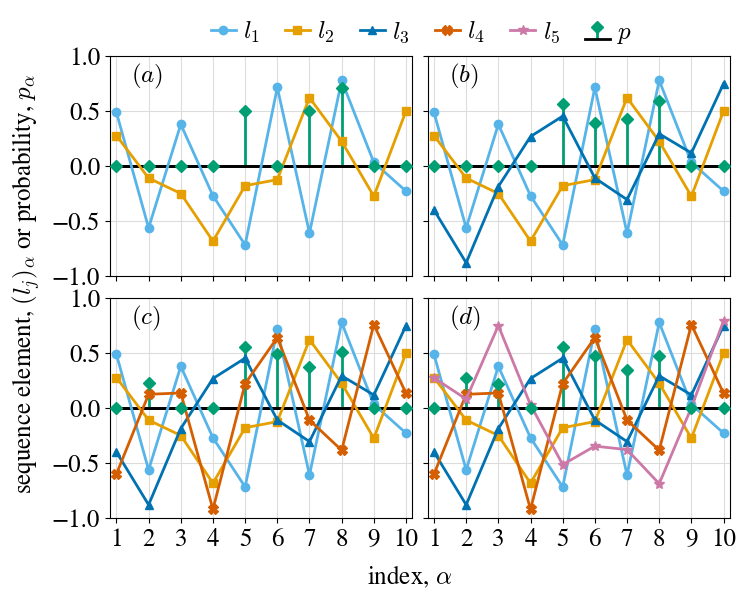

In [6]:
fig, axs = plt.subplots(
    2,
    2,
    figsize=(8, 6),
    sharex=True,
    sharey=True,
    gridspec_kw=dict(wspace=0.05, hspace=0.1),
)

x = np.arange(1, 11, 1)
δx = 0.1
labels = [r"$(a)$", r"$(b)$", r"$(c)$", r"$(d)$"]
# line_labels = [r'$\hat L_1$', r'$\hat L_2$', r'$\hat L_3$', r'$\hat L_4$', r'$\hat L_5$', r'$\left.| 0\right>$']
line_labels = [r"$l_1$", r"$l_2$", r"$l_3$", r"$l_4$", r"$l_5$", r"$p$"]

for data_index, ax in enumerate(axs.flatten()):
    ax.plot(
        x,
        data["Lsigs"].iloc[data_index][0].diagonal(),
        color=COLOURS["Sky blue"],
        marker="o",
        label=line_labels[0],
        zorder=2.1,
    )
    ax.plot(
        x,
        data["Lnoises"].iloc[data_index][0].diagonal(),
        color=COLOURS["Orange"],
        marker="s",
        label=line_labels[1],
        zorder=2.1,
    )
    if data["N"].iloc[data_index] >= 2:
        ax.plot(
            x,
            data["Lnoises"].iloc[data_index][1].diagonal(),
            color=COLOURS["Blue"],
            marker="^",
            label=line_labels[2],
            zorder=2.1,
        )
    if data["N"].iloc[data_index] >= 3:
        ax.plot(
            x,
            data["Lnoises"].iloc[data_index][2].diagonal(),
            color=COLOURS["Vermillion"],
            marker="X",
            markersize=7,
            label=line_labels[3],
            zorder=2.1,
        )
    if data["N"].iloc[data_index] >= 4:
        ax.plot(
            x,
            data["Lnoises"].iloc[data_index][3].diagonal(),
            color=COLOURS["Reddish purple"],
            marker="*",
            markersize=7,
            label=line_labels[4],
            zorder=2.1,
        )
    markerline, stemlines, baseline = ax.stem(
        x,
        data["ket_wZero"].iloc[data_index].real,
        markerfmt="D",
        linefmt=COLOURS["Bluish green"],
        basefmt="k",
        label=line_labels[5],
    )
    ax.axhline(0, color="k", zorder=2)
    baseline.set_zorder(2)
    markerline.set_zorder(3)
    stemlines.set_zorder(2)
    grid(ax)
    ax.set_xticks(x, x)
    ax.set(
        ylim=(-1, 1),
        xlim=(0.8, 10.2),
    )
    ax.text(0.07, 0.88, labels[data_index], transform=ax.transAxes)

legend(axs[1, 1], loc=(-0.75, 2.1), ncol=6, columnspacing=1)
legend_handles, legend_labels = ax.get_legend_handles_labels()

fig.text(0.5, 0, r"index, $\alpha$", ha="center")
fig.text(
    0,
    0.5,
    r"sequence element, $(l_j)_\alpha$ or probability, $p_\alpha$",
    va="center",
    rotation="vertical",
)
# fig.text(0.5, 0, r'$\hat{J_z}$ indicies', ha='center')
# fig.text(0, 0.5, r'diagonal component of $\hat L_j$', va='center', rotation='vertical')
# fig.supxlabel(r'$\hat J_z$ indicies')
# fig.supylabel(r'diagonal component of $\hat L_j$')

# fig.savefig(f'{figdir}paper/classical_case.pdf', bbox_inches='tight')
plt.show()

Separate noise and state plots

Random l_j on the left, different states for the same seed on the right

Two rows, two seeds?

In [8]:
D = 10
Ks = [1, 1, 1, 1]
Ns = [1, 2, 3, 4]

data = []
for seed, (K, N) in enumerate(tqdm(zip(Ks, Ns), total=len(Ks))):
    # print(seed, K, N)
    f1 = lambda v: (
        v / (1.1 * np.max(np.abs(v))) if np.min(v) < -1 or np.max(v) > 1 else v
    )
    seed = 1
    vs = random_orthogonal_real_vectors(
        D=D, num_vecs=K + N, seed=seed, normalisation_fn=f1
    )
    for v in vs:
        if np.min(v) < -1 or np.max(v) > 1:
            raise ValueError(dict(D=D, num_vecs=K + N, seed=seed, K=K, N=N))
    Ls = [np.diag(v) for v in vs]
    Lsigs = (
        Ls[:K]
        if K > 1
        else [
            Ls[0],
        ]
    )
    Lnoises = Ls[K:]

    results = ECQFI_by_SDP_for_any_K_N(
        D=D,
        Lsigs=Lsigs,
        Lnoises=Lnoises,
        t=1e-2,
        γ1=1e-5,
        γnoises=[1e-3 for _ in range(N)],
        please_print=False,
    )
    if results["sol_exists"]:
        # pure state (only works for the classical case), no complex phase
        probs = results["ρ_wZero"].diagonal().round(5)
        ket_wZero = np.sqrt(probs)
        len_support = len(ket_wZero[ket_wZero > 0])
        ρ_wZero_pure = ρ_from_ket(ket_wZero)
        Fq_wZero_pure = QFI_per_4t_any_K_N(D, ρ_wZero_pure, Lsigs, Lnoises)
        Fq_wZero_pure_ratio = Fq_wZero_pure / results["ECQFI"]
        data.append(
            dict(
                seed=seed,
                K=K,
                N=N,
                len_support=len_support,
                Fq_wZero_pure_ratio=Fq_wZero_pure_ratio,
                Lsigs=Lsigs,
                Lnoises=Lnoises,
                ket_wZero=ket_wZero,
            )
        )
data = pd.DataFrame(data)

results = ECQFI_by_SDP_for_any_K_N(
    D=D,
    Lsigs=Lsigs,
    Lnoises=[
        np.zeros_like(Lnoises[0]),
    ],
    t=1e-2,
    γ1=1e-5,
    γnoises=[1e-3 for _ in range(N)],
    please_print=False,
)
probs = results["ρ_wZero"].diagonal().round(5)
ket_wZero_noiseless = np.sqrt(probs)

  0%|          | 0/4 [00:00<?, ?it/s]

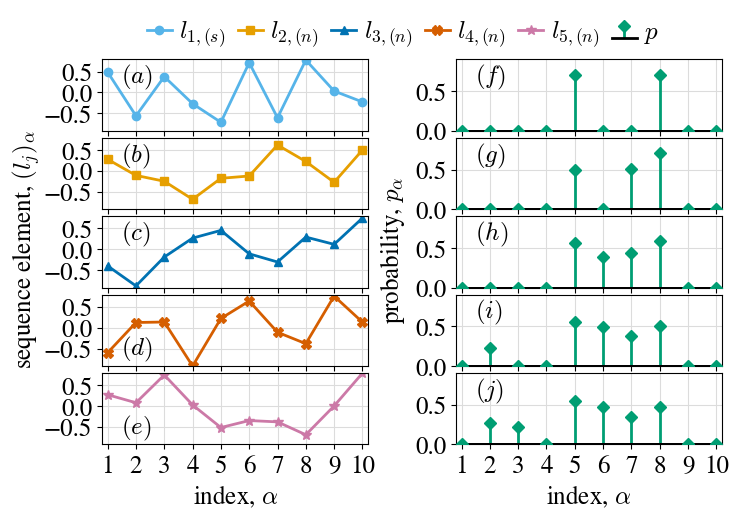

In [17]:
fig, axs = plt.subplots(
    5,
    2,
    figsize=(8, 5),
    sharex=True,
    sharey="col",
    gridspec_kw=dict(wspace=0.33, hspace=0.1),
)

x = np.arange(1, 11, 1)
δx = 0.1
labels = [r"$(a)$", r"$(b)$", r"$(c)$", r"$(d)$", r"$(e)$"]
labels_r = [r"$(f)$", r"$(g)$", r"$(h)$", r"$(i)$", r"$(j)$"]
# line_labels = [r'$\hat L_1$', r'$\hat L_2$', r'$\hat L_3$', r'$\hat L_4$', r'$\hat L_5$', r'$\left.| 0\right>$']
# line_labels = [r"$l_1$", r"$l_2$", r"$l_3$", r"$l_4$", r"$l_5$", r"$p$"]
line_labels = [
    r"$l_{1,(s)}$",
    r"$l_{2,(n)}$",
    r"$l_{3,(n)}$",
    r"$l_{4,(n)}$",
    r"$l_{5,(n)}$",
    r"$p$",
]
colors = [
    COLOURS["Sky blue"],
    COLOURS["Orange"],
    COLOURS["Blue"],
    COLOURS["Vermillion"],
    COLOURS["Reddish purple"],
    COLOURS["Bluish green"],
]
markers = ["o", "s", "^", "X", "*", "D"]

ymin, ymax = 0, 0
for i, ax in enumerate(axs[:, 0]):
    if i == 0:
        plot_data = data["Lsigs"].iloc[-1][0].diagonal()
        ax.plot(
            x,
            plot_data,
            color=colors[i],
            marker=markers[i],
            label=line_labels[0],
            zorder=2.1,
        )
    else:
        plot_data = data["Lnoises"].iloc[-1][i - 1].diagonal()
        ax.plot(
            x,
            plot_data,
            color=colors[i],
            marker=markers[i],
            label=line_labels[i],
            zorder=2.1,
            markersize=6 if i < 3 else 7,
        )
    if np.min(plot_data) < ymin:
        ymin = np.min(plot_data)
    if np.max(plot_data) > ymax:
        ymax = np.max(plot_data)
    grid(ax)
    ax.text(0.07, 0.67 if i < 3 else 0.15, labels[i], transform=ax.transAxes)
ax.set(
    ylim=(ymin, ymax),
    xlim=(0.8, 10.2),
)

for i, ax in enumerate(axs[:, 1]):
    if i == 0:
        markerline, stemlines, baseline = ax.stem(
            x,
            ket_wZero_noiseless.real,
            markerfmt="D",
            linefmt=COLOURS["Bluish green"],
            basefmt="k",
            label=line_labels[5],
        )
    else:
        markerline, stemlines, baseline = ax.stem(
            x,
            data["ket_wZero"].iloc[i - 1].real,
            markerfmt="D",
            linefmt=COLOURS["Bluish green"],
            basefmt="k",
            label=line_labels[5],
        )
    ax.axhline(0, color="k", zorder=2)
    baseline.set_zorder(2)
    markerline.set_zorder(3)
    stemlines.set_zorder(2)
    grid(ax)
    ax.set_xticks(x, x)
    ax.set(
        ylim=(0, 0.9),
    )
    ax.text(0.07, 0.67, labels_r[i], transform=ax.transAxes)

axs[-1, 0].set(xlabel=r"index, $\alpha$")
axs[-1, 1].set(xlabel=r"index, $\alpha$")

# run unsplit plot above to get legend_handles, legend_labels
axs[1, 1].legend(
    legend_handles,
    line_labels,
    loc=(-1.2, 2.1),
    ncol=6,
    columnspacing=0.5,
    handlelength=1,
    labelspacing=0,
    frameon=False,
    handletextpad=0.3,
)

# fig.text(0.5, 0, r'index, $\alpha$', ha='center')
fig.text(
    0.01, 0.5, r"sequence element, $(l_j)_\alpha$", va="center", rotation="vertical"
)
fig.text(0.47, 0.5, r"probability, $p_\alpha$", va="center", rotation="vertical")
# fig.text(0.5, 0, r'$\hat{J_z}$ indicies', ha='center')
# fig.text(0, 0.5, r'diagonal component of $\hat L_j$', va='center', rotation='vertical')
# fig.supxlabel(r'$\hat J_z$ indicies')
# fig.supylabel(r'diagonal component of $\hat L_j$')

fig.savefig(f"{figdir}paper/classical_case.pdf", bbox_inches="tight")
plt.show()

## Paper figures

(Fig 5) Stochastic waveform

In [60]:
file = "/home/james/Code/pleasantpheasant/data/FI_versus_nbar_for_Tuvia/squeezed_and_cat_states.txt"
data = pd.read_csv(file)

file = "/home/james/Code/pleasantpheasant/data/FI_versus_nbar_for_Tuvia/GKP.txt"
data_GKP = pd.read_csv(file)

file = "/home/james/Code/pleasantpheasant/data/FI_versus_nbar_for_Tuvia/Fock.txt"
data_fock = pd.read_csv(file)

In [98]:
def plot_options(
    key,
    # n_input=None,
    **kwargs,
):
    defaults = {
        "vacuum": dict(
            color=COLOURS["Orange"], label=r"vacuum QFI (CFI $\hat n$)", linewidth=3
        ),
        "vacuum quadrature CFI": dict(
            # color=COLOURS["Yellow"],
            # color=COLOURS["Reddish purple"],
            color=COLOURS["Sky blue"],
            # linestyle="--",
            linestyle=(0, (2, 1)),
            linewidth=3,
            label=r"vacuum CFI $\hat p$",
        ),
        # to match vacuum
        "coherent": dict(
            color=COLOURS["Orange"],
            linestyle="-",
            label="Coherent",
        ),
        "SMSV": dict(
            color=COLOURS["Bluish green"],
            linestyle="-.",
            label="SMSV",
        ),
        "Fock": dict(
            color=COLOURS["Vermillion"],
            linestyle=":",
            label="Fock",
        ),
        "TMSV": dict(
            color=COLOURS["Sky blue"],
            linestyle="--",
            label="TMSV",
        ),
        "TMSV-PS": dict(
            # color=COLOURS["Blue"],
            color=COLOURS["Orange"],
            linestyle=":",
            label="TMSV-PS",
        ),
        "cat": dict(
            color=COLOURS["Reddish purple"],
            linestyle=":",
            label="Cat",
        ),
        "channel": dict(
            color=COLOURS["Blue"],
            linestyle="-",
            label="Channel QFI",
            # linewidth=0.8,
        ),
    }
    # if key in ["SMSV QFI", "Fock QFI"] and n_input is None:
    #     raise ValueError("n_input not provided.")
    options = defaults[key]
    # union (|) returns a dict with the union of keys, preferencing the second slot in the case of key conflicts
    return options | kwargs


# is this problematic that we are repeating colours with a different meaning here?
colours = dict(
    Fock=COLOURS["Vermillion"], coherent=COLOURS["Sky blue"], channel=COLOURS["Blue"]
)

In [ ]:
# scale_factor = 1.5
fig, axs = plt.subplots(
    2,
    1,
    sharex=True,
    # figsize=(4, 5),
    figsize=(4, 4),
    gridspec_kw={
        # "wspace": 0.23,
        "hspace": 0.07,
        # 'height_ratios': [0.6,1]
        "height_ratios": [1, 1],
    },
)
fig.align_labels()

# ylim=(0, 410)
ylim = (0, 200)
ax = axs[0]
ax.fill_between(data["N"], data["SMSV lossless"], max(ylim), color="grey", alpha=0.4)
ax.plot(
    data["N"],
    data["SMSV lossless"],
    color="k",
    linestyle="-",
    label="ECQFI, attained by SMSV",
    zorder=3,
    linewidth=3,
)
# ax.plot(data["N"], data["cat lossless"], **plot_options("cat", label="Schrödinger's cat state", linestyle='', color=COLOURS["Sky blue"], zorder=4, linewidth=3, marker='o', markevery=0.1))
ax.plot(
    data_GKP["nbar"],
    data_GKP["QFI_lossless"],
    label="GKP finite-energy state",
    color=COLOURS["Bluish green"],
    linewidth=3,
    linestyle="-",
    zorder=3,
)
ax.plot(
    data["N"],
    data["TMSV lossless"],
    zorder=4,
    **plot_options(
        "TMSV-PS", label=r"TMSV", linewidth=3, linestyle="", marker="o", markevery=0.095
    ),
)
ax.plot(
    data_fock["N"],
    data_fock["lossless"],
    linestyle="",
    marker="s",
    markevery=(0.05, 0.095),
    label="Fock state",
    color=colours["Fock"],
    zorder=5,
)
# ax.axhline(2, **plot_options("coherent", linestyle=(0, (2, 1)), label='Coherent state', linewidth=3))
ax.axhline(
    2,
    **plot_options(
        "coherent",
        color=COLOURS["Reddish purple"],
        label="Coherent state",
        linewidth=3,
        linestyle=(0, (1, 1.5, 3, 1.5)),
    ),
)

# %%%%%%%%%%%%%%%%%
# inserted code
ns = np.linspace(0, 50, 200)
varX_SMSV = ns + 1 / 2 + np.sqrt(ns * (ns + 1))
c11Sqr_Fock_loss = (ns + 1) / 2
# ax.plot(ns, 4 * varX_SMSV, label=r'Noiseless ECQFI')
opts = dict(
    label="Fock state with loss and",
    color=COLOURS["Sky blue"],
    linestyle=(0, (2, 1)),
    linewidth=3,
)
ax.plot(ns, 4 * c11Sqr_Fock_loss, **opts)
# %%%%%%%%%%%%%%%%%

ax.set(
    ylim=ylim,
    # ylabel="QFI"
)
# legend(
#     ax,
#     labelspacing=0.05,
#     loc="lower left",
#     bbox_to_anchor=(1, -0.22),
#     )
grid(ax)

xlim = (0, 50)
ylim = (0, 22)
ax = axs[1]
# ax.axhspan(20, max(ylim), color='grey')
# ax.axhline(20, linestyle='-', color='k', label='ECQFI: high energy limit', linewidth=3)
ax.fill_between(data["N"], data["UB"], max(ylim), color="grey", alpha=0.4)
# r'Upper bound on ECQFI'
ax.plot(
    data["N"],
    data["UB"],
    **plot_options(
        "channel", linewidth=3, label=r"Upper bound on QFI", color="k", linestyle="-"
    ),
)
ax.plot(np.arange(1), linestyle="", label="without control")
ax.plot(
    data_GKP["nbar"],
    data_GKP["QFI"],
    label="GKP finite-energy state",
    color=COLOURS["Bluish green"],
    linewidth=3,
    linestyle="-",
    zorder=3,
)
ax.plot(
    data["N"],
    data["TMSV-PS"],
    **plot_options(
        "TMSV-PS",
        label=r"TMSV, noiseless ancilla",
        linewidth=3,
        linestyle="",
        marker="o",
        markevery=0.05,
        zorder=3,
    ),
)
# data_GKP['nbar'][data['nbar'] > 0.05], data_GKP['QFI'][data['nbar'] > 0.05]
ax.plot(
    data_fock["N"][::3],
    data_fock["lossy"][::3],
    # linestyle=":",
    linestyle="",
    marker="s",
    # markevery=(0.141, 0.095),
    # markevery=(0.05, 0.095),
    # markevery=(0.05, 0.04),
    color=colours["Fock"],
    label="Fock state",
    zorder=4,
)
ax.axhline(
    2,
    **plot_options(
        "coherent",
        color=COLOURS["Reddish purple"],
        label="Coherent state",
        linewidth=3,
        linestyle=(0, (1, 1.5, 3, 1.5)),
    ),
)

# %%%%%%%%%%%%%%%%%
# inserted code
ns = np.linspace(0, 50, 200)
varX_SMSV = ns + 1 / 2 + np.sqrt(ns * (ns + 1))
c11Sqr_Fock_loss = (ns + 1) / 2
# ax.plot(ns, 4 * varX_SMSV, label=r'Noiseless ECQFI')
ax.plot(ns, 4 * c11Sqr_Fock_loss, **opts)
ax.plot(np.arange(1), linestyle="", label="fast and precise control")
# %%%%%%%%%%%%%%%%%

ax.set(
    xlim=xlim,
    ylim=ylim,
    # title="Channel QFI (single-mode, bounded)\n"
    # + r"$\sigma\rightarrow0$, $\eta_\mathrm{\,input}=0.1$, $\eta_\mathrm{\,meas}=0$",
    xlabel=r"average number per mode",
    # ylabel="QFI",
)
# ylabel = 'QFI with respect to $\sqrt{\gamma_1}$'
# ylabel = r'QFI for $\hat L_1 = \hat x$ and $\hat L_2 = \hat a$'
# ylabel = r'stochastic waveform estimation QFI'
ylabel = r"QFI for stochastic waveform"
fig.text(-0.08, 0.5, ylabel, va="center", rotation="vertical")
ax.set_yticks([0, 10, 20])
grid(ax)
legend(
    ax,
    labelspacing=0.1,
    loc="lower left",
    bbox_to_anchor=(1, 0.1),
    # handlelength=1.5,
)
# h, l = ax.get_legend_handles_labels()
# ax.legend(handles=h,)
ax.set_xticks(range(0, 60, 10))

axs[0].text(0.02, 0.81, "(a)", transform=axs[0].transAxes)
axs[1].text(0.02, 0.75, "(b)", transform=axs[1].transAxes)

fig.savefig(f"{figdir}paper/stochastic_waveform_estimation.pdf", bbox_inches="tight")
plt.show()
# plt.clf()

Bloch sphere

In [3]:
def pv_to_quiver_args(pv):
    pv_traceless = pv[1:].real
    return 0, 0, 0, *pv_traceless

In [4]:
L1 = 1 / np.sqrt(2) * σz
L1_pv = Pauli_vector(L1)

a = 1 / np.sqrt(8)
# b = 1j / np.sqrt(8)
b = np.exp(1j * np.pi / 4) / np.sqrt(8)
# b = np.exp(1j * np.pi / -4) / np.sqrt(8)
# b = np.exp(1j * np.pi * -1.9) / np.sqrt(8)
L2 = a * σp + b * σm
reL2_pv, imL2_pv = Pauli_vector(L2, non_Hermitian=True)
# L1_pv, reL2_pv, imL2_pv

# optimal state
r = np.sqrt(np.abs(a) / (np.abs(a) + np.abs(b)))  # TODO: also try -r
θ = (np.angle(b) - np.angle(a)) / 2
# r, θ
ket = np.array([r, np.sqrt(1 - r**2) * np.exp(1j * θ)])
ket_pv = bloch_vector(ket)

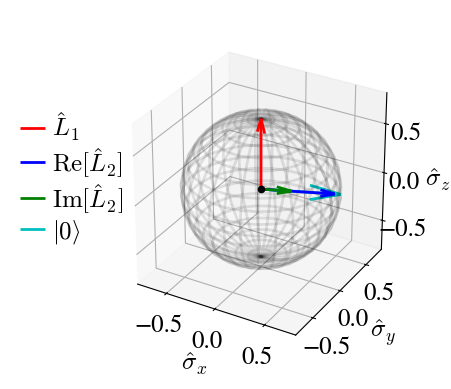

In [5]:
fig, ax = plt.subplots(subplot_kw=dict(projection="3d", computed_zorder=False))

# draw sphere
u, v = np.mgrid[0 : 2 * np.pi : 30j, 0 : np.pi : 20j]
# radius = 1
radius = 1 / np.sqrt(2)
x = radius * np.cos(u) * np.sin(v)
y = radius * np.sin(u) * np.sin(v)
z = radius * np.cos(v)
ax.plot_wireframe(x, y, z, color="k", alpha=0.1)
ax.set_box_aspect((np.ptp(x), np.ptp(y), np.ptp(z)))
# https://stackoverflow.com/a/11156353

# draw a point
ax.scatter([0], [0], [0], color="k", s=20, zorder=10)

# draw a vector
ax.quiver(
    *pv_to_quiver_args(L1_pv),
    length=1.0,
    color="r",
    label=r"$\hat L_1$",
    arrow_length_ratio=0.2,
)
ax.quiver(
    *pv_to_quiver_args(reL2_pv),
    length=1.0,
    color="b",
    label=r"$\text{Re}[\hat L_2]$",
    arrow_length_ratio=0.2,
)
ax.quiver(
    *pv_to_quiver_args(imL2_pv),
    length=1.0,
    color="g",
    label=r"$\text{Im}[\hat L_2]$",
    arrow_length_ratio=0.5,
)

# r'$\left.| 0\right>$' rather than | 0 \rangle
# TODO: normalise ket to the same scale as the operators or vice versa
ax.quiver(
    0,
    0,
    0,
    *ket_pv / np.sqrt(2),
    length=1.0,
    color="c",
    label=r"$\left.| 0\right>$",
    arrow_length_ratio=0.4,
    zorder=1,
)

# heads of the arrows with adjusted arrow head length
# ax.quiver(tails,tails,tails,bvecs[:,0], bvecs[:,1], bvecs[:,2], length=1.0, normalize=True, color='b', arrow_length_ratio=0.15)

# ax.set_xlabel('X-axis')
# ax.set_ylabel('Y-axis')
# ax.set_zlabel('Z-axis')
ax.xaxis.set_rotate_label(False)
ax.yaxis.set_rotate_label(False)
ax.zaxis.set_rotate_label(False)
ax.set_xlabel(r"$\hat \sigma_x$", labelpad=10)
ax.set_ylabel(r"$\hat \sigma_y$" + "\n", labelpad=17)
ax.set_zlabel("\n" + r"$\hat \sigma_z$", labelpad=10)

# ax.set(xlim=(-1.1, 1.1), ylim=(-1.1, 1.1), zlim=(-1.1, 1.1))
# ax.view_init(elev=20, azim=30)
# plt.tight_layout()
# ax.set_aspect('equal')
ax.set_box_aspect([1, 1, 1], zoom=0.83)

legend(
    ax,
    labelspacing=0.1,
    loc="lower left",
    bbox_to_anchor=(-0.2, 0.3),
    # handlelength=1.5,
)

fig.savefig(f"{figdir}qubits/Bloch_sphere.pdf", bbox_inches="tight")
plt.show()

Optimal unextended for inequal

0.24999999999999997


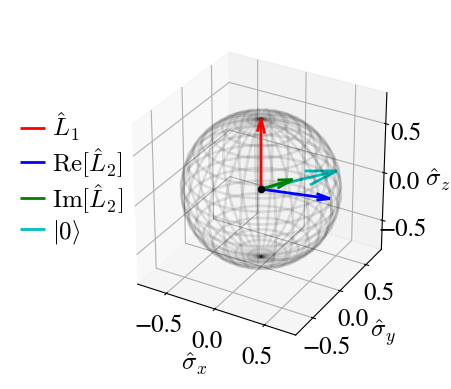

In [6]:
L1 = 1 / np.sqrt(2) * σz
L1_pv = Pauli_vector(L1)

############ select a, b ################
a = 1
# b = 1j / np.sqrt(8)
# b = np.exp(1j * np.pi / 4)
b = 0.5 * np.exp(1j * np.pi / 4)
# b = np.exp(1j * np.pi / -4) / np.sqrt(8)
# b = np.exp(1j * np.pi * -1.9) / np.sqrt(8)

# normalise a, b
normab = 2 * np.sqrt(np.abs(a) ** 2 + np.abs(b) ** 2)
a /= normab
b /= normab
print(np.abs(a) ** 2 + np.abs(b) ** 2)

L2 = a * σp + b * σm
reL2_pv, imL2_pv = Pauli_vector(L2, non_Hermitian=True)
# L1_pv, reL2_pv, imL2_pv

# optimal state
r = np.sqrt(np.abs(a) / (np.abs(a) + np.abs(b)))  # TODO: also try -r
θ = (np.angle(b) - np.angle(a)) / 2
# r, θ
ket = np.array([r, np.sqrt(1 - r**2) * np.exp(1j * θ)])
ket_pv = bloch_vector(ket)


fig, ax = plt.subplots(subplot_kw=dict(projection="3d", computed_zorder=False))
ax.set_box_aspect((np.ptp(x), np.ptp(y), np.ptp(z)))

# draw sphere
u, v = np.mgrid[0 : 2 * np.pi : 30j, 0 : np.pi : 20j]
# radius = 1
radius = 1 / np.sqrt(2)
x = radius * np.cos(u) * np.sin(v)
y = radius * np.sin(u) * np.sin(v)
z = radius * np.cos(v)
ax.plot_wireframe(x, y, z, color="k", alpha=0.1)
# https://stackoverflow.com/a/11156353

# draw a point
ax.scatter([0], [0], [0], color="k", s=20, zorder=10)

# draw a vector
ax.quiver(
    *pv_to_quiver_args(L1_pv),
    length=1.0,
    color="r",
    label=r"$\hat L_1$",
    arrow_length_ratio=0.2,
)
ax.quiver(
    *pv_to_quiver_args(reL2_pv),
    length=1.0,
    color="b",
    label=r"$\text{Re}[\hat L_2]$",
    arrow_length_ratio=0.2,
)
ax.quiver(
    *pv_to_quiver_args(imL2_pv),
    length=1.0,
    color="g",
    label=r"$\text{Im}[\hat L_2]$",
    arrow_length_ratio=0.5,
)

# r'$\left.| 0\right>$' rather than | 0 \rangle
# TODO: normalise ket to the same scale as the operators or vice versa
ax.quiver(
    0,
    0,
    0,
    *ket_pv / np.sqrt(2),
    length=1.0,
    color="c",
    label=r"$\left.| 0\right>$",
    arrow_length_ratio=0.4,
    zorder=1,
)

# heads of the arrows with adjusted arrow head length
# ax.quiver(tails,tails,tails,bvecs[:,0], bvecs[:,1], bvecs[:,2], length=1.0, normalize=True, color='b', arrow_length_ratio=0.15)

# ax.set_xlabel('X-axis')
# ax.set_ylabel('Y-axis')
# ax.set_zlabel('Z-axis')
ax.xaxis.set_rotate_label(False)
ax.yaxis.set_rotate_label(False)
ax.zaxis.set_rotate_label(False)
ax.set_xlabel(r"$\hat \sigma_x$", labelpad=10)
ax.set_ylabel(r"$\hat \sigma_y$" + "\n", labelpad=17)
ax.set_zlabel("\n" + r"$\hat \sigma_z$", labelpad=10)

# ax.set(xlim=(-1.1, 1.1), ylim=(-1.1, 1.1), zlim=(-1.1, 1.1))
# ax.view_init(elev=20, azim=30)
# plt.tight_layout()
# ax.set_aspect('equal')
ax.set_box_aspect([1, 1, 1], zoom=0.83)

legend(
    ax,
    labelspacing=0.1,
    loc="lower left",
    bbox_to_anchor=(-0.2, 0.3),
    # handlelength=1.5,
)

fig.savefig(f"{figdir}qubits/Bloch_sphere.pdf", bbox_inches="tight")
plt.show()

Out-of-plane Bloch sphere

RDM versus theta2 parametric Bloch sphere plot, going from Halfway

In [7]:
# start by calculating the bloch sphere for the existing halfway data

In [8]:
file = f"../data/random_Hermitian_L1_L2/qubit_both_non-Herm_hneq0_RDM_5_no_complex_phase_half_way.h5"
data = pd.read_hdf(file, key="df")
data_entropy = data

In [9]:
Smin, Smax = 1, 0
for ρ in data["ρS_swarm"]:
    S = entropy(ρ, 2, normalised=True)
    if S > Smax:
        Smax = S
    elif S < Smin:
        Smin = S
    ρ_swarm_pv = Pauli_vector(ρ)
    # break
print(Smin, Smax)

-6.301470825068176e-16 0.999819205384784


/home/james/.local/lib/python3.10/site-packages/scipy/linalg/_matfuncs.py:203: LogmExactlySingularWarning: The logm input matrix is exactly singular.
  F = scipy.linalg._matfuncs_inv_ssq._logm(A)


In [10]:
Ss = []
pvs = []
pvs_ket = []
for ρ, ket_eig_L20 in zip(data["ρS_swarm"], data["ket_eig_L2"]):
    # S = entropy(2, ρ, normalised=False)
    S = entropy(ρ, 2, normalised=True)
    Ss.append(S)
    # normalisation, see bloch_vector
    # ρ_swarm_pv = 2 * Pauli_vector(ρ)
    ρ_swarm_pv = np.sqrt(2) * Pauli_vector(ρ)
    pvs.append(ρ_swarm_pv)
    ket_eig_L20_pv = bloch_vector(ket_eig_L20) / np.sqrt(2)
    pvs_ket.append(ket_eig_L20_pv)
data["entropy"] = Ss
data["pvs"] = pvs
data["pvs_ket"] = pvs_ket

NameError: name 'θ1_transition' is not defined

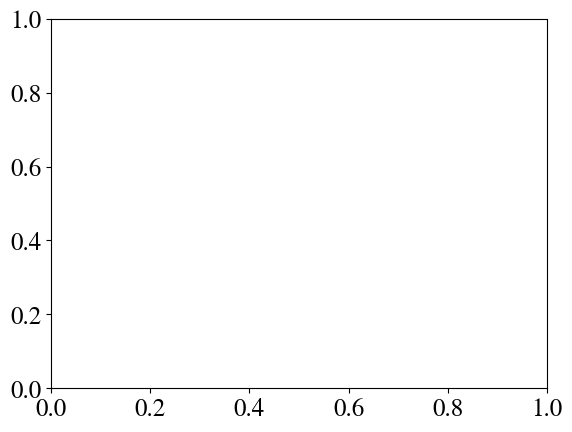

In [11]:
fig, ax = plt.subplots()

ax.axvline(θ1_transition, color="k")
ax.axvline(π / 2 - θ1_transition, color="k")

ax.plot(data["θ1"], data["entropy"], "-")
ax.set(
    ylim=(0, 1),
    xlim=lim(data["θ1"]),
    ylabel="normalised entropy",
    xlabel=r"$\theta_1$",
    title=r"$\theta_2=\pi/4, \phi_1=\phi_2=0$",
)
grid(ax)
ticks = gen_ticks(data["θ1"])
tick_labels = [0, r"$\pi/8$", r"$\pi/4$", r"$3\pi/8$", r"$\pi/2$"]
ax.set_xticks(ticks, tick_labels)

fig.savefig(f"{figdir}qubits/halfway_entropy.pdf", bbox_inches="tight")
plt.show()

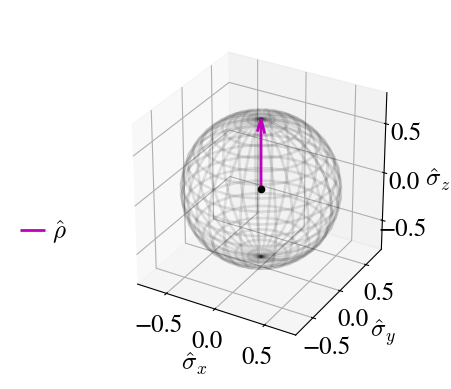

In [45]:
fig, ax = plt.subplots(subplot_kw=dict(projection="3d", computed_zorder=False))

# https://stackoverflow.com/a/11156353
# draw sphere
u, v = np.mgrid[0 : 2 * np.pi : 30j, 0 : np.pi : 20j]
# radius = 1
radius = 1 / np.sqrt(2)
x = radius * np.cos(u) * np.sin(v)
y = radius * np.sin(u) * np.sin(v)
z = radius * np.cos(v)
ax.plot_wireframe(x, y, z, color="k", alpha=0.1)
ax.set_box_aspect((np.ptp(x), np.ptp(y), np.ptp(z)))

# draw a point
ax.scatter([0], [0], [0], color="k", s=20, zorder=10)

# draw a vector
ax.quiver(
    *pv_to_quiver_args(ρ_swarm_pv),
    length=1.0,
    color="m",
    label=r"$\hat \rho$",
    arrow_length_ratio=0.2
)

ax.xaxis.set_rotate_label(False)
ax.yaxis.set_rotate_label(False)
ax.zaxis.set_rotate_label(False)
ax.set_xlabel(r"$\hat \sigma_x$", labelpad=10)
ax.set_ylabel(r"$\hat \sigma_y$" + "\n", labelpad=17)
ax.set_zlabel("\n" + r"$\hat \sigma_z$", labelpad=10)
ax.set_box_aspect([1, 1, 1], zoom=0.83)

legend(
    ax,
    labelspacing=0.1,
    loc="lower left",
    bbox_to_anchor=(-0.2, 0.3),
)

# fig.savefig(f'{figdir}paper/Bloch_sphere.pdf', bbox_inches='tight')
plt.show()

In [12]:
# parametric plot of RDM versus theta2

(Fig 4) *may need to run those cells above*

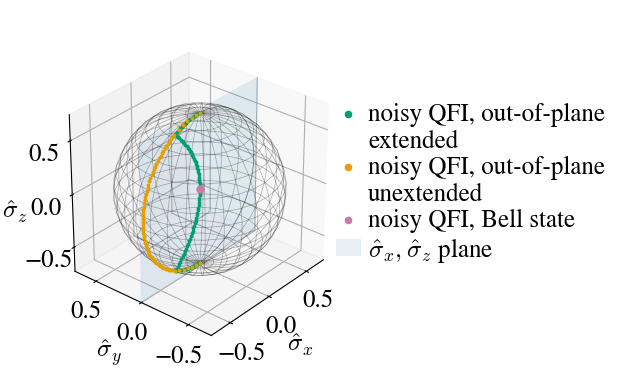

In [13]:
fig, ax = plt.subplots(subplot_kw=dict(projection="3d", computed_zorder=False))

# https://stackoverflow.com/a/11156353
# draw sphere
u, v = np.mgrid[0 : 2 * np.pi : 30j, 0 : np.pi : 20j]
# radius = 1
radius = 1 / np.sqrt(2)
x = radius * np.cos(u) * np.sin(v)
y = radius * np.sin(u) * np.sin(v)
z = radius * np.cos(v)
ax.plot_wireframe(x, y, z, color="k", linewidth=0.5, alpha=0.3)
ax.set_box_aspect((np.ptp(x), np.ptp(y), np.ptp(z)))


# draw a point
ax.scatter([0], [0], [0], color=COLOURS["Reddish purple"], s=25, zorder=11)

# draw a vector
for i, pv in enumerate(data["pvs_ket"][::3]):
    ax.scatter(
        [pv[0].real],
        [pv[1].real],
        [pv[2].real],
        color=COLOURS["Orange"],
        s=3,
        #    zorder=10,
        zorder=15,
    )

for i, pv in enumerate(data["pvs_ket"]):
    ax.scatter(
        [pv[0].real],
        [pv[1].real],
        [pv[2].real],
        color=COLOURS["Orange"],
        s=3,
        zorder=9,
    )

for i, pv in enumerate(data["pvs"]):
    ax.scatter(
        [pv[1].real],
        [pv[2].real],
        [pv[3].real],
        color=COLOURS["Bluish green"],
        s=3,
        zorder=10,
    )

ax.xaxis.set_rotate_label(False)
ax.yaxis.set_rotate_label(False)
ax.zaxis.set_rotate_label(False)
ax.set_xlabel(r"$\hat \sigma_x$", labelpad=10)
ax.set_ylabel(r"$\hat \sigma_y$" + "\n", labelpad=17)
ax.set_zlabel("\n" + r"$\hat \sigma_z$", labelpad=10)

# legend(ax, labelspacing=0.1,
#     loc="lower left",
#     bbox_to_anchor=(-0.2, 0.3),
# )
# ax.view_init(elev=20, azim=-45)
# ax.set_box_aspect([1, 1, 1], zoom=0.75)
# ax.view_init(elev=30, azim=-60)
ax.view_init(elev=30, azim=-140)
# ax.view_init(elev=0, azim=90)
ax.set_box_aspect([1, 1, 1], zoom=0.82)

handles = [
    plt.scatter(
        [],
        [],
        s=20,
        color=COLOURS["Bluish green"],
        label=r"noisy QFI, out-of-plane",
    ),
    plt.scatter(
        [],
        [],
        s=20,
        alpha=0,
        label="extended",
    ),
    plt.scatter(
        [],
        [],
        s=20,
        color=COLOURS["Orange"],
        label=r"noisy QFI, out-of-plane",
    ),
    plt.scatter(
        [],
        [],
        s=20,
        alpha=0,
        label="unextended",
    ),
    plt.scatter(
        [],
        [],
        s=20,
        color=COLOURS["Reddish purple"],
        label="noisy QFI, Bell state",
    ),
]

# Add a plane along the YZ plane
factor = 1.05
x_plane = np.array(
    [[-factor * radius, factor * radius], [-factor * radius, factor * radius]]
)
y_plane = np.array([[0, 0], [0, 0]])
z_plane = np.array(
    [[-factor * radius, -factor * radius], [factor * radius, factor * radius]]
)
ax.plot_surface(
    x_plane,
    y_plane,
    z_plane,
    color=COLOURS["Blue"],
    alpha=0.1,
    label=r"$\hat \sigma_x, \hat \sigma_z$ plane",
)

legend(
    ax,
    # handles=handles,
    # handles=[*handles, *h],
    # labels=[*l, 'test'],
    labelspacing=0.1,
    loc="lower left",
    # bbox_to_anchor=(-0.7, 0.3),
    bbox_to_anchor=(0.82, 0.25),
    # handlelength=1.5,
)
# plot_limits = (-1, 1)
plot_limits = (-radius, radius)
ax.set(
    xlim=plot_limits,
    ylim=plot_limits,
    zlim=plot_limits,
)
ax.tick_params(axis="z", pad=6)

fig.savefig(f"{figdir}paper/Bloch_sphere_parametric.pdf", bbox_inches="tight")
plt.show()

(Fig 3) Half way plot

In [3]:
# TODO: halfway SDP to check the PSO results

In [17]:
file = f"../data/random_Hermitian_L1_L2/qubit_both_non-Herm_hneq0_RDM_5_no_complex_phase_half_way.h5"
data = pd.read_hdf(file, key="df")

Ss = []
pvs = []
pvs_ket = []
for ρ, ket_eig_L20 in zip(data["ρS_swarm"], data["ket_eig_L2"]):
    # S = entropy(2, ρ, normalised=False)
    S = entropy(D=2, ρ=ρ, normalised=True)
    Ss.append(S)
    # normalisation, see bloch_vector
    # ρ_swarm_pv = 2 * Pauli_vector(ρ)
    ρ_swarm_pv = np.sqrt(2) * Pauli_vector(ρ)
    pvs.append(ρ_swarm_pv)
    ket_eig_L20_pv = bloch_vector(ket_eig_L20) / np.sqrt(2)
    pvs_ket.append(ket_eig_L20_pv)
data["entropy"] = Ss
data["pvs"] = pvs
data["pvs_ket"] = pvs_ket

file = (
    f"../data/random_Hermitian_L1_L2/qubit_halfway_noisyancilla_optForL1L2L3L4_Bell.h5"
)
data_bell = pd.read_hdf(file, key="df")

/home/james/.local/lib/python3.10/site-packages/scipy/linalg/_matfuncs.py:203: LogmExactlySingularWarning: The logm input matrix is exactly singular.
  F = scipy.linalg._matfuncs_inv_ssq._logm(A)


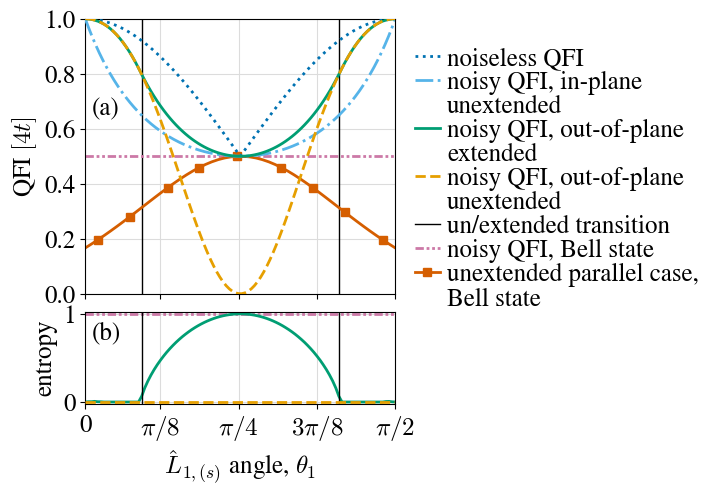

In [18]:
# load and sort new results
θs_sorted = data.sort_values(by="θ1")["θ1"]
qfi_swarm_sorted = data.sort_values(by="θ1")["qfi_swarm"]
VarL1_swarm_sorted = data.sort_values(by="θ1")["VarL1_swarm"]
VarL1_eig_L2_sorted = data.sort_values(by="θ1")["VarL1_eig_L2"]
VarL1_opt_sorted = data.sort_values(by="θ1")["VarL1_opt"]

# previous results
θs_HD = np.linspace(0, π / 2, 1000)
Fq_zero_h_opt = np.min(
    [
        1 / np.cos(2 * θs_HD) * (1 / np.cos(2 * θs_HD) + np.tan(2 * θs_HD)),
        1 / np.cos(2 * θs_HD) * (1 / np.cos(2 * θs_HD) - np.tan(2 * θs_HD)),
    ],
    axis=0,
)

Fq_noiseless = np.max([np.cos(θs_HD) ** 2, np.sin(θs_HD) ** 2], axis=0)

diff = qfi_swarm_sorted - VarL1_eig_L2_sorted
θ1_transition = θs_sorted[np.searchsorted(diff, 1e-4)]

# plotting
fig, axs = plt.subplots(
    2,
    1,
    figsize=(4, 5),
    sharex=True,
    gridspec_kw=dict(height_ratios=(3, 1), hspace=0.1),
)

ax = axs[0]
ax.plot(
    θs_HD,
    Fq_noiseless,
    label=r"noiseless QFI",
    linestyle=":",
    zorder=3,
    color=COLOURS["Blue"],
)
ax.plot(
    θs_HD,
    Fq_zero_h_opt,
    label=r"noisy QFI, in-plane",
    linestyle="-.",
    zorder=3,
    color=COLOURS["Sky blue"],
)
ax.plot([], [], label="unextended", alpha=0)
# ax.scatter(θs_sorted, VarL1_opt_sorted, marker='+', label=r'Var[$L_1$] opt., PSO', color='y')
# ax.plot(θs_sorted, VarL1_swarm_sorted, label=r"noiseless QFI, out-of-plane case $(\theta_2=\frac{\pi}{4})$", color="c")
ax.plot(
    θs_sorted,
    qfi_swarm_sorted,
    label=r"noisy QFI, out-of-plane",
    color=COLOURS["Bluish green"],
    zorder=3,
)
ax.plot([], [], label="extended", alpha=0)
ax.plot(
    θs_sorted,
    VarL1_eig_L2_sorted,
    label=r"noisy QFI, out-of-plane",
    color=COLOURS["Orange"],
    linestyle="--",
    zorder=3,
)
ax.plot([], [], label="unextended", alpha=0)
# ax.axhline(0, linestyle='', label='out-of-plane')
ax.axvline(θ1_transition, color="k", linewidth=1, label="un/extended transition")
ax.axhline(
    0.5,
    color=COLOURS["Reddish purple"],
    linestyle=(0, (3, 1, 1, 1, 1, 1)),
    label="noisy QFI, Bell state",
    zorder=2,
)
ax.axvline(π / 2 - θ1_transition, color="k", linewidth=1)
ax.plot(
    data_bell["θ1"],
    data_bell["QFI_noisy_ancilla"] / 2,
    # label="QFI/2 L1,L2; L3,L4 (Bell)",
    label="unextended parallel case,",
    color=COLOURS["Vermillion"],
    marker="s",
    markevery=(0.038, 0.1),
)
ax.plot([], [], label="Bell state", alpha=0)
ax.set(
    ylabel=r"QFI $[4t]$",
    ylim=(0, 1),
)
legend(ax, loc=(1.03, -0.1))
grid(ax)
gen_ticks = lambda v: [
    max(v / (len(v) - 1)) * x
    for x in [
        0,
        (len(v) - 1) // 4,
        (len(v) - 1) // 2,
        3 * (len(v) - 1) // 4,
        len(v) - 1,
    ]
]
ticks = gen_ticks(data["θ1"])
tick_labels = [0, r"$\pi/8$", r"$\pi/4$", r"$3\pi/8$", r"$\pi/2$"]
ax.set_xticks(ticks, tick_labels)

ax = axs[1]
# ax.axvline(θ1_transition, color="k")
# ax.axvline(π / 2 - θ1_transition, color="k")
ax.axhline(
    1,
    color=COLOURS["Reddish purple"],
    linestyle=(0, (3, 1, 1, 1, 1, 1)),
    label="noisy QFI, Bell state",
)
ax.axhline(
    0, label=r"noisy QFI, unextended", color=COLOURS["Orange"], linestyle="--", zorder=3
)
ax.plot(data["θ1"], data["entropy"], "-", color=COLOURS["Bluish green"])
ax.set(
    ylim=(-0.02, 1.02),
    xlim=lim(data["θ1"]),
    ylabel="entropy",
    # xlabel=r"$\hat L_1$ angle, $\theta_1$",
    xlabel=r"$\hat L_{1,(s)}$ angle, $\theta_1$",
)
ax.axvline(θ1_transition, color="k", linewidth=1, label="un/extended transition")
ax.axvline(π / 2 - θ1_transition, color="k", linewidth=1)
grid(ax)
ticks = gen_ticks(data["θ1"])
tick_labels = [0, r"$\pi/8$", r"$\pi/4$", r"$3\pi/8$", r"$\pi/2$"]
ax.set_xticks(ticks, tick_labels)

axs[0].text(0.02, 0.65, "(a)", transform=axs[0].transAxes)
axs[1].text(0.02, 0.7, "(b)", transform=axs[1].transAxes)

# fig.savefig(
#     f"{figdir}paper/halfway_QFI.pdf",
#     bbox_inches="tight",
# )
plt.show()

(Fig 3') Half-way plot with parallel separated out

In [20]:
# file = f"../data/random_Hermitian_L1_L2/qubit_halfway_noisyancilla_optForL1L2L3L4.h5"
# 10x larger search does not remove the discontinuity
file = f"../data/random_Hermitian_L1_L2/qubit_halfway_noisy-ancilla_optForL1L2L3L4_larger-search.h5"
data_parallel = pd.read_hdf(file, key="df")
D = 2

Ss = []
Fqs = []
for i in range(len(data_parallel)):
    Fq_unext = data_parallel["VarL1_eig_L2"].iloc[i]
    Fq_ext = data_parallel["QFI_noisy_ancilla"].iloc[i] / 2
    unext_better = Fq_unext > Fq_ext
    if unext_better:
        S = 0
        Fq = Fq_unext
    else:
        S = entanglement_entropy(D, data_parallel["ket_swarm"].iloc[i], normalised=True)
        Fq = Fq_ext
    Ss.append(S)
    Fqs.append(Fq)
data_parallel["entropy"] = Ss
data_parallel["QFI_unext_parallel"] = Fqs

In [21]:
file = f"../data/random_Hermitian_L1_L2/qubit_both_non-Herm_hneq0_RDM_5_no_complex_phase_half_way.h5"
data = pd.read_hdf(file, key="df")

Ss = []
pvs = []
pvs_ket = []
for ρ, ket_eig_L20 in zip(data["ρS_swarm"], data["ket_eig_L2"]):
    # S = entropy(2, ρ, normalised=False)
    S = entropy(D=2, ρ=ρ, normalised=True)
    Ss.append(S)
    # normalisation, see bloch_vector
    # ρ_swarm_pv = 2 * Pauli_vector(ρ)
    ρ_swarm_pv = np.sqrt(2) * Pauli_vector(ρ)
    pvs.append(ρ_swarm_pv)
    ket_eig_L20_pv = bloch_vector(ket_eig_L20) / np.sqrt(2)
    pvs_ket.append(ket_eig_L20_pv)
data["entropy"] = Ss
data["pvs"] = pvs
data["pvs_ket"] = pvs_ket

file = (
    f"../data/random_Hermitian_L1_L2/qubit_halfway_noisyancilla_optForL1L2L3L4_Bell.h5"
)
data_bell = pd.read_hdf(file, key="df")

/home/james/.local/lib/python3.10/site-packages/scipy/linalg/_matfuncs.py:203: LogmExactlySingularWarning: The logm input matrix is exactly singular.
  F = scipy.linalg._matfuncs_inv_ssq._logm(A)


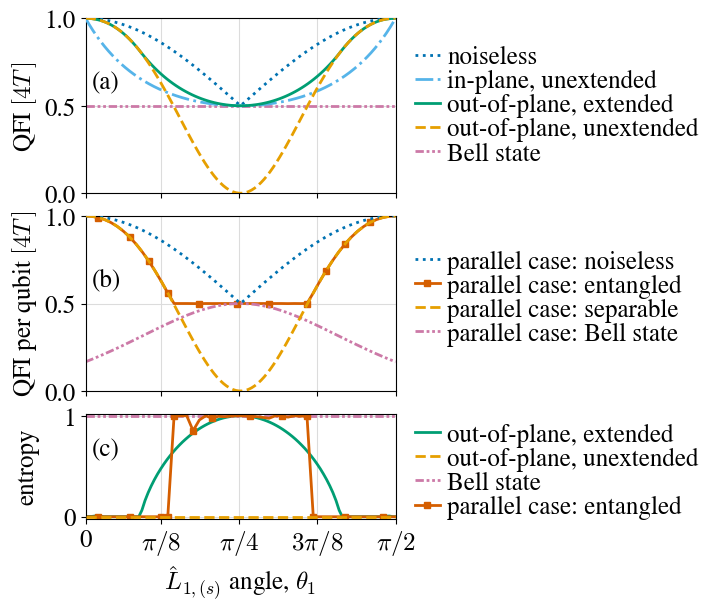

In [34]:
# load and sort new results
θs_sorted = data.sort_values(by="θ1")["θ1"]
qfi_swarm_sorted = data.sort_values(by="θ1")["qfi_swarm"]
VarL1_swarm_sorted = data.sort_values(by="θ1")["VarL1_swarm"]
VarL1_eig_L2_sorted = data.sort_values(by="θ1")["VarL1_eig_L2"]
VarL1_opt_sorted = data.sort_values(by="θ1")["VarL1_opt"]

# previous results
θs_HD = np.linspace(0, π / 2, 1000)
Fq_zero_h_opt = np.min(
    [
        1 / np.cos(2 * θs_HD) * (1 / np.cos(2 * θs_HD) + np.tan(2 * θs_HD)),
        1 / np.cos(2 * θs_HD) * (1 / np.cos(2 * θs_HD) - np.tan(2 * θs_HD)),
    ],
    axis=0,
)

Fq_noiseless = np.max([np.cos(θs_HD) ** 2, np.sin(θs_HD) ** 2], axis=0)

diff = qfi_swarm_sorted - VarL1_eig_L2_sorted
θ1_transition = θs_sorted[np.searchsorted(diff, 1e-4)]

# plotting
fig, axs = plt.subplots(
    3,
    1,
    figsize=(4, 6.5),
    sharex=True,
    gridspec_kw=dict(
        # height_ratios=(2, 2, 1),
        height_ratios=(2, 2, 1.2),
        hspace=0.15,
    ),
)

ax = axs[0]
ax.plot(
    θs_HD,
    Fq_noiseless,
    label=r"noiseless",
    linestyle=":",
    zorder=3,
    color=COLOURS["Blue"],
)
ax.plot(
    θs_HD,
    Fq_zero_h_opt,
    label=r"in-plane, unextended",
    linestyle="-.",
    zorder=3,
    color=COLOURS["Sky blue"],
)
# ax.scatter(θs_sorted, VarL1_opt_sorted, marker='+', label=r'Var[$L_1$] opt., PSO', color='y')
# ax.plot(θs_sorted, VarL1_swarm_sorted, label=r"noiseless QFI, out-of-plane case $(\theta_2=\frac{\pi}{4})$", color="c")
ax.plot(
    θs_sorted,
    qfi_swarm_sorted,
    label=r"out-of-plane, extended",
    color=COLOURS["Bluish green"],
    zorder=3,
)
ax.plot(
    θs_sorted,
    VarL1_eig_L2_sorted,
    label=r"out-of-plane, unextended",
    color=COLOURS["Orange"],
    linestyle="--",
    zorder=3,
)
# ax.axhline(0, linestyle='', label='out-of-plane')
# ax.axvline(θ1_transition, color="k", linewidth=1, label='un/extended transition')
# ax.axvline(π / 2 - θ1_transition, color="k", linewidth=1)
ax.axhline(
    0.5,
    color=COLOURS["Reddish purple"],
    linestyle=(0, (3, 1, 1, 1, 1, 1)),
    label="Bell state",
    zorder=2,
)
ax.set(
    ylabel=r"QFI $[4T\,]$",
    ylim=(0, 1),
)
legend(ax, loc=(1.03, 0.1))
grid(ax)
gen_ticks = lambda v: [
    max(v / (len(v) - 1)) * x
    for x in [
        0,
        (len(v) - 1) // 4,
        (len(v) - 1) // 2,
        3 * (len(v) - 1) // 4,
        len(v) - 1,
    ]
]
ticks = gen_ticks(data["θ1"])
tick_labels = [0, r"$\pi/8$", r"$\pi/4$", r"$3\pi/8$", r"$\pi/2$"]
ax.set_xticks(ticks, tick_labels)

ax = axs[1]
# ax.axvline(θ1_transition, color="k", linewidth=1) #label='un/extended transition')
# ax.axvline(π / 2 - θ1_transition, color="k", linewidth=1)
ax.plot(
    θs_HD,
    Fq_noiseless,
    label=r"parallel case: noiseless",
    linestyle=":",
    zorder=3,
    color=COLOURS["Blue"],
)
ax.plot(
    data_parallel["θ1"],
    data_parallel["QFI_unext_parallel"],
    label="parallel case: entangled",
    color=COLOURS["Vermillion"],
    marker="s",
    markevery=(0.038, 0.1),
    markersize=5,
)
ax.plot(
    θs_sorted,
    VarL1_eig_L2_sorted,
    label="parallel case: separable",
    color=COLOURS["Orange"],
    linestyle="--",
    zorder=3,
)
# data_parallel["entropy"] = Ss
ax.plot(
    data_bell["θ1"],
    data_bell["QFI_noisy_ancilla"] / 2,
    label="parallel case: Bell state",
    color=COLOURS["Reddish purple"],
    linestyle=(0, (3, 1, 1, 1, 1, 1)),
)
ax.set(
    ylabel=r"QFI per qubit $[4T\,]$",
    ylim=(0, 1),
)
legend(ax, loc=(1.03, 0.2))
grid(ax)
gen_ticks = lambda v: [
    max(v / (len(v) - 1)) * x
    for x in [
        0,
        (len(v) - 1) // 4,
        (len(v) - 1) // 2,
        3 * (len(v) - 1) // 4,
        len(v) - 1,
    ]
]
ticks = gen_ticks(data["θ1"])
tick_labels = [0, r"$\pi/8$", r"$\pi/4$", r"$3\pi/8$", r"$\pi/2$"]
ax.set_xticks(ticks, tick_labels)

ax = axs[2]
# ax.axvline(θ1_transition, color="k")
# ax.axvline(π / 2 - θ1_transition, color="k")
ax.plot(
    data["θ1"],
    data["entropy"],
    "-",
    color=COLOURS["Bluish green"],
    label="out-of-plane, extended",
)
ax.axhline(
    0,
    label="out-of-plane, unextended",
    color=COLOURS["Orange"],
    linestyle="--",
    zorder=3,
)
ax.axhline(
    1,
    color=COLOURS["Reddish purple"],
    linestyle=(0, (3, 1, 1, 1, 1, 1)),
    label="Bell state",
)
ax.plot(
    data_parallel["θ1"],
    data_parallel["entropy"],
    label="parallel case: entangled",
    color=COLOURS["Vermillion"],
    marker="s",
    markevery=(0.038, 0.1),
    markersize=5,
    zorder=2,
)
ax.set(
    ylim=(-0.02, 1.02),
    xlim=lim(data["θ1"]),
    ylabel="entropy",
    # xlabel=r"$\hat L_1$ angle, $\theta_1$",
    xlabel=r"$\hat L_{1,(s)}$ angle, $\theta_1$",
)
# ax.axvline(θ1_transition, color="k", linewidth=1, label='un/extended transition')
# ax.axvline(π / 2 - θ1_transition, color="k", linewidth=1)
legend(ax, loc=(1.03, -0.1))
grid(ax)
ticks = gen_ticks(data["θ1"])
tick_labels = [0, r"$\pi/8$", r"$\pi/4$", r"$3\pi/8$", r"$\pi/2$"]
ax.set_xticks(ticks, tick_labels)

axs[0].text(0.02, 0.6, "(a)", transform=axs[0].transAxes)
axs[1].text(0.02, 0.6, "(b)", transform=axs[1].transAxes)
axs[2].text(0.02, 0.6, "(c)", transform=axs[2].transAxes)

fig.align_labels()
fig.savefig(
    f"{figdir}paper/halfway_QFI.pdf",
    bbox_inches="tight",
)
plt.show()

Many qubits

In [319]:
D = 20
results = ECQFI_by_SDP_for_any_K_N(
    D=D,
    Lsigs=[Jm(D)],
    Lnoises=[Jz(D), Jp(D)],
    t=1e-5,
    γ1=1e-5,
    γnoises=1,
    please_print=True,
)

------------------------------
ECQFI / (4 * t): 100
Eigenspace is 1-dimensional after rounding off to 3 digits.
Solution unique.
Optimal state (w = 0): QFI / ECQFI = 1
Optimal state (w = 0) is pure.


Calculating Husimi Q-function:   0%|          | 0/10 [00:00<?, ?it/s]

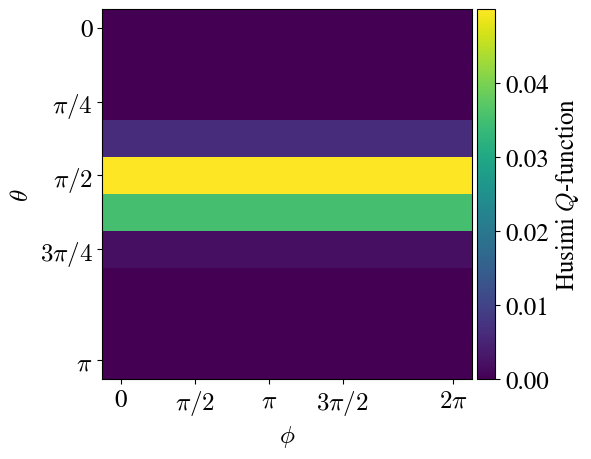

In [320]:
plot_Husimi_Q(
    D,
    results["ρ_wZero"],
    # plot_points=100,
    plot_points=10,
    progress_bar=True,
    return_dont_show=False,
    # fig=None,
    # ax=None,
    # **ax_set_kwargs,
)

In [338]:
D = 20
results = ECQFI_by_SDP_for_any_K_N(
    D=D,
    Lsigs=[Jz(D)],
    Lnoises=[Jm(D), Jp(D), Jx(D), Jy(D)],
    t=1e-5,
    γ1=1e-5,
    γnoises=1,
    please_print=True,
)

------------------------------
ECQFI / (4 * t): 90.26
Eigenspace is 2-dimensional after rounding off to 3 digits.
Solution not unique.
Noises are degenerate.
Optimal state (w = 0): QFI / ECQFI = 0.9999
Optimal state (w = 0): Entropy / max entropy = 0.2314
Noises are degenerate.
Optimal state (w != 0, random): QFI / ECQFI = 0.9999
Optimal state (w != 0, random): Entropy / max entropy = 0.2312
Fidelity between optimal state (w = 0) and optimal state (w != 0, random): 0.9998


In [339]:
ket_bell = (
    np.kron(vacuum(D), vacuum(D)) + np.kron(Jz_up_state(D), Jz_up_state(D))
) / np.sqrt(2)
fidelity(D, results["ρ_wZero"], RDM(D, ket_bell))

0.9999999882609478597

Calculating Husimi Q-function:   0%|          | 0/10 [00:00<?, ?it/s]

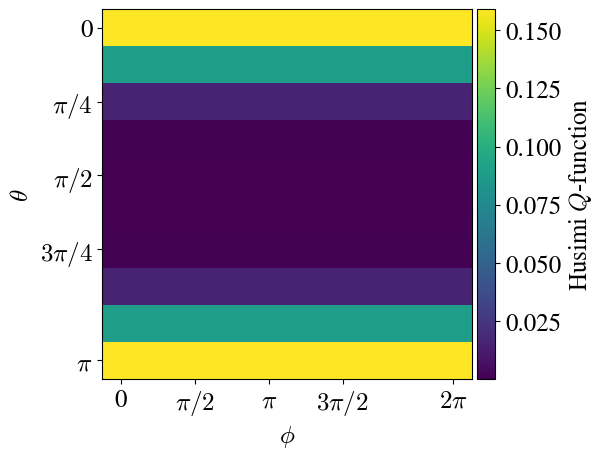

In [323]:
plot_Husimi_Q(
    D,
    results["ρ_wZero"],
    # plot_points=100,
    plot_points=10,
    progress_bar=True,
    return_dont_show=False,
    # fig=None,
    # ax=None,
    # **ax_set_kwargs,
)

Bloch sphere SDP

In [368]:
# TODO: resolve discrepancy between operator norm and ECQFI

In [396]:
##########################
# user settings
D = 2
# num_points = 100
# num_points = 10
num_points = 50
##########################

ϕ1, ϕ2 = 0, 0
θ2 = π / 4
θ1s = np.linspace(0, π / 2, num_points)

data = []
for θ1 in tqdm(θ1s):
    # construct analytic QFI function
    L1 = (np.cos(θ1) * σp + np.sin(θ1) * np.exp(1j * ϕ1) * σm) / 2
    L2 = np.cos(θ2) * (
        np.sin(θ1) * np.exp(-1j * ϕ1) * σp - np.cos(θ1) * σm
    ) / 2 + np.sin(θ2) * np.exp(1j * ϕ2) * σz / np.sqrt(2)

    results = ECQFI_by_SDP_for_K1_N1(
        D=D,
        L1=L1,
        L2=L2,
        t=1e-10,
        γ1=1e-5,
        γ2=1,
        please_print=False,
        debug=False,
    )
    # verification
    QFI_fn = lambda ρS: QFI_simultaneous_Lindblad_channel_no_prefactor(
        D, ρS, L1, L2, tol=1e-8
    )
    qfi_sdp = QFI_fn(results["ρ_wZero"])

    data.append(
        dict(
            **results,
            qfi_sdp=qfi_sdp,
            θ1=θ1,
            L1=L1,
            L2=L2,
        )
    )

data = pd.DataFrame(data)

  0%|          | 0/50 [00:00<?, ?it/s]

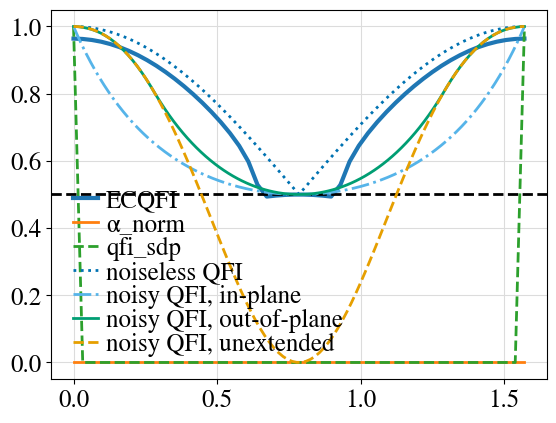

In [402]:
fig, ax = plt.subplots()
ax.plot(data["θ1"], data["ECQFI"], label="ECQFI", linewidth=3)
ax.plot(data["θ1"], data["α_norm"], label="α_norm")
ax.plot(data["θ1"], data["qfi_sdp"], label="qfi_sdp", linestyle="--")
ax.axhline(0.5, color="k", linestyle="--")

θs_HD = np.linspace(0, π / 2, 1000)
Fq_zero_h_opt = np.min(
    [
        1 / np.cos(2 * θs_HD) * (1 / np.cos(2 * θs_HD) + np.tan(2 * θs_HD)),
        1 / np.cos(2 * θs_HD) * (1 / np.cos(2 * θs_HD) - np.tan(2 * θs_HD)),
    ],
    axis=0,
)
Fq_noiseless = np.max([np.cos(θs_HD) ** 2, np.sin(θs_HD) ** 2], axis=0)
ax.plot(
    θs_HD,
    Fq_noiseless,
    label=r"noiseless QFI",
    linestyle=":",
    zorder=3,
    color=COLOURS["Blue"],
)
ax.plot(
    θs_HD,
    Fq_zero_h_opt,
    label=r"noisy QFI, in-plane",
    linestyle="-.",
    zorder=3,
    color=COLOURS["Sky blue"],
)
ax.plot(
    θs_sorted,
    qfi_swarm_sorted,
    label=r"noisy QFI, out-of-plane",
    color=COLOURS["Bluish green"],
    zorder=3,
)
ax.plot(
    θs_sorted,
    VarL1_eig_L2_sorted,
    label=r"noisy QFI, unextended",
    color=COLOURS["Orange"],
    linestyle="--",
    zorder=3,
)

legend(ax)
grid(ax)
plt.show()

In [ ]:
# TODO: resolve discrepancy between operator norm and ECQFI and the PSO results

Quarter-way up $\theta_2=\pi/8$

In [407]:
def ρS_from_3dof(r, α, p1):
    """Pseudo-cylindrical coordinates for the Pauli vector since z = p1 - 0.5 would be the true cylindrical height variable."""
    pauli_vec = [r * np.cos(α), r * np.sin(α), p1 - 0.5]
    # TODO: Find a nice numpy tensor contraction way to do this.
    ρS = 0.5 * I(2) + np.sum([k * σj for k, σj in zip(pauli_vec, [σx, σy, σz])], axis=0)
    return ρS


def ρS_from_3dof_ratio(ratio_r, α, p1):
    """ratio_r in (0, 1), α in (0, 2π), p1 in (0, 1)."""
    r = ratio_r * np.sqrt(p1 * (1 - p1))
    return ρS_from_3dof(r, α, p1)

In [408]:
##########################
# user settings
D = 2

# number_of_cores = 8
number_of_cores = 10
swarmsize = 1000
maxiter = 100
##########################

ϕ1, ϕ2 = 0, 0
# θ2 = π / 4
θ2 = π / 8
θ1s = np.linspace(0, π / 2, 100)

data = []
for θ1 in tqdm(θ1s):
    # construct analytic QFI function
    L1 = (np.cos(θ1) * σp + np.sin(θ1) * np.exp(1j * ϕ1) * σm) / 2
    L2 = np.cos(θ2) * (
        np.sin(θ1) * np.exp(-1j * ϕ1) * σp - np.cos(θ1) * σm
    ) / 2 + np.sin(θ2) * np.exp(1j * ϕ2) * σz / np.sqrt(2)
    QFI_fn = lambda ρS: QFI_simultaneous_Lindblad_channel_no_prefactor(
        D, ρS, L1, L2, tol=1e-8
    )

    a_b_dict = σpm_representation(D, L1)
    VarL1_opt = 4 * max(abs(a_b_dict["a"]) ** 2, abs(a_b_dict["b"]) ** 2)

    lower_bounds = [0, 0, 0]
    upper_bounds = [1, 2 * π, 1]

    def objective(ρS_vars):
        """ρS_vars = (ratio_r, α, p1)"""
        ρS = ρS_from_3dof_ratio(*ρS_vars)
        return -QFI_fn(ρS)

    gs_opt, obj_opt = pso(
        objective,
        lower_bounds,
        upper_bounds,
        swarmsize=swarmsize,
        maxiter=maxiter,
        processes=number_of_cores,
        debug=False,
        print_end_msg=False,
    )

    ρS_swarm = ρS_from_3dof_ratio(*gs_opt)
    qfi_swarm = -obj_opt

    # eigenstates of L2
    VarL1_eig_L2 = 0
    ket_eig_L2 = 0
    for ψ in np.linalg.eig(L2).eigenvectors.T:
        V = variance(D, ψ, L1)
        if V > VarL1_eig_L2:
            VarL1_eig_L2 = V
            ket_eig_L2 = ψ

    data.append(
        dict(
            qfi_swarm=QFI_fn(ρS_swarm),
            VarL1_opt=VarL1_opt,
            VarL1_swarm=variance(D, ρS_swarm, L1),
            VarL1_eig_L2=VarL1_eig_L2,
            θ1=θ1,
            # θ2=θ2,
            a=a_b_dict["a"],
            b=a_b_dict["b"],
            ρS_swarm=ρS_swarm,
            ρS_vars=gs_opt,
            ket_eig_L2=ket_eig_L2,
            L1=L1,
            L2=L2,
        )
    )

data = pd.DataFrame(data)

data["ratio_qfi_swarm/VarL1_opt"] = data["qfi_swarm"] / data["VarL1_opt"]
data["ratio_VarL1_swarm/VarL1_opt"] = data["VarL1_swarm"] / data["VarL1_opt"]
data["ratio_qfi_swarm/VarL1_eig_L2"] = data["qfi_swarm"] / data["VarL1_eig_L2"]

  0%|          | 0/100 [00:00<?, ?it/s]

In [410]:
file = f"../data/random_Hermitian_L1_L2/qubit_both_non-Herm_hneq0_RDM_5_no_complex_phase_quarter_way.h5"
# data.to_hdf(file, key='df')
data = pd.read_hdf(file, key="df")

print("L1 non-Hermitian, L2 non-Hermitian; h != 0 using RDM")
filtered_data = data[
    [
        c
        for c in data.columns
        # x in c
        if all(
            x not in c
            for x in ["ρS", "ket", "fidelity", "cat_", "angles", "φ2", "φ1", "θ2"]
        )  # ,	'θ1'])
        # x == c
        and c not in ["L1", "L2", "a", "b"]
    ]
]
display_data = filtered_data.reindex(sorted(filtered_data.columns)[::-1], axis=1)
pandas_float_format(".6g")
# display(display_data.sort_values(by='ratio_VarL1_swarm/VarL1_opt'))
# display(display_data.sort_values(by='ratio_qfi_swarm/VarL1_opt'))
# display(display_data.sort_values(by='VarL1_eig_L2'))

print(
    "Number of seeds with ratio > 1: ",
    len(display_data[display_data["ratio_qfi_swarm/VarL1_eig_L2"] > 1]),
)
print(
    "Number of seeds with ratio > 1.1: ",
    len(display_data[display_data["ratio_qfi_swarm/VarL1_eig_L2"] > 1.1]),
)

display(display_data.sort_values(by="ratio_qfi_swarm/VarL1_eig_L2"))
# display(display_data[display_data['ratio_qfi_swarm/VarL1_eig_L2'] > 1.1].sort_values(by='ratio_qfi_swarm/VarL1_eig_L2'))

L1 non-Hermitian, L2 non-Hermitian; h != 0 using RDM
Number of seeds with ratio > 1:  92
Number of seeds with ratio > 1.1:  88


,θ1,ratio_qfi_swarm/VarL1_opt,ratio_qfi_swarm/VarL1_eig_L2,ratio_VarL1_swarm/VarL1_opt,qfi_swarm,VarL1_swarm,VarL1_opt,VarL1_eig_L2
1,0.0158666,0.99835,0.999995,0.998352,0.998099,0.998101,0.999748,0.998104
98,1.55493,0.998355,1,0.998355,0.998104,0.998104,0.999748,0.998104
3,0.0475999,0.980404,1,0.980404,0.978184,0.978184,0.997736,0.978184
2,0.0317333,0.992517,1,0.992517,0.991518,0.991518,0.998993,0.991518
96,1.5232,0.980404,1,0.980404,0.978184,0.978184,0.997736,0.978184
...,...,...,...,...,...,...,...,...
52,0.825065,0.928279,1.20665,0.929981,0.500922,0.501841,0.539625,0.415136
51,0.809198,0.955213,1.20694,0.95584,0.500332,0.50066,0.523791,0.414545
48,0.761598,0.955213,1.20694,0.955839,0.500332,0.50066,0.523791,0.414545
49,0.777465,0.984454,1.20709,0.984527,0.500037,0.500074,0.507933,0.41425


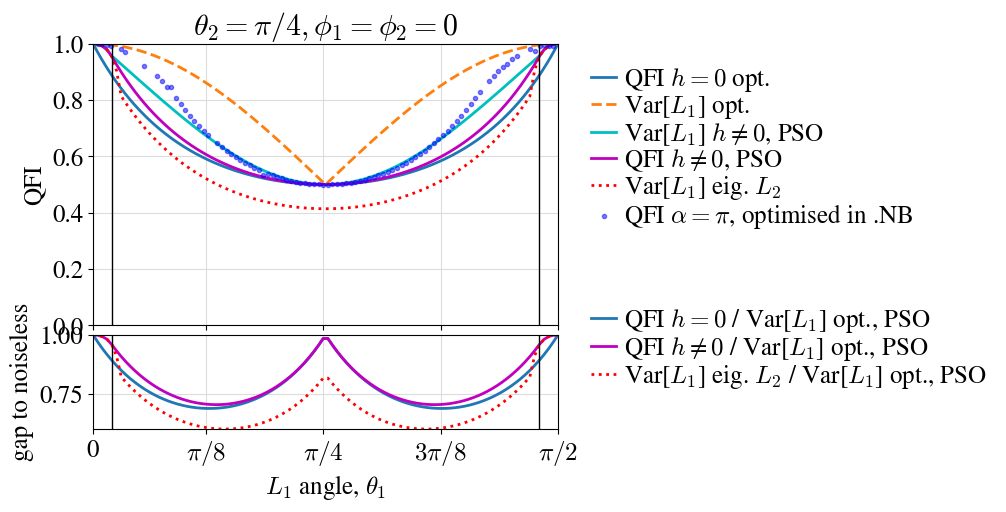

In [414]:
# load and sort new results
θs_sorted = data.sort_values(by="θ1")["θ1"]
qfi_swarm_sorted = data.sort_values(by="θ1")["qfi_swarm"]
VarL1_swarm_sorted = data.sort_values(by="θ1")["VarL1_swarm"]
VarL1_eig_L2_sorted = data.sort_values(by="θ1")["VarL1_eig_L2"]
VarL1_opt_sorted = data.sort_values(by="θ1")["VarL1_opt"]

# previous results
θs_HD = np.linspace(0, π / 2, 1000)
Fq_zero_h_opt = np.min(
    [
        1 / np.cos(2 * θs_HD) * (1 / np.cos(2 * θs_HD) + np.tan(2 * θs_HD)),
        1 / np.cos(2 * θs_HD) * (1 / np.cos(2 * θs_HD) - np.tan(2 * θs_HD)),
    ],
    axis=0,
)

Fq_noiseless = np.max([np.cos(θs_HD) ** 2, np.sin(θs_HD) ** 2], axis=0)

diff = qfi_swarm_sorted - VarL1_eig_L2_sorted
θ1_transition = θs_sorted[np.searchsorted(diff, 1e-4)]

# load mathematica results with alpha = pi with columns: theta1, QFI, p1
file = f"../data/random_Hermitian_L1_L2/qubit_mathematica_half_way.txt"
alpha_pi_data = np.loadtxt(file, delimiter=",")

# plotting
fig, axs = plt.subplots(
    2,
    1,
    figsize=(6, 5),
    sharex=True,
    gridspec_kw=dict(height_ratios=(3, 1), hspace=0.05),
)

ax = axs[0]
ax.plot(θs_HD, Fq_zero_h_opt, label=r"QFI $h=0$ opt.", linestyle="-")
ax.plot(θs_HD, Fq_noiseless, label=r"Var[$L_1$] opt.", linestyle="--")
# ax.scatter(θs_sorted, VarL1_opt_sorted, marker='+', label=r'Var[$L_1$] opt., PSO', color='y')
ax.plot(θs_sorted, VarL1_swarm_sorted, label=r"Var[$L_1$] $h\neq0$, PSO", color="c")
ax.plot(θs_sorted, qfi_swarm_sorted, label=r"QFI $h\neq0$, PSO", color="m")
ax.plot(
    θs_sorted,
    VarL1_eig_L2_sorted,
    label=r"Var[$L_1$] eig. $L_2$",
    color="r",
    linestyle="dotted",
)
ax.scatter(
    alpha_pi_data[:, 0],
    alpha_pi_data[:, 1],
    label=r"QFI $\alpha=\pi$, optimised in .NB",
    color="b",
    marker=".",
    zorder=2,
    alpha=0.5,
)
ax.set(
    ylabel="QFI",
    # ylim=(0.5, 1),
    ylim=(0, 1),
    title=r"$\theta_2=\pi/4, \phi_1=\phi_2=0$",
)
legend(ax, loc=(1.05, 0.3))
grid(ax)
ax.axvline(θ1_transition, color="k", linewidth=1)
ax.axvline(π / 2 - θ1_transition, color="k", linewidth=1)

ax = axs[1]
θs_HD = θs_sorted
Fq_zero_h_opt = np.min(
    [
        1 / np.cos(2 * θs_HD) * (1 / np.cos(2 * θs_HD) + np.tan(2 * θs_HD)),
        1 / np.cos(2 * θs_HD) * (1 / np.cos(2 * θs_HD) - np.tan(2 * θs_HD)),
    ],
    axis=0,
)
ax.plot(
    θs_sorted,
    Fq_zero_h_opt / VarL1_opt_sorted,
    label=r"QFI $h=0$ / Var[$L_1$] opt., PSO",
)
ax.plot(
    θs_sorted,
    qfi_swarm_sorted / VarL1_opt_sorted,
    label=r"QFI $h\neq0$ / Var[$L_1$] opt., PSO",
    color="m",
)
ax.plot(
    θs_sorted,
    VarL1_eig_L2_sorted / VarL1_opt_sorted,
    label=r"Var[$L_1$] eig. $L_2$ / Var[$L_1$] opt., PSO",
    color="r",
    linestyle="dotted",
)
ax.set(
    ylabel="gap to noiseless",
    ylim=(0.6, 1),
    xlabel=r"$L_1$ angle, $\theta_1$",
    xlim=lim(data["θ1"]),
)
legend(ax, loc=(1.05, 0.3))
grid(ax)
ax.axvline(θ1_transition, color="k", linewidth=1)
ax.axvline(π / 2 - θ1_transition, color="k", linewidth=1)
gen_ticks = lambda v: [
    max(v / (len(v) - 1)) * x
    for x in [
        0,
        (len(v) - 1) // 4,
        (len(v) - 1) // 2,
        3 * (len(v) - 1) // 4,
        len(v) - 1,
    ]
]
ticks = gen_ticks(data["θ1"])
tick_labels = [0, r"$\pi/8$", r"$\pi/4$", r"$3\pi/8$", r"$\pi/2$"]
ax.set_xticks(ticks, tick_labels)


fig.savefig(
    f"{figdir}qubits/both_non-Herm_hneq0_RDM_5_no_complex_phase_quarter_way_QFI_vs_theta.pdf",
    bbox_inches="tight",
)
plt.show()

Load and bloch both on bloch sphere

In [ ]:
file = f"../data/random_Hermitian_L1_L2/qubit_both_non-Herm_hneq0_RDM_5_no_complex_phase_quarter_way.h5"
data = pd.read_hdf(file, key="df")

In [ ]:
Ss = []
pvs = []
pvs_ket = []
for ρ, ket_eig_L20 in zip(data["ρS_swarm"], data["ket_eig_L2"]):
    S = entropy(2, ρ, normalised=True)
    Ss.append(S)
    ρ_swarm_pv = np.sqrt(2) * Pauli_vector(ρ)
    pvs.append(ρ_swarm_pv)
    ket_eig_L20_pv = bloch_vector(ket_eig_L20) / np.sqrt(2)
    pvs_ket.append(ket_eig_L20_pv)
data["entropy"] = Ss
data["pvs"] = pvs
data["pvs_ket"] = pvs_ket

/home/james/.local/lib/python3.10/site-packages/scipy/linalg/_matfuncs.py:203: LogmExactlySingularWarning: The logm input matrix is exactly singular.
  F = scipy.linalg._matfuncs_inv_ssq._logm(A)


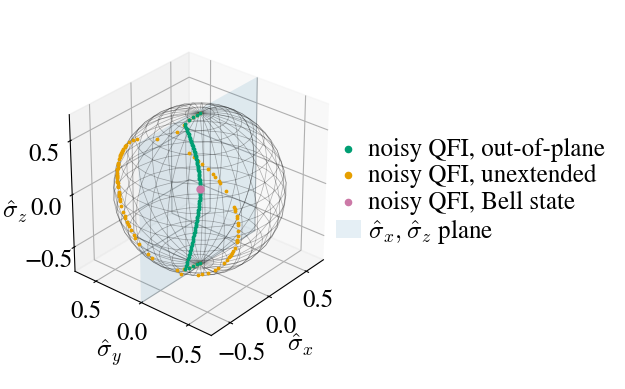

In [ ]:
fig, ax = plt.subplots(subplot_kw=dict(projection="3d", computed_zorder=False))

# https://stackoverflow.com/a/11156353
# draw sphere
u, v = np.mgrid[0 : 2 * np.pi : 30j, 0 : np.pi : 20j]
# radius = 1
radius = 1 / np.sqrt(2)
x = radius * np.cos(u) * np.sin(v)
y = radius * np.sin(u) * np.sin(v)
z = radius * np.cos(v)
ax.plot_wireframe(x, y, z, color="k", linewidth=0.5, alpha=0.3)
ax.set_box_aspect((np.ptp(x), np.ptp(y), np.ptp(z)))


# draw a point
ax.scatter([0], [0], [0], color=COLOURS["Reddish purple"], s=25, zorder=11)

# draw a vector
# for i, pv in enumerate(data["pvs_ket"][::3]):
#     ax.scatter([pv[0].real], [pv[1].real], [pv[2].real], color=COLOURS['Orange'], s=3,
#             #    zorder=10,
#     zorder=15,
#     )

for i, pv in enumerate(data["pvs_ket"]):
    ax.scatter(
        [pv[0].real],
        [pv[1].real],
        [pv[2].real],
        color=COLOURS["Orange"],
        s=3,
        zorder=9,
    )

for i, pv in enumerate(data["pvs"]):
    ax.scatter(
        [pv[1].real],
        [pv[2].real],
        [pv[3].real],
        color=COLOURS["Bluish green"],
        s=3,
        zorder=10,
    )

ax.xaxis.set_rotate_label(False)
ax.yaxis.set_rotate_label(False)
ax.zaxis.set_rotate_label(False)
ax.set_xlabel(r"$\hat \sigma_x$", labelpad=10)
ax.set_ylabel(r"$\hat \sigma_y$" + "\n", labelpad=17)
ax.set_zlabel("\n" + r"$\hat \sigma_z$", labelpad=10)

# legend(ax, labelspacing=0.1,
#     loc="lower left",
#     bbox_to_anchor=(-0.2, 0.3),
# )
# ax.view_init(elev=20, azim=-45)
# ax.set_box_aspect([1, 1, 1], zoom=0.75)
# ax.view_init(elev=30, azim=-60)
ax.view_init(elev=30, azim=-140)
# ax.view_init(elev=0, azim=90)
ax.set_box_aspect([1, 1, 1], zoom=0.82)

handles = [
    plt.scatter(
        [],
        [],
        s=20,
        color=COLOURS["Bluish green"],
        label=r"noisy QFI, out-of-plane",
    ),
    plt.scatter(
        [],
        [],
        s=20,
        color=COLOURS["Orange"],
        label=r"noisy QFI, unextended",
    ),
    plt.scatter(
        [],
        [],
        s=20,
        color=COLOURS["Reddish purple"],
        label="noisy QFI, Bell state",
    ),
]

# Add a plane along the YZ plane
factor = 1.05
x_plane = np.array(
    [[-factor * radius, factor * radius], [-factor * radius, factor * radius]]
)
y_plane = np.array([[0, 0], [0, 0]])
z_plane = np.array(
    [[-factor * radius, -factor * radius], [factor * radius, factor * radius]]
)
ax.plot_surface(
    x_plane,
    y_plane,
    z_plane,
    color=COLOURS["Blue"],
    alpha=0.1,
    label=r"$\hat \sigma_x, \hat \sigma_z$ plane",
)

legend(
    ax,
    # handles=handles,
    # handles=[*handles, *h],
    # labels=[*l, 'test'],
    labelspacing=0.1,
    loc="lower left",
    # bbox_to_anchor=(-0.7, 0.3),
    bbox_to_anchor=(0.82, 0.3),
    # handlelength=1.5,
)
# plot_limits = (-1, 1)
plot_limits = (-radius, radius)
ax.set(
    xlim=plot_limits,
    ylim=plot_limits,
    zlim=plot_limits,
)
ax.tick_params(axis="z", pad=6)

fig.savefig(
    f"{figdir}qubits/Bloch_sphere_parametric_quarter-way.pdf", bbox_inches="tight"
)
plt.show()

In [ ]:
# TODO: resolve what is happening with the L2 eigenstate

In [ ]:
# eigenstates of L2
VarL1_eig_L2 = 0
ket_eig_L2 = 0
for ψ in np.linalg.eig(L2).eigenvectors.T:
    V = variance(D, ψ, L1)
    if V > VarL1_eig_L2:
        VarL1_eig_L2 = V
        ket_eig_L2 = ψ

In [ ]:
np.linalg.eig(L2)

EigResult(eigenvalues=array([ 0.27059805+0.j, -0.27059805+0.j]), eigenvectors=array([[ 1.00000000e+00+0.j,  8.62856209e-01+0.j],
       [-1.04530143e-16+0.j, -5.05449465e-01+0.j]]))

In [ ]:
L2

array([[ 2.70598050e-01+0.j,  9.23879533e-01+0.j],
       [-5.65713056e-17+0.j, -2.70598050e-01+0.j]])

In [ ]:
im_op(L2)

array([[0.+0.j        , 0.-0.46193977j],
       [0.+0.46193977j, 0.+0.j        ]])

In [ ]:
re_op(L2)

array([[ 0.27059805+0.j,  0.46193977+0.j],
       [ 0.46193977+0.j, -0.27059805+0.j]])

Three quarters-way up $\theta_2=3\pi/8$

In [429]:
def ρS_from_3dof(r, α, p1):
    """Pseudo-cylindrical coordinates for the Pauli vector since z = p1 - 0.5 would be the true cylindrical height variable."""
    pauli_vec = [r * np.cos(α), r * np.sin(α), p1 - 0.5]
    # TODO: Find a nice numpy tensor contraction way to do this.
    ρS = 0.5 * I(2) + np.sum([k * σj for k, σj in zip(pauli_vec, [σx, σy, σz])], axis=0)
    return ρS


def ρS_from_3dof_ratio(ratio_r, α, p1):
    """ratio_r in (0, 1), α in (0, 2π), p1 in (0, 1)."""
    r = ratio_r * np.sqrt(p1 * (1 - p1))
    return ρS_from_3dof(r, α, p1)

In [430]:
##########################
# user settings
D = 2

# number_of_cores = 8
number_of_cores = 10
swarmsize = 1000
maxiter = 100
##########################

ϕ1, ϕ2 = 0, 0
# θ2 = π / 4
# θ2 = π / 8
θ2 = 3 * π / 8
θ1s = np.linspace(0, π / 2, 100)

data = []
for θ1 in tqdm(θ1s):
    # construct analytic QFI function
    L1 = (np.cos(θ1) * σp + np.sin(θ1) * np.exp(1j * ϕ1) * σm) / 2
    L2 = np.cos(θ2) * (
        np.sin(θ1) * np.exp(-1j * ϕ1) * σp - np.cos(θ1) * σm
    ) / 2 + np.sin(θ2) * np.exp(1j * ϕ2) * σz / np.sqrt(2)
    QFI_fn = lambda ρS: QFI_simultaneous_Lindblad_channel_no_prefactor(
        D, ρS, L1, L2, tol=1e-8
    )

    a_b_dict = σpm_representation(D, L1)
    VarL1_opt = 4 * max(abs(a_b_dict["a"]) ** 2, abs(a_b_dict["b"]) ** 2)

    lower_bounds = [0, 0, 0]
    upper_bounds = [1, 2 * π, 1]

    def objective(ρS_vars):
        """ρS_vars = (ratio_r, α, p1)"""
        ρS = ρS_from_3dof_ratio(*ρS_vars)
        return -QFI_fn(ρS)

    gs_opt, obj_opt = pso(
        objective,
        lower_bounds,
        upper_bounds,
        swarmsize=swarmsize,
        maxiter=maxiter,
        processes=number_of_cores,
        debug=False,
        print_end_msg=False,
    )

    ρS_swarm = ρS_from_3dof_ratio(*gs_opt)
    qfi_swarm = -obj_opt

    # eigenstates of L2
    VarL1_eig_L2 = 0
    ket_eig_L2 = 0
    for ψ in np.linalg.eig(L2).eigenvectors.T:
        V = variance(D, ψ, L1)
        if V > VarL1_eig_L2:
            VarL1_eig_L2 = V
            ket_eig_L2 = ψ

    data.append(
        dict(
            qfi_swarm=QFI_fn(ρS_swarm),
            VarL1_opt=VarL1_opt,
            VarL1_swarm=variance(D, ρS_swarm, L1),
            VarL1_eig_L2=VarL1_eig_L2,
            θ1=θ1,
            # θ2=θ2,
            a=a_b_dict["a"],
            b=a_b_dict["b"],
            ρS_swarm=ρS_swarm,
            ρS_vars=gs_opt,
            ket_eig_L2=ket_eig_L2,
            L1=L1,
            L2=L2,
        )
    )

data = pd.DataFrame(data)

data["ratio_qfi_swarm/VarL1_opt"] = data["qfi_swarm"] / data["VarL1_opt"]
data["ratio_VarL1_swarm/VarL1_opt"] = data["VarL1_swarm"] / data["VarL1_opt"]
data["ratio_qfi_swarm/VarL1_eig_L2"] = data["qfi_swarm"] / data["VarL1_eig_L2"]

  0%|          | 0/100 [00:00<?, ?it/s]

varL2 is negative: -5.55e-17 and |covL1L2| = 1.17e-08 (which should be zero) is not beneath tol = 1e-08. Returning varL1 = 0.832 instead.


/home/james/Code/slipperyslider/jupyter_notebooks/../python_source/lindblad.py:22: RuntimeWarning: divide by zero encountered in scalar divide
  return varL1 - np.abs(covL1L2) ** 2 / varL2


varL2 is negative: -5.55e-17 and |covL1L2| = 1.17e-08 (which should be zero) is not beneath tol = 1e-08. Returning varL1 = 0.832 instead.


/home/james/Code/slipperyslider/jupyter_notebooks/../python_source/lindblad.py:22: RuntimeWarning: divide by zero encountered in scalar divide
  return varL1 - np.abs(covL1L2) ** 2 / varL2


In [433]:
file = f"../data/random_Hermitian_L1_L2/qubit_both_non-Herm_hneq0_RDM_5_no_complex_phase_three-quarters_way.h5"
# data.to_hdf(file, key='df')
data = pd.read_hdf(file, key="df")

print("L1 non-Hermitian, L2 non-Hermitian; h != 0 using RDM")
filtered_data = data[
    [
        c
        for c in data.columns
        # x in c
        if all(
            x not in c
            for x in ["ρS", "ket", "fidelity", "cat_", "angles", "φ2", "φ1", "θ2"]
        )  # ,	'θ1'])
        # x == c
        and c not in ["L1", "L2", "a", "b"]
    ]
]
display_data = filtered_data.reindex(sorted(filtered_data.columns)[::-1], axis=1)
pandas_float_format(".6g")
# display(display_data.sort_values(by='ratio_VarL1_swarm/VarL1_opt'))
# display(display_data.sort_values(by='ratio_qfi_swarm/VarL1_opt'))
# display(display_data.sort_values(by='VarL1_eig_L2'))

print(
    "Number of seeds with ratio > 1: ",
    len(display_data[display_data["ratio_qfi_swarm/VarL1_eig_L2"] > 1]),
)
print(
    "Number of seeds with ratio > 1.1: ",
    len(display_data[display_data["ratio_qfi_swarm/VarL1_eig_L2"] > 1.1]),
)

display(display_data.sort_values(by="ratio_qfi_swarm/VarL1_eig_L2"))
# display(display_data[display_data['ratio_qfi_swarm/VarL1_eig_L2'] > 1.1].sort_values(by='ratio_qfi_swarm/VarL1_eig_L2'))

L1 non-Hermitian, L2 non-Hermitian; h != 0 using RDM
Number of seeds with ratio > 1:  24
Number of seeds with ratio > 1.1:  6


,θ1,ratio_qfi_swarm/VarL1_opt,ratio_qfi_swarm/VarL1_eig_L2,ratio_VarL1_swarm/VarL1_opt,qfi_swarm,VarL1_swarm,VarL1_opt,VarL1_eig_L2
96,1.5232,0.999071,0.999481,0.999072,0.996809,0.99681,0.997736,0.997327
5,0.0793331,0.998375,0.999553,0.998381,0.992105,0.992111,0.993719,0.992549
4,0.0634665,0.998845,0.999587,0.998848,0.994827,0.99483,0.995977,0.995239
92,1.45973,0.997225,0.999608,0.99725,0.984974,0.984998,0.987715,0.98536
10,0.158666,0.994614,0.999701,0.994632,0.969784,0.969802,0.975036,0.970074
...,...,...,...,...,...,...,...,...
47,0.745732,0.936535,1.10602,0.945678,0.505378,0.510312,0.539625,0.456932
48,0.761598,0.958273,1.14141,0.96185,0.501935,0.503808,0.523791,0.439752
51,0.809198,0.958273,1.14141,0.961853,0.501935,0.50381,0.523791,0.439752
49,0.777465,0.984804,1.1834,0.985226,0.500214,0.500429,0.507933,0.422692


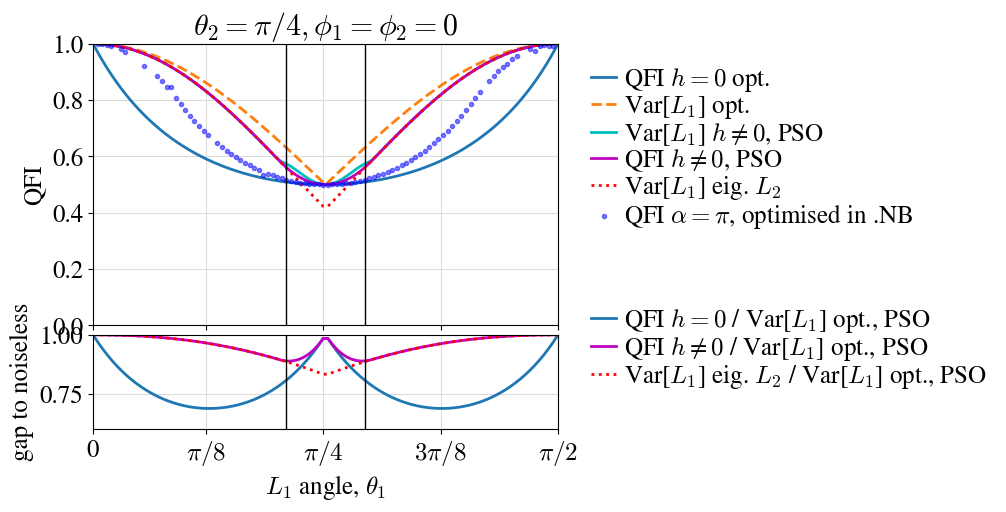

In [432]:
# load and sort new results
θs_sorted = data.sort_values(by="θ1")["θ1"]
qfi_swarm_sorted = data.sort_values(by="θ1")["qfi_swarm"]
VarL1_swarm_sorted = data.sort_values(by="θ1")["VarL1_swarm"]
VarL1_eig_L2_sorted = data.sort_values(by="θ1")["VarL1_eig_L2"]
VarL1_opt_sorted = data.sort_values(by="θ1")["VarL1_opt"]

# previous results
θs_HD = np.linspace(0, π / 2, 1000)
Fq_zero_h_opt = np.min(
    [
        1 / np.cos(2 * θs_HD) * (1 / np.cos(2 * θs_HD) + np.tan(2 * θs_HD)),
        1 / np.cos(2 * θs_HD) * (1 / np.cos(2 * θs_HD) - np.tan(2 * θs_HD)),
    ],
    axis=0,
)

Fq_noiseless = np.max([np.cos(θs_HD) ** 2, np.sin(θs_HD) ** 2], axis=0)

diff = qfi_swarm_sorted - VarL1_eig_L2_sorted
θ1_transition = θs_sorted[np.searchsorted(diff, 1e-4)]

# load mathematica results with alpha = pi with columns: theta1, QFI, p1
file = f"../data/random_Hermitian_L1_L2/qubit_mathematica_half_way.txt"
alpha_pi_data = np.loadtxt(file, delimiter=",")

# plotting
fig, axs = plt.subplots(
    2,
    1,
    figsize=(6, 5),
    sharex=True,
    gridspec_kw=dict(height_ratios=(3, 1), hspace=0.05),
)

ax = axs[0]
ax.plot(θs_HD, Fq_zero_h_opt, label=r"QFI $h=0$ opt.", linestyle="-")
ax.plot(θs_HD, Fq_noiseless, label=r"Var[$L_1$] opt.", linestyle="--")
# ax.scatter(θs_sorted, VarL1_opt_sorted, marker='+', label=r'Var[$L_1$] opt., PSO', color='y')
ax.plot(θs_sorted, VarL1_swarm_sorted, label=r"Var[$L_1$] $h\neq0$, PSO", color="c")
ax.plot(θs_sorted, qfi_swarm_sorted, label=r"QFI $h\neq0$, PSO", color="m")
ax.plot(
    θs_sorted,
    VarL1_eig_L2_sorted,
    label=r"Var[$L_1$] eig. $L_2$",
    color="r",
    linestyle="dotted",
)
ax.scatter(
    alpha_pi_data[:, 0],
    alpha_pi_data[:, 1],
    label=r"QFI $\alpha=\pi$, optimised in .NB",
    color="b",
    marker=".",
    zorder=2,
    alpha=0.5,
)
ax.set(
    ylabel="QFI",
    # ylim=(0.5, 1),
    ylim=(0, 1),
    title=r"$\theta_2=\pi/4, \phi_1=\phi_2=0$",
)
legend(ax, loc=(1.05, 0.3))
grid(ax)
ax.axvline(θ1_transition, color="k", linewidth=1)
ax.axvline(π / 2 - θ1_transition, color="k", linewidth=1)

ax = axs[1]
θs_HD = θs_sorted
Fq_zero_h_opt = np.min(
    [
        1 / np.cos(2 * θs_HD) * (1 / np.cos(2 * θs_HD) + np.tan(2 * θs_HD)),
        1 / np.cos(2 * θs_HD) * (1 / np.cos(2 * θs_HD) - np.tan(2 * θs_HD)),
    ],
    axis=0,
)
ax.plot(
    θs_sorted,
    Fq_zero_h_opt / VarL1_opt_sorted,
    label=r"QFI $h=0$ / Var[$L_1$] opt., PSO",
)
ax.plot(
    θs_sorted,
    qfi_swarm_sorted / VarL1_opt_sorted,
    label=r"QFI $h\neq0$ / Var[$L_1$] opt., PSO",
    color="m",
)
ax.plot(
    θs_sorted,
    VarL1_eig_L2_sorted / VarL1_opt_sorted,
    label=r"Var[$L_1$] eig. $L_2$ / Var[$L_1$] opt., PSO",
    color="r",
    linestyle="dotted",
)
ax.set(
    ylabel="gap to noiseless",
    ylim=(0.6, 1),
    xlabel=r"$L_1$ angle, $\theta_1$",
    xlim=lim(data["θ1"]),
)
legend(ax, loc=(1.05, 0.3))
grid(ax)
ax.axvline(θ1_transition, color="k", linewidth=1)
ax.axvline(π / 2 - θ1_transition, color="k", linewidth=1)
gen_ticks = lambda v: [
    max(v / (len(v) - 1)) * x
    for x in [
        0,
        (len(v) - 1) // 4,
        (len(v) - 1) // 2,
        3 * (len(v) - 1) // 4,
        len(v) - 1,
    ]
]
ticks = gen_ticks(data["θ1"])
tick_labels = [0, r"$\pi/8$", r"$\pi/4$", r"$3\pi/8$", r"$\pi/2$"]
ax.set_xticks(ticks, tick_labels)


fig.savefig(
    f"{figdir}qubits/both_non-Herm_hneq0_RDM_5_no_complex_phase_three-quarters_way_QFI_vs_theta.pdf",
    bbox_inches="tight",
)
plt.show()

In [434]:
Ss = []
pvs = []
pvs_ket = []
for ρ, ket_eig_L20 in zip(data["ρS_swarm"], data["ket_eig_L2"]):
    S = entropy(2, ρ, normalised=True)
    Ss.append(S)
    ρ_swarm_pv = np.sqrt(2) * Pauli_vector(ρ)
    pvs.append(ρ_swarm_pv)
    ket_eig_L20_pv = bloch_vector(ket_eig_L20) / np.sqrt(2)
    pvs_ket.append(ket_eig_L20_pv)
data["entropy"] = Ss
data["pvs"] = pvs
data["pvs_ket"] = pvs_ket

/home/james/.local/lib/python3.10/site-packages/scipy/linalg/_matfuncs.py:203: LogmExactlySingularWarning: The logm input matrix is exactly singular.
  F = scipy.linalg._matfuncs_inv_ssq._logm(A)


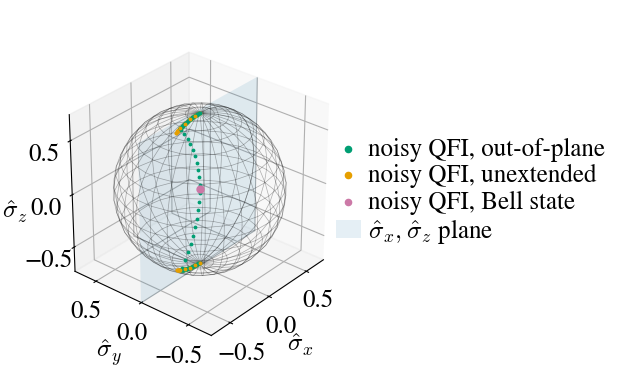

In [437]:
fig, ax = plt.subplots(subplot_kw=dict(projection="3d", computed_zorder=False))

# https://stackoverflow.com/a/11156353
# draw sphere
u, v = np.mgrid[0 : 2 * np.pi : 30j, 0 : np.pi : 20j]
# radius = 1
radius = 1 / np.sqrt(2)
x = radius * np.cos(u) * np.sin(v)
y = radius * np.sin(u) * np.sin(v)
z = radius * np.cos(v)
ax.plot_wireframe(x, y, z, color="k", linewidth=0.5, alpha=0.3)
ax.set_box_aspect((np.ptp(x), np.ptp(y), np.ptp(z)))


# draw a point
ax.scatter([0], [0], [0], color=COLOURS["Reddish purple"], s=25, zorder=11)

# draw a vector
for i, pv in enumerate(data["pvs_ket"][::10]):
    ax.scatter(
        [pv[0].real],
        [pv[1].real],
        [pv[2].real],
        color=COLOURS["Orange"],
        s=3,
        #    zorder=10,
        zorder=15,
    )

for i, pv in enumerate(data["pvs_ket"]):
    ax.scatter(
        [pv[0].real],
        [pv[1].real],
        [pv[2].real],
        color=COLOURS["Orange"],
        s=3,
        zorder=9,
    )

for i, pv in enumerate(data["pvs"]):
    ax.scatter(
        [pv[1].real],
        [pv[2].real],
        [pv[3].real],
        color=COLOURS["Bluish green"],
        s=3,
        zorder=10,
    )

ax.xaxis.set_rotate_label(False)
ax.yaxis.set_rotate_label(False)
ax.zaxis.set_rotate_label(False)
ax.set_xlabel(r"$\hat \sigma_x$", labelpad=10)
ax.set_ylabel(r"$\hat \sigma_y$" + "\n", labelpad=17)
ax.set_zlabel("\n" + r"$\hat \sigma_z$", labelpad=10)

# legend(ax, labelspacing=0.1,
#     loc="lower left",
#     bbox_to_anchor=(-0.2, 0.3),
# )
# ax.view_init(elev=20, azim=-45)
# ax.set_box_aspect([1, 1, 1], zoom=0.75)
# ax.view_init(elev=30, azim=-60)
ax.view_init(elev=30, azim=-140)
# ax.view_init(elev=0, azim=90)
ax.set_box_aspect([1, 1, 1], zoom=0.82)

handles = [
    plt.scatter(
        [],
        [],
        s=20,
        color=COLOURS["Bluish green"],
        label=r"noisy QFI, out-of-plane",
    ),
    plt.scatter(
        [],
        [],
        s=20,
        color=COLOURS["Orange"],
        label=r"noisy QFI, unextended",
    ),
    plt.scatter(
        [],
        [],
        s=20,
        color=COLOURS["Reddish purple"],
        label="noisy QFI, Bell state",
    ),
]

# Add a plane along the YZ plane
factor = 1.05
x_plane = np.array(
    [[-factor * radius, factor * radius], [-factor * radius, factor * radius]]
)
y_plane = np.array([[0, 0], [0, 0]])
z_plane = np.array(
    [[-factor * radius, -factor * radius], [factor * radius, factor * radius]]
)
ax.plot_surface(
    x_plane,
    y_plane,
    z_plane,
    color=COLOURS["Blue"],
    alpha=0.1,
    label=r"$\hat \sigma_x, \hat \sigma_z$ plane",
)

legend(
    ax,
    # handles=handles,
    # handles=[*handles, *h],
    # labels=[*l, 'test'],
    labelspacing=0.1,
    loc="lower left",
    # bbox_to_anchor=(-0.7, 0.3),
    bbox_to_anchor=(0.82, 0.3),
    # handlelength=1.5,
)
# plot_limits = (-1, 1)
plot_limits = (-radius, radius)
ax.set(
    xlim=plot_limits,
    ylim=plot_limits,
    zlim=plot_limits,
)
ax.tick_params(axis="z", pad=6)

fig.savefig(
    f"{figdir}qubits/Bloch_sphere_parametric_three-quarters-way.pdf",
    bbox_inches="tight",
)
plt.show()

In [ ]:
# The trace of the states look the same for the quarter and 3-quarters $\theta_2$ results as the half-way state but just progressed through further. I have not plotted them all together though. TODO: explain this.
# TODO: resolve what is happening with the L2 eigenstate

Wigner function (trying again)

## Noisy ancilla

Bell si_z, si_-

In [ ]:
D = 2

ket_bell = (
    np.kron(vacuum(D), vacuum(D)) + np.kron(Jz_up_state(D), Jz_up_state(D))
) / np.sqrt(2)

Lsignal1 = np.kron(σz, I(D))
Lsignal2 = np.kron(I(D), σz)

Lnoise1 = np.kron(σm, I(D))
Lnoise2 = np.kron(I(D), σm)

print(
    f"QFI noiseless ancilla / (4 t) = {QFI_simultaneous_Lindblad_channel_no_prefactor(2 * D, ket_bell, Lsignal1, Lnoise1):.4g}"
)
print(
    f"QFI noisy but not signal on ancilla / (4 t) = {QFI_two_noise_operators_no_prefactor(2 * D, ket_bell, Lsignal1, Lnoise1, Lnoise2):.4g}"
)
# QFI up to 4t
QFI_noisy_ancilla = QFI_two_noise_operators_no_prefactor(
    2 * D, ket_bell, Lsignal1, Lnoise1, Lnoise2
) + QFI_two_noise_operators_no_prefactor(2 * D, ket_bell, Lsignal2, Lnoise1, Lnoise2)
print(f"(QFI noisy and signalfull ancilla / (4 t) = {QFI_noisy_ancilla:.4g})")
print(f"QFI noisy and signalfull ancilla / (4 t) / qubit = {QFI_noisy_ancilla / 2:.4g}")

Bell L1 Herm, L2 non-Herm

In [ ]:
D = 2

ket_bell = (
    np.kron(vacuum(D), vacuum(D)) + np.kron(Jz_up_state(D), Jz_up_state(D))
) / np.sqrt(2)

w = 0.3
a = np.sqrt(1 / 4 * w)
b = np.sqrt(1 / 4 * (1 - w)) * np.exp(1j * π / 8)

L1 = σz / np.sqrt(2)
L2 = a * σp + b * σm

Lsignal1 = np.kron(L1, I(D))
Lsignal2 = np.kron(I(D), L1)

Lnoise1 = np.kron(L2, I(D))
Lnoise2 = np.kron(I(D), L2)

print(
    f"QFI noiseless ancilla / (4 t) = {QFI_simultaneous_Lindblad_channel_no_prefactor(2 * D, ket_bell, Lsignal1, Lnoise1):.4g}"
)
print(
    f"QFI noisy but not signal on ancilla / (4 t) = {QFI_two_noise_operators_no_prefactor(2 * D, ket_bell, Lsignal1, Lnoise1, Lnoise2):.4g}"
)
# QFI up to 4t
QFI_noisy_ancilla = QFI_two_noise_operators_no_prefactor(
    2 * D, ket_bell, Lsignal1, Lnoise1, Lnoise2
) + QFI_two_noise_operators_no_prefactor(2 * D, ket_bell, Lsignal2, Lnoise1, Lnoise2)
print(f"(QFI noisy and signalfull ancilla / (4 t) = {QFI_noisy_ancilla:.4g})")
print(f"QFI noisy and signalfull ancilla / (4 t) / qubit = {QFI_noisy_ancilla / 2:.4g}")

In [ ]:
D = 2
num_seeds = 100

ket_bell = (
    np.kron(vacuum(D), vacuum(D)) + np.kron(Jz_up_state(D), Jz_up_state(D))
) / np.sqrt(2)

err0 = 0
seed0 = None

for seed in tqdm(range(num_seeds)):
    rng = np.random.default_rng(seed)

    a = rng.random(1) + 1j * rng.random(1)
    b = rng.random(1) + 1j * rng.random(1)

    normm = 2 * np.sqrt(np.abs(a) ** 2 + np.abs(b) ** 2)
    a /= normm
    b /= normm

    L1 = σz / np.sqrt(2)
    L2 = a * σp + b * σm

    Lsignal1 = np.kron(L1, I(D))
    Lsignal2 = np.kron(I(D), L1)

    Lnoise1 = np.kron(L2, I(D))
    Lnoise2 = np.kron(I(D), L2)

    Fq_noiseless = QFI_simultaneous_Lindblad_channel_no_prefactor(
        2 * D, ket_bell, Lsignal1, Lnoise1
    )
    # QFI up to 4t
    QFI_noisy_ancilla = QFI_two_noise_operators_no_prefactor(
        2 * D, ket_bell, Lsignal1, Lnoise1, Lnoise2
    ) + QFI_two_noise_operators_no_prefactor(
        2 * D, ket_bell, Lsignal2, Lnoise1, Lnoise2
    )
    # print(f'QFI noiseless ancilla / (4 t) = {Fq_noiseless:.3g}')
    # print(f'QFI noisy but not signal on ancilla / (4 t) = {QFI_two_noise_operators_no_prefactor(2 * D, ket_bell, Lsignal1, Lnoise1, Lnoise2):.3g}')
    # print(f'(QFI noisy and signalfull ancilla / (4 t) = {QFI_noisy_ancilla:.3g})')
    # print(f'QFI noisy and signalfull ancilla / (4 t) / qubit = {QFI_noisy_ancilla / 2:.3g}\n')

    err = Fq_noiseless - QFI_noisy_ancilla / 2
    if err > err0:
        err0 = err
        seed0 = seed

print(f"Bell state Eq.F6, largest error = {err0:.4g} encountered at seed i = {seed0}.")

In [ ]:
# TODO: rotate the bell state into the correct basis, but this is not very interesting

D = 2
# num_seeds = 100
num_seeds = 5

ket_bell = (
    np.kron(vacuum(D), vacuum(D)) + np.kron(Jz_up_state(D), Jz_up_state(D))
) / np.sqrt(2)

data = []
for seed in tqdm(range(num_seeds)):
    # construct analytic QFI function
    seed_sequence = generate_seed_sequence(seed, length=3)

    # reversing the order of orthogonalisation to ensure that L_1 is Hermitian
    L10 = random_Hermitian_op(D, seed=seed_sequence[0])
    L10perp = orthogonal_component_general(L10, I(D), "operator")
    L10perp /= np.sqrt(ip(L10perp, L10perp))

    L20 = random_op(D, seed=seed_sequence[1])
    L20perp = orthogonal_component_from_orthogonal_set_general(
        L20, [L10perp, I(D)], "operator"
    )
    L20perp /= np.sqrt(ip(L20perp, L20perp))

    L1 = L10perp
    L2 = L20perp

    Lsignal1 = np.kron(L1, I(D))
    Lsignal2 = np.kron(I(D), L1)

    Lnoise1 = np.kron(L2, I(D))
    Lnoise2 = np.kron(I(D), L2)

    print(
        f"QFI noiseless ancilla / (4 t) = {QFI_simultaneous_Lindblad_channel_no_prefactor(2 * D, ket_bell, Lsignal1, Lnoise1):.3g}"
    )
    print(
        f"QFI noisy but not signal on ancilla / (4 t) = {QFI_two_noise_operators_no_prefactor(2 * D, ket_bell, Lsignal1, Lnoise1, Lnoise2):.3g}"
    )
    # QFI up to 4t
    QFI_noisy_ancilla = QFI_two_noise_operators_no_prefactor(
        2 * D, ket_bell, Lsignal1, Lnoise1, Lnoise2
    ) + QFI_two_noise_operators_no_prefactor(
        2 * D, ket_bell, Lsignal2, Lnoise1, Lnoise2
    )
    print(f"(QFI noisy and signalfull ancilla / (4 t) = {QFI_noisy_ancilla:.3g})")
    print(
        f"QFI noisy and signalfull ancilla / (4 t) / qubit = {QFI_noisy_ancilla / 2:.3g}\n"
    )